<a href="https://colab.research.google.com/github/Tazin17/pain-intensity-prediction-from-laser-evoked-eeg-responses/blob/main/v5_pipeline_for_exp8_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

# Try to unmount if it's already mounted or partially mounted
try:
  drive.flush_and_unmount()
  print('Drive unmounted.')
except ValueError:
  pass # Drive was not mounted, nothing to unmount

# Ensure the mount point is clean
if os.path.isdir('/content/drive'):
  # Remove all contents of the directory, but not the directory itself
  # This avoids issues if the directory is still seen as a mount point
  for item in os.listdir('/content/drive'):
    item_path = os.path.join('/content/drive', item)
    if os.path.isfile(item_path):
      os.remove(item_path)
    elif os.path.isdir(item_path):
      import shutil
      shutil.rmtree(item_path)
  print('Cleared /content/drive directory.')
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)
  print('Created /content/drive directory.')

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Drive unmounted.
Created /content/drive directory.
Mounted at /content/drive


In [ ]:
!pip -q install pymatreader mne scipy scikit-learn pandas numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 59.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
# CELL 2 — Imports and paths

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pymatreader import read_mat
from scipy.signal import welch
from scipy.stats import skew, kurtosis

EXP_NAME = "EXP8"

# Change this path if your Exp8 folder name is different
EXP8_ROOT = "/content/drive/MyDrive/my dataset_raw_main_exp8"

OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
os.makedirs(OUT_DIR, exist_ok=True)

print("EXP8_ROOT exists:", os.path.exists(EXP8_ROOT))
print("OUT_DIR:", OUT_DIR)

EXP8_ROOT exists: True
OUT_DIR: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH


In [ ]:
# CELL — Reload saved V5 features after reopening Colab



import os
import numpy as np
import pandas as pd


# ============================================================
# 1. V5 saved-data directory
# ============================================================

V5_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH"
)


# ============================================================
# 2. Saved file paths
# ============================================================

X_HANDCRAFTED_PATH = os.path.join(
    V5_DIR,
    "X_v5_handcrafted_all_262.npy"
)

X_RIEMANNIAN_PATH = os.path.join(
    V5_DIR,
    "X_v5_baseline_referenced_riemannian_all_702.npy"
)

X_FUSION_PATH = os.path.join(
    V5_DIR,
    "X_v5_full_fusion_all_964.npy"
)

V5_METADATA_PATH = os.path.join(
    V5_DIR,
    "v5_metadata_aligned.csv"
)

HANDCRAFTED_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_handcrafted_feature_names_262.csv"
)

RIEMANNIAN_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_riemannian_feature_names_702.csv"
)

FUSION_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_fusion_feature_names_964.csv"
)


# ============================================================
# 3. Verify required files exist
# ============================================================

required_paths = {
    "Handcrafted features": X_HANDCRAFTED_PATH,
    "Riemannian features": X_RIEMANNIAN_PATH,
    "Fusion features": X_FUSION_PATH,
    "Aligned metadata": V5_METADATA_PATH,
}

missing_files = [
    path
    for path in required_paths.values()
    if not os.path.exists(path)
]

if missing_files:
    print("Files currently present in V5 directory:")

    if os.path.isdir(V5_DIR):
        for filename in sorted(
            os.listdir(V5_DIR)
        ):
            print(" -", filename)

    raise FileNotFoundError(
        "The following required files were not found:\n"
        + "\n".join(missing_files)
    )

print("All required V5 files were found.")


# ============================================================
# 4. Load feature matrices
# ============================================================

# mmap_mode='r' avoids copying the complete matrices into RAM.
X_v5_handcrafted = np.load(
    X_HANDCRAFTED_PATH,
    mmap_mode="r"
)

X_v5_riemannian = np.load(
    X_RIEMANNIAN_PATH,
    mmap_mode="r"
)

X_v5_fusion = np.load(
    X_FUSION_PATH,
    mmap_mode="r"
)


# ============================================================
# 5. Load aligned metadata, labels, and subject groups
# ============================================================

v5_meta_df = pd.read_csv(
    V5_METADATA_PATH
)

required_metadata_columns = {
    "subject_id",
    "painrating",
    "pain_label",
}

missing_metadata_columns = (
    required_metadata_columns.difference(
        v5_meta_df.columns
    )
)

if missing_metadata_columns:
    raise ValueError(
        "Missing metadata columns: "
        f"{sorted(missing_metadata_columns)}"
    )

# Binary target:
# 0 = low pain
# 1 = high pain
y_v5 = v5_meta_df[
    "pain_label"
].to_numpy(
    dtype=np.int8
)

# Convert IDs to strings for consistent LOSO splitting.
groups_v5 = v5_meta_df[
    "subject_id"
].astype(str).to_numpy()

painrating_v5 = pd.to_numeric(
    v5_meta_df["painrating"],
    errors="raise"
).to_numpy(
    dtype=np.float32
)

if "laser_power" in v5_meta_df.columns:
    laser_power_v5 = pd.to_numeric(
        v5_meta_df["laser_power"],
        errors="coerce"
    ).to_numpy(
        dtype=np.float32
    )
else:
    laser_power_v5 = None


# ============================================================
# 6. Optionally load feature names
# ============================================================

if os.path.exists(
    HANDCRAFTED_NAMES_PATH
):
    handcrafted_names_df = pd.read_csv(
        HANDCRAFTED_NAMES_PATH
    )
else:
    handcrafted_names_df = None

if os.path.exists(
    RIEMANNIAN_NAMES_PATH
):
    riemannian_names_df = pd.read_csv(
        RIEMANNIAN_NAMES_PATH
    )
else:
    riemannian_names_df = None

if os.path.exists(
    FUSION_NAMES_PATH
):
    fusion_names_df = pd.read_csv(
        FUSION_NAMES_PATH
    )
else:
    fusion_names_df = None


# ============================================================
# 7. Strict verification
# ============================================================

assert X_v5_handcrafted.shape == (
    6275,
    262
)

assert X_v5_riemannian.shape == (
    6275,
    702
)

assert X_v5_fusion.shape == (
    6275,
    964
)

assert len(v5_meta_df) == 6275
assert len(y_v5) == 6275
assert len(groups_v5) == 6275

assert len(
    np.unique(groups_v5)
) == 223

assert np.array_equal(
    np.bincount(
        y_v5,
        minlength=2
    ),
    np.array([
        2725,
        3550
    ])
)

# Check representative rows for NaN or infinity.
verification_rows = np.unique(
    np.linspace(
        0,
        len(y_v5) - 1,
        num=200,
        dtype=int
    )
)

assert np.isfinite(
    X_v5_handcrafted[
        verification_rows
    ]
).all()

assert np.isfinite(
    X_v5_riemannian[
        verification_rows
    ]
).all()

assert np.isfinite(
    X_v5_fusion[
        verification_rows
    ]
).all()


# ============================================================
# 8. Display loaded-data summary
# ============================================================

loaded_summary = pd.DataFrame([
    {
        "variable": "X_v5_handcrafted",
        "shape": str(
            X_v5_handcrafted.shape
        ),
        "dtype": str(
            X_v5_handcrafted.dtype
        ),
        "path": X_HANDCRAFTED_PATH,
    },
    {
        "variable": "X_v5_riemannian",
        "shape": str(
            X_v5_riemannian.shape
        ),
        "dtype": str(
            X_v5_riemannian.dtype
        ),
        "path": X_RIEMANNIAN_PATH,
    },
    {
        "variable": "X_v5_fusion",
        "shape": str(
            X_v5_fusion.shape
        ),
        "dtype": str(
            X_v5_fusion.dtype
        ),
        "path": X_FUSION_PATH,
    },
    {
        "variable": "v5_meta_df",
        "shape": str(
            v5_meta_df.shape
        ),
        "dtype": "DataFrame",
        "path": V5_METADATA_PATH,
    },
])

display(loaded_summary)

print(
    "\nClass counts [low, high]:",
    np.bincount(
        y_v5,
        minlength=2
    )
)

print(
    "Number of subjects:",
    len(
        np.unique(groups_v5)
    )
)

print(
    "Both-class subjects:",
    v5_meta_df.groupby(
        "subject_id"
    )["pain_label"].nunique().eq(2).sum()
)

print(
    "\nV5 features, labels, groups, "
    "and metadata loaded successfully."
)

print(
    "The matrices remain unscaled. "
    "Scaling must be fitted inside each LOSO pipeline."
)

All required V5 files were found.


,variable,shape,dtype,path
0,X_v5_handcrafted,"(6275, 262)",float32,/content/drive/MyDrive/EXP8_CLASSIFICATION_FRO...
1,X_v5_riemannian,"(6275, 702)",float32,/content/drive/MyDrive/EXP8_CLASSIFICATION_FRO...
2,X_v5_fusion,"(6275, 964)",float32,/content/drive/MyDrive/EXP8_CLASSIFICATION_FRO...
3,v5_meta_df,"(6275, 9)",DataFrame,/content/drive/MyDrive/EXP8_CLASSIFICATION_FRO...



Class counts [low, high]: [2725 3550]
Number of subjects: 223
Both-class subjects: 205

V5 features, labels, groups, and metadata loaded successfully.
The matrices remain unscaled. Scaling must be fitted inside each LOSO pipeline.


In [ ]:
# CELL 3 — Find Exp8 rerefer .set files

candidate_dirs = [
    "/content/exp8_rerefer",
    os.path.join(EXP8_ROOT, "derivatives", "rerefer"),
    os.path.join(EXP8_ROOT, "derivatives-rerefer"),
    os.path.join(EXP8_ROOT, "rerefer"),
]

REREFER_DIR = None
set_files = []

for d in candidate_dirs:
    files = sorted(glob.glob(os.path.join(d, "*.set")))
    if len(files) > 0:
        REREFER_DIR = d
        set_files = files
        break

if len(set_files) == 0 and os.path.exists(EXP8_ROOT):
    all_set_files = sorted(glob.glob(os.path.join(EXP8_ROOT, "**", "*.set"), recursive=True))
    rerefer_files = [f for f in all_set_files if "rerefer" in f.lower()]
    set_files = sorted(rerefer_files if len(rerefer_files) > 0 else all_set_files)
    if len(set_files) > 0:
        REREFER_DIR = os.path.dirname(set_files[0])

print("REREFER_DIR:", REREFER_DIR)
print("Number of .set files:", len(set_files))

if len(set_files) == 0:
    raise FileNotFoundError("No Exp8 .set files found. Check EXP8_ROOT.")

print("First 5 files:")
for f in set_files[:5]:
    print(f)

REREFER_DIR: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer
Number of .set files: 223
First 5 files:
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-002_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-003_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-004_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-005_223ByBP.set


In [ ]:
# CELL 4 — Helper functions

def safe_scalar(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        return safe_scalar(x.flatten()[0])
    if isinstance(x, list):
        if len(x) == 0:
            return np.nan
        return safe_scalar(x[0])
    return x

def get_subject_id(path):
    return os.path.basename(path).split("_")[0]

def clean_channel_name(ch):
    return str(ch).replace(" ", "").replace("-", "").replace(".", "").replace("'", "").replace('"', "")

def get_channel_labels(chanlocs, nbchan=None):
    labels = []

    if isinstance(chanlocs, dict) and "labels" in chanlocs:
        labels = [str(x) for x in chanlocs["labels"]]

    elif isinstance(chanlocs, list):
        for ch in chanlocs:
            if isinstance(ch, dict) and "labels" in ch:
                labels.append(str(safe_scalar(ch["labels"])))

    labels = [clean_channel_name(x) for x in labels if str(x).strip() != ""]

    if nbchan is not None and len(labels) != nbchan:
        labels = [f"Ch{i+1:03d}" for i in range(nbchan)]

    return labels

def listify(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return list(x.flatten())
    return [x]

def get_times_ms(mat):
    if "times" in mat:
        times = np.array(mat["times"], dtype=float).flatten()
        if np.nanmax(np.abs(times)) < 20:
            times = times * 1000
        return times

    pnts = int(safe_scalar(mat["pnts"]))
    xmin = float(safe_scalar(mat.get("xmin", -1)))
    xmax = float(safe_scalar(mat.get("xmax", 2)))
    return np.linspace(xmin * 1000, xmax * 1000, pnts)

def load_eeg_data_from_set(mat, set_path, rerefer_dir):
    data = mat["data"]

    if isinstance(data, str):
        datfile = str(safe_scalar(mat.get("datfile", "")))

        if datfile == "" or datfile.lower() == "nan":
            datfile = os.path.splitext(os.path.basename(set_path))[0] + ".fdt"

        fdt_path = os.path.join(rerefer_dir, datfile)

        if not os.path.exists(fdt_path):
            fdt_path = os.path.join(os.path.dirname(set_path), datfile)

        if not os.path.exists(fdt_path):
            raise FileNotFoundError(f"Missing .fdt file: {fdt_path}")

        nbchan = int(safe_scalar(mat["nbchan"]))
        pnts = int(safe_scalar(mat["pnts"]))
        trials = int(safe_scalar(mat["trials"]))

        raw = np.fromfile(fdt_path, dtype=np.float32)
        data = raw.reshape((nbchan, pnts, trials), order="F")

    else:
        data = np.array(data)

    if data.ndim == 2:
        nbchan = int(safe_scalar(mat["nbchan"]))
        pnts = int(safe_scalar(mat["pnts"]))
        trials = int(safe_scalar(mat["trials"]))
        data = data.reshape((nbchan, pnts, trials), order="F")

    return data

def extract_trial_metadata_from_epoch(mat, n_trials):
    pain = [np.nan] * n_trials
    laser = [np.nan] * n_trials
    etype = [np.nan] * n_trials

    epoch = mat.get("epoch", None)

    pain_keys = ["eventrating", "rating", "painrating", "eventpainrating", "eventNRS", "NRS"]
    laser_keys = ["eventlaser_power", "laser_power", "laserpower", "eventlaserpower", "eventLaserPower"]
    type_keys = ["eventtype", "type"]

    if isinstance(epoch, list):
        for i in range(min(len(epoch), n_trials)):
            ep = epoch[i]
            if isinstance(ep, dict):
                for key in pain_keys:
                    if key in ep:
                        pain[i] = safe_scalar(ep[key])
                        break
                for key in laser_keys:
                    if key in ep:
                        laser[i] = safe_scalar(ep[key])
                        break
                for key in type_keys:
                    if key in ep:
                        etype[i] = safe_scalar(ep[key])
                        break

    elif isinstance(epoch, dict):
        for key in pain_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    pain[i] = safe_scalar(vals[i])
                break

        for key in laser_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    laser[i] = safe_scalar(vals[i])
                break

        for key in type_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    etype[i] = safe_scalar(vals[i])
                break

    return pain, laser, etype

In [ ]:
# CELL 5 — Inspect all .set files: subjects, channels, epochs

inventory_rows = []
failed_rows = []

for set_path in tqdm(set_files, desc="Inspecting .set files"):
    sid = get_subject_id(set_path)

    try:
        mat = read_mat(set_path)

        inventory_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "nbchan": int(safe_scalar(mat.get("nbchan", np.nan))),
            "pnts": int(safe_scalar(mat.get("pnts", np.nan))),
            "trials_epochs": int(safe_scalar(mat.get("trials", np.nan))),
            "srate": float(safe_scalar(mat.get("srate", np.nan))),
            "xmin_sec": float(safe_scalar(mat.get("xmin", np.nan))),
            "xmax_sec": float(safe_scalar(mat.get("xmax", np.nan))),
        })

    except Exception as e:
        failed_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "error": str(e)
        })

inventory_df = pd.DataFrame(inventory_rows)
failed_df = pd.DataFrame(failed_rows)

inventory_path = os.path.join(OUT_DIR, "exp8_inventory_epoch_counts.csv")
failed_path = os.path.join(OUT_DIR, "exp8_inventory_failed_files.csv")

inventory_df.to_csv(inventory_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Subjects/files inspected:", len(inventory_df))
print("Failed files:", len(failed_df))

print("\nTrial/epoch count distribution:")
display(inventory_df["trials_epochs"].value_counts().sort_index())

print("\nTotal retained epochs after preprocessing:")
print(int(inventory_df["trials_epochs"].sum()))

print("\nTheoretical maximum:")
print("223 subjects × 30 trials = 6690 epochs")

display(inventory_df.head())

Inspecting .set files: 100%|██████████| 223/223 [00:46<00:00,  4.82it/s]


Subjects/files inspected: 223
Failed files: 0

Trial/epoch count distribution:


,count
trials_epochs,
19,2
20,1
21,3
22,1
23,5
24,9
25,12
26,15
27,16



Total retained epochs after preprocessing:
6275

Theoretical maximum:
223 subjects × 30 trials = 6690 epochs


,subject_id,file,nbchan,pnts,trials_epochs,srate,xmin_sec,xmax_sec
0,sub-001,sub-001_223ByBP.set,64,3000,28,1000.0,-1.0,1.999
1,sub-002,sub-002_223ByBP.set,64,3000,25,1000.0,-1.0,1.999
2,sub-003,sub-003_223ByBP.set,62,3000,25,1000.0,-1.0,1.999
3,sub-004,sub-004_223ByBP.set,64,3000,27,1000.0,-1.0,1.999
4,sub-005,sub-005_223ByBP.set,64,3000,27,1000.0,-1.0,1.999


In [ ]:
# CELL 6 — Inspect one subject deeply

example_path = set_files[0]
mat = read_mat(example_path)

print("Example file:", example_path)

print("\nBasic shape info:")
for k in ["nbchan", "pnts", "trials", "srate", "xmin", "xmax"]:
    print(k, ":", safe_scalar(mat.get(k, None)))

nbchan = int(safe_scalar(mat["nbchan"]))
labels = get_channel_labels(mat.get("chanlocs", []), nbchan=nbchan)

print("\nNumber of channel labels:", len(labels))
print("First 30 channel labels:")
print(labels[:30])

print("\nEpoch object type:", type(mat.get("epoch", None)))

epoch = mat.get("epoch", None)

if isinstance(epoch, list) and len(epoch) > 0:
    print("\nFirst epoch keys:")
    print(epoch[0].keys() if isinstance(epoch[0], dict) else type(epoch[0]))

elif isinstance(epoch, dict):
    print("\nEpoch dictionary keys:")
    print(epoch.keys())

Example file: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set

Basic shape info:
nbchan : 64
pnts : 3000
trials : 28
srate : 1000
xmin : -1
xmax : 1.999

Number of channel labels: 64
First 30 channel labels:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'FT9', 'FT10']

Epoch object type: <class 'dict'>

Epoch dictionary keys:
dict_keys(['event', 'eventlatency', 'eventduration', 'eventchannel', 'eventbvtime', 'eventbvmknum', 'eventvisible', 'eventtype', 'eventcode', 'eventurevent', 'eventrating', 'eventlaser_power'])


In [ ]:
import pandas as pd

csv_path = (
    "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "exp8_trial_metadata_with_binary_labels.csv"
)

meta_df = pd.read_csv(csv_path)

print("CSV loaded successfully.")
print("Shape:", meta_df.shape)
print("Subjects:", meta_df["subject_id"].nunique())
print("Total trials/epochs:", len(meta_df))

print("\nFirst 10 rows:")
display(meta_df.head(10))

print("\nColumns:")
print(meta_df.columns.tolist())

print("\nPain-rating distribution:")
display(
    meta_df["painrating"]
    .value_counts()
    .sort_index()
    .rename("count")
)

print("\nBinary class distribution:")
display(
    meta_df["pain_class"]
    .value_counts()
    .rename("count")
)

CSV loaded successfully.
Shape: (6275, 9)
Subjects: 223
Total trials/epochs: 6275

First 10 rows:


,experiment,subject_id,trial_num,painrating,laser_power,event_type,source_file,pain_label,pain_class
0,EXP8,sub-001,1,0,3.5,S 32,sub-001_223ByBP.set,0,low_pain
1,EXP8,sub-001,2,5,4.0,S 33,sub-001_223ByBP.set,1,high_pain
2,EXP8,sub-001,3,5,4.0,S 33,sub-001_223ByBP.set,1,high_pain
3,EXP8,sub-001,4,3,3.5,S 32,sub-001_223ByBP.set,0,low_pain
4,EXP8,sub-001,5,4,3.5,S 32,sub-001_223ByBP.set,0,low_pain
5,EXP8,sub-001,6,5,3.5,S 32,sub-001_223ByBP.set,1,high_pain
6,EXP8,sub-001,7,5,3.5,S 32,sub-001_223ByBP.set,1,high_pain
7,EXP8,sub-001,8,6,4.0,S 33,sub-001_223ByBP.set,1,high_pain
8,EXP8,sub-001,9,4,3.5,S 32,sub-001_223ByBP.set,0,low_pain
9,EXP8,sub-001,10,5,4.0,S 33,sub-001_223ByBP.set,1,high_pain



Columns:
['experiment', 'subject_id', 'trial_num', 'painrating', 'laser_power', 'event_type', 'source_file', 'pain_label', 'pain_class']

Pain-rating distribution:


,count
painrating,
0,51
1,207
2,438
3,855
4,1174
5,1012
6,808
7,751
8,502



Binary class distribution:


,count
pain_class,
high_pain,3550
low_pain,2725


In [ ]:
# CELL 8 — Subject-wise label balance

subject_label_summary = meta_df.groupby("subject_id").agg(
    n_trials=("painrating", "count"),
    pain_min=("painrating", "min"),
    pain_max=("painrating", "max"),
    pain_mean=("painrating", "mean"),
    low_count=("pain_label", lambda x: int((x == 0).sum())),
    high_count=("pain_label", lambda x: int((x == 1).sum())),
).reset_index()

subject_label_summary["has_both_classes"] = (
    (subject_label_summary["low_count"] > 0) &
    (subject_label_summary["high_count"] > 0)
)

summary_path = os.path.join(OUT_DIR, "exp8_subject_label_balance.csv")
subject_label_summary.to_csv(summary_path, index=False)

print("Total subjects:", subject_label_summary.shape[0])
print("Subjects with both classes:", subject_label_summary["has_both_classes"].sum())
print("Subjects with only one class:", (~subject_label_summary["has_both_classes"]).sum())

print("\nTrial count distribution:")
display(subject_label_summary["n_trials"].value_counts().sort_index())

display(subject_label_summary.head(20))

Total subjects: 223
Subjects with both classes: 205
Subjects with only one class: 18

Trial count distribution:


,count
n_trials,
19,2
20,1
21,3
22,1
23,5
24,9
25,12
26,15
27,16


,subject_id,n_trials,pain_min,pain_max,pain_mean,low_count,high_count,has_both_classes
0,sub-001,28,0,7,4.571429,11,17,True
1,sub-002,25,0,6,1.960000,23,2,True
2,sub-003,25,1,9,3.640000,18,7,True
3,sub-004,27,2,8,5.518519,6,21,True
4,sub-005,27,3,6,4.518519,13,14,True
5,sub-006,30,2,6,3.866667,22,8,True
6,sub-007,28,0,7,4.714286,10,18,True
7,sub-008,30,1,6,3.266667,24,6,True
8,sub-009,27,1,6,3.074074,24,3,True
9,sub-010,26,4,9,6.384615,3,23,True


Saved: figure_1_nrs_pain_rating_distribution.png, figure_1_nrs_pain_rating_distribution.pdf and figure_1_nrs_pain_rating_distribution.svg


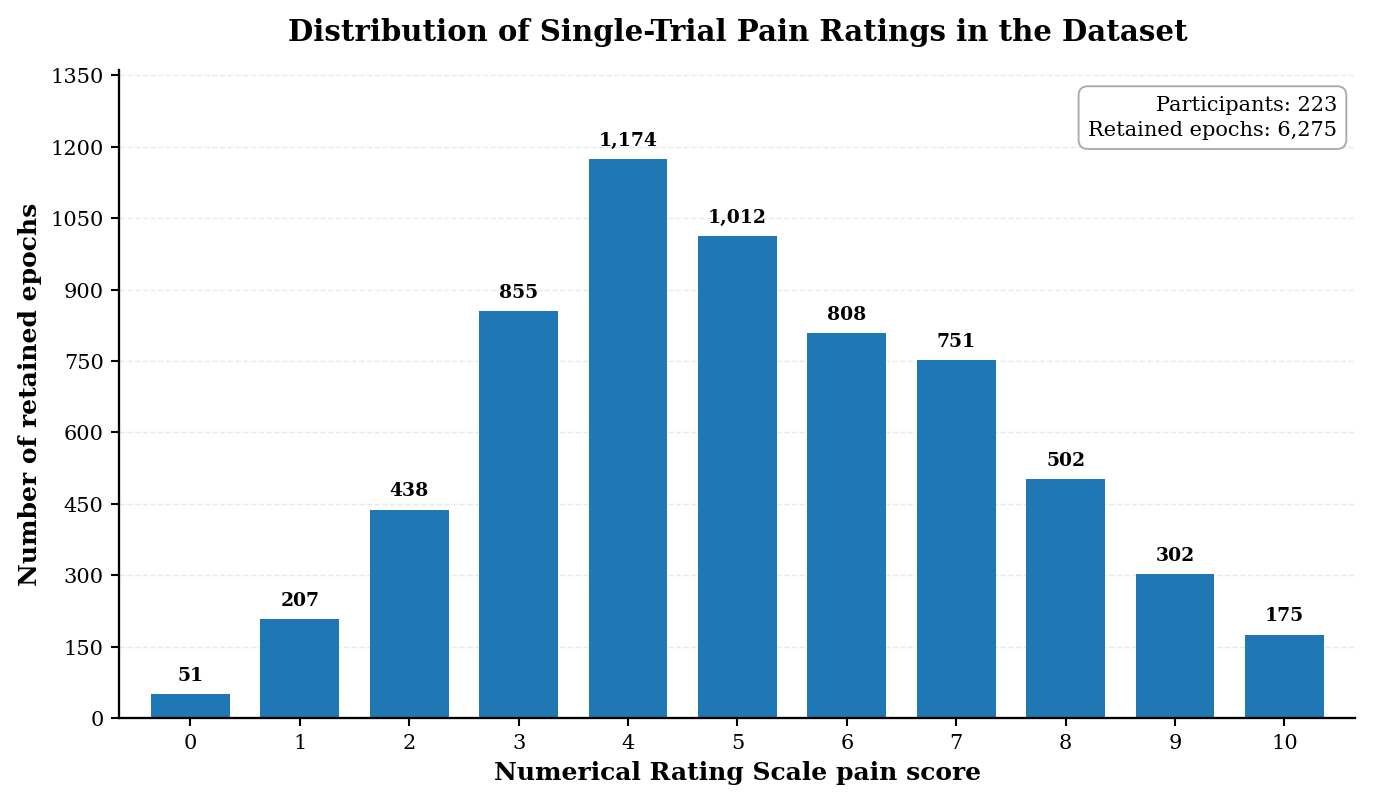

Saved: figure_2_binary_pain_class_distribution.png, figure_2_binary_pain_class_distribution.pdf and figure_2_binary_pain_class_distribution.svg


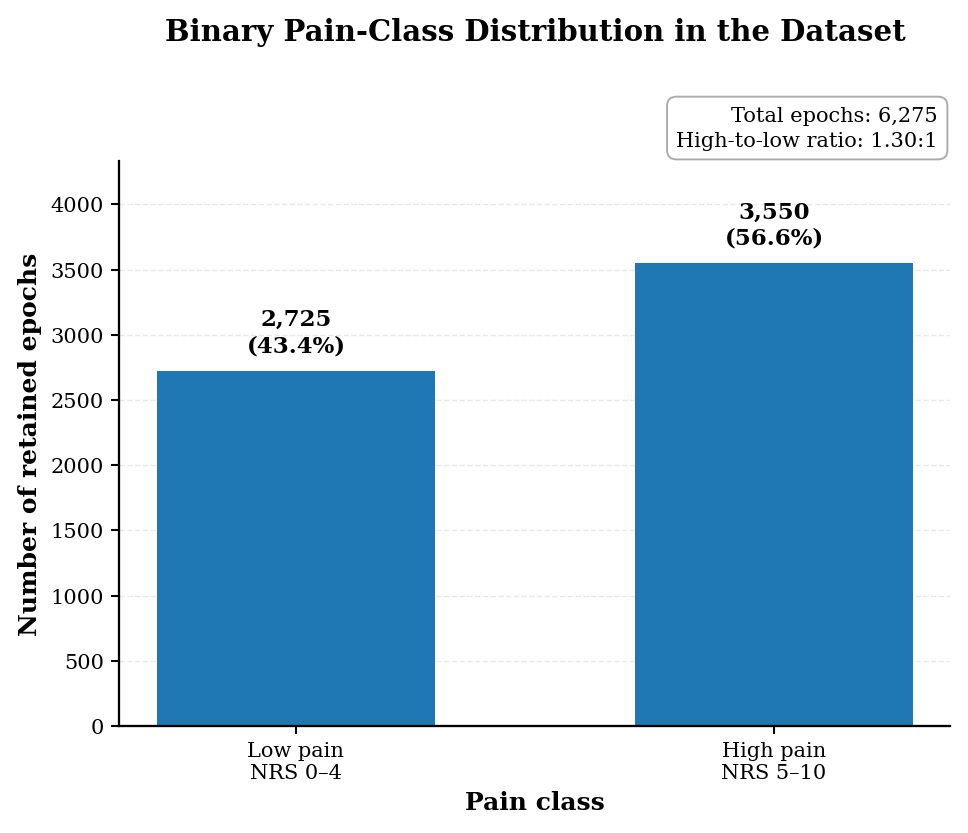

Saved: figure_3_retained_epochs_per_participant.png, figure_3_retained_epochs_per_participant.pdf and figure_3_retained_epochs_per_participant.svg


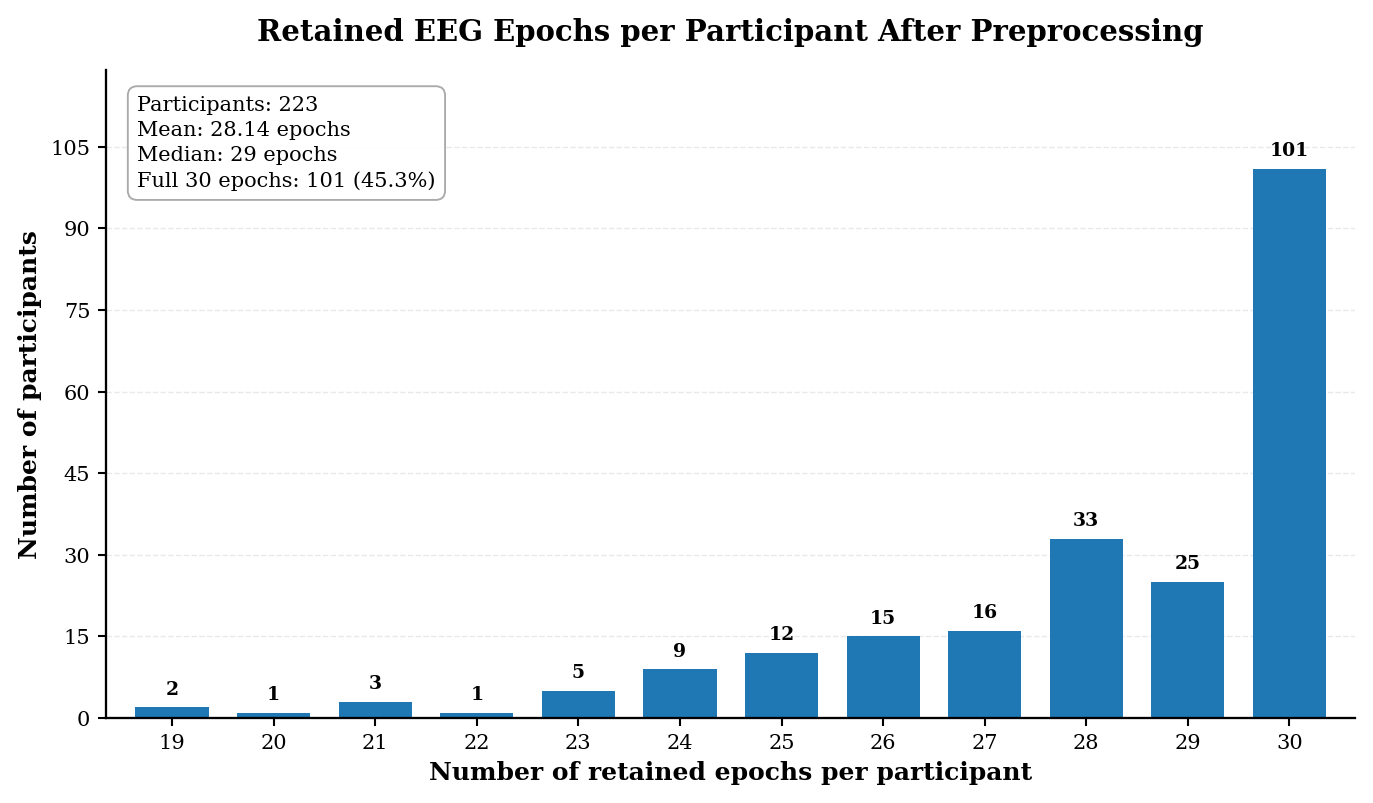


All publication figures were saved in:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/publication_figures


In [ ]:
# CELL 9 — Publication-quality figures

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# 1. Output directory
# ============================================================

FIG_DIR = (
    "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "publication_figures"
)

os.makedirs(FIG_DIR, exist_ok=True)

# ============================================================
# 2. Publication-style global settings
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.1,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


def clean_axes(ax, grid_axis="y"):
    """Apply a clean publication-style appearance."""

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=1
    )

    ax.grid(
        axis=grid_axis,
        linestyle="--",
        linewidth=0.7,
        alpha=0.28
    )

    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(
        MaxNLocator(integer=True)
    )


def save_figure(fig, filename):
    """Save a figure in PNG, PDF, and SVG formats."""

    for extension in ["png", "pdf", "svg"]:
        path = os.path.join(
            FIG_DIR,
            f"{filename}.{extension}"
        )

        fig.savefig(
            path,
            format=extension,
            bbox_inches="tight"
        )

    print(
        f"Saved: {filename}.png, "
        f"{filename}.pdf and "
        f"{filename}.svg"
    )


# ============================================================
# 3. Validate required columns
# ============================================================

required_columns = {
    "subject_id",
    "trial_num",
    "painrating",
    "pain_label",
    "pain_class"
}

missing_columns = required_columns.difference(
    meta_df.columns
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: "
        f"{sorted(missing_columns)}"
    )

# Generate participant-level summary
subject_label_summary = (
    meta_df
    .groupby("subject_id")
    .agg(
        n_trials=("trial_num", "count"),
        n_low=(
            "pain_label",
            lambda x: (x == 0).sum()
        ),
        n_high=(
            "pain_label",
            lambda x: (x == 1).sum()
        )
    )
    .reset_index()
)

total_epochs = len(meta_df)

total_subjects = (
    meta_df["subject_id"]
    .nunique()
)

# ============================================================
# FIGURE 1 — NRS pain-rating distribution
# ============================================================

rating_counts = (
    meta_df["painrating"]
    .value_counts()
    .reindex(range(11), fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    constrained_layout=True
)

bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    width=0.72
)

ax.set_title(
    "Distribution of Single-Trial Pain Ratings in the Dataset",
    pad=14
)

ax.set_xlabel(
    "Numerical Rating Scale pain score"
)

ax.set_ylabel(
    "Number of retained epochs"
)

ax.set_xticks(range(11))
ax.set_xlim(-0.65, 10.65)

upper_limit = rating_counts.max() * 1.16
ax.set_ylim(0, upper_limit)

clean_axes(ax)

# Count labels above bars
for bar, count in zip(
    bars,
    rating_counts.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + upper_limit * 0.015,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Dataset information box
ax.text(
    0.985,
    0.96,
    (
        f"Participants: {total_subjects}\n"
        f"Retained epochs: {total_epochs:,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    linespacing=1.4,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "0.65",
        "linewidth": 0.9,
        "alpha": 0.95
    }
)

save_figure(
    fig,
    "figure_1_nrs_pain_rating_distribution"
)

plt.show()

# ============================================================
# FIGURE 2 — Binary pain-class distribution
# ============================================================

class_order = [
    "low_pain",
    "high_pain"
]

class_counts = (
    meta_df["pain_class"]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

class_labels = [
    "Low pain\nNRS 0–4",
    "High pain\nNRS 5–10"
]

class_percentages = (
    class_counts /
    class_counts.sum() *
    100
)

fig, ax = plt.subplots(
    figsize=(6.3, 5.4),
    constrained_layout=True
)

bars = ax.bar(
    class_labels,
    class_counts.values,
    width=0.58
)

# Increased padding provides room for the information box
ax.set_title(
    "Binary Pain-Class Distribution in the Dataset",
    pad=58
)

ax.set_xlabel("Pain class")

ax.set_ylabel(
    "Number of retained epochs"
)

upper_limit = (
    class_counts.max() * 1.22
)

ax.set_ylim(
    0,
    upper_limit
)

clean_axes(ax)

# Add count and percentage above each bar
for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + upper_limit * 0.025,
        (
            f"{count:,}\n"
            f"({percentage:.1f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        linespacing=1.25
    )

# Calculate imbalance ratio
low_count = class_counts.loc["low_pain"]
high_count = class_counts.loc["high_pain"]

imbalance_ratio = (
    high_count / low_count
    if low_count > 0
    else np.nan
)

# ------------------------------------------------------------
# Corrected position:
# y = 1.02 places the box above the plotting area
# clip_on=False ensures that it remains visible
# ------------------------------------------------------------

ax.text(
    0.985,
    1.02,
    (
        f"Total epochs: {total_epochs:,}\n"
        f"High-to-low ratio: "
        f"{imbalance_ratio:.2f}:1"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    linespacing=1.4,
    clip_on=False,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "0.65",
        "linewidth": 0.9,
        "alpha": 0.95
    }
)

save_figure(
    fig,
    "figure_2_binary_pain_class_distribution"
)

plt.show()

# ============================================================
# FIGURE 3 — Retained epochs per participant
# ============================================================

epoch_count_distribution = (
    subject_label_summary["n_trials"]
    .value_counts()
    .sort_index()
)

full_epoch_range = range(
    int(
        subject_label_summary[
            "n_trials"
        ].min()
    ),
    int(
        subject_label_summary[
            "n_trials"
        ].max()
    ) + 1
)

epoch_count_distribution = (
    epoch_count_distribution
    .reindex(
        full_epoch_range,
        fill_value=0
    )
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    constrained_layout=True
)

bars = ax.bar(
    epoch_count_distribution.index,
    epoch_count_distribution.values,
    width=0.72
)

ax.set_title(
    "Retained EEG Epochs per Participant After Preprocessing",
    pad=14
)

ax.set_xlabel(
    "Number of retained epochs per participant"
)

ax.set_ylabel(
    "Number of participants"
)

ax.set_xticks(
    list(full_epoch_range)
)

ax.set_xlim(
    min(full_epoch_range) - 0.65,
    max(full_epoch_range) + 0.65
)

upper_limit = (
    epoch_count_distribution.max() *
    1.18
)

ax.set_ylim(
    0,
    upper_limit
)

clean_axes(ax)

# Count labels above bars
for bar, count in zip(
    bars,
    epoch_count_distribution.values
):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + upper_limit * 0.014,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

complete_subjects = int(
    (
        subject_label_summary["n_trials"] == 30
    ).sum()
)

complete_percentage = (
    complete_subjects /
    total_subjects *
    100
)

mean_epochs = (
    subject_label_summary["n_trials"]
    .mean()
)

median_epochs = (
    subject_label_summary["n_trials"]
    .median()
)

ax.text(
    0.025,
    0.96,
    (
        f"Participants: {total_subjects}\n"
        f"Mean: {mean_epochs:.2f} epochs\n"
        f"Median: {median_epochs:.0f} epochs\n"
        f"Full 30 epochs: {complete_subjects} "
        f"({complete_percentage:.1f}%)"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    linespacing=1.4,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "0.65",
        "linewidth": 0.9,
        "alpha": 0.95
    }
)

save_figure(
    fig,
    "figure_3_retained_epochs_per_participant"
)

plt.show()

# ============================================================
# 4. Print saved location
# ============================================================

print(
    "\nAll publication figures were saved in:"
)

print(FIG_DIR)

In [ ]:
# CELL 10 — V5 configuration, output paths, and selected channels

from scipy.signal import butter, sosfiltfilt, welch
from scipy.stats import skew, kurtosis

V5_DIR = os.path.join(
    OUT_DIR,
    "V5_MAIN_PIPELINE_12CH"
)
os.makedirs(V5_DIR, exist_ok=True)

# Original compact montage plus C3 and C4 for stronger bilateral
# central and contralateral N1/LEP coverage.
# FCz is excluded because it is absent from the Exp8 channel list.
V5_CHANNELS = [
    "Fz",
    "FC1", "FC2",
    "C3", "C1", "Cz", "C2", "C4",
    "CP1", "CPz", "CP2",
    "Pz",
]

FS_EXPECTED = 1000.0
BASELINE_RANGE_MS = (-1000.0, 0.0)
RESPONSE_RANGE_MS = (0.0, 1000.0)
BATCH_SIZE = 128

print("V5 output directory:", V5_DIR)
print("Selected channels:", V5_CHANNELS)
print("Number of selected channels:", len(V5_CHANNELS))



V5 output directory: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH
Selected channels: ['Fz', 'FC1', 'FC2', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP1', 'CPz', 'CP2', 'Pz']
Number of selected channels: 12


In [ ]:
# CELL 11 — Strict channel audit across all 223 subjects

def get_channel_labels_strict(chanlocs, nbchan):
    labels = []

    if isinstance(chanlocs, dict) and "labels" in chanlocs:
        labels = [
            str(value)
            for value in np.asarray(
                chanlocs["labels"],
                dtype=object
            ).flatten()
        ]

    elif isinstance(chanlocs, list):
        for channel in chanlocs:
            if isinstance(channel, dict) and "labels" in channel:
                labels.append(
                    str(safe_scalar(channel["labels"]))
                )

    labels = [
        clean_channel_name(label)
        for label in labels
        if str(label).strip() != ""
    ]

    if len(labels) != nbchan:
        raise ValueError(
            f"Channel-label count mismatch: "
            f"labels={len(labels)}, nbchan={nbchan}"
        )

    return labels


v5_inventory_rows = []
v5_missing_rows = []

for set_path in tqdm(
    set_files,
    desc="Auditing V5 channels"
):
    mat = read_mat(set_path)
    sid = get_subject_id(set_path)

    nbchan = int(safe_scalar(mat["nbchan"]))
    labels = get_channel_labels_strict(
        mat.get("chanlocs", []),
        nbchan
    )

    label_set = set(labels)
    missing = [
        channel
        for channel in V5_CHANNELS
        if clean_channel_name(channel) not in label_set
    ]

    v5_inventory_rows.append({
        "subject_id": sid,
        "source_file": os.path.basename(set_path),
        "nbchan": nbchan,
        "pnts": int(safe_scalar(mat["pnts"])),
        "trials": int(safe_scalar(mat["trials"])),
        "srate": float(safe_scalar(mat["srate"])),
        "xmin": float(safe_scalar(mat.get("xmin", np.nan))),
        "xmax": float(safe_scalar(mat.get("xmax", np.nan))),
    })

    if missing:
        v5_missing_rows.append({
            "subject_id": sid,
            "source_file": os.path.basename(set_path),
            "missing_channels": ", ".join(missing),
        })

v5_inventory_df = pd.DataFrame(v5_inventory_rows)
v5_missing_df = pd.DataFrame(v5_missing_rows)

v5_inventory_df.to_csv(
    os.path.join(V5_DIR, "v5_subject_inventory.csv"),
    index=False
)
v5_missing_df.to_csv(
    os.path.join(V5_DIR, "v5_missing_channels.csv"),
    index=False
)

print("Subjects audited:", len(v5_inventory_df))
print(
    "Total retained epochs:",
    int(v5_inventory_df["trials"].sum())
)
print(
    "Sampling rates:",
    sorted(v5_inventory_df["srate"].unique())
)
print("\nChannel-count distribution:")
display(
    v5_inventory_df["nbchan"]
    .value_counts()
    .sort_index()
)

if not v5_missing_df.empty:
    display(v5_missing_df)
    raise ValueError(
        "At least one selected V5 channel is missing."
    )

if len(v5_inventory_df) != 223:
    raise ValueError(
        f"Expected 223 subjects, found {len(v5_inventory_df)}."
    )

if not np.allclose(
    v5_inventory_df["srate"].to_numpy(),
    FS_EXPECTED
):
    raise ValueError("Unexpected sampling rate detected.")

print("\nAll 12 V5 channels are present in every subject.")


Auditing V5 channels: 100%|██████████| 223/223 [00:08<00:00, 25.99it/s]

Subjects audited: 223
Total retained epochs: 6275
Sampling rates: [np.float64(1000.0)]

Channel-count distribution:


,count
nbchan,
62,2
63,3
64,218



All 12 V5 channels are present in every subject.


In [ ]:
# CELL 12 — Read .set/.fdt files and save aligned 12-channel epochs

X_BASELINE_PATH = os.path.join(
    V5_DIR,
    "X_v5_baseline_raw_12ch.npy"
)
X_RESPONSE_PATH = os.path.join(
    V5_DIR,
    "X_v5_response_raw_12ch.npy"
)
V5_METADATA_PATH = os.path.join(
    V5_DIR,
    "v5_metadata_aligned.csv"
)

first_mat = read_mat(set_files[0])
first_times = get_times_ms(first_mat)

baseline_indices = np.where(
    (first_times >= BASELINE_RANGE_MS[0])
    & (first_times < BASELINE_RANGE_MS[1])
)[0]

response_indices = np.where(
    (first_times >= RESPONSE_RANGE_MS[0])
    & (first_times < RESPONSE_RANGE_MS[1])
)[0]

if len(baseline_indices) != 1000:
    raise ValueError(
        f"Expected 1000 baseline samples, "
        f"found {len(baseline_indices)}."
    )

if len(response_indices) != 1000:
    raise ValueError(
        f"Expected 1000 response samples, "
        f"found {len(response_indices)}."
    )

baseline_times_ms = first_times[baseline_indices]
response_times_ms = first_times[response_indices]

np.save(
    os.path.join(V5_DIR, "baseline_times_ms.npy"),
    baseline_times_ms
)
np.save(
    os.path.join(V5_DIR, "response_times_ms.npy"),
    response_times_ms
)
pd.DataFrame({"channel": V5_CHANNELS}).to_csv(
    os.path.join(V5_DIR, "v5_selected_channels.csv"),
    index=False
)

n_total_epochs = int(v5_inventory_df["trials"].sum())
n_v5_channels = len(V5_CHANNELS)

X_v5_baseline = np.lib.format.open_memmap(
    X_BASELINE_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        n_total_epochs,
        n_v5_channels,
        len(baseline_indices)
    )
)

X_v5_response = np.lib.format.open_memmap(
    X_RESPONSE_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        n_total_epochs,
        n_v5_channels,
        len(response_indices)
    )
)

aligned_metadata_rows = []
cursor = 0

for set_path in tqdm(
    set_files,
    desc="Extracting aligned 12-channel epochs"
):
    mat = read_mat(set_path)
    sid = get_subject_id(set_path)

    data = load_eeg_data_from_set(
        mat,
        set_path,
        REREFER_DIR
    )

    nbchan = int(safe_scalar(mat["nbchan"]))
    n_trials = int(safe_scalar(mat["trials"]))

    labels = get_channel_labels_strict(
        mat.get("chanlocs", []),
        nbchan
    )
    label_to_index = {
        clean_channel_name(channel): index
        for index, channel in enumerate(labels)
    }

    channel_indices = [
        label_to_index[clean_channel_name(channel)]
        for channel in V5_CHANNELS
    ]

    current_times = get_times_ms(mat)
    current_baseline_indices = np.where(
        (current_times >= BASELINE_RANGE_MS[0])
        & (current_times < BASELINE_RANGE_MS[1])
    )[0]
    current_response_indices = np.where(
        (current_times >= RESPONSE_RANGE_MS[0])
        & (current_times < RESPONSE_RANGE_MS[1])
    )[0]

    if not np.allclose(
        current_times[current_baseline_indices],
        baseline_times_ms
    ):
        raise ValueError(
            f"Baseline time grid mismatch in {set_path}."
        )

    if not np.allclose(
        current_times[current_response_indices],
        response_times_ms
    ):
        raise ValueError(
            f"Response time grid mismatch in {set_path}."
        )

    selected = data[channel_indices, :, :]

    baseline_block = np.transpose(
        selected[:, current_baseline_indices, :],
        (2, 0, 1)
    ).astype(np.float32, copy=False)

    response_block = np.transpose(
        selected[:, current_response_indices, :],
        (2, 0, 1)
    ).astype(np.float32, copy=False)

    start = cursor
    stop = cursor + n_trials

    X_v5_baseline[start:stop] = baseline_block
    X_v5_response[start:stop] = response_block

    pain, laser, event_type = (
        extract_trial_metadata_from_epoch(
            mat,
            n_trials
        )
    )

    for trial_index in range(n_trials):
        aligned_metadata_rows.append({
            "experiment": EXP_NAME,
            "subject_id": sid,
            "trial_num": trial_index + 1,
            "painrating": safe_scalar(
                pain[trial_index]
            ),
            "laser_power": safe_scalar(
                laser[trial_index]
            ),
            "event_type": safe_scalar(
                event_type[trial_index]
            ),
            "source_file": os.path.basename(set_path),
        })

    cursor = stop

    del (
        mat,
        data,
        selected,
        baseline_block,
        response_block
    )

X_v5_baseline.flush()
X_v5_response.flush()

if cursor != n_total_epochs:
    raise RuntimeError(
        f"Extracted {cursor} epochs; "
        f"expected {n_total_epochs}."
    )

v5_meta_df = pd.DataFrame(aligned_metadata_rows)

v5_meta_df["painrating"] = pd.to_numeric(
    v5_meta_df["painrating"],
    errors="coerce"
)
v5_meta_df["laser_power"] = pd.to_numeric(
    v5_meta_df["laser_power"],
    errors="coerce"
)

if v5_meta_df["painrating"].isna().any():
    raise ValueError("Missing pain ratings found.")

if v5_meta_df["laser_power"].isna().any():
    raise ValueError("Missing laser-power values found.")

v5_meta_df["pain_label"] = (
    v5_meta_df["painrating"] >= 5
).astype(np.int8)

v5_meta_df["pain_class"] = np.where(
    v5_meta_df["pain_label"] == 1,
    "high_pain",
    "low_pain"
)

# Compare the newly generated metadata against the metadata
# already loaded in the original part of this notebook.
alignment_columns = [
    "subject_id",
    "trial_num",
    "source_file"
]

if not v5_meta_df[alignment_columns].reset_index(
    drop=True
).equals(
    meta_df[alignment_columns].reset_index(drop=True)
):
    raise ValueError(
        "V5 epoch rows do not match the existing metadata order."
    )

if not np.allclose(
    v5_meta_df["painrating"].to_numpy(float),
    meta_df["painrating"].to_numpy(float)
):
    raise ValueError(
        "Pain-rating alignment mismatch."
    )

if not np.allclose(
    v5_meta_df["laser_power"].to_numpy(float),
    meta_df["laser_power"].to_numpy(float)
):
    raise ValueError(
        "Laser-power alignment mismatch."
    )

v5_meta_df.to_csv(
    V5_METADATA_PATH,
    index=False
)

np.save(
    os.path.join(V5_DIR, "y_v5_binary.npy"),
    v5_meta_df["pain_label"].to_numpy(np.int8)
)
np.save(
    os.path.join(V5_DIR, "groups_v5_subject.npy"),
    v5_meta_df["subject_id"].to_numpy()
)
np.save(
    os.path.join(V5_DIR, "painrating_v5.npy"),
    v5_meta_df["painrating"].to_numpy(np.float32)
)
np.save(
    os.path.join(V5_DIR, "laser_power_v5.npy"),
    v5_meta_df["laser_power"].to_numpy(np.float32)
)

print("Baseline epochs:", X_v5_baseline.shape)
print("Response epochs:", X_v5_response.shape)
print("Metadata:", v5_meta_df.shape)
print(
    "Class counts [low, high]:",
    np.bincount(v5_meta_df["pain_label"])
)
print("Epoch/metadata alignment verified.")


Extracting aligned 12-channel epochs: 100%|██████████| 223/223 [06:52<00:00,  1.85s/it]


Baseline epochs: (6275, 12, 1000)
Response epochs: (6275, 12, 1000)
Metadata: (6275, 9)
Class counts [low, high]: [2725 3550]
Epoch/metadata alignment verified.


In [ ]:
# CELL 13 — Reload arrays and perform strict V5 quality control

X_v5_baseline = np.load(
    X_BASELINE_PATH,
    mmap_mode="r"
)
X_v5_response = np.load(
    X_RESPONSE_PATH,
    mmap_mode="r"
)
v5_meta_df = pd.read_csv(V5_METADATA_PATH)

y_v5 = v5_meta_df["pain_label"].to_numpy(np.int8)
groups_v5 = v5_meta_df["subject_id"].to_numpy()
painrating_v5 = v5_meta_df[
    "painrating"
].to_numpy(np.float32)
laser_power_v5 = v5_meta_df[
    "laser_power"
].to_numpy(np.float32)

assert X_v5_baseline.shape == X_v5_response.shape
assert X_v5_baseline.shape == (6275, 12, 1000)
assert len(y_v5) == 6275
assert len(groups_v5) == 6275
assert len(np.unique(groups_v5)) == 223
assert np.array_equal(
    np.bincount(y_v5),
    np.array([2725, 3550])
)

minimum_baseline_sd = np.inf

for start in tqdm(
    range(0, len(y_v5), BATCH_SIZE),
    desc="Checking V5 epoch arrays"
):
    stop = min(
        start + BATCH_SIZE,
        len(y_v5)
    )

    baseline_batch = np.asarray(
        X_v5_baseline[start:stop]
    )
    response_batch = np.asarray(
        X_v5_response[start:stop]
    )

    if not np.isfinite(baseline_batch).all():
        raise ValueError(
            f"Non-finite baseline values in "
            f"rows {start}:{stop}."
        )

    if not np.isfinite(response_batch).all():
        raise ValueError(
            f"Non-finite response values in "
            f"rows {start}:{stop}."
        )

    current_sd = baseline_batch.std(axis=-1)
    minimum_baseline_sd = min(
        minimum_baseline_sd,
        float(current_sd.min())
    )

    if np.any(current_sd < 1e-8):
        raise ValueError(
            f"Near-zero baseline variance in "
            f"rows {start}:{stop}."
        )

print("All V5 quality checks passed.")
print(
    "Minimum trial/channel baseline SD:",
    minimum_baseline_sd
)


Checking V5 epoch arrays: 100%|██████████| 50/50 [00:03<00:00, 13.52it/s]

All V5 quality checks passed.
Minimum trial/channel baseline SD: 1.3309264183044434


In [ ]:
# CELL 14 — Define all handcrafted V5 features

# Gamma is not extracted from the stored rereferenced data.
# The full valid handcrafted representation is retained:
# 21 features/channel × 12 channels + 10 global = 262.

HANDCRAFTED_WINDOWS = {
    "early_0_200": (0, 200),
    "n2_180_350": (180, 350),
    "p2_300_600": (300, 600),
    "late_600_1000": (600, 1000),
    "global_0_1000": (0, 1000),
}

HANDCRAFTED_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
}


def histogram_entropy(signal, bins=20):
    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)]

    if signal.size == 0:
        return np.nan

    counts, _ = np.histogram(
        signal,
        bins=bins
    )
    probabilities = counts.astype(float)
    probabilities = probabilities[
        probabilities > 0
    ]
    probabilities /= probabilities.sum()

    return float(
        -np.sum(
            probabilities
            * np.log(probabilities + 1e-12)
        )
    )


def create_handcrafted_feature_names(channels):
    per_channel = [
        *[
            f"{window_name}_mean"
            for window_name in HANDCRAFTED_WINDOWS
        ],
        "n2_amp",
        "n2_latency_ms",
        "p2_amp",
        "p2_latency_ms",
        "n2p2_peak_to_peak",
        *[
            f"{band_name}_power"
            for band_name in HANDCRAFTED_BANDS
        ],
        "hjorth_activity",
        "hjorth_mobility",
        "hjorth_complexity",
        "entropy",
        "standard_deviation",
        "skewness",
        "kurtosis",
    ]

    names = []

    for channel in channels:
        names.extend([
            f"{channel}__{feature_name}"
            for feature_name in per_channel
        ])

    names.extend([
        *[
            f"GLOBAL__{window_name}_mean"
            for window_name in HANDCRAFTED_WINDOWS
        ],
        "GLOBAL__n2_amp",
        "GLOBAL__n2_latency_ms",
        "GLOBAL__p2_amp",
        "GLOBAL__p2_latency_ms",
        "GLOBAL__n2p2_peak_to_peak",
    ])

    return names


V5_HANDCRAFTED_NAMES = (
    create_handcrafted_feature_names(
        V5_CHANNELS
    )
)

print(
    "Handcrafted feature count:",
    len(V5_HANDCRAFTED_NAMES)
)

assert len(V5_HANDCRAFTED_NAMES) == 262


Handcrafted feature count: 262


In [ ]:
# CELL 14A — Display all 262 handcrafted feature names

feature_names_df = pd.DataFrame({
    "feature_index": np.arange(
        1,
        len(V5_HANDCRAFTED_NAMES) + 1
    ),
    "feature_name": V5_HANDCRAFTED_NAMES
})

print(
    "Total handcrafted features:",
    len(feature_names_df)
)

display(feature_names_df)

Total handcrafted features: 262


,feature_index,feature_name
0,1,Fz__early_0_200_mean
1,2,Fz__n2_180_350_mean
2,3,Fz__p2_300_600_mean
3,4,Fz__late_600_1000_mean
4,5,Fz__global_0_1000_mean
...,...,...
257,258,GLOBAL__n2_amp
258,259,GLOBAL__n2_latency_ms
259,260,GLOBAL__p2_amp
260,261,GLOBAL__p2_latency_ms


In [ ]:
# CELL 15 — Extract all 262 baseline-normalized handcrafted features

X_HANDCRAFTED_PATH = os.path.join(
    V5_DIR,
    "X_v5_handcrafted_all_262.npy"
)
HANDCRAFTED_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_handcrafted_feature_names_262.csv"
)

response_times_ms = np.load(
    os.path.join(V5_DIR, "response_times_ms.npy")
)

handcrafted_window_indices = {
    name: np.where(
        (response_times_ms >= start_ms)
        & (response_times_ms < end_ms)
    )[0]
    for name, (start_ms, end_ms)
    in HANDCRAFTED_WINDOWS.items()
}

n2_indices = np.where(
    (response_times_ms >= 180)
    & (response_times_ms < 350)
)[0]

p2_indices = np.where(
    (response_times_ms >= 300)
    & (response_times_ms < 600)
)[0]

X_v5_handcrafted = np.lib.format.open_memmap(
    X_HANDCRAFTED_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        len(y_v5),
        len(V5_HANDCRAFTED_NAMES)
    )
)

for start in tqdm(
    range(0, len(y_v5), BATCH_SIZE),
    desc="Extracting V5 handcrafted features"
):
    stop = min(
        start + BATCH_SIZE,
        len(y_v5)
    )

    baseline_batch = np.asarray(
        X_v5_baseline[start:stop],
        dtype=np.float64
    )
    response_batch = np.asarray(
        X_v5_response[start:stop],
        dtype=np.float64
    )

    baseline_mean = baseline_batch.mean(
        axis=-1,
        keepdims=True
    )
    baseline_sd = baseline_batch.std(
        axis=-1,
        keepdims=True
    )
    baseline_sd = np.maximum(
        baseline_sd,
        1e-8
    )

    # Same-trial, same-channel baseline z-normalization.
    normalized_response = (
        response_batch - baseline_mean
    ) / baseline_sd

    current_batch_size = (
        normalized_response.shape[0]
    )
    n_channels = normalized_response.shape[1]

    channel_features = np.empty(
        (
            current_batch_size,
            n_channels,
            21
        ),
        dtype=np.float64
    )

    feature_index = 0

    # Five temporal mean features.
    for window_name in HANDCRAFTED_WINDOWS:
        indices = handcrafted_window_indices[
            window_name
        ]
        channel_features[
            :,
            :,
            feature_index
        ] = normalized_response[
            :,
            :,
            indices
        ].mean(axis=-1)
        feature_index += 1

    # N2 and P2 morphology.
    n2_segment = normalized_response[
        :,
        :,
        n2_indices
    ]
    n2_argmin = np.argmin(
        n2_segment,
        axis=-1
    )
    n2_amplitude = np.take_along_axis(
        n2_segment,
        n2_argmin[..., None],
        axis=-1
    )[..., 0]
    n2_latency = (
        response_times_ms[n2_indices][
            n2_argmin
        ]
    )

    p2_segment = normalized_response[
        :,
        :,
        p2_indices
    ]
    p2_argmax = np.argmax(
        p2_segment,
        axis=-1
    )
    p2_amplitude = np.take_along_axis(
        p2_segment,
        p2_argmax[..., None],
        axis=-1
    )[..., 0]
    p2_latency = (
        response_times_ms[p2_indices][
            p2_argmax
        ]
    )

    for values in [
        n2_amplitude,
        n2_latency,
        p2_amplitude,
        p2_latency,
        p2_amplitude - n2_amplitude,
    ]:
        channel_features[
            :,
            :,
            feature_index
        ] = values
        feature_index += 1

    # Delta, theta, alpha, and beta power.
    frequencies, power_spectral_density = welch(
        normalized_response,
        fs=FS_EXPECTED,
        nperseg=min(
            512,
            normalized_response.shape[-1]
        ),
        axis=-1
    )

    for fmin, fmax in HANDCRAFTED_BANDS.values():
        frequency_mask = (
            (frequencies >= fmin)
            & (frequencies <= fmax)
        )

        channel_features[
            :,
            :,
            feature_index
        ] = np.trapz(
            power_spectral_density[
                :,
                :,
                frequency_mask
            ],
            frequencies[frequency_mask],
            axis=-1
        )
        feature_index += 1

    # Hjorth parameters.
    first_difference = np.diff(
        normalized_response,
        axis=-1
    )
    second_difference = np.diff(
        first_difference,
        axis=-1
    )

    variance_zero = np.var(
        normalized_response,
        axis=-1
    )
    variance_one = np.var(
        first_difference,
        axis=-1
    )
    variance_two = np.var(
        second_difference,
        axis=-1
    )

    mobility = np.sqrt(
        np.divide(
            variance_one,
            variance_zero,
            out=np.zeros_like(variance_one),
            where=variance_zero > 0
        )
    )

    complexity = np.divide(
        np.sqrt(
            np.divide(
                variance_two,
                variance_one,
                out=np.zeros_like(variance_two),
                where=variance_one > 0
            )
        ),
        mobility,
        out=np.zeros_like(mobility),
        where=mobility > 0
    )

    for values in [
        variance_zero,
        mobility,
        complexity,
    ]:
        channel_features[
            :,
            :,
            feature_index
        ] = values
        feature_index += 1

    entropy_values = np.empty(
        (
            current_batch_size,
            n_channels
        ),
        dtype=np.float64
    )

    for row_index in range(
        current_batch_size
    ):
        for channel_index in range(
            n_channels
        ):
            entropy_values[
                row_index,
                channel_index
            ] = histogram_entropy(
                normalized_response[
                    row_index,
                    channel_index
                ]
            )

    channel_features[
        :,
        :,
        feature_index
    ] = entropy_values
    feature_index += 1

    channel_features[
        :,
        :,
        feature_index
    ] = np.std(
        normalized_response,
        axis=-1
    )
    feature_index += 1

    channel_features[
        :,
        :,
        feature_index
    ] = skew(
        normalized_response,
        axis=-1,
        bias=False,
        nan_policy="omit"
    )
    feature_index += 1

    channel_features[
        :,
        :,
        feature_index
    ] = kurtosis(
        normalized_response,
        axis=-1,
        bias=False,
        nan_policy="omit"
    )
    feature_index += 1

    assert feature_index == 21

    # Ten global features from the 12-channel average.
    global_signal = normalized_response.mean(
        axis=1
    )
    global_features = np.empty(
        (
            current_batch_size,
            10
        ),
        dtype=np.float64
    )

    global_index = 0

    for window_name in HANDCRAFTED_WINDOWS:
        indices = handcrafted_window_indices[
            window_name
        ]
        global_features[
            :,
            global_index
        ] = global_signal[
            :,
            indices
        ].mean(axis=-1)
        global_index += 1

    global_n2_segment = global_signal[
        :,
        n2_indices
    ]
    global_n2_argmin = np.argmin(
        global_n2_segment,
        axis=-1
    )
    global_n2_amplitude = np.take_along_axis(
        global_n2_segment,
        global_n2_argmin[:, None],
        axis=-1
    )[:, 0]
    global_n2_latency = (
        response_times_ms[n2_indices][
            global_n2_argmin
        ]
    )

    global_p2_segment = global_signal[
        :,
        p2_indices
    ]
    global_p2_argmax = np.argmax(
        global_p2_segment,
        axis=-1
    )
    global_p2_amplitude = np.take_along_axis(
        global_p2_segment,
        global_p2_argmax[:, None],
        axis=-1
    )[:, 0]
    global_p2_latency = (
        response_times_ms[p2_indices][
            global_p2_argmax
        ]
    )

    for values in [
        global_n2_amplitude,
        global_n2_latency,
        global_p2_amplitude,
        global_p2_latency,
        (
            global_p2_amplitude
            - global_n2_amplitude
        ),
    ]:
        global_features[
            :,
            global_index
        ] = values
        global_index += 1

    assert global_index == 10

    batch_features = np.concatenate(
        [
            channel_features.reshape(
                current_batch_size,
                -1
            ),
            global_features,
        ],
        axis=1
    )

    if batch_features.shape[1] != 262:
        raise RuntimeError(
            f"Unexpected handcrafted count: "
            f"{batch_features.shape[1]}"
        )

    if not np.isfinite(batch_features).all():
        raise ValueError(
            f"Non-finite handcrafted features "
            f"in rows {start}:{stop}."
        )

    X_v5_handcrafted[
        start:stop
    ] = batch_features.astype(np.float32)

    X_v5_handcrafted.flush()

pd.DataFrame({
    "feature_no": np.arange(
        1,
        len(V5_HANDCRAFTED_NAMES) + 1
    ),
    "feature_name": V5_HANDCRAFTED_NAMES,
}).to_csv(
    HANDCRAFTED_NAMES_PATH,
    index=False
)

print(
    "Handcrafted feature matrix:",
    X_v5_handcrafted.shape
)
print("Saved:", X_HANDCRAFTED_PATH)


Extracting V5 handcrafted features: 100%|██████████| 50/50 [00:24<00:00,  2.01it/s]

Handcrafted feature matrix: (6275, 262)
Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/X_v5_handcrafted_all_262.npy


In [ ]:
# CELL 16 — Baseline-referenced Riemannian helper functions

# Five broadband physiological windows plus four full-response
# frequency-band covariance changes.
RIEMANNIAN_TIME_WINDOWS = {
    "broadband_early_0_200": (0, 200),
    "broadband_n2_180_350": (180, 350),
    "broadband_p2_300_600": (300, 600),
    "broadband_late_600_1000": (600, 1000),
    "broadband_global_0_1000": (0, 1000),
}

RIEMANNIAN_FREQUENCY_BANDS = {
    "delta_full_0_1000": (1, 4),
    "theta_full_0_1000": (4, 8),
    "alpha_full_0_1000": (8, 13),
    "beta_full_0_1000": (13, 30),
}


def batch_oas_covariance(
    signals,
    epsilon=1e-10
):
    signals = np.asarray(
        signals,
        dtype=np.float64
    )

    batch_size, n_channels, n_samples = (
        signals.shape
    )

    centered = signals - signals.mean(
        axis=-1,
        keepdims=True
    )

    empirical = np.einsum(
        "bct,bdt->bcd",
        centered,
        centered,
        optimize=True
    ) / float(n_samples)

    alpha = np.mean(
        empirical ** 2,
        axis=(1, 2)
    )
    mu = np.trace(
        empirical,
        axis1=1,
        axis2=2
    ) / float(n_channels)
    mu_squared = mu ** 2

    numerator = alpha + mu_squared
    denominator = (
        (n_samples + 1.0)
        * (
            alpha
            - mu_squared / float(n_channels)
        )
    )

    shrinkage = np.ones(
        batch_size,
        dtype=np.float64
    )
    valid = np.abs(denominator) > epsilon

    shrinkage[valid] = np.minimum(
        numerator[valid]
        / denominator[valid],
        1.0
    )
    shrinkage = np.clip(
        shrinkage,
        0.0,
        1.0
    )

    covariance = (
        (1.0 - shrinkage)[:, None, None]
        * empirical
    )

    diagonal = np.arange(n_channels)
    covariance[
        :,
        diagonal,
        diagonal
    ] += shrinkage[:, None] * mu[:, None]

    scale = np.maximum(mu, epsilon)
    covariance[
        :,
        diagonal,
        diagonal
    ] += epsilon * scale[:, None]

    covariance = 0.5 * (
        covariance
        + np.transpose(
            covariance,
            (0, 2, 1)
        )
    )

    return covariance


def batch_spd_inverse_sqrt(
    matrices,
    epsilon=1e-10
):
    eigenvalues, eigenvectors = np.linalg.eigh(
        matrices
    )
    eigenvalues = np.clip(
        eigenvalues,
        epsilon,
        None
    )

    scaled_vectors = (
        eigenvectors
        * (
            eigenvalues ** -0.5
        )[:, None, :]
    )

    return (
        scaled_vectors
        @ np.transpose(
            eigenvectors,
            (0, 2, 1)
        )
    )


def batch_spd_log(
    matrices,
    epsilon=1e-10
):
    matrices = 0.5 * (
        matrices
        + np.transpose(
            matrices,
            (0, 2, 1)
        )
    )

    eigenvalues, eigenvectors = np.linalg.eigh(
        matrices
    )
    eigenvalues = np.clip(
        eigenvalues,
        epsilon,
        None
    )

    scaled_vectors = (
        eigenvectors
        * np.log(eigenvalues)[:, None, :]
    )

    logged = (
        scaled_vectors
        @ np.transpose(
            eigenvectors,
            (0, 2, 1)
        )
    )

    return 0.5 * (
        logged
        + np.transpose(
            logged,
            (0, 2, 1)
        )
    )


def batch_relative_log_covariance(
    baseline_covariance,
    response_covariance
):
    inverse_sqrt = batch_spd_inverse_sqrt(
        baseline_covariance
    )

    relative_covariance = (
        inverse_sqrt
        @ response_covariance
        @ inverse_sqrt
    )

    relative_covariance = 0.5 * (
        relative_covariance
        + np.transpose(
            relative_covariance,
            (0, 2, 1)
        )
    )

    return batch_spd_log(
        relative_covariance
    )


def vectorize_symmetric_matrices(matrices):
    n_channels = matrices.shape[1]
    row_indices, column_indices = (
        np.triu_indices(n_channels)
    )

    vectors = matrices[
        :,
        row_indices,
        column_indices
    ].copy()

    off_diagonal = (
        row_indices != column_indices
    )
    vectors[
        :,
        off_diagonal
    ] *= np.sqrt(2.0)

    return vectors


def create_riemannian_feature_names(
    representation_names,
    channels
):
    row_indices, column_indices = (
        np.triu_indices(len(channels))
    )

    names = []

    for representation in representation_names:
        for row_index, column_index in zip(
            row_indices,
            column_indices
        ):
            names.append(
                "RIEM__"
                f"{representation}__"
                f"{channels[row_index]}_"
                f"{channels[column_index]}"
            )

    return names


RIEMANNIAN_REPRESENTATIONS = [
    *RIEMANNIAN_TIME_WINDOWS.keys(),
    *RIEMANNIAN_FREQUENCY_BANDS.keys(),
]

V5_RIEMANNIAN_NAMES = (
    create_riemannian_feature_names(
        RIEMANNIAN_REPRESENTATIONS,
        V5_CHANNELS
    )
)

features_per_covariance = (
    len(V5_CHANNELS)
    * (len(V5_CHANNELS) + 1)
    // 2
)

print(
    "Riemannian representations:",
    RIEMANNIAN_REPRESENTATIONS
)
print(
    "Features per covariance:",
    features_per_covariance
)
print(
    "Total Riemannian features:",
    len(V5_RIEMANNIAN_NAMES)
)

assert features_per_covariance == 78
assert len(V5_RIEMANNIAN_NAMES) == 702


Riemannian representations: ['broadband_early_0_200', 'broadband_n2_180_350', 'broadband_p2_300_600', 'broadband_late_600_1000', 'broadband_global_0_1000', 'delta_full_0_1000', 'theta_full_0_1000', 'alpha_full_0_1000', 'beta_full_0_1000']
Features per covariance: 78
Total Riemannian features: 702


In [ ]:
# CELL 17 — Extract all 702 baseline-referenced Riemannian features

X_RIEMANNIAN_PATH = os.path.join(
    V5_DIR,
    "X_v5_baseline_referenced_riemannian_all_702.npy"
)
RIEMANNIAN_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_riemannian_feature_names_702.csv"
)

response_times_ms = np.load(
    os.path.join(V5_DIR, "response_times_ms.npy")
)

riemannian_window_indices = {
    name: np.where(
        (response_times_ms >= start_ms)
        & (response_times_ms < end_ms)
    )[0]
    for name, (start_ms, end_ms)
    in RIEMANNIAN_TIME_WINDOWS.items()
}

frequency_filters = {
    name: butter(
        4,
        [fmin, fmax],
        btype="bandpass",
        fs=FS_EXPECTED,
        output="sos"
    )
    for name, (fmin, fmax)
    in RIEMANNIAN_FREQUENCY_BANDS.items()
}

X_v5_riemannian = np.lib.format.open_memmap(
    X_RIEMANNIAN_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        len(y_v5),
        len(V5_RIEMANNIAN_NAMES)
    )
)

for start in tqdm(
    range(0, len(y_v5), BATCH_SIZE),
    desc="Extracting V5 Riemannian features"
):
    stop = min(
        start + BATCH_SIZE,
        len(y_v5)
    )

    baseline_batch = np.asarray(
        X_v5_baseline[start:stop],
        dtype=np.float64
    )
    response_batch = np.asarray(
        X_v5_response[start:stop],
        dtype=np.float64
    )

    batch_parts = []

    # Broadband baseline-reference for five physiological windows.
    broadband_baseline_covariance = (
        batch_oas_covariance(
            baseline_batch
        )
    )

    for representation_name in (
        RIEMANNIAN_TIME_WINDOWS
    ):
        window_indices = (
            riemannian_window_indices[
                representation_name
            ]
        )

        response_covariance = (
            batch_oas_covariance(
                response_batch[
                    :,
                    :,
                    window_indices
                ]
            )
        )

        relative_log_covariance = (
            batch_relative_log_covariance(
                broadband_baseline_covariance,
                response_covariance
            )
        )

        batch_parts.append(
            vectorize_symmetric_matrices(
                relative_log_covariance
            )
        )

    # Filter baseline and response together to reduce filter-edge
    # discontinuity at stimulus onset, then split the result.
    continuous_batch = np.concatenate(
        [
            baseline_batch,
            response_batch
        ],
        axis=-1
    )
    split_index = baseline_batch.shape[-1]

    for representation_name, sos_filter in (
        frequency_filters.items()
    ):
        filtered = sosfiltfilt(
            sos_filter,
            continuous_batch,
            axis=-1
        )

        filtered_baseline = filtered[
            :,
            :,
            :split_index
        ]
        filtered_response = filtered[
            :,
            :,
            split_index:
        ]

        baseline_covariance = (
            batch_oas_covariance(
                filtered_baseline
            )
        )
        response_covariance = (
            batch_oas_covariance(
                filtered_response
            )
        )

        relative_log_covariance = (
            batch_relative_log_covariance(
                baseline_covariance,
                response_covariance
            )
        )

        batch_parts.append(
            vectorize_symmetric_matrices(
                relative_log_covariance
            )
        )

        del (
            filtered,
            filtered_baseline,
            filtered_response
        )

    batch_features = np.concatenate(
        batch_parts,
        axis=1
    )

    if batch_features.shape[1] != 702:
        raise RuntimeError(
            f"Unexpected Riemannian count: "
            f"{batch_features.shape[1]}"
        )

    if not np.isfinite(batch_features).all():
        raise ValueError(
            f"Non-finite Riemannian features "
            f"in rows {start}:{stop}."
        )

    X_v5_riemannian[
        start:stop
    ] = batch_features.astype(np.float32)

    X_v5_riemannian.flush()

pd.DataFrame({
    "feature_no": np.arange(
        1,
        len(V5_RIEMANNIAN_NAMES) + 1
    ),
    "feature_name": V5_RIEMANNIAN_NAMES,
}).to_csv(
    RIEMANNIAN_NAMES_PATH,
    index=False
)

print(
    "Riemannian feature matrix:",
    X_v5_riemannian.shape
)
print("Saved:", X_RIEMANNIAN_PATH)


Extracting V5 Riemannian features: 100%|██████████| 50/50 [01:04<00:00,  1.30s/it]

Riemannian feature matrix: (6275, 702)
Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/X_v5_baseline_referenced_riemannian_all_702.npy


In [ ]:
# CELL 18 — Create the full V5 early-fusion feature matrix

X_FUSION_PATH = os.path.join(
    V5_DIR,
    "X_v5_full_fusion_all_964.npy"
)
FUSION_NAMES_PATH = os.path.join(
    V5_DIR,
    "v5_fusion_feature_names_964.csv"
)

X_v5_handcrafted = np.load(
    X_HANDCRAFTED_PATH,
    mmap_mode="r"
)
X_v5_riemannian = np.load(
    X_RIEMANNIAN_PATH,
    mmap_mode="r"
)

assert X_v5_handcrafted.shape == (
    6275,
    262
)
assert X_v5_riemannian.shape == (
    6275,
    702
)

V5_FUSION_NAMES = [
    *[
        f"HAND__{name}"
        for name in V5_HANDCRAFTED_NAMES
    ],
    *V5_RIEMANNIAN_NAMES,
]

assert len(V5_FUSION_NAMES) == 964

X_v5_fusion = np.lib.format.open_memmap(
    X_FUSION_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        len(y_v5),
        len(V5_FUSION_NAMES)
    )
)

for start in tqdm(
    range(0, len(y_v5), BATCH_SIZE),
    desc="Saving full V5 fusion"
):
    stop = min(
        start + BATCH_SIZE,
        len(y_v5)
    )

    X_v5_fusion[
        start:stop,
        :262
    ] = X_v5_handcrafted[start:stop]

    X_v5_fusion[
        start:stop,
        262:
    ] = X_v5_riemannian[start:stop]

X_v5_fusion.flush()

pd.DataFrame({
    "feature_no": np.arange(
        1,
        len(V5_FUSION_NAMES) + 1
    ),
    "feature_name": V5_FUSION_NAMES,
}).to_csv(
    FUSION_NAMES_PATH,
    index=False
)

print(
    "Handcrafted:",
    X_v5_handcrafted.shape
)
print(
    "Riemannian:",
    X_v5_riemannian.shape
)
print(
    "Full fusion:",
    X_v5_fusion.shape
)
print("Saved:", X_FUSION_PATH)


Saving full V5 fusion: 100%|██████████| 50/50 [00:00<00:00, 61.80it/s]


Handcrafted: (6275, 262)
Riemannian: (6275, 702)
Full fusion: (6275, 964)
Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/X_v5_full_fusion_all_964.npy


In [ ]:
# CELL 19 — Final V5 verification and saved-file manifest

X_v5_handcrafted = np.load(
    X_HANDCRAFTED_PATH,
    mmap_mode="r"
)
X_v5_riemannian = np.load(
    X_RIEMANNIAN_PATH,
    mmap_mode="r"
)
X_v5_fusion = np.load(
    X_FUSION_PATH,
    mmap_mode="r"
)

assert X_v5_handcrafted.shape == (6275, 262)
assert X_v5_riemannian.shape == (6275, 702)
assert X_v5_fusion.shape == (6275, 964)
assert len(y_v5) == 6275
assert len(groups_v5) == 6275
assert len(np.unique(groups_v5)) == 223
assert np.array_equal(
    np.bincount(y_v5),
    np.array([2725, 3550])
)

verification_rows = np.unique(
    np.linspace(
        0,
        len(y_v5) - 1,
        num=100,
        dtype=int
    )
)

assert np.isfinite(
    X_v5_handcrafted[verification_rows]
).all()
assert np.isfinite(
    X_v5_riemannian[verification_rows]
).all()
assert np.isfinite(
    X_v5_fusion[verification_rows]
).all()

manifest = pd.DataFrame([
    {
        "artifact": os.path.basename(
            X_BASELINE_PATH
        ),
        "shape": str(X_v5_baseline.shape),
        "role": "Raw prestimulus baseline epochs",
    },
    {
        "artifact": os.path.basename(
            X_RESPONSE_PATH
        ),
        "shape": str(X_v5_response.shape),
        "role": "Raw poststimulus response epochs",
    },
    {
        "artifact": os.path.basename(
            X_HANDCRAFTED_PATH
        ),
        "shape": str(X_v5_handcrafted.shape),
        "role": "Full handcrafted LEP branch",
    },
    {
        "artifact": os.path.basename(
            X_RIEMANNIAN_PATH
        ),
        "shape": str(X_v5_riemannian.shape),
        "role": (
            "Baseline-referenced "
            "Riemannian branch"
        ),
    },
    {
        "artifact": os.path.basename(
            X_FUSION_PATH
        ),
        "shape": str(X_v5_fusion.shape),
        "role": "Full early-fusion representation",
    },
    {
        "artifact": os.path.basename(
            V5_METADATA_PATH
        ),
        "shape": str(v5_meta_df.shape),
        "role": "Aligned trial metadata and labels",
    },
])

manifest_path = os.path.join(
    V5_DIR,
    "v5_feature_extraction_manifest.csv"
)
manifest.to_csv(
    manifest_path,
    index=False
)

display(manifest)

print(
    "Class counts [low, high]:",
    np.bincount(y_v5)
)
print(
    "Subjects:",
    len(np.unique(groups_v5))
)
print(
    "V5 feature extraction completed successfully."
)
# print(
#     "Do not globally scale these matrices. "
#     "Scaling must occur inside LOSO/LOOCV folds."
# )


,artifact,shape,role
0,X_v5_baseline_raw_12ch.npy,"(6275, 12, 1000)",Raw prestimulus baseline epochs
1,X_v5_response_raw_12ch.npy,"(6275, 12, 1000)",Raw poststimulus response epochs
2,X_v5_handcrafted_all_262.npy,"(6275, 262)",Full handcrafted LEP branch
3,X_v5_baseline_referenced_riemannian_all_702.npy,"(6275, 702)",Baseline-referenced Riemannian branch
4,X_v5_full_fusion_all_964.npy,"(6275, 964)",Full early-fusion representation
5,v5_metadata_aligned.csv,"(6275, 9)",Aligned trial metadata and labels


Class counts [low, high]: [2725 3550]
Subjects: 223
V5 feature extraction completed successfully.


#     "Do not globally scale these matrices. "
#     "Scaling must occur inside LOSO/LOOCV folds."

In [ ]:
# CELL 20 — Complete leakage-safe cross-individual LOSO evaluator

import os
import re
import json
import time
import warnings

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. Output directory
# ============================================================

LOSO_RESULTS_DIR = os.path.join(
    V5_DIR,
    "V5_LOSO_RESULTS"
)

os.makedirs(
    LOSO_RESULTS_DIR,
    exist_ok=True
)

print("LOSO evaluator output directory:")
print(LOSO_RESULTS_DIR)


# ============================================================
# 2. Safe file-writing helpers
# ============================================================

def atomic_write_csv(
    dataframe,
    path
):
    """
    Save a CSV through a temporary file.

    This reduces the chance of obtaining a corrupted checkpoint
    if Colab disconnects during file writing.
    """

    temporary_path = f"{path}.tmp"

    dataframe.to_csv(
        temporary_path,
        index=False
    )

    os.replace(
        temporary_path,
        path
    )


def atomic_write_json(
    content,
    path
):
    """
    Save JSON through a temporary file.
    """

    temporary_path = f"{path}.tmp"

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            content,
            file,
            indent=4
        )

    os.replace(
        temporary_path,
        path
    )


def make_safe_filename(text):
    """
    Convert a model or feature-set name into a safe filename.
    """

    text = str(text).strip()

    text = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        text
    )

    return text.strip("_")


# ============================================================
# 3. Obtain continuous prediction scores
# ============================================================

def get_positive_class_scores(
    fitted_model,
    X_test,
    y_pred
):
    """
    Return continuous scores for the positive class:

        0 = Low pain
        1 = High pain

    Priority:
        1. predict_proba()
        2. decision_function()
        3. predicted labels as fallback
    """

    classes = getattr(
        fitted_model,
        "classes_",
        np.array([0, 1])
    )

    classes = np.asarray(
        classes
    )

    positive_indices = np.flatnonzero(
        classes == 1
    )

    if len(positive_indices) == 0:
        raise ValueError(
            "The fitted classifier does not contain "
            "positive class label 1."
        )

    positive_index = int(
        positive_indices[0]
    )

    # --------------------------------------------------------
    # Probability-based score
    # --------------------------------------------------------

    if hasattr(
        fitted_model,
        "predict_proba"
    ):
        probabilities = fitted_model.predict_proba(
            X_test
        )

        probabilities = np.asarray(
            probabilities,
            dtype=float
        )

        if probabilities.ndim != 2:
            raise ValueError(
                "predict_proba() returned an unexpected shape."
            )

        scores = probabilities[
            :,
            positive_index
        ]

        return (
            np.asarray(
                scores,
                dtype=float
            ).ravel(),
            "predict_proba"
        )

    # --------------------------------------------------------
    # Decision-function score
    # --------------------------------------------------------

    if hasattr(
        fitted_model,
        "decision_function"
    ):
        decision_scores = (
            fitted_model.decision_function(
                X_test
            )
        )

        decision_scores = np.asarray(
            decision_scores,
            dtype=float
        )

        if decision_scores.ndim == 1:
            scores = decision_scores

        elif decision_scores.ndim == 2:
            scores = decision_scores[
                :,
                positive_index
            ]

        else:
            raise ValueError(
                "decision_function() returned "
                "an unexpected shape."
            )

        return (
            np.asarray(
                scores,
                dtype=float
            ).ravel(),
            "decision_function"
        )

    # --------------------------------------------------------
    # Last-resort fallback
    # --------------------------------------------------------

    return (
        np.asarray(
            y_pred,
            dtype=float
        ).ravel(),
        "predicted_label_fallback"
    )


# ============================================================
# 4. Comprehensive binary-classification metrics
# ============================================================

def calculate_binary_metrics(
    y_true,
    y_pred,
    y_score=None
):
    """
    Calculate comprehensive binary-classification metrics.

    Positive class:
        High pain = 1

    Negative class:
        Low pain = 0

    Recall and sensitivity are both explicitly included.
    For this binary task:

        Recall = Sensitivity = TP / (TP + FN)
    """

    y_true = np.asarray(
        y_true,
        dtype=np.int8
    ).ravel()

    y_pred = np.asarray(
        y_pred,
        dtype=np.int8
    ).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError(
            "y_true and y_pred have different lengths."
        )

    if y_score is not None:
        y_score = np.asarray(
            y_score,
            dtype=float
        ).ravel()

        if len(y_score) != len(y_true):
            raise ValueError(
                "y_score and y_true have different lengths."
            )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    has_both_true_classes = (
        len(np.unique(y_true)) == 2
    )

    valid_continuous_scores = (
        y_score is not None
        and np.isfinite(y_score).all()
    )

    # --------------------------------------------------------
    # Positive-class metrics
    # --------------------------------------------------------

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    # Sensitivity is explicitly preserved as a clinical alias.
    sensitivity = recall

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Score-based metrics
    # --------------------------------------------------------

    if (
        has_both_true_classes
        and valid_continuous_scores
    ):
        roc_auc = roc_auc_score(
            y_true,
            y_score
        )

        average_precision_pr_auc = (
            average_precision_score(
                y_true,
                y_score
            )
        )

    else:
        roc_auc = np.nan
        average_precision_pr_auc = np.nan

    # --------------------------------------------------------
    # Correlation/agreement metrics
    # --------------------------------------------------------

    try:
        matthews_correlation = (
            matthews_corrcoef(
                y_true,
                y_pred
            )
        )
    except Exception:
        matthews_correlation = np.nan

    try:
        cohen_kappa = cohen_kappa_score(
            y_true,
            y_pred
        )

        if not np.isfinite(cohen_kappa):
            cohen_kappa = np.nan

    except Exception:
        cohen_kappa = np.nan

    # --------------------------------------------------------
    # Macro and weighted metrics
    # --------------------------------------------------------

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        labels=[0, 1],
        average="weighted",
        zero_division=0
    )

    # --------------------------------------------------------
    # Final metric dictionary
    # --------------------------------------------------------

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred
            )
            if has_both_true_classes
            else np.nan
        ),

        "precision": precision,

        # Recall is explicitly named.
        "recall": recall,

        # Clinical alias of recall.
        "sensitivity": sensitivity,

        "specificity": specificity,

        "negative_predictive_value": (
            negative_predictive_value
        ),

        "false_positive_rate": (
            false_positive_rate
        ),

        "false_negative_rate": (
            false_negative_rate
        ),

        "f1_score": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        "roc_auc": roc_auc,

        "average_precision_pr_auc": (
            average_precision_pr_auc
        ),

        "matthews_correlation_coefficient": (
            matthews_correlation
        ),

        "cohen_kappa": cohen_kappa,

        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,

        "precision_weighted": (
            precision_weighted
        ),

        "recall_weighted": (
            recall_weighted
        ),

        "f1_weighted": f1_weighted,

        "prevalence_high_pain": float(
            np.mean(y_true == 1)
        ),

        "support_low_pain": int(
            np.sum(y_true == 0)
        ),

        "support_high_pain": int(
            np.sum(y_true == 1)
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


# ============================================================
# 5. Subject-level metric summary
# ============================================================

def summarize_subject_metrics(
    subject_results_df
):
    """
    Calculate the mean and standard deviation of every
    subject-level evaluation metric.

    Metrics that are mathematically undefined for a subject
    are stored as NaN and excluded from that metric's mean.
    """

    metric_columns = [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "sensitivity",
        "specificity",
        "negative_predictive_value",
        "false_positive_rate",
        "false_negative_rate",
        "f1_score",
        "roc_auc",
        "average_precision_pr_auc",
        "matthews_correlation_coefficient",
        "cohen_kappa",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
    ]

    summary_rows = []

    for metric in metric_columns:

        values = (
            subject_results_df[metric]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .dropna()
            .astype(float)
        )

        metric_mean = (
            values.mean()
            if len(values) > 0
            else np.nan
        )

        metric_standard_deviation = (
            values.std(ddof=1)
            if len(values) > 1
            else np.nan
        )

        summary_rows.append({
            "metric": metric,
            "n_subjects": int(len(values)),
            "mean": metric_mean,
            "standard_deviation": (
                metric_standard_deviation
            ),
            "mean_percent": (
                metric_mean * 100
                if np.isfinite(metric_mean)
                else np.nan
            ),
            "standard_deviation_percent": (
                metric_standard_deviation * 100
                if np.isfinite(
                    metric_standard_deviation
                )
                else np.nan
            ),
            "mean_plus_minus_sd": (
                (
                    f"{metric_mean * 100:.2f}% "
                    f"± "
                    f"{metric_standard_deviation * 100:.2f}%"
                )
                if (
                    np.isfinite(metric_mean)
                    and np.isfinite(
                        metric_standard_deviation
                    )
                )
                else "Not defined"
            ),
        })

    return pd.DataFrame(
        summary_rows
    )


# ============================================================
# 6. Main reusable LOSO evaluator
# ============================================================

def run_loso_evaluation(
    X,
    y,
    groups,
    estimator,
    model_name,
    feature_set_name,
    metadata_df=None,
    experiment_tag="fixed_v1",
    resume=True,
    overwrite=False,
    compute_train_accuracy=False,
):
    """
    Perform leakage-safe Leave-One-Subject-Out classification.

    Important requirement
    ---------------------
    Any learned preprocessing must be placed inside estimator:

        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(...)),
            ("classifier", ...)
        ])

    Do not globally fit:
        - StandardScaler
        - PCA
        - feature selection
        - imputation
        - probability calibration
        - hyperparameter optimization

    before calling this function.

    Each LOSO fold:
        1. Holds out one complete subject.
        2. Clones a completely fresh estimator.
        3. Fits the estimator only on the other subjects.
        4. Predicts the untouched held-out subject.
        5. Saves results immediately.
    """

    # --------------------------------------------------------
    # A. Input validation
    # --------------------------------------------------------

    y = np.asarray(
        y,
        dtype=np.int8
    ).ravel()

    groups = np.asarray(
        groups
    ).astype(str).ravel()

    if not hasattr(X, "shape"):
        raise ValueError(
            "X must be an array or memory-mapped array."
        )

    if len(X.shape) != 2:
        raise ValueError(
            "X must have shape "
            "(n_epochs, n_features)."
        )

    n_epochs = int(X.shape[0])
    n_features = int(X.shape[1])

    if n_epochs != len(y):
        raise ValueError(
            "X and y have different numbers of rows."
        )

    if len(y) != len(groups):
        raise ValueError(
            "y and groups have different numbers of rows."
        )

    if metadata_df is not None:
        if len(metadata_df) != n_epochs:
            raise ValueError(
                "metadata_df is not aligned with X."
            )

    unique_labels = np.unique(
        y
    )

    if not np.array_equal(
        unique_labels,
        np.array([0, 1])
    ):
        raise ValueError(
            "Labels must contain binary values "
            "0 and 1."
        )

    all_subjects = np.sort(
        np.unique(groups)
    )

    n_subjects = int(
        len(all_subjects)
    )

    # Check the full matrix in manageable batches.
    validation_batch_size = 512

    for validation_start in range(
        0,
        n_epochs,
        validation_batch_size
    ):
        validation_stop = min(
            validation_start
            + validation_batch_size,
            n_epochs
        )

        validation_batch = np.asarray(
            X[
                validation_start:
                validation_stop
            ]
        )

        if not np.isfinite(
            validation_batch
        ).all():
            raise ValueError(
                "X contains NaN or infinite values "
                f"between rows "
                f"{validation_start}:"
                f"{validation_stop}."
            )

    # --------------------------------------------------------
    # B. Experiment name and paths
    # --------------------------------------------------------

    safe_model_name = make_safe_filename(
        model_name
    )

    safe_feature_set_name = (
        make_safe_filename(
            feature_set_name
        )
    )

    safe_experiment_tag = make_safe_filename(
        experiment_tag
    )

    experiment_name = (
        f"{safe_model_name}__"
        f"{safe_feature_set_name}__"
        f"{safe_experiment_tag}"
    )

    trial_prediction_path = os.path.join(
        LOSO_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__trial_predictions.csv"
        )
    )

    subject_result_path = os.path.join(
        LOSO_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__subject_results.csv"
        )
    )

    subject_metric_summary_path = os.path.join(
        LOSO_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__subject_metric_summary.csv"
        )
    )

    pooled_summary_path = os.path.join(
        LOSO_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__pooled_summary.csv"
        )
    )

    progress_path = os.path.join(
        LOSO_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__progress.json"
        )
    )

    configuration_path = os.path.join(
        LOSO_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__configuration.json"
        )
    )

    output_paths = [
        trial_prediction_path,
        subject_result_path,
        subject_metric_summary_path,
        pooled_summary_path,
        progress_path,
        configuration_path,
    ]

    print("\n" + "=" * 72)
    print("LOSO EXPERIMENT")
    print("=" * 72)

    print("Experiment name:", experiment_name)
    print("Model:", model_name)
    print("Feature set:", feature_set_name)
    print("Feature matrix:", X.shape)
    print("Subjects:", n_subjects)
    print(
        "Class counts [low, high]:",
        np.bincount(y)
    )

    print("\nResults will be saved to:")

    print(
        "1. Trial predictions:"
    )
    print(trial_prediction_path)

    print(
        "\n2. Subject results:"
    )
    print(subject_result_path)

    print(
        "\n3. Subject metric summary:"
    )
    print(subject_metric_summary_path)

    print(
        "\n4. Pooled summary:"
    )
    print(pooled_summary_path)

    print(
        "\n5. Progress checkpoint:"
    )
    print(progress_path)

    print(
        "\n6. Configuration:"
    )
    print(configuration_path)

    # --------------------------------------------------------
    # C. Overwrite/resume protection
    # --------------------------------------------------------

    if overwrite:
        for path in output_paths:
            if os.path.exists(path):
                os.remove(path)

        print(
            "\nExisting experiment files removed."
        )

    elif (
        not resume
        and os.path.exists(
            trial_prediction_path
        )
    ):
        raise FileExistsError(
            "An existing checkpoint was found. "
            "Use resume=True to continue it or "
            "overwrite=True to restart."
        )

    # --------------------------------------------------------
    # D. Save experiment configuration immediately
    # --------------------------------------------------------

    configuration = {
        "experiment_name": experiment_name,
        "model_name": str(model_name),
        "feature_set_name": str(
            feature_set_name
        ),
        "experiment_tag": str(
            experiment_tag
        ),
        "validation": (
            "Leave-One-Subject-Out"
        ),
        "n_epochs": n_epochs,
        "n_features": n_features,
        "n_subjects": n_subjects,
        "low_pain_count": int(
            np.sum(y == 0)
        ),
        "high_pain_count": int(
            np.sum(y == 1)
        ),
        "positive_class": (
            "High pain = 1"
        ),
        "negative_class": (
            "Low pain = 0"
        ),
        "estimator": repr(
            estimator
        ),
        "compute_train_accuracy": bool(
            compute_train_accuracy
        ),
        "leakage_control": (
            "A fresh cloned estimator is fitted "
            "only on outer-training subjects "
            "inside every LOSO fold."
        ),
    }

    atomic_write_json(
        configuration,
        configuration_path
    )

    # --------------------------------------------------------
    # E. Resume saved checkpoints
    # --------------------------------------------------------

    required_prediction_columns = {
        "test_subject",
        "original_row_index",
        "y_true",
        "y_pred",
        "y_score",
    }

    if (
        resume
        and os.path.exists(
            trial_prediction_path
        )
    ):
        predictions_df = pd.read_csv(
            trial_prediction_path
        )

        missing_columns = (
            required_prediction_columns
            .difference(
                predictions_df.columns
            )
        )

        if missing_columns:
            raise ValueError(
                "The saved checkpoint is invalid. "
                f"Missing columns: "
                f"{sorted(missing_columns)}"
            )

        predictions_df[
            "test_subject"
        ] = predictions_df[
            "test_subject"
        ].astype(str)

        predictions_df = (
            predictions_df
            .sort_values(
                "original_row_index"
            )
            .drop_duplicates(
                subset=[
                    "original_row_index"
                ],
                keep="last"
            )
            .reset_index(drop=True)
        )

        completed_subjects = set(
            predictions_df[
                "test_subject"
            ].unique()
        )

        print(
            "\nCheckpoint detected."
        )

        print(
            "Completed subjects:",
            len(completed_subjects),
            "/",
            n_subjects
        )

    else:
        predictions_df = pd.DataFrame()
        completed_subjects = set()

        print(
            "\nStarting a new LOSO run."
        )

    # A second subject-level checkpoint is maintained.
    if (
        resume
        and os.path.exists(
            subject_result_path
        )
    ):
        subject_checkpoint_df = pd.read_csv(
            subject_result_path
        )

        if "subject_id" in (
            subject_checkpoint_df.columns
        ):
            subject_checkpoint_df[
                "subject_id"
            ] = subject_checkpoint_df[
                "subject_id"
            ].astype(str)

    else:
        subject_checkpoint_df = (
            pd.DataFrame()
        )

    # --------------------------------------------------------
    # F. LOSO outer loop
    # --------------------------------------------------------

    wall_start_time = time.perf_counter()

    for test_subject in tqdm(
        all_subjects,
        desc=(
            f"LOSO | {model_name} | "
            f"{feature_set_name}"
        )
    ):
        test_subject = str(
            test_subject
        )

        if test_subject in completed_subjects:
            continue

        train_indices = np.flatnonzero(
            groups != test_subject
        )

        test_indices = np.flatnonzero(
            groups == test_subject
        )

        if len(test_indices) == 0:
            raise RuntimeError(
                f"No test rows found for "
                f"{test_subject}."
            )

        train_subjects = set(
            groups[train_indices]
        )

        test_subjects = set(
            groups[test_indices]
        )

        # Strict train/test group-separation test.
        if not train_subjects.isdisjoint(
            test_subjects
        ):
            raise RuntimeError(
                "Subject leakage detected between "
                "training and test indices."
            )

        if test_subject in train_subjects:
            raise RuntimeError(
                f"Test subject {test_subject} "
                "was found in the training fold."
            )

        if test_subjects != {
            test_subject
        }:
            raise RuntimeError(
                "The test fold contains an "
                "unexpected subject."
            )

        X_train = X[
            train_indices
        ]

        X_test = X[
            test_indices
        ]

        y_train = y[
            train_indices
        ]

        y_test = y[
            test_indices
        ]

        if len(
            np.unique(y_train)
        ) != 2:
            raise RuntimeError(
                f"The training fold for "
                f"{test_subject} does not contain "
                "both classes."
            )

        # ----------------------------------------------------
        # Create a completely fresh fold estimator
        # ----------------------------------------------------

        fold_model = clone(
            estimator
        )

        # ----------------------------------------------------
        # Fit using training subjects only
        # ----------------------------------------------------

        fit_start_time = (
            time.perf_counter()
        )

        fold_model.fit(
            X_train,
            y_train
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start_time
        )

        # ----------------------------------------------------
        # Predict the untouched test subject
        # ----------------------------------------------------

        prediction_start_time = (
            time.perf_counter()
        )

        y_pred = fold_model.predict(
            X_test
        )

        y_pred = np.asarray(
            y_pred,
            dtype=np.int8
        ).ravel()

        (
            y_score,
            score_source
        ) = get_positive_class_scores(
            fitted_model=fold_model,
            X_test=X_test,
            y_pred=y_pred
        )

        prediction_seconds = (
            time.perf_counter()
            - prediction_start_time
        )

        if len(y_pred) != len(y_test):
            raise RuntimeError(
                "Prediction length does not match "
                "test-label length."
            )

        if len(y_score) != len(y_test):
            raise RuntimeError(
                "Prediction-score length does not "
                "match test-label length."
            )

        # Optional overfitting diagnostic.
        if compute_train_accuracy:
            train_accuracy = (
                fold_model.score(
                    X_train,
                    y_train
                )
            )
        else:
            train_accuracy = np.nan

        # ----------------------------------------------------
        # Create trial-level fold result
        # ----------------------------------------------------

        fold_predictions_df = pd.DataFrame({
            "experiment": (
                experiment_name
            ),
            "model": model_name,
            "feature_set": (
                feature_set_name
            ),
            "test_subject": (
                test_subject
            ),
            "original_row_index": (
                test_indices
            ),
            "y_true": y_test,
            "y_pred": y_pred,
            "y_score": y_score,
            "score_source": (
                score_source
            ),
            "fit_seconds": (
                fit_seconds
            ),
            "prediction_seconds": (
                prediction_seconds
            ),
            "train_accuracy": (
                train_accuracy
            ),
        })

        if metadata_df is not None:
            metadata_subset = (
                metadata_df.iloc[
                    test_indices
                ]
                .reset_index(drop=True)
            )

            optional_metadata_columns = [
                "trial_num",
                "painrating",
                "laser_power",
                "event_type",
                "source_file",
            ]

            for column in (
                optional_metadata_columns
            ):
                if column in (
                    metadata_subset.columns
                ):
                    fold_predictions_df[
                        column
                    ] = metadata_subset[
                        column
                    ].to_numpy()

        # ----------------------------------------------------
        # Calculate this held-out subject's metrics
        # ----------------------------------------------------

        fold_metrics = (
            calculate_binary_metrics(
                y_true=y_test,
                y_pred=y_pred,
                y_score=y_score
            )
        )

        fold_subject_result = {
            "experiment": experiment_name,
            "model": model_name,
            "feature_set": (
                feature_set_name
            ),
            "subject_id": test_subject,
            "n_trials": int(
                len(y_test)
            ),
            "n_low": int(
                np.sum(y_test == 0)
            ),
            "n_high": int(
                np.sum(y_test == 1)
            ),
            **fold_metrics,
            "fit_seconds": float(
                fit_seconds
            ),
            "prediction_seconds": float(
                prediction_seconds
            ),
            "train_accuracy": float(
                train_accuracy
            ),
            "score_source": score_source,
        }

        fold_subject_df = pd.DataFrame(
            [fold_subject_result]
        )

        # ----------------------------------------------------
        # Append and save immediately after this subject
        # ----------------------------------------------------

        predictions_df = pd.concat(
            [
                predictions_df,
                fold_predictions_df,
            ],
            ignore_index=True
        )

        predictions_df = (
            predictions_df
            .sort_values(
                "original_row_index"
            )
            .drop_duplicates(
                subset=[
                    "original_row_index"
                ],
                keep="last"
            )
            .reset_index(drop=True)
        )

        subject_checkpoint_df = pd.concat(
            [
                subject_checkpoint_df,
                fold_subject_df,
            ],
            ignore_index=True
        )

        subject_checkpoint_df[
            "subject_id"
        ] = subject_checkpoint_df[
            "subject_id"
        ].astype(str)

        subject_checkpoint_df = (
            subject_checkpoint_df
            .drop_duplicates(
                subset=[
                    "subject_id"
                ],
                keep="last"
            )
            .sort_values(
                "subject_id"
            )
            .reset_index(drop=True)
        )

        # Trial predictions are saved after every subject.
        atomic_write_csv(
            predictions_df,
            trial_prediction_path
        )

        # Subject-level results are also saved after every subject.
        atomic_write_csv(
            subject_checkpoint_df,
            subject_result_path
        )

        completed_subjects.add(
            test_subject
        )

        progress_information = {
            "experiment_name": (
                experiment_name
            ),
            "completed": False,
            "completed_subjects": int(
                len(completed_subjects)
            ),
            "total_subjects": (
                n_subjects
            ),
            "completed_prediction_rows": int(
                len(predictions_df)
            ),
            "total_prediction_rows": (
                n_epochs
            ),
            "last_completed_subject": (
                test_subject
            ),
            "trial_prediction_path": (
                trial_prediction_path
            ),
            "subject_result_path": (
                subject_result_path
            ),
        }

        atomic_write_json(
            progress_information,
            progress_path
        )

    current_run_wall_seconds = (
        time.perf_counter()
        - wall_start_time
    )

    # --------------------------------------------------------
    # G. Reload and verify all LOSO predictions
    # --------------------------------------------------------

    if not os.path.exists(
        trial_prediction_path
    ):
        raise RuntimeError(
            "No LOSO prediction checkpoint was saved."
        )

    predictions_df = pd.read_csv(
        trial_prediction_path
    )

    predictions_df[
        "test_subject"
    ] = predictions_df[
        "test_subject"
    ].astype(str)

    predictions_df = (
        predictions_df
        .sort_values(
            "original_row_index"
        )
        .reset_index(drop=True)
    )

    if len(predictions_df) != n_epochs:
        raise RuntimeError(
            "LOSO is incomplete: "
            f"{len(predictions_df)} of "
            f"{n_epochs} trials were predicted."
        )

    if predictions_df[
        "original_row_index"
    ].nunique() != n_epochs:
        raise RuntimeError(
            "Duplicate or missing prediction "
            "indices were detected."
        )

    expected_row_indices = np.arange(
        n_epochs
    )

    actual_row_indices = predictions_df[
        "original_row_index"
    ].to_numpy(int)

    if not np.array_equal(
        actual_row_indices,
        expected_row_indices
    ):
        raise RuntimeError(
            "Saved predictions are not in the "
            "original feature/label row order."
        )

    if predictions_df[
        "test_subject"
    ].nunique() != n_subjects:
        raise RuntimeError(
            "Not all subjects were evaluated."
        )

    y_true_all = predictions_df[
        "y_true"
    ].to_numpy(np.int8)

    y_pred_all = predictions_df[
        "y_pred"
    ].to_numpy(np.int8)

    y_score_all = predictions_df[
        "y_score"
    ].to_numpy(float)

    if not np.array_equal(
        y_true_all,
        y
    ):
        raise RuntimeError(
            "Saved true labels do not align "
            "with the original labels."
        )

    # --------------------------------------------------------
    # H. Recalculate final subject-level results
    # --------------------------------------------------------

    final_subject_rows = []

    for subject_id, subject_df in (
        predictions_df.groupby(
            "test_subject",
            sort=True
        )
    ):
        subject_y_true = subject_df[
            "y_true"
        ].to_numpy(np.int8)

        subject_y_pred = subject_df[
            "y_pred"
        ].to_numpy(np.int8)

        subject_y_score = subject_df[
            "y_score"
        ].to_numpy(float)

        subject_metrics = (
            calculate_binary_metrics(
                y_true=subject_y_true,
                y_pred=subject_y_pred,
                y_score=subject_y_score
            )
        )

        final_subject_rows.append({
            "experiment": (
                experiment_name
            ),
            "model": model_name,
            "feature_set": (
                feature_set_name
            ),
            "subject_id": str(
                subject_id
            ),
            "n_trials": int(
                len(subject_df)
            ),
            "n_low": int(
                np.sum(
                    subject_y_true == 0
                )
            ),
            "n_high": int(
                np.sum(
                    subject_y_true == 1
                )
            ),
            **subject_metrics,
            "fit_seconds": float(
                subject_df[
                    "fit_seconds"
                ].iloc[0]
            ),
            "prediction_seconds": float(
                subject_df[
                    "prediction_seconds"
                ].iloc[0]
            ),
            "train_accuracy": float(
                subject_df[
                    "train_accuracy"
                ].iloc[0]
            ),
            "score_source": str(
                subject_df[
                    "score_source"
                ].iloc[0]
            ),
        })

    subject_results_df = pd.DataFrame(
        final_subject_rows
    )

    if len(subject_results_df) != n_subjects:
        raise RuntimeError(
            "The final subject-result table "
            "does not contain every subject."
        )

    atomic_write_csv(
        subject_results_df,
        subject_result_path
    )

    # --------------------------------------------------------
    # I. Mean and SD of all subject-level metrics
    # --------------------------------------------------------

    subject_metric_summary_df = (
        summarize_subject_metrics(
            subject_results_df
        )
    )

    atomic_write_csv(
        subject_metric_summary_df,
        subject_metric_summary_path
    )

    # --------------------------------------------------------
    # J. Pooled trial-level metrics
    # --------------------------------------------------------

    pooled_metrics = (
        calculate_binary_metrics(
            y_true=y_true_all,
            y_pred=y_pred_all,
            y_score=y_score_all
        )
    )

    completed_fit_seconds = (
        predictions_df
        .groupby(
            "test_subject"
        )["fit_seconds"]
        .first()
        .sum()
    )

    completed_prediction_seconds = (
        predictions_df
        .groupby(
            "test_subject"
        )["prediction_seconds"]
        .first()
        .sum()
    )

    pooled_summary = {
        "experiment": experiment_name,
        "model": model_name,
        "feature_set": (
            feature_set_name
        ),
        "validation": (
            "Leave-One-Subject-Out"
        ),
        "n_epochs": n_epochs,
        "n_features": n_features,
        "n_subjects": n_subjects,
        "subjects_with_both_classes": int(
            (
                (subject_results_df["n_low"] > 0)
                & (
                    subject_results_df[
                        "n_high"
                    ] > 0
                )
            ).sum()
        ),
        **pooled_metrics,
        "total_fit_minutes": float(
            completed_fit_seconds / 60.0
        ),
        "total_prediction_seconds": float(
            completed_prediction_seconds
        ),
        "current_run_wall_minutes": float(
            current_run_wall_seconds / 60.0
        ),
    }

    # --------------------------------------------------------
    # K. Add subject mean and SD to pooled summary
    # --------------------------------------------------------

    for _, metric_row in (
        subject_metric_summary_df.iterrows()
    ):
        metric_name = str(
            metric_row["metric"]
        )

        pooled_summary[
            f"mean_subject_{metric_name}"
        ] = metric_row["mean"]

        pooled_summary[
            (
                f"subject_{metric_name}"
                "_standard_deviation"
            )
        ] = metric_row[
            "standard_deviation"
        ]

    # Explicit names requested for subject accuracy.
    pooled_summary[
        "mean_subject_accuracy"
    ] = subject_results_df[
        "accuracy"
    ].mean()

    pooled_summary[
        "subject_accuracy_standard_deviation"
    ] = subject_results_df[
        "accuracy"
    ].std(ddof=1)

    # Additional alias matching the requested wording.
    pooled_summary[
        "standard_subject_accuracy"
    ] = pooled_summary[
        "subject_accuracy_standard_deviation"
    ]

    pooled_summary_df = pd.DataFrame(
        [pooled_summary]
    )

    atomic_write_csv(
        pooled_summary_df,
        pooled_summary_path
    )

    # --------------------------------------------------------
    # L. Mark experiment as completed
    # --------------------------------------------------------

    completed_progress = {
        "experiment_name": experiment_name,
        "completed": True,
        "completed_subjects": n_subjects,
        "total_subjects": n_subjects,
        "completed_prediction_rows": (
            n_epochs
        ),
        "total_prediction_rows": n_epochs,
        "trial_prediction_path": (
            trial_prediction_path
        ),
        "subject_result_path": (
            subject_result_path
        ),
        "subject_metric_summary_path": (
            subject_metric_summary_path
        ),
        "pooled_summary_path": (
            pooled_summary_path
        ),
        "configuration_path": (
            configuration_path
        ),
    }

    atomic_write_json(
        completed_progress,
        progress_path
    )

    # --------------------------------------------------------
    # M. Display final results
    # --------------------------------------------------------

    mean_subject_accuracy = (
        pooled_summary[
            "mean_subject_accuracy"
        ]
    )

    subject_accuracy_sd = (
        pooled_summary[
            "subject_accuracy_standard_deviation"
        ]
    )

    print("\n" + "=" * 72)
    print("LOSO EVALUATION COMPLETED SUCCESSFULLY")
    print("=" * 72)

    print("Experiment:", experiment_name)
    print("Model:", model_name)
    print("Feature set:", feature_set_name)
    print("Number of features:", n_features)
    print("Number of subjects:", n_subjects)
    print("Number of predictions:", n_epochs)

    print("\nPOOLED TRIAL-LEVEL METRICS:")

    important_pooled_columns = [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "sensitivity",
        "specificity",
        "negative_predictive_value",
        "f1_score",
        "roc_auc",
        "average_precision_pr_auc",
        "matthews_correlation_coefficient",
        "cohen_kappa",
        "true_negative",
        "false_positive",
        "false_negative",
        "true_positive",
    ]

    display(
        pooled_summary_df[
            important_pooled_columns
        ].T.rename(
            columns={0: "value"}
        )
    )

    print(
        "\nMean subject accuracy ± SD:"
    )

    print(
        f"{mean_subject_accuracy * 100:.2f}% "
        f"± "
        f"{subject_accuracy_sd * 100:.2f}%"
    )

    print(
        "\nSUBJECT-LEVEL METRICS: "
        "MEAN ± STANDARD DEVIATION"
    )

    display(
        subject_metric_summary_df
    )

    print(
        "\nAll final paths:"
    )

    print(
        "\nTrial-level predictions:"
    )
    print(trial_prediction_path)

    print(
        "\nSubject-level metrics:"
    )
    print(subject_result_path)

    print(
        "\nSubject metric mean ± SD:"
    )
    print(subject_metric_summary_path)

    print(
        "\nPooled metric summary:"
    )
    print(pooled_summary_path)

    print(
        "\nProgress information:"
    )
    print(progress_path)

    print(
        "\nExperiment configuration:"
    )
    print(configuration_path)

    return {
        "experiment_name": (
            experiment_name
        ),
        "predictions": predictions_df,
        "subject_results": (
            subject_results_df
        ),
        "subject_metric_summary": (
            subject_metric_summary_df
        ),
        "pooled_summary": (
            pooled_summary_df
        ),
        "trial_prediction_path": (
            trial_prediction_path
        ),
        "subject_result_path": (
            subject_result_path
        ),
        "subject_metric_summary_path": (
            subject_metric_summary_path
        ),
        "pooled_summary_path": (
            pooled_summary_path
        ),
        "progress_path": (
            progress_path
        ),
        "configuration_path": (
            configuration_path
        ),
    }




LOSO evaluator output directory:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS


In [ ]:
# CELL 21 — Extra Trees cross-individual LOSO
# Feature set: Full V5 fusion, 964 features

from sklearn.ensemble import ExtraTreesClassifier


# ============================================================
# 1. Define the Extra Trees classifier
# ============================================================

extra_trees_fusion_model = ExtraTreesClassifier(
    n_estimators=300,
    criterion="gini",

    # Regularization against overfitting
    max_depth=15,
    min_samples_split=6,
    min_samples_leaf=3,

    # Each split examines a subset of the 964 features
    max_features="sqrt",

    # Handle low/high-pain class imbalance
    class_weight="balanced",

    bootstrap=False,
    random_state=42,

    # Use all available CPU cores
    n_jobs=-1,
)


# ============================================================
# 2. Run leakage-safe cross-individual LOSO
# ============================================================

extra_trees_fusion_results = run_loso_evaluation(
    X=X_v5_fusion,
    y=y_v5,
    groups=groups_v5,

    estimator=extra_trees_fusion_model,

    model_name="ExtraTrees",
    feature_set_name="Fusion_964",

    metadata_df=v5_meta_df,

    # Keep this tag unique for these exact hyperparameters.
    experiment_tag=(
        "ET300_depth15_leaf3_split6"
    ),

    # Resume automatically after a Colab interruption.
    resume=True,

    # False preserves existing checkpoints.
    overwrite=False,

    # Keep False for faster execution.
    compute_train_accuracy=False,
)


# ============================================================
# 3. Display the main returned results
# ============================================================

print("\nExtra Trees Fusion LOSO completed.")

print("\nPooled trial-level results:")
display(
    extra_trees_fusion_results[
        "pooled_summary"
    ]
)

print("\nSubject-level mean ± SD:")
display(
    extra_trees_fusion_results[
        "subject_metric_summary"
    ]
)

print("\nSaved pooled summary:")
print(
    extra_trees_fusion_results[
        "pooled_summary_path"
    ]
)

print("\nSaved subject results:")
print(
    extra_trees_fusion_results[
        "subject_result_path"
    ]
)

print("\nSaved trial predictions:")
print(
    extra_trees_fusion_results[
        "trial_prediction_path"
    ]
)


LOSO EXPERIMENT
Experiment name: ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6
Model: ExtraTrees
Feature set: Fusion_964
Feature matrix: (6275, 964)
Subjects: 223
Class counts [low, high]: [2725 3550]

Results will be saved to:
1. Trial predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__trial_predictions.csv

2. Subject results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__subject_results.csv

3. Subject metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__subject_metric_summary.csv

4. Pooled summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__pooled_summary.csv

5.

LOSO | ExtraTrees | Fusion_964:   0%|          | 0/223 [00:00<?, ?it/s]


LOSO EVALUATION COMPLETED SUCCESSFULLY
Experiment: ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6
Model: ExtraTrees
Feature set: Fusion_964
Number of features: 964
Number of subjects: 223
Number of predictions: 6275

POOLED TRIAL-LEVEL METRICS:


,value
accuracy,0.643506
balanced_accuracy,0.643738
precision,0.702311
recall,0.641972
sensitivity,0.641972
specificity,0.645505
negative_predictive_value,0.580528
f1_score,0.670787
roc_auc,0.690587
average_precision_pr_auc,0.741019



Mean subject accuracy ± SD:
64.38% ± 20.05%

SUBJECT-LEVEL METRICS: MEAN ± STANDARD DEVIATION


...


All final paths:

Trial-level predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__trial_predictions.csv

Subject-level metrics:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__subject_results.csv

Subject metric mean ± SD:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__subject_metric_summary.csv

Pooled metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__pooled_summary.csv

Progress information:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__progress.json

Experiment configuration:

,experiment,model,feature_set,validation,n_epochs,n_features,n_subjects,subjects_with_both_classes,accuracy,balanced_accuracy,...,subject_recall_macro_standard_deviation,mean_subject_f1_macro,subject_f1_macro_standard_deviation,mean_subject_precision_weighted,subject_precision_weighted_standard_deviation,mean_subject_recall_weighted,subject_recall_weighted_standard_deviation,mean_subject_f1_weighted,subject_f1_weighted_standard_deviation,standard_subject_accuracy
0,ExtraTrees__Fusion_964__ET300_depth15_leaf3_sp...,ExtraTrees,Fusion_964,Leave-One-Subject-Out,6275,964,223,205,0.643506,0.643738,...,0.166435,0.558591,0.190152,0.80247,0.164264,0.643775,0.200497,0.647762,0.211896,0.200497



Subject-level mean ± SD:


,metric,n_subjects,mean,standard_deviation,mean_percent,standard_deviation_percent,mean_plus_minus_sd
0,accuracy,223,0.643775,0.200497,64.377497,20.049690,64.38% ± 20.05%
1,balanced_accuracy,205,0.665046,0.133817,66.504601,13.381673,66.50% ± 13.38%
2,precision,223,0.703321,0.285301,70.332071,28.530109,70.33% ± 28.53%
3,recall,223,0.656700,0.317289,65.669978,31.728890,65.67% ± 31.73%
4,sensitivity,223,0.656700,0.317289,65.669978,31.728890,65.67% ± 31.73%
5,specificity,209,0.655278,0.315946,65.527767,31.594565,65.53% ± 31.59%
6,negative_predictive_value,218,0.610902,0.351494,61.090186,35.149362,61.09% ± 35.15%
7,false_positive_rate,209,0.344722,0.315946,34.472233,31.594565,34.47% ± 31.59%
8,false_negative_rate,219,0.331306,0.307347,33.130570,30.734669,33.13% ± 30.73%
9,f1_score,223,0.601742,0.252286,60.174172,25.228577,60.17% ± 25.23%



Saved pooled summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__pooled_summary.csv

Saved subject results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__subject_results.csv

Saved trial predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__trial_predictions.csv


In [ ]:
# CELL 22 — SVM-RBF cross-individual LOSO
# Feature set: Full V5 fusion, 964 features

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# ============================================================
# 1. Leakage-safe SVM-RBF pipeline
# ============================================================

svm_rbf_fusion_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",

            # Handle low/high-pain class imbalance
            class_weight="balanced",

            # Avoid expensive probability calibration.
            # The evaluator uses decision_function() for ROC-AUC.
            probability=False,

            # Increase kernel-cache memory for faster training
            cache_size=6000,

            random_state=42,
        )
    ),
])


# ============================================================
# 2. Run leakage-safe cross-individual LOSO
# ============================================================

svm_rbf_fusion_results = run_loso_evaluation(
    X=X_v5_fusion,
    y=y_v5,
    groups=groups_v5,

    estimator=svm_rbf_fusion_model,

    model_name="SVM_RBF",
    feature_set_name="Fusion_964",

    metadata_df=v5_meta_df,

    # Unique name for these exact settings
    experiment_tag="C1_gammaScale_balanced",

    # Continue saved folds after interruption
    resume=True,

    # Preserve an existing checkpoint
    overwrite=False,

    # False saves considerable execution time
    compute_train_accuracy=False,
)


# ============================================================
# 3. Display and print saved paths
# ============================================================

print("\nSVM-RBF Fusion LOSO completed.")

print("\nPooled trial-level metrics:")
display(
    svm_rbf_fusion_results[
        "pooled_summary"
    ]
)

print("\nSubject-level metrics: mean ± SD")
display(
    svm_rbf_fusion_results[
        "subject_metric_summary"
    ]
)

print("\nSaved pooled summary:")
print(
    svm_rbf_fusion_results[
        "pooled_summary_path"
    ]
)

print("\nSaved subject-level results:")
print(
    svm_rbf_fusion_results[
        "subject_result_path"
    ]
)

print("\nSaved trial-level predictions:")
print(
    svm_rbf_fusion_results[
        "trial_prediction_path"
    ]
)

print("\nSaved subject metric summary:")
print(
    svm_rbf_fusion_results[
        "subject_metric_summary_path"
    ]
)

print("\nSaved progress checkpoint:")
print(
    svm_rbf_fusion_results[
        "progress_path"
    ]
)


LOSO EXPERIMENT
Experiment name: SVM_RBF__Fusion_964__C1_gammaScale_balanced
Model: SVM_RBF
Feature set: Fusion_964
Feature matrix: (6275, 964)
Subjects: 223
Class counts [low, high]: [2725 3550]

Results will be saved to:
1. Trial predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__trial_predictions.csv

2. Subject results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__subject_results.csv

3. Subject metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__subject_metric_summary.csv

4. Pooled summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__pooled_summary.csv

5. Progress checkpoint:
/content/drive/M

LOSO | SVM_RBF | Fusion_964:   0%|          | 0/223 [00:00<?, ?it/s]


LOSO EVALUATION COMPLETED SUCCESSFULLY
Experiment: SVM_RBF__Fusion_964__C1_gammaScale_balanced
Model: SVM_RBF
Feature set: Fusion_964
Number of features: 964
Number of subjects: 223
Number of predictions: 6275

POOLED TRIAL-LEVEL METRICS:


,value
accuracy,0.641912
balanced_accuracy,0.644760
precision,0.708747
recall,0.623099
sensitivity,0.623099
specificity,0.666422
negative_predictive_value,0.575777
f1_score,0.663169
roc_auc,0.673289
average_precision_pr_auc,0.714320



Mean subject accuracy ± SD:
64.21% ± 19.66%

SUBJECT-LEVEL METRICS: MEAN ± STANDARD DEVIATION


...


All final paths:

Trial-level predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__trial_predictions.csv

Subject-level metrics:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__subject_results.csv

Subject metric mean ± SD:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__subject_metric_summary.csv

Pooled metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__pooled_summary.csv

Progress information:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__progress.json

Experiment configuration:
/content/drive/MyDrive/EXP8_CLASSI

,experiment,model,feature_set,validation,n_epochs,n_features,n_subjects,subjects_with_both_classes,accuracy,balanced_accuracy,...,subject_recall_macro_standard_deviation,mean_subject_f1_macro,subject_f1_macro_standard_deviation,mean_subject_precision_weighted,subject_precision_weighted_standard_deviation,mean_subject_recall_weighted,subject_recall_weighted_standard_deviation,mean_subject_f1_weighted,subject_f1_weighted_standard_deviation,standard_subject_accuracy
0,SVM_RBF__Fusion_964__C1_gammaScale_balanced,SVM_RBF,Fusion_964,Leave-One-Subject-Out,6275,964,223,205,0.641912,0.64476,...,0.163061,0.55754,0.186067,0.80033,0.161961,0.642061,0.196623,0.64877,0.205659,0.196623



Subject-level metrics: mean ± SD


,metric,n_subjects,mean,standard_deviation,mean_percent,standard_deviation_percent,mean_plus_minus_sd
0,accuracy,223,0.642061,0.196623,64.206131,19.662327,64.21% ± 19.66%
1,balanced_accuracy,205,0.665334,0.128939,66.533433,12.893941,66.53% ± 12.89%
2,precision,223,0.701335,0.294921,70.133511,29.492111,70.13% ± 29.49%
3,recall,223,0.637990,0.314663,63.799016,31.466261,63.80% ± 31.47%
4,sensitivity,223,0.637990,0.314663,63.799016,31.466261,63.80% ± 31.47%
5,specificity,209,0.675485,0.300162,67.548465,30.016242,67.55% ± 30.02%
6,negative_predictive_value,217,0.594372,0.346326,59.437207,34.632609,59.44% ± 34.63%
7,false_positive_rate,209,0.324515,0.300162,32.451535,30.016242,32.45% ± 30.02%
8,false_negative_rate,219,0.350357,0.305327,35.035705,30.532675,35.04% ± 30.53%
9,f1_score,223,0.591918,0.253916,59.191832,25.391630,59.19% ± 25.39%



Saved pooled summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__pooled_summary.csv

Saved subject-level results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__subject_results.csv

Saved trial-level predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__trial_predictions.csv

Saved subject metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__subject_metric_summary.csv

Saved progress checkpoint:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/SVM_RBF__Fusion_964__C1_gammaScale_balanced__progress.json


In [ ]:
# CELL 23 — Shrinkage LDA cross-individual LOSO
# Feature set: Full V5 fusion, 964 features

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis
)


# ============================================================
# 1. Leakage-safe shrinkage LDA pipeline
# ============================================================

shrinkage_lda_fusion_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto",

            # Give low and high pain equal prior importance
            priors=[
                0.5,
                0.5
            ],
        )
    ),
])


# ============================================================
# 2. Run leakage-safe cross-individual LOSO
# ============================================================

shrinkage_lda_fusion_results = run_loso_evaluation(
    X=X_v5_fusion,
    y=y_v5,
    groups=groups_v5,

    estimator=shrinkage_lda_fusion_model,

    model_name="ShrinkageLDA",
    feature_set_name="Fusion_964",

    metadata_df=v5_meta_df,

    # Unique name for these exact settings
    experiment_tag=(
        "LSQR_autoShrinkage_equalPriors"
    ),

    # Continue saved folds after interruption
    resume=True,

    # Preserve an existing checkpoint
    overwrite=False,

    # Keep False for a faster run
    compute_train_accuracy=False,
)


# ============================================================
# 3. Display and print saved paths
# ============================================================

print("\nShrinkage LDA Fusion LOSO completed.")

print("\nPooled trial-level metrics:")
display(
    shrinkage_lda_fusion_results[
        "pooled_summary"
    ]
)

print("\nSubject-level metrics: mean ± SD")
display(
    shrinkage_lda_fusion_results[
        "subject_metric_summary"
    ]
)

print("\nSaved pooled summary:")
print(
    shrinkage_lda_fusion_results[
        "pooled_summary_path"
    ]
)

print("\nSaved subject-level results:")
print(
    shrinkage_lda_fusion_results[
        "subject_result_path"
    ]
)

print("\nSaved trial-level predictions:")
print(
    shrinkage_lda_fusion_results[
        "trial_prediction_path"
    ]
)

print("\nSaved subject metric summary:")
print(
    shrinkage_lda_fusion_results[
        "subject_metric_summary_path"
    ]
)

print("\nSaved progress checkpoint:")
print(
    shrinkage_lda_fusion_results[
        "progress_path"
    ]
)

In [ ]:
# CELL — Cross-individual LOSO 3-model performance comparison table

import os
import pandas as pd


# =========================================================
# LOSO result directory
# =========================================================

LOSO_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH/"
    "V5_LOSO_RESULTS"
)



# =========================================================
# Load only completed pooled summaries
# =========================================================

pooled_files = [

    os.path.join(
        LOSO_DIR,
        "ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__pooled_summary.csv"
    ),

    os.path.join(
        LOSO_DIR,
        "SVM_RBF__Fusion_964__C1_gammaScale_balanced__pooled_summary.csv"
    ),

    os.path.join(
        LOSO_DIR,
        "ShrinkageLDA__Fusion_964__LSQR_autoShrinkage_equalPriors__pooled_summary.csv"
    )

]



results = []



for file in pooled_files:

    df = pd.read_csv(file)


    row = {

        "Model":
            df.loc[0, "model"],


        "Accuracy (%)":
            df.loc[0, "accuracy"] * 100,


        "Balanced Accuracy (%)":
            df.loc[0, "balanced_accuracy"] * 100,


        "Precision (%)":
            df.loc[0, "precision"] * 100,


        "Recall (%)":
            df.loc[0, "recall"] * 100,


        "F1-score (%)":
            df.loc[0, "f1_score"] * 100,


        "ROC-AUC (%)":
            df.loc[0, "roc_auc"] * 100,


        "Mean Subject Accuracy (%)":
            df.loc[
                0,
                "mean_subject_accuracy"
            ] * 100,


        "Subject Accuracy SD (%)":
            df.loc[
                0,
                "subject_accuracy_standard_deviation"
            ] * 100,

    }


    results.append(row)



# =========================================================
# Final comparison table
# =========================================================

cross_individual_results = pd.DataFrame(
    results
)



# Rank by ROC-AUC

cross_individual_results = (
    cross_individual_results
    .sort_values(
        by="ROC-AUC (%)",
        ascending=False
    )
    .reset_index(drop=True)
)



# Display premium formatted table

display(
    cross_individual_results.style
    .format(
        {
            "Accuracy (%)": "{:.2f}",
            "Balanced Accuracy (%)": "{:.2f}",
            "Precision (%)": "{:.2f}",
            "Recall (%)": "{:.2f}",
            "F1-score (%)": "{:.2f}",
            "ROC-AUC (%)": "{:.2f}",
            "Mean Subject Accuracy (%)": "{:.2f}",
            "Subject Accuracy SD (%)": "{:.2f}",
        }
    )
    .set_caption(
        "Cross-Individual LOSO Performance Comparison (V5 Fusion - 964 Features)"
    )
)



# =========================================================
# Save table
# =========================================================

save_path = os.path.join(
    LOSO_DIR,
    "THREE_MODEL_LOSO_PERFORMANCE_COMPARISON.csv"
)


cross_individual_results.to_csv(
    save_path,
    index=False
)



print(
    "\nSaved result table:"
)

print(save_path)

,Model,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),F1-score (%),ROC-AUC (%),Mean Subject Accuracy (%),Subject Accuracy SD (%)
0,ExtraTrees,64.35,64.37,70.23,64.20,67.08,69.06,64.38,20.05
1,SVM_RBF,64.19,64.48,70.87,62.31,66.32,67.33,64.21,19.66
2,ShrinkageLDA,59.27,59.25,65.42,59.41,62.27,62.93,59.33,16.44



Saved result table:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/THREE_MODEL_LOSO_PERFORMANCE_COMPARISON.csv


In [ ]:
# CELL — Prepare LOSO visualization data

import pandas as pd
import numpy as np


loso_visualization_df = (
    cross_individual_results.copy()
)


display(
    loso_visualization_df
)

,Model,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),F1-score (%),ROC-AUC (%),Mean Subject Accuracy (%),Subject Accuracy SD (%)
0,ExtraTrees,64.350598,64.373821,70.231125,64.197183,67.078734,69.058731,64.377497,20.049690
1,SVM_RBF,64.191235,64.476030,70.874720,62.309859,66.316894,67.328864,64.206131,19.662327
2,ShrinkageLDA,59.266932,59.245510,65.415633,59.408451,62.267493,62.929908,59.331001,16.441143


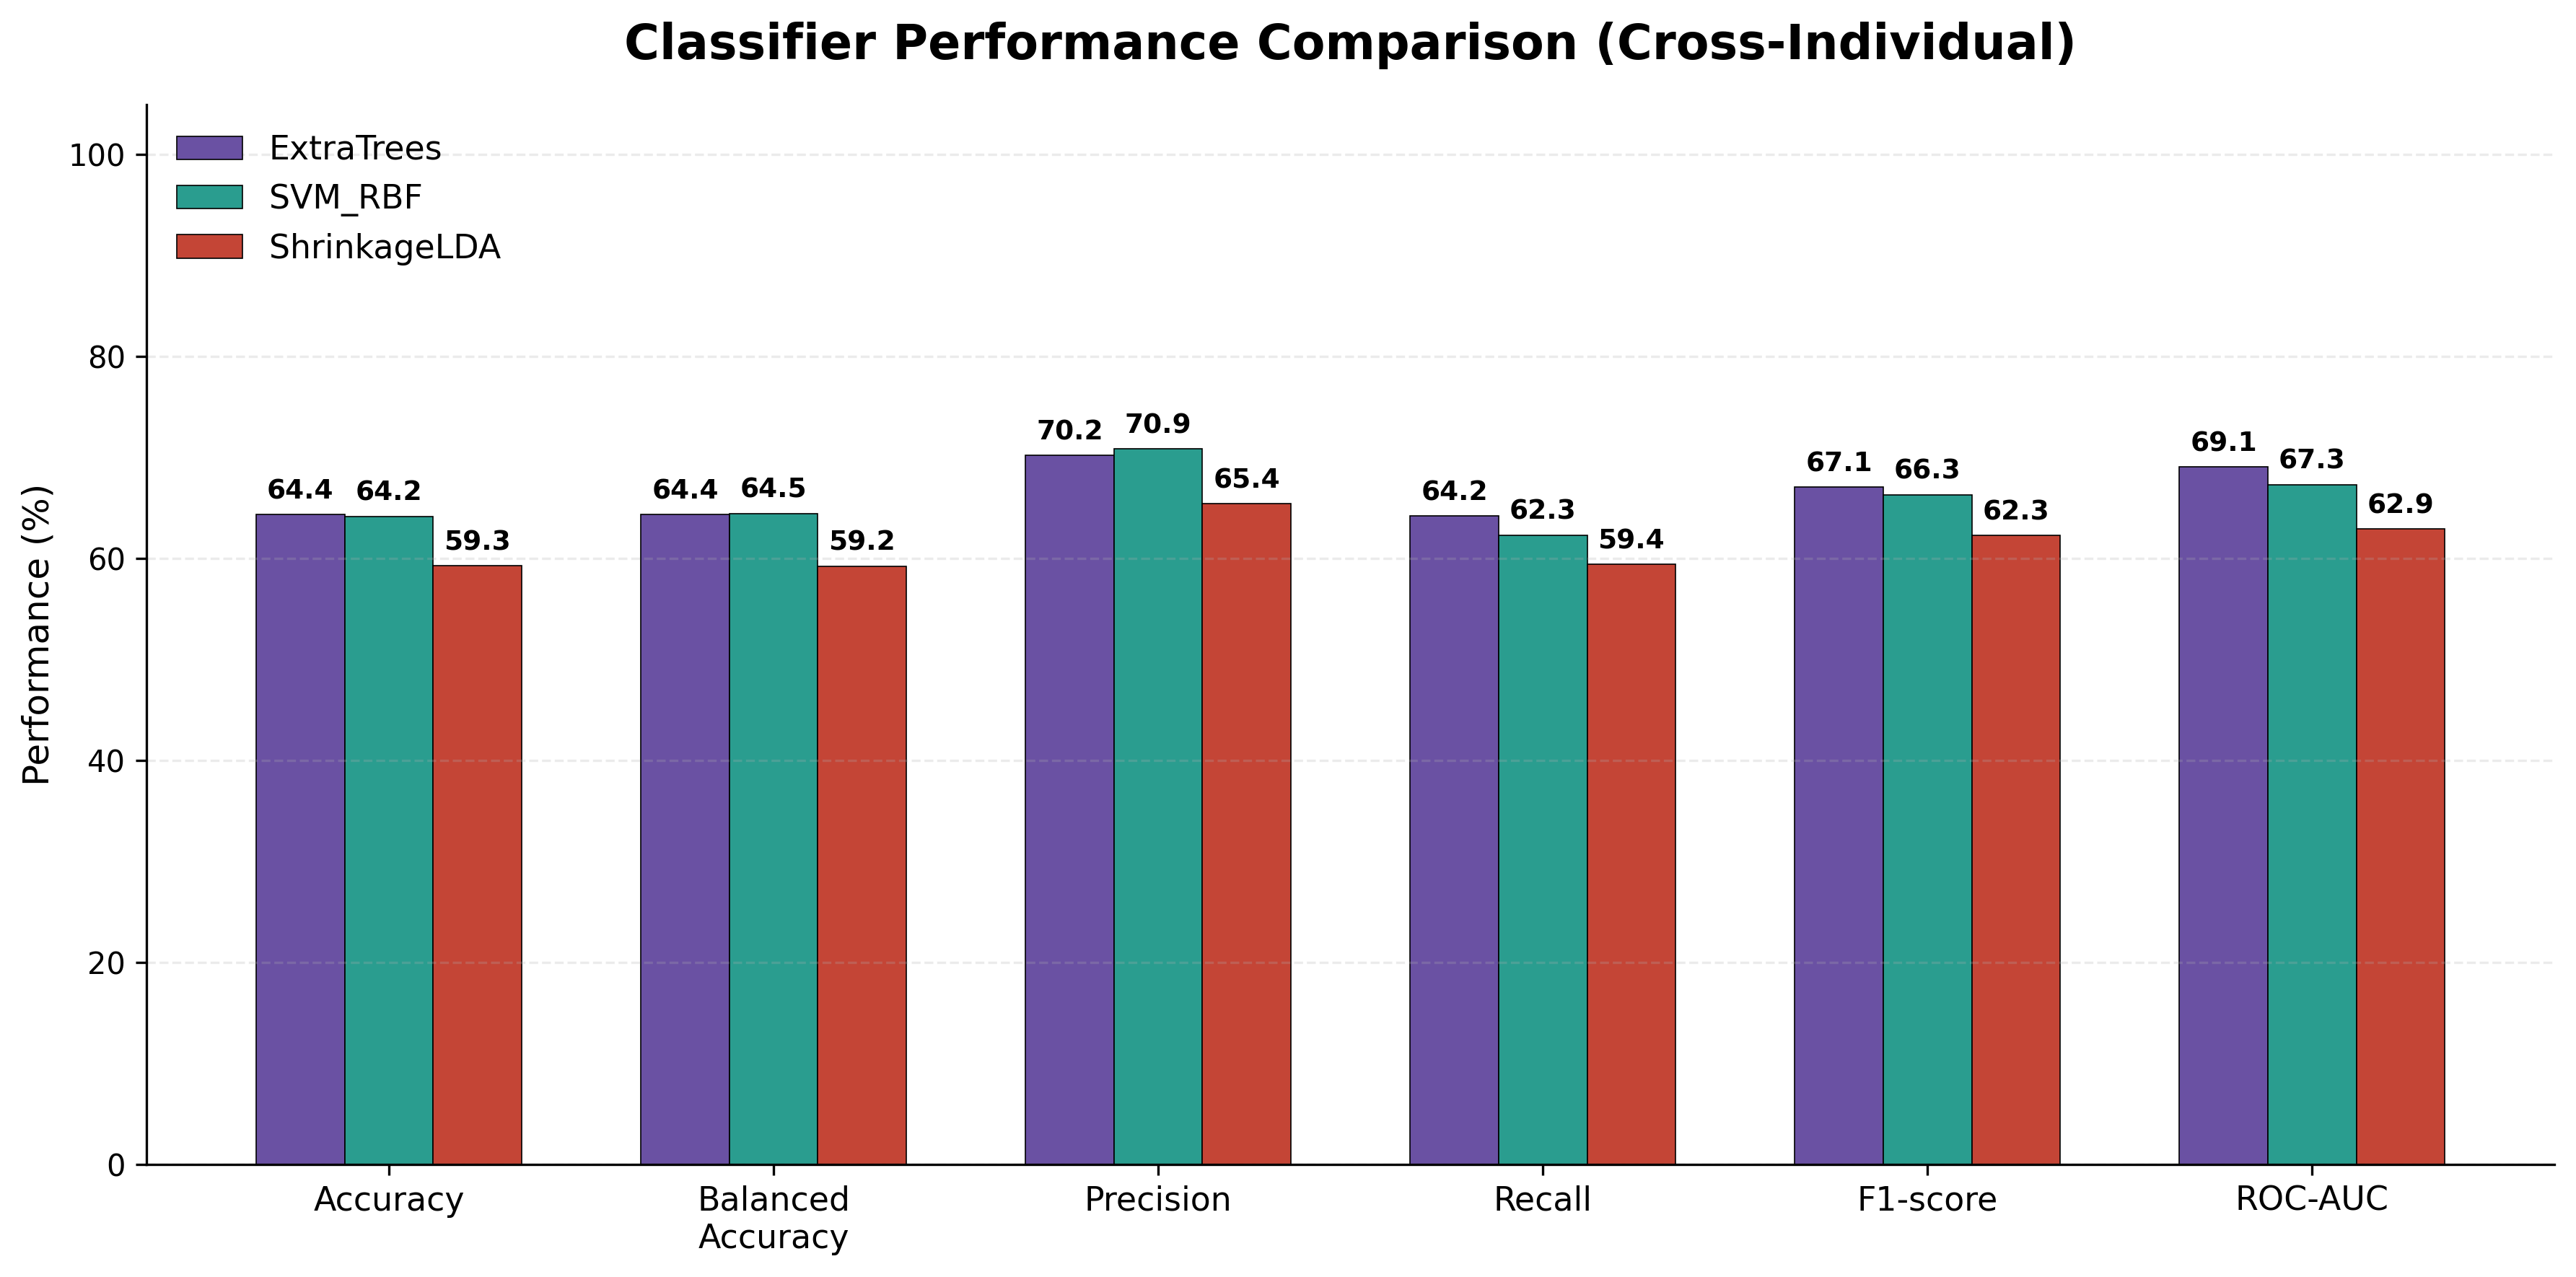

Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/LOSO_classifier_performance_comparison.png


In [ ]:
# CELL — Publication level LOSO performance comparison
# Cross-individual LOSO (223 subjects)
# Different color palette from within-individual figures


import matplotlib.pyplot as plt
import numpy as np



# =========================================================
# Metrics
# =========================================================

metrics = [

    "Accuracy (%)",
    "Balanced Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "ROC-AUC (%)"

]



models = (
    loso_visualization_df["Model"]
    .tolist()
)



# =========================================================
# Extract values
# =========================================================

data = []


for model in models:

    values = (
        loso_visualization_df
        .loc[
            loso_visualization_df["Model"] == model,
            metrics
        ]
        .values[0]
    )

    data.append(values)



data = np.array(data)



# =========================================================
# Figure setup
# =========================================================

fig, ax = plt.subplots(

    figsize=(12,6),

    dpi=300

)



x = np.arange(
    len(metrics)
)


width = 0.23



# =========================================================
# Cross-individual LOSO color palette
# (different from within-individual)
# =========================================================

colors = {

    "ExtraTrees":
        "#6A51A3",     # Deep Purple

    "SVM_RBF":
        "#2A9D8F",     # Teal

    "ShrinkageLDA":
        "#C44536"      # Burgundy

}



# =========================================================
# Plot bars
# =========================================================

for i, model in enumerate(models):


    bars = ax.bar(

        x + (i-1)*width,

        data[i],

        width,

        label=model,

        color=colors.get(
            model,
            list(colors.values())[i]
        ),

        edgecolor="black",

        linewidth=0.4

    )


    # value annotations

    for bar in bars:


        height = bar.get_height()


        ax.text(

            bar.get_x() + bar.get_width()/2,

            height + 1,

            f"{height:.1f}",

            ha="center",

            va="bottom",

            fontsize=9,

            fontweight="bold"

        )



# =========================================================
# Formatting
# =========================================================


ax.set_xticks(
    x
)


ax.set_xticklabels(

    [
        "Accuracy",
        "Balanced\nAccuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    fontsize=11

)



ax.set_ylabel(

    "Performance (%)",

    fontsize=12

)



ax.set_ylim(

    0,

    105

)



ax.set_title(

    "Classifier Performance Comparison (Cross-Individual)",

    fontsize=16,

    fontweight="bold",

    pad=15

)



# Remove unnecessary borders

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)



# Grid

ax.grid(

    axis="y",

    linestyle="--",

    alpha=0.25

)



# Legend

ax.legend(

    frameon=False,

    fontsize=11,

    loc="upper left"

)



plt.tight_layout()



# =========================================================
# Save figure
# =========================================================

save_path = (

    LOSO_DIR +

    "/LOSO_classifier_performance_comparison.png"

)



plt.savefig(

    save_path,

    dpi=600,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:"
)

print(
    save_path
)

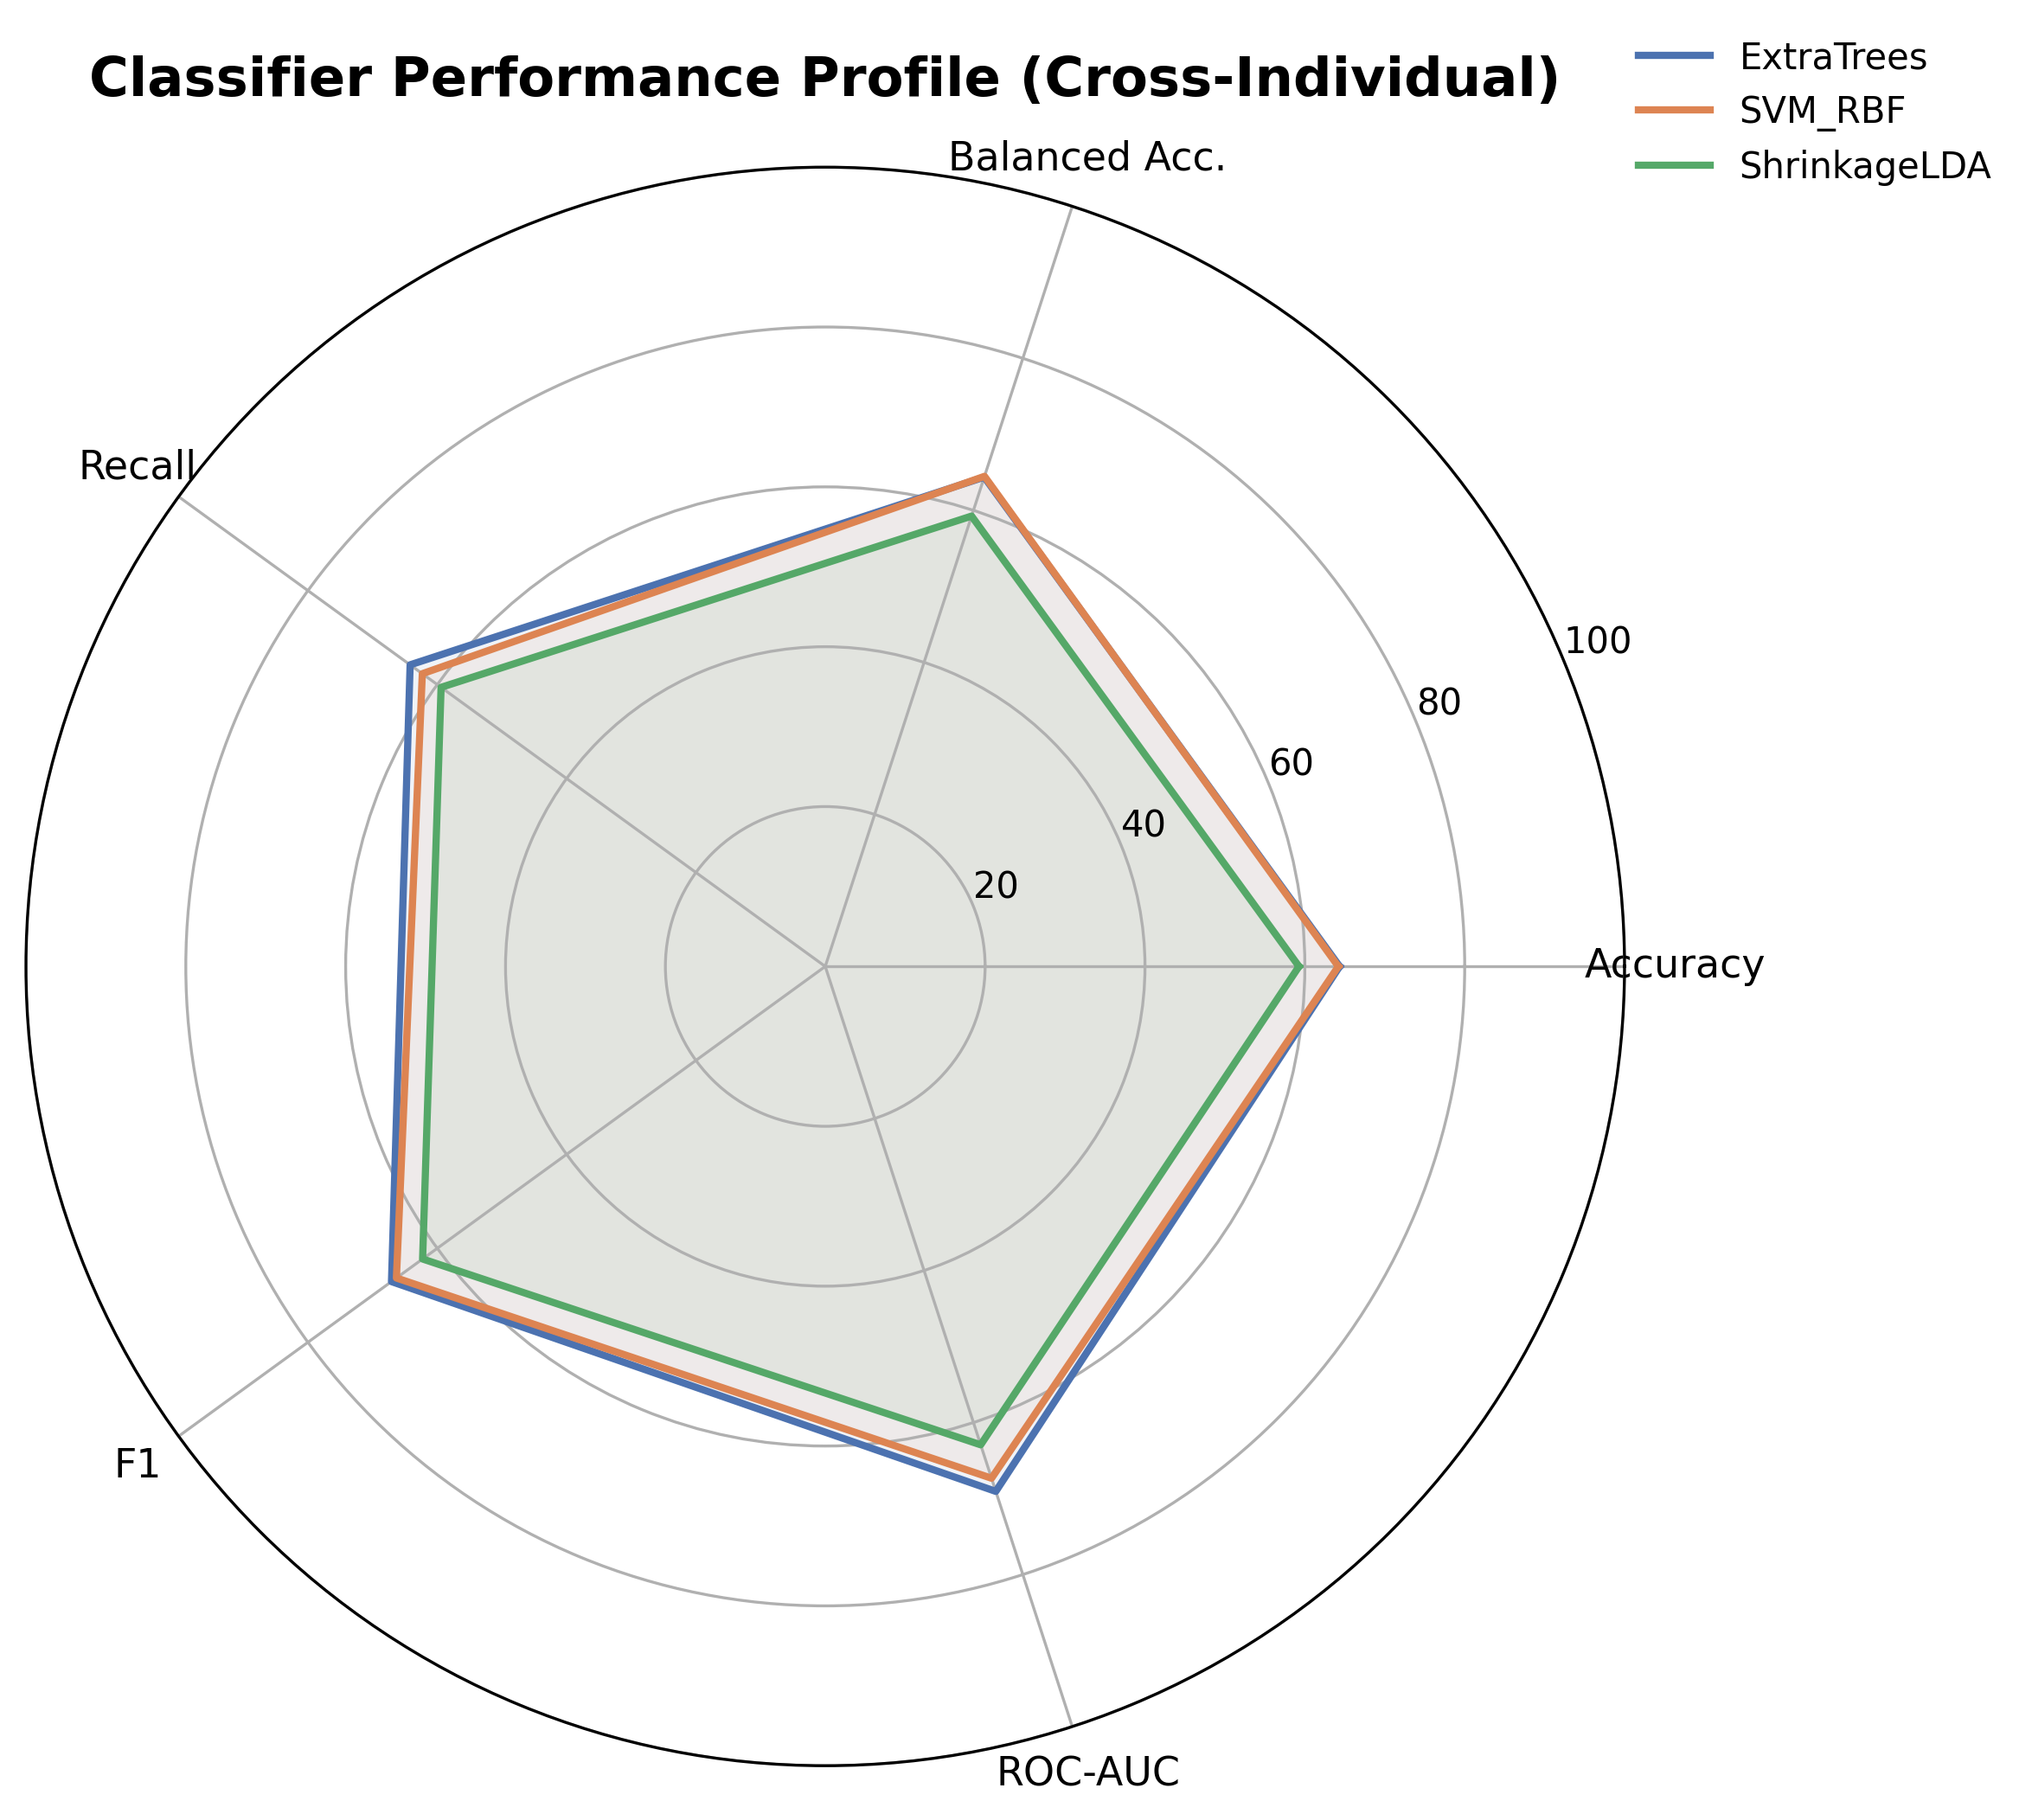

In [ ]:
# CELL — LOSO radar chart

import matplotlib.pyplot as plt
import numpy as np


radar_metrics = [

    "Accuracy (%)",
    "Balanced Accuracy (%)",
    "Recall (%)",
    "F1-score (%)",
    "ROC-AUC (%)"

]


angles = np.linspace(
    0,
    2*np.pi,
    len(radar_metrics),
    endpoint=False
)


angles = np.concatenate(
    [
        angles,
        [angles[0]]
    ]
)



fig = plt.figure(
    figsize=(8,8),
    dpi=300
)


ax = plt.subplot(
    111,
    polar=True
)



colors = [
    "#4C72B0",
    "#DD8452",
    "#55A868"
]



for idx, row in loso_visualization_df.iterrows():

    values = (
        row[radar_metrics]
        .values
    )


    values = np.concatenate(
        [
            values,
            [values[0]]
        ]
    )


    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"],
        color=colors[idx]
    )


    ax.fill(
        angles,
        values,
        alpha=0.08,
        color=colors[idx]
    )



ax.set_xticks(
    angles[:-1]
)


ax.set_xticklabels(
    [
        "Accuracy",
        "Balanced Acc.",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    fontsize=11
)


ax.set_ylim(
    0,
    100
)


ax.set_title(
    "Classifier Performance Profile (Cross-Individual)",
    fontsize=15,
    fontweight="bold",
    pad=20
)



ax.legend(
    bbox_to_anchor=(1.25,1.1),
    frameon=False
)


plt.show()

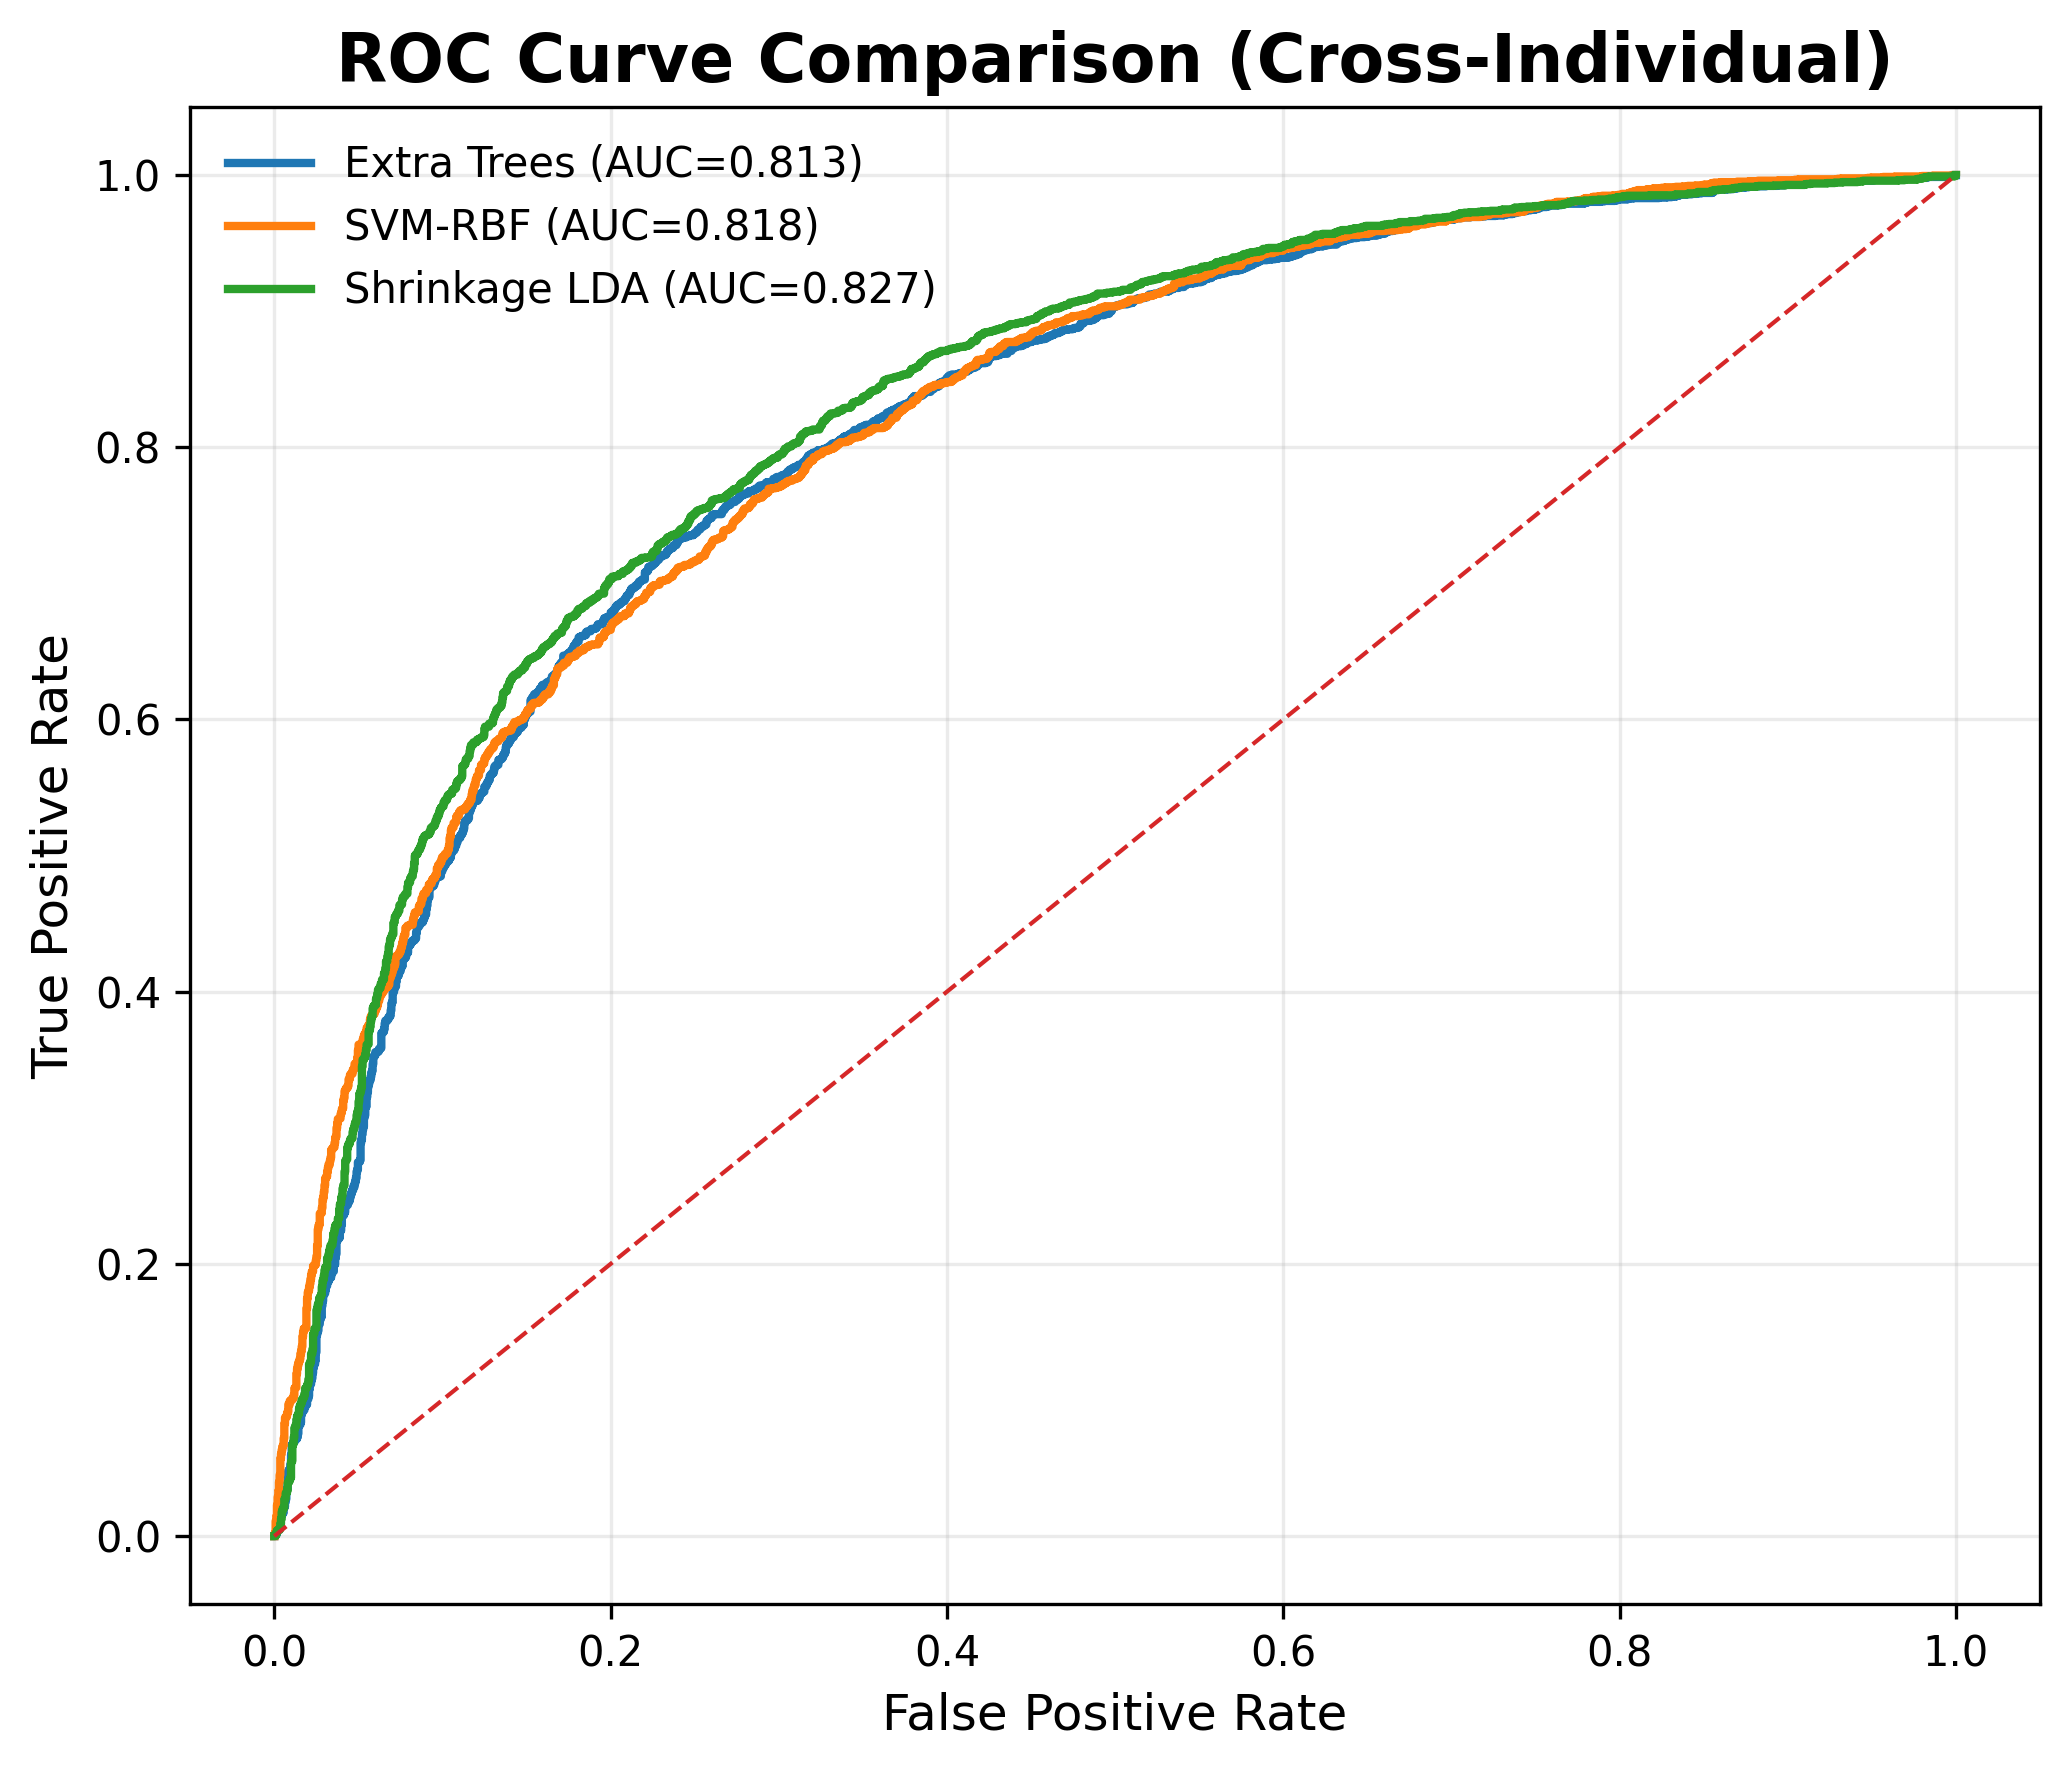

In [ ]:
# CELL — LOSO ROC curve comparison

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(7,6),
    dpi=300
)



for model_name, result in model_results.items():

    pred_df = result["predictions"]


    fpr, tpr, _ = roc_curve(

        pred_df["y_true"],

        pred_df["y_score"]

    )


    roc_auc = auc(
        fpr,
        tpr
    )


    ax.plot(

        fpr,

        tpr,

        linewidth=2,

        label=f"{model_name} (AUC={roc_auc:.3f})"

    )



ax.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1
)



ax.set_xlabel(
    "False Positive Rate",
    fontsize=12
)


ax.set_ylabel(
    "True Positive Rate",
    fontsize=12
)



ax.set_title(
    "ROC Curve Comparison (Cross-Individual)",
    fontsize=16,
    fontweight="bold"
)



ax.legend(
    frameon=False
)



ax.grid(
    alpha=0.25
)


plt.tight_layout()


plt.show()

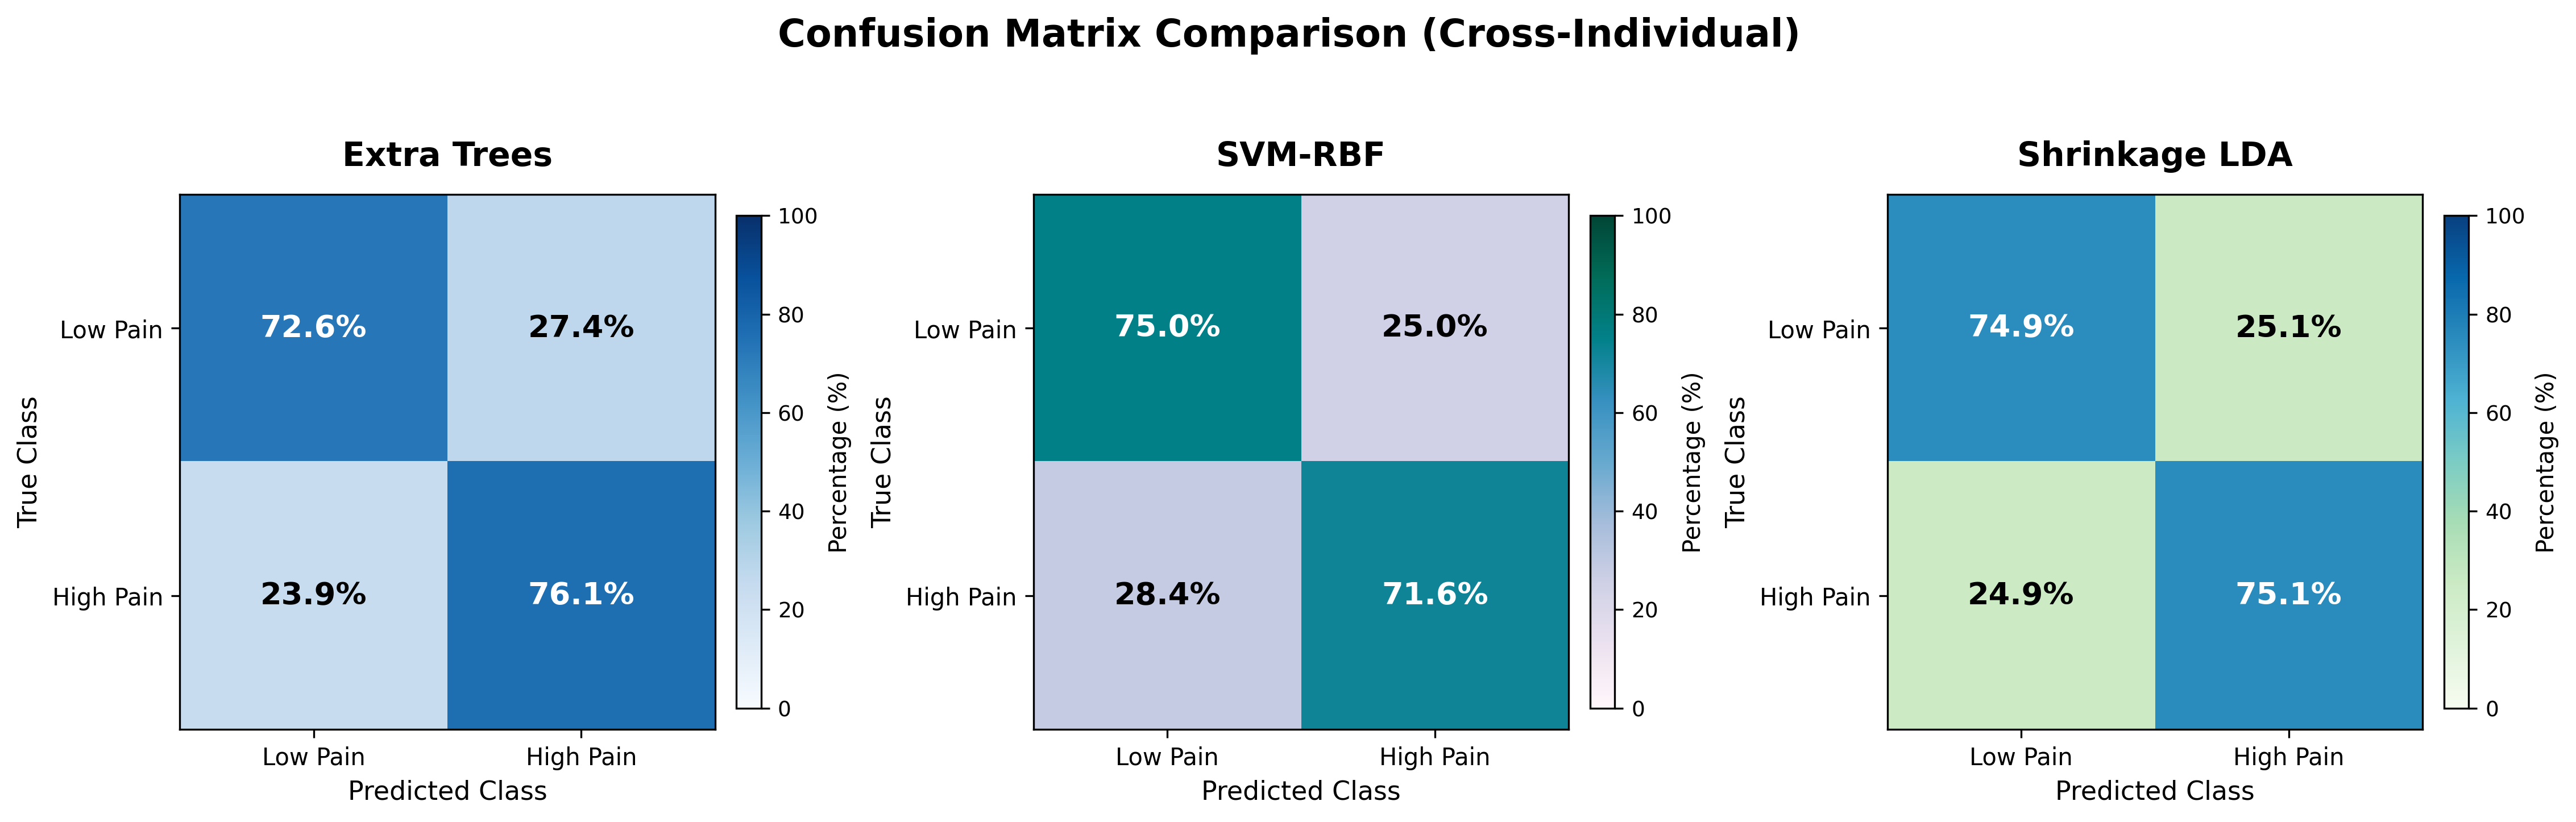

Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/LOSO_confusion_matrix_comparison.png


In [ ]:
# CELL — Premium Confusion Matrix Comparison
# Cross-Individual LOSO (223 Subjects)


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np



# =========================================================
# Model-specific premium color palettes
# Different from within-individual figure
# =========================================================

# =========================================================
# Model-specific premium color palettes
# Cross-individual LOSO
# Different from within-individual figure
# =========================================================

# =========================================================
# Model-specific premium color palettes
# Cross-individual LOSO
# Muted publication style
# =========================================================

# =========================================================
# Model-specific premium cool-tone color palettes
# Cross-individual LOSO
# =========================================================

model_cmaps = {

    "Extra Trees":
        "Blues",      # Blue-Purple

    "SVM-RBF":
        "PuBuGn",    # Purple-Blue-Green / Sea tone

    "Shrinkage LDA":
        "GnBu"       # Green-Blue / Bottle green + sea blue

}



# =========================================================
# Figure setup
# =========================================================

fig, axes = plt.subplots(

    1,
    3,

    figsize=(15,5),

    dpi=300,

    constrained_layout=True

)



# =========================================================
# Generate confusion matrices
# =========================================================

for ax, (model_name, result) in zip(

    axes,

    model_results.items()

):


    pred_df = result["predictions"]



    cm = confusion_matrix(

        pred_df["y_true"],

        pred_df["y_pred"]

    )



    # Row normalized (%)

    cm_norm = (

        cm.astype(float)

        /

        cm.sum(
            axis=1,
            keepdims=True
        )

        *100

    )



    cmap = model_cmaps[model_name]



    im = ax.imshow(

        cm_norm,

        cmap=cmap,

        vmin=0,

        vmax=100

    )



    # =====================================================
    # Add values
    # =====================================================

    for i in range(2):

        for j in range(2):

            value = cm_norm[i,j]


            ax.text(

                j,

                i,

                f"{value:.1f}%",

                ha="center",

                va="center",

                fontsize=13,

                fontweight="bold",

                color=(

                    "white"

                    if value >= 55

                    else "black"

                )

            )



    # =====================================================
    # Axis formatting
    # =====================================================

    ax.set_xticks(
        [0,1]
    )

    ax.set_yticks(
        [0,1]
    )


    ax.set_xticklabels(

        [
            "Low Pain",
            "High Pain"
        ],

        fontsize=10

    )


    ax.set_yticklabels(

        [
            "Low Pain",
            "High Pain"
        ],

        fontsize=10

    )


    ax.set_xlabel(

        "Predicted Class",

        fontsize=11

    )


    ax.set_ylabel(

        "True Class",

        fontsize=11

    )


    ax.set_title(

        model_name,

        fontsize=14,

        fontweight="bold",

        pad=12

    )


    # =====================================================
    # Individual colorbar
    # =====================================================

    cbar = fig.colorbar(

        im,

        ax=ax,

        fraction=0.046,

        pad=0.04

    )


    cbar.set_label(

        "Percentage (%)",

        fontsize=10

    )


    cbar.ax.tick_params(

        labelsize=9

    )



# =========================================================
# Main title
# =========================================================

fig.suptitle(

    "Confusion Matrix Comparison (Cross-Individual)",

    fontsize=16,

    fontweight="bold"

)



# =========================================================
# Save
# =========================================================

save_path = (

    LOSO_DIR +

    "/LOSO_confusion_matrix_comparison.png"

)



plt.savefig(

    save_path,

    dpi=600,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:"
)

print(
    save_path
)

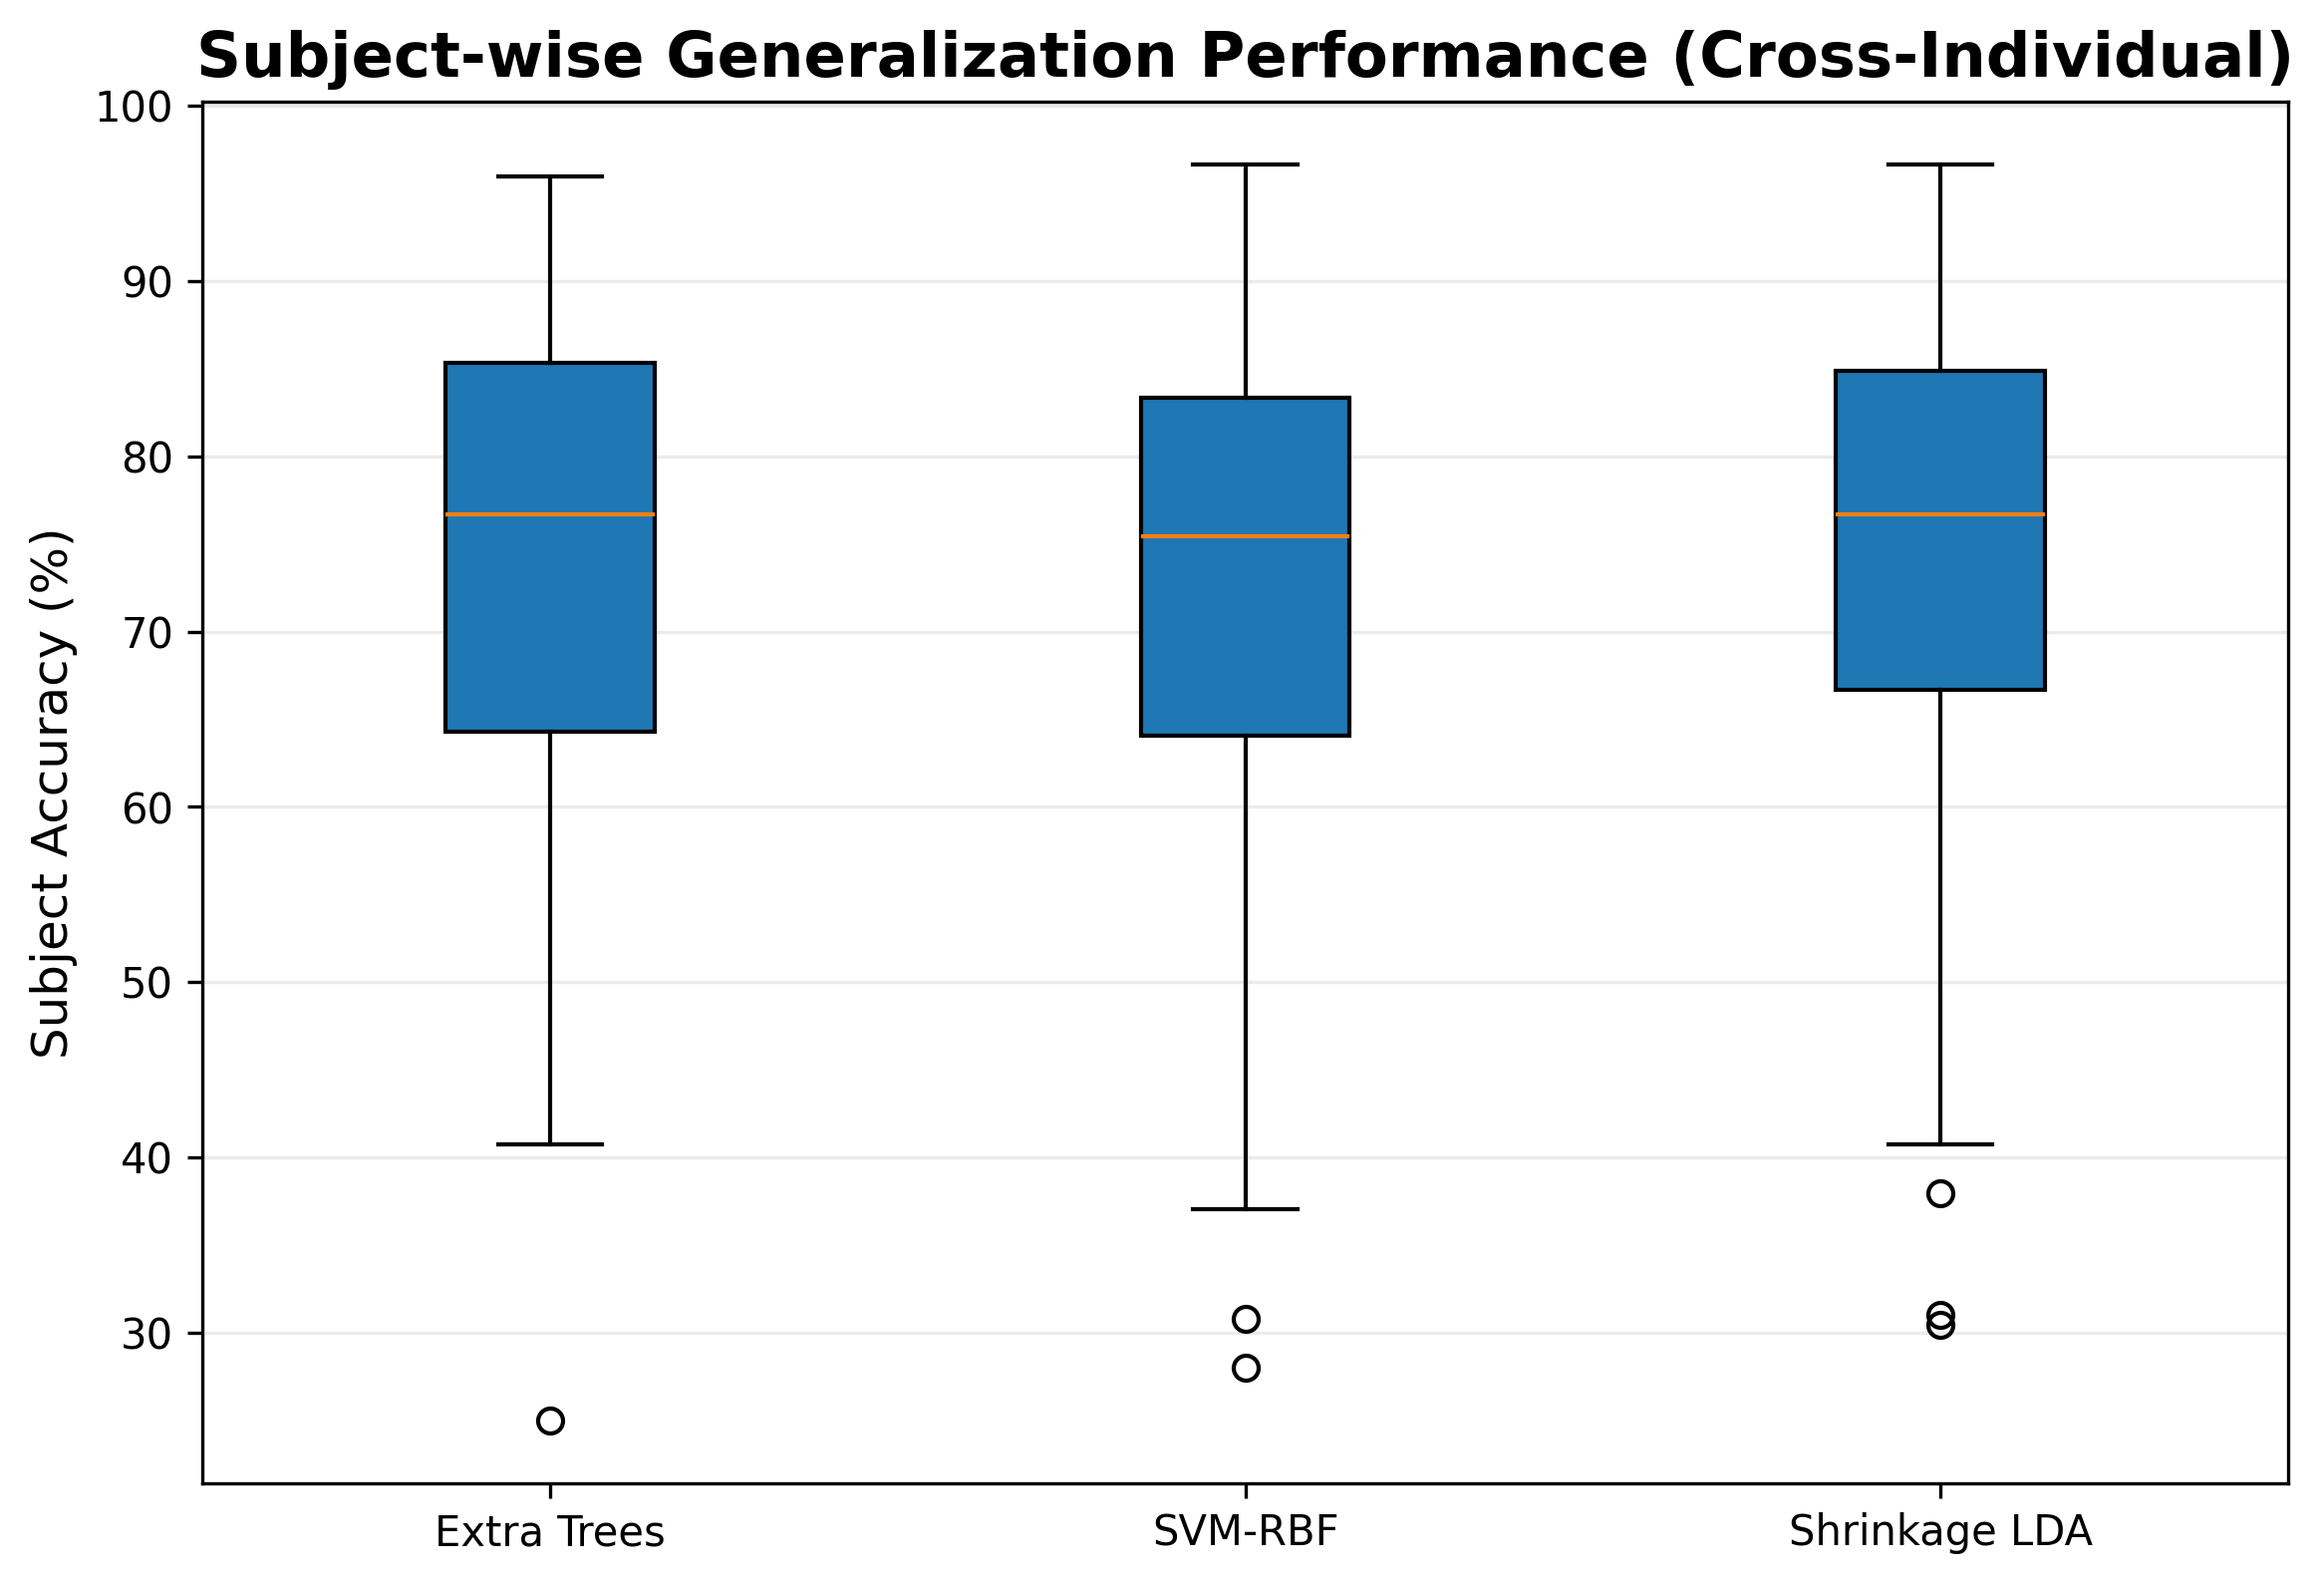

In [ ]:
# CELL — LOSO subject accuracy distribution

import matplotlib.pyplot as plt


plt.figure(
    figsize=(9,6),
    dpi=300
)


box_data=[]

labels=[]


for model_name, result in model_results.items():

    box_data.append(

        result["subject_results"]
        ["accuracy"]
        *100

    )

    labels.append(
        model_name
    )



plt.boxplot(
    box_data,
    labels=labels,
    patch_artist=True
)



plt.ylabel(
    "Subject Accuracy (%)",
    fontsize=12
)


plt.title(
    "Subject-wise Generalization Performance (Cross-Individual)",
    fontsize=15,
    fontweight="bold"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.show()

In [ ]:
# VERIFY LOSO CONFUSION MATRICES FROM SAVED FILES

from sklearn.metrics import confusion_matrix
import pandas as pd


for model_name, result in model_results.items():

    pred_df = result["predictions"]

    cm = confusion_matrix(
        pred_df["y_true"],
        pred_df["y_pred"]
    )

    cm_norm = (
        cm.astype(float)
        /
        cm.sum(axis=1, keepdims=True)
        *100
    )


    print("\n", "="*50)
    print(model_name)
    print("="*50)

    print("Raw confusion matrix:")
    print(cm)

    print("\nRow normalized (%):")
    print(
        pd.DataFrame(
            cm_norm,
            index=[
                "True Low Pain",
                "True High Pain"
            ],
            columns=[
                "Pred Low Pain",
                "Pred High Pain"
            ]
        ).round(2)
    )


Extra Trees
Raw confusion matrix:
[[1825  689]
 [ 693 2201]]

Row normalized (%):
                Pred Low Pain  Pred High Pain
True Low Pain           72.59           27.41
True High Pain          23.95           76.05

SVM-RBF
Raw confusion matrix:
[[1886  628]
 [ 822 2072]]

Row normalized (%):
                Pred Low Pain  Pred High Pain
True Low Pain           75.02           24.98
True High Pain          28.40           71.60

Shrinkage LDA
Raw confusion matrix:
[[1884  630]
 [ 720 2174]]

Row normalized (%):
                Pred Low Pain  Pred High Pain
True Low Pain           74.94           25.06
True High Pain          24.88           75.12


In [ ]:
# CELL 24 — Compare Extra Trees, SVM-RBF and Shrinkage LDA
# Saves CSV and Excel result tables

import os
import numpy as np
import pandas as pd


# ============================================================
# 1. Collect the three completed model results
# ============================================================

model_results = {
    "Extra Trees": extra_trees_fusion_results,
    "SVM-RBF": svm_rbf_fusion_results,
    "Shrinkage LDA": shrinkage_lda_fusion_results,
}

required_result_keys = {
    "pooled_summary",
    "subject_metric_summary",
    "subject_results",
}

for model_name, result_object in model_results.items():

    missing_keys = required_result_keys.difference(
        result_object.keys()
    )

    if missing_keys:
        raise KeyError(
            f"{model_name} result object is missing: "
            f"{sorted(missing_keys)}"
        )


# ============================================================
# 2. Output directory and paths
# ============================================================

COMPARISON_DIR = os.path.join(
    V5_DIR,
    "V5_LOSO_RESULTS",
    "THREE_MODEL_COMPARISON"
)

os.makedirs(
    COMPARISON_DIR,
    exist_ok=True
)

main_table_path = os.path.join(
    COMPARISON_DIR,
    "V5_three_model_main_comparison.csv"
)

detailed_table_path = os.path.join(
    COMPARISON_DIR,
    "V5_three_model_detailed_comparison.csv"
)

subject_table_path = os.path.join(
    COMPARISON_DIR,
    "V5_three_model_subject_metrics_mean_sd.csv"
)

excel_path = os.path.join(
    COMPARISON_DIR,
    "V5_three_model_complete_results.xlsx"
)


# ============================================================
# 3. Helper functions
# ============================================================

def safe_value(
    series,
    column_name,
    default=np.nan
):
    """
    Extract one numeric value safely from a pooled-summary row.
    """

    if column_name not in series.index:
        return default

    value = series[column_name]

    try:
        return float(value)
    except Exception:
        return default


def subject_metric_values(
    subject_metric_df,
    metric_name
):
    """
    Return the subject-level mean, SD and number of valid
    subjects for a specified metric.
    """

    selected = subject_metric_df.loc[
        subject_metric_df["metric"] == metric_name
    ]

    if selected.empty:
        return np.nan, np.nan, 0

    selected_row = selected.iloc[0]

    metric_mean = pd.to_numeric(
        selected_row.get("mean", np.nan),
        errors="coerce"
    )

    metric_sd = pd.to_numeric(
        selected_row.get(
            "standard_deviation",
            np.nan
        ),
        errors="coerce"
    )

    n_subjects = pd.to_numeric(
        selected_row.get(
            "n_subjects",
            0
        ),
        errors="coerce"
    )

    return (
        float(metric_mean),
        float(metric_sd),
        int(n_subjects)
        if pd.notna(n_subjects)
        else 0
    )


def percent(value):
    """
    Convert a metric from 0–1 scale to percentage.
    """

    if pd.isna(value):
        return np.nan

    return float(value) * 100.0


def mean_sd_text(
    mean_value,
    sd_value
):
    """
    Format a 0–1 metric as percentage mean ± SD.
    """

    if (
        pd.isna(mean_value)
        or pd.isna(sd_value)
    ):
        return "Not defined"

    return (
        f"{mean_value * 100:.2f}% "
        f"± {sd_value * 100:.2f}%"
    )


# ============================================================
# 4. Build concise main comparison table
# ============================================================

main_rows = []

for model_name, result_object in model_results.items():

    pooled_row = (
        result_object["pooled_summary"]
        .iloc[0]
    )

    subject_summary_df = result_object[
        "subject_metric_summary"
    ]

    (
        mean_subject_accuracy,
        sd_subject_accuracy,
        n_subject_accuracy
    ) = subject_metric_values(
        subject_summary_df,
        "accuracy"
    )

    (
        mean_subject_balanced_accuracy,
        sd_subject_balanced_accuracy,
        n_subject_balanced_accuracy
    ) = subject_metric_values(
        subject_summary_df,
        "balanced_accuracy"
    )

    (
        mean_subject_recall,
        sd_subject_recall,
        n_subject_recall
    ) = subject_metric_values(
        subject_summary_df,
        "recall"
    )

    (
        mean_subject_f1,
        sd_subject_f1,
        n_subject_f1
    ) = subject_metric_values(
        subject_summary_df,
        "f1_score"
    )

    (
        mean_subject_auc,
        sd_subject_auc,
        n_subject_auc
    ) = subject_metric_values(
        subject_summary_df,
        "roc_auc"
    )

    main_rows.append({
        "Model": model_name,

        "Feature Set": pooled_row.get(
            "feature_set",
            "Fusion_964"
        ),

        "Number of Features": int(
            safe_value(
                pooled_row,
                "n_features",
                964
            )
        ),

        "Pooled Accuracy (%)": percent(
            safe_value(
                pooled_row,
                "accuracy"
            )
        ),

        "Pooled Balanced Accuracy (%)": percent(
            safe_value(
                pooled_row,
                "balanced_accuracy"
            )
        ),

        "Pooled Precision (%)": percent(
            safe_value(
                pooled_row,
                "precision"
            )
        ),

        "Pooled Recall (%)": percent(
            safe_value(
                pooled_row,
                "recall"
            )
        ),

        "Pooled Specificity (%)": percent(
            safe_value(
                pooled_row,
                "specificity"
            )
        ),

        "Pooled F1-Score (%)": percent(
            safe_value(
                pooled_row,
                "f1_score"
            )
        ),

        "Pooled ROC-AUC (%)": percent(
            safe_value(
                pooled_row,
                "roc_auc"
            )
        ),

        "Mean Subject Accuracy ± SD": mean_sd_text(
            mean_subject_accuracy,
            sd_subject_accuracy
        ),

        "Mean Subject Balanced Accuracy ± SD": (
            mean_sd_text(
                mean_subject_balanced_accuracy,
                sd_subject_balanced_accuracy
            )
        ),

        "Mean Subject Recall ± SD": mean_sd_text(
            mean_subject_recall,
            sd_subject_recall
        ),

        "Mean Subject F1-Score ± SD": mean_sd_text(
            mean_subject_f1,
            sd_subject_f1
        ),

        "Mean Subject ROC-AUC ± SD": mean_sd_text(
            mean_subject_auc,
            sd_subject_auc
        ),

        "Subjects Used for Subject ROC-AUC": (
            n_subject_auc
        ),

        "Total Fit Time (minutes)": safe_value(
            pooled_row,
            "total_fit_minutes"
        ),
    })

main_comparison_df = pd.DataFrame(
    main_rows
)


# ============================================================
# 5. Build detailed pooled-metric comparison table
# ============================================================

detailed_rows = []

for model_name, result_object in model_results.items():

    pooled_row = (
        result_object["pooled_summary"]
        .iloc[0]
    )

    detailed_rows.append({
        "Model": model_name,

        "Feature Set": pooled_row.get(
            "feature_set",
            "Fusion_964"
        ),

        "Number of Epochs": int(
            safe_value(
                pooled_row,
                "n_epochs",
                6275
            )
        ),

        "Number of Features": int(
            safe_value(
                pooled_row,
                "n_features",
                964
            )
        ),

        "Number of Subjects": int(
            safe_value(
                pooled_row,
                "n_subjects",
                223
            )
        ),

        "Accuracy": safe_value(
            pooled_row,
            "accuracy"
        ),

        "Balanced Accuracy": safe_value(
            pooled_row,
            "balanced_accuracy"
        ),

        "Precision": safe_value(
            pooled_row,
            "precision"
        ),

        "Recall": safe_value(
            pooled_row,
            "recall"
        ),

        "Sensitivity": safe_value(
            pooled_row,
            "sensitivity"
        ),

        "Specificity": safe_value(
            pooled_row,
            "specificity"
        ),

        "Negative Predictive Value": safe_value(
            pooled_row,
            "negative_predictive_value"
        ),

        "F1-Score": safe_value(
            pooled_row,
            "f1_score"
        ),

        "ROC-AUC": safe_value(
            pooled_row,
            "roc_auc"
        ),

        "Average Precision / PR-AUC": safe_value(
            pooled_row,
            "average_precision_pr_auc"
        ),

        "Matthews Correlation Coefficient": safe_value(
            pooled_row,
            "matthews_correlation_coefficient"
        ),

        "Cohen Kappa": safe_value(
            pooled_row,
            "cohen_kappa"
        ),

        "Macro Precision": safe_value(
            pooled_row,
            "precision_macro"
        ),

        "Macro Recall": safe_value(
            pooled_row,
            "recall_macro"
        ),

        "Macro F1": safe_value(
            pooled_row,
            "f1_macro"
        ),

        "Weighted Precision": safe_value(
            pooled_row,
            "precision_weighted"
        ),

        "Weighted Recall": safe_value(
            pooled_row,
            "recall_weighted"
        ),

        "Weighted F1": safe_value(
            pooled_row,
            "f1_weighted"
        ),

        "True Negative": int(
            safe_value(
                pooled_row,
                "true_negative",
                0
            )
        ),

        "False Positive": int(
            safe_value(
                pooled_row,
                "false_positive",
                0
            )
        ),

        "False Negative": int(
            safe_value(
                pooled_row,
                "false_negative",
                0
            )
        ),

        "True Positive": int(
            safe_value(
                pooled_row,
                "true_positive",
                0
            )
        ),

        "Total Fit Time (minutes)": safe_value(
            pooled_row,
            "total_fit_minutes"
        ),

        "Total Prediction Time (seconds)": safe_value(
            pooled_row,
            "total_prediction_seconds"
        ),
    })

detailed_comparison_df = pd.DataFrame(
    detailed_rows
)


# ============================================================
# 6. Build long-format subject mean ± SD table
# ============================================================

subject_summary_frames = []

for model_name, result_object in model_results.items():

    model_subject_summary = result_object[
        "subject_metric_summary"
    ].copy()

    model_subject_summary.insert(
        0,
        "Model",
        model_name
    )

    model_subject_summary.insert(
        1,
        "Feature Set",
        "Fusion_964"
    )

    subject_summary_frames.append(
        model_subject_summary
    )

subject_metrics_comparison_df = pd.concat(
    subject_summary_frames,
    ignore_index=True
)


# ============================================================
# 7. Round numeric values for presentation
# ============================================================

main_numeric_columns = main_comparison_df.select_dtypes(
    include=[np.number]
).columns

main_comparison_df[
    main_numeric_columns
] = main_comparison_df[
    main_numeric_columns
].round(4)

detailed_numeric_columns = (
    detailed_comparison_df.select_dtypes(
        include=[np.number]
    ).columns
)

detailed_comparison_df[
    detailed_numeric_columns
] = detailed_comparison_df[
    detailed_numeric_columns
].round(6)

subject_numeric_columns = (
    subject_metrics_comparison_df.select_dtypes(
        include=[np.number]
    ).columns
)

subject_metrics_comparison_df[
    subject_numeric_columns
] = subject_metrics_comparison_df[
    subject_numeric_columns
].round(6)


# ============================================================
# 8. Save CSV files
# ============================================================

main_comparison_df.to_csv(
    main_table_path,
    index=False
)

detailed_comparison_df.to_csv(
    detailed_table_path,
    index=False
)

subject_metrics_comparison_df.to_csv(
    subject_table_path,
    index=False
)


# ============================================================
# 9. Save one complete Excel workbook
# ============================================================

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    main_comparison_df.to_excel(
        writer,
        sheet_name="Main Comparison",
        index=False
    )

    detailed_comparison_df.to_excel(
        writer,
        sheet_name="Pooled Metrics",
        index=False
    )

    subject_metrics_comparison_df.to_excel(
        writer,
        sheet_name="Subject Mean SD",
        index=False
    )

    for model_name, result_object in model_results.items():

        safe_sheet_name = (
            model_name
            .replace("-", "_")
            .replace(" ", "_")
        )[:25]

        result_object[
            "subject_results"
        ].to_excel(
            writer,
            sheet_name=(
                f"{safe_sheet_name}_Subjects"
            )[:31],
            index=False
        )


# ============================================================
# 10. Display comparison tables
# ============================================================

print("\n" + "=" * 80)
print("THREE-MODEL CROSS-INDIVIDUAL LOSO COMPARISON")
print("=" * 80)

display(
    main_comparison_df
)

print("\nDetailed pooled metrics:")
display(
    detailed_comparison_df
)

print("\nSubject-level metrics: mean ± SD")
display(
    subject_metrics_comparison_df
)


# ============================================================
# 11. Print all saved paths
# ============================================================

print("\nFiles saved successfully.")

print("\nMain comparison CSV:")
print(main_table_path)

print("\nDetailed pooled metrics CSV:")
print(detailed_table_path)

print("\nSubject mean ± SD CSV:")
print(subject_table_path)

print("\nComplete Excel workbook:")
print(excel_path)

NameError: name 'extra_trees_fusion_results' is not defined

In [ ]:
# CELL — Inspect all V5 LOSO saved experiments

import os
import glob


LOSO_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH/"
    "V5_LOSO_RESULTS"
)


print("="*80)
print("LOSO RESULT DIRECTORY")
print("="*80)

print(LOSO_DIR)


files = sorted(
    os.listdir(LOSO_DIR)
)


print("\nTotal files found:", len(files))


print("\nSaved experiments:\n")


experiments = {}

for f in files:

    if "__pooled_summary.csv" in f:

        exp_name = (
            f.replace(
                "__pooled_summary.csv",
                ""
            )
        )

        experiments[exp_name] = f


for i, exp in enumerate(
    experiments.keys(),
    1
):

    print(
        f"{i}. {exp}"
    )


print("\n" + "="*80)
print("FILE MANIFEST")
print("="*80)


for f in files:

    print(f)

LOSO RESULT DIRECTORY
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS

Total files found: 25

Saved experiments:

1. ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6
2. SVM_RBF__Fusion_964__C1_gammaScale_balanced
3. ShrinkageLDA__Fusion_964__LSQR_autoShrinkage_equalPriors

FILE MANIFEST
ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__configuration.json
ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__pooled_summary.csv
ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__progress.json
ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__subject_metric_summary.csv
ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__subject_results.csv
ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__trial_predictions.csv
ExtraTrees__Fusion_964__fixed_v1__configuration.json
ExtraTrees__Fusion_964__fixed_v1__trial_predictions.csv
RandomForest__Fusion_964__RF300_depth15_leaf3_split6_balancedSubsample__configuration.json
RandomForest__Fusion_964__RF300

In [ ]:
# CELL — Cross-individual LOSO 3-model performance comparison table

import os
import pandas as pd


# =========================================================
# LOSO result directory
# =========================================================

LOSO_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH/"
    "V5_LOSO_RESULTS"
)



# =========================================================
# Load only completed pooled summaries
# =========================================================

pooled_files = [

    os.path.join(
        LOSO_DIR,
        "ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6__pooled_summary.csv"
    ),

    os.path.join(
        LOSO_DIR,
        "SVM_RBF__Fusion_964__C1_gammaScale_balanced__pooled_summary.csv"
    ),

    os.path.join(
        LOSO_DIR,
        "ShrinkageLDA__Fusion_964__LSQR_autoShrinkage_equalPriors__pooled_summary.csv"
    )

]



results = []



for file in pooled_files:

    df = pd.read_csv(file)


    row = {

        "Model":
            df.loc[0, "model"],


        "Accuracy (%)":
            df.loc[0, "accuracy"] * 100,


        "Balanced Accuracy (%)":
            df.loc[0, "balanced_accuracy"] * 100,


        "Precision (%)":
            df.loc[0, "precision"] * 100,


        "Recall (%)":
            df.loc[0, "recall"] * 100,


        "F1-score (%)":
            df.loc[0, "f1_score"] * 100,


        "ROC-AUC (%)":
            df.loc[0, "roc_auc"] * 100,


        "Mean Subject Accuracy (%)":
            df.loc[
                0,
                "mean_subject_accuracy"
            ] * 100,


        "Subject Accuracy SD (%)":
            df.loc[
                0,
                "subject_accuracy_standard_deviation"
            ] * 100,

    }


    results.append(row)



# =========================================================
# Final comparison table
# =========================================================

cross_individual_results = pd.DataFrame(
    results
)



# Rank by ROC-AUC

cross_individual_results = (
    cross_individual_results
    .sort_values(
        by="ROC-AUC (%)",
        ascending=False
    )
    .reset_index(drop=True)
)



# Display premium formatted table

display(
    cross_individual_results.style
    .format(
        {
            "Accuracy (%)": "{:.2f}",
            "Balanced Accuracy (%)": "{:.2f}",
            "Precision (%)": "{:.2f}",
            "Recall (%)": "{:.2f}",
            "F1-score (%)": "{:.2f}",
            "ROC-AUC (%)": "{:.2f}",
            "Mean Subject Accuracy (%)": "{:.2f}",
            "Subject Accuracy SD (%)": "{:.2f}",
        }
    )
    .set_caption(
        "Cross-Individual LOSO Performance Comparison (V5 Fusion - 964 Features)"
    )
)



# =========================================================
# Save table
# =========================================================

save_path = os.path.join(
    LOSO_DIR,
    "THREE_MODEL_LOSO_PERFORMANCE_COMPARISON.csv"
)


cross_individual_results.to_csv(
    save_path,
    index=False
)



print(
    "\nSaved result table:"
)

print(save_path)

,Model,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),F1-score (%),ROC-AUC (%),Mean Subject Accuracy (%),Subject Accuracy SD (%)
0,ExtraTrees,64.35,64.37,70.23,64.20,67.08,69.06,64.38,20.05
1,SVM_RBF,64.19,64.48,70.87,62.31,66.32,67.33,64.21,19.66
2,ShrinkageLDA,59.27,59.25,65.42,59.41,62.27,62.93,59.33,16.44



Saved result table:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/THREE_MODEL_LOSO_PERFORMANCE_COMPARISON.csv


In [ ]:
# CELL — Complete leakage-safe within-individual LOOCV evaluator
# Evaluates 205 subjects containing both low- and high-pain trials

import os
import re
import json
import time
import warnings

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.base import (
    BaseEstimator,
    TransformerMixin,
    clone,
)

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. Output directory
# ============================================================

WITHIN_LOOCV_RESULTS_DIR = os.path.join(
    V5_DIR,
    "V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS"
)

os.makedirs(
    WITHIN_LOOCV_RESULTS_DIR,
    exist_ok=True
)

print("Within-individual LOOCV output directory:")
print(WITHIN_LOOCV_RESULTS_DIR)


# ============================================================
# 2. Adaptive PCA
# ============================================================

class AdaptivePCA(
    BaseEstimator,
    TransformerMixin
):
    """
    PCA that automatically restricts the number of components
    according to the number of training trials in each fold.

    PCA is fitted only on the training trials because this
    transformer is placed inside the sklearn Pipeline.
    """

    def __init__(
        self,
        max_components=10,
        whiten=False,
        random_state=42,
    ):
        self.max_components = max_components
        self.whiten = whiten
        self.random_state = random_state

    def fit(
        self,
        X,
        y=None
    ):
        X = np.asarray(
            X,
            dtype=np.float64
        )

        maximum_possible_components = min(
            X.shape[0] - 1,
            X.shape[1],
        )

        self.n_components_ = int(
            min(
                self.max_components,
                maximum_possible_components,
            )
        )

        if self.n_components_ < 1:
            raise ValueError(
                "Not enough training trials for PCA."
            )

        self.pca_ = PCA(
            n_components=self.n_components_,
            whiten=self.whiten,
            svd_solver="full",
            random_state=self.random_state,
        )

        self.pca_.fit(X)

        return self

    def transform(
        self,
        X
    ):
        return self.pca_.transform(X)

    def get_feature_names_out(
        self,
        input_features=None
    ):
        return np.asarray([
            f"PC_{component_index + 1}"
            for component_index in range(
                self.n_components_
            )
        ])


# ============================================================
# 3. Saving utilities
# ============================================================

def make_safe_filename(
    text
):
    text = str(text).strip()

    text = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        text
    )

    return text.strip("_")


def atomic_write_csv(
    dataframe,
    path
):
    """
    Save through a temporary file to reduce checkpoint
    corruption risk.
    """

    temporary_path = (
        f"{path}.temporary"
    )

    dataframe.to_csv(
        temporary_path,
        index=False
    )

    os.replace(
        temporary_path,
        path
    )


def atomic_write_json(
    content,
    path
):
    temporary_path = (
        f"{path}.temporary"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            content,
            file,
            indent=4
        )

    os.replace(
        temporary_path,
        path
    )


def append_dataframe_to_csv(
    dataframe,
    path
):
    """
    Append one completed trial prediction immediately.
    """

    file_exists = os.path.exists(
        path
    )

    dataframe.to_csv(
        path,
        mode="a",
        header=not file_exists,
        index=False
    )


# ============================================================
# 4. Continuous positive-class scores
# ============================================================

def get_positive_class_scores(
    fitted_model,
    X_test,
    y_pred
):
    """
    Obtain continuous scores for high pain = 1.

    Priority:
        1. predict_proba
        2. decision_function
        3. predicted label fallback
    """

    classes = np.asarray(
        getattr(
            fitted_model,
            "classes_",
            np.array([0, 1])
        )
    )

    positive_positions = np.flatnonzero(
        classes == 1
    )

    if len(positive_positions) == 0:
        raise ValueError(
            "The fitted model does not contain class 1."
        )

    positive_position = int(
        positive_positions[0]
    )

    if hasattr(
        fitted_model,
        "predict_proba"
    ):
        probabilities = np.asarray(
            fitted_model.predict_proba(
                X_test
            ),
            dtype=float
        )

        return (
            probabilities[
                :,
                positive_position
            ].ravel(),
            "predict_proba"
        )

    if hasattr(
        fitted_model,
        "decision_function"
    ):
        scores = np.asarray(
            fitted_model.decision_function(
                X_test
            ),
            dtype=float
        )

        if scores.ndim == 1:
            positive_scores = scores
        else:
            positive_scores = scores[
                :,
                positive_position
            ]

        return (
            positive_scores.ravel(),
            "decision_function"
        )

    return (
        np.asarray(
            y_pred,
            dtype=float
        ).ravel(),
        "predicted_label_fallback"
    )


# ============================================================
# 5. Complete binary-classification metrics
# ============================================================

def calculate_binary_metrics(
    y_true,
    y_pred,
    y_score=None
):
    """
    Calculate pooled or subject-level metrics.

    Positive class:
        High pain = 1

    Negative class:
        Low pain = 0
    """

    y_true = np.asarray(
        y_true,
        dtype=np.int8
    ).ravel()

    y_pred = np.asarray(
        y_pred,
        dtype=np.int8
    ).ravel()

    if y_score is not None:
        y_score = np.asarray(
            y_score,
            dtype=float
        ).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError(
            "y_true and y_pred lengths differ."
        )

    if (
        y_score is not None
        and len(y_score) != len(y_true)
    ):
        raise ValueError(
            "y_score and y_true lengths differ."
        )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    has_low_class = (
        np.sum(y_true == 0) > 0
    )

    has_high_class = (
        np.sum(y_true == 1) > 0
    )

    has_both_classes = (
        has_low_class
        and has_high_class
    )

    valid_scores = (
        y_score is not None
        and np.isfinite(y_score).all()
    )

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    sensitivity = recall

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else np.nan
    )

    if (
        has_both_classes
        and valid_scores
    ):
        roc_auc = roc_auc_score(
            y_true,
            y_score
        )

        average_precision_pr_auc = (
            average_precision_score(
                y_true,
                y_score
            )
        )
    else:
        roc_auc = np.nan
        average_precision_pr_auc = np.nan

    try:
        mcc = matthews_corrcoef(
            y_true,
            y_pred
        )
    except Exception:
        mcc = np.nan

    try:
        kappa = cohen_kappa_score(
            y_true,
            y_pred
        )

        if not np.isfinite(kappa):
            kappa = np.nan

    except Exception:
        kappa = np.nan

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred
            )
            if has_both_classes
            else np.nan
        ),

        "precision": precision,

        # Recall explicitly named
        "recall": recall,

        # Clinical alias
        "sensitivity": sensitivity,

        "specificity": specificity,

        "negative_predictive_value": (
            negative_predictive_value
        ),

        "false_positive_rate": (
            false_positive_rate
        ),

        "false_negative_rate": (
            false_negative_rate
        ),

        "f1_score": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        "roc_auc": roc_auc,

        "average_precision_pr_auc": (
            average_precision_pr_auc
        ),

        "matthews_correlation_coefficient": (
            mcc
        ),

        "cohen_kappa": kappa,

        "precision_macro": precision_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="macro",
            zero_division=0
        ),

        "recall_macro": recall_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="macro",
            zero_division=0
        ),

        "f1_macro": f1_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="macro",
            zero_division=0
        ),

        "precision_weighted": precision_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="weighted",
            zero_division=0
        ),

        "recall_weighted": recall_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="weighted",
            zero_division=0
        ),

        "f1_weighted": f1_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="weighted",
            zero_division=0
        ),

        "support_low_pain": int(
            np.sum(y_true == 0)
        ),

        "support_high_pain": int(
            np.sum(y_true == 1)
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


# ============================================================
# 6. Subject-level mean and SD
# ============================================================

def summarize_subject_metrics(
    subject_results_df
):
    metric_columns = [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "sensitivity",
        "specificity",
        "negative_predictive_value",
        "false_positive_rate",
        "false_negative_rate",
        "f1_score",
        "roc_auc",
        "average_precision_pr_auc",
        "matthews_correlation_coefficient",
        "cohen_kappa",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
    ]

    summary_rows = []

    total_evaluated_subjects = len(
        subject_results_df
    )

    for metric in metric_columns:

        values = (
            subject_results_df[metric]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .dropna()
            .astype(float)
        )

        metric_mean = (
            values.mean()
            if len(values) > 0
            else np.nan
        )

        metric_sd = (
            values.std(ddof=1)
            if len(values) > 1
            else np.nan
        )

        summary_rows.append({
            "metric": metric,

            "n_evaluated_subjects": int(
                total_evaluated_subjects
            ),

            "n_valid_subjects": int(
                len(values)
            ),

            "mean": metric_mean,

            "standard_deviation": (
                metric_sd
            ),

            "mean_percent": (
                metric_mean * 100
                if np.isfinite(metric_mean)
                else np.nan
            ),

            "standard_deviation_percent": (
                metric_sd * 100
                if np.isfinite(metric_sd)
                else np.nan
            ),

            "mean_plus_minus_sd": (
                (
                    f"{metric_mean * 100:.2f}% "
                    f"± {metric_sd * 100:.2f}%"
                )
                if (
                    np.isfinite(metric_mean)
                    and np.isfinite(metric_sd)
                )
                else "Not defined"
            ),
        })

    return pd.DataFrame(
        summary_rows
    )


# ============================================================
# 7. Main within-individual LOOCV function
# ============================================================

def run_within_individual_loocv(
    X,
    y,
    groups,
    estimator,
    model_name,
    feature_set_name,
    metadata_df=None,
    experiment_tag="fixed_v1",
    expected_subjects=205,
    resume=True,
    overwrite=False,
    compute_train_accuracy=False,
):
    """
    Leakage-safe within-individual Leave-One-Trial-Out CV.

    For every eligible subject:
        - One trial is held out.
        - All remaining trials from the same subject are training.
        - A completely fresh pipeline is fitted.
        - Scaling and PCA are fitted only on training trials.
        - The held-out trial is predicted once.
        - Prediction is immediately saved.

    Only subjects containing both classes are evaluated.
    """

    # --------------------------------------------------------
    # A. Input preparation
    # --------------------------------------------------------

    y = np.asarray(
        y,
        dtype=np.int8
    ).ravel()

    groups = np.asarray(
        groups
    ).astype(str).ravel()

    if len(X.shape) != 2:
        raise ValueError(
            "X must be two-dimensional."
        )

    if X.shape[0] != len(y):
        raise ValueError(
            "X and y are not aligned."
        )

    if len(y) != len(groups):
        raise ValueError(
            "y and groups are not aligned."
        )

    if metadata_df is not None:
        if len(metadata_df) != len(y):
            raise ValueError(
                "metadata_df is not aligned."
            )

    if not np.array_equal(
        np.unique(y),
        np.array([0, 1])
    ):
        raise ValueError(
            "Labels must be 0 and 1."
        )

    # --------------------------------------------------------
    # B. Identify subjects containing both classes
    # --------------------------------------------------------

    subject_balance = (
        pd.DataFrame({
            "subject_id": groups,
            "pain_label": y,
        })
        .groupby([
            "subject_id",
            "pain_label"
        ])
        .size()
        .unstack(
            fill_value=0
        )
        .reindex(
            columns=[0, 1],
            fill_value=0
        )
    )

    subject_balance.columns = [
        "n_low",
        "n_high",
    ]

    eligible_subjects = (
        subject_balance.index[
            (
                subject_balance["n_low"] > 0
            )
            & (
                subject_balance["n_high"] > 0
            )
        ]
        .astype(str)
        .to_numpy()
    )

    eligible_subjects = np.sort(
        eligible_subjects
    )

    if (
        expected_subjects is not None
        and len(eligible_subjects)
        != expected_subjects
    ):
        raise ValueError(
            "Unexpected number of both-class subjects. "
            f"Expected {expected_subjects}, "
            f"found {len(eligible_subjects)}."
        )

    # LOOCV requires each training fold to retain both classes.
    insufficient_class_subjects = (
        subject_balance.loc[
            eligible_subjects
        ][
            (
                subject_balance.loc[
                    eligible_subjects,
                    "n_low"
                ] < 2
            )
            | (
                subject_balance.loc[
                    eligible_subjects,
                    "n_high"
                ] < 2
            )
        ]
    )

    if len(
        insufficient_class_subjects
    ) > 0:
        display(
            insufficient_class_subjects
        )

        raise ValueError(
            "At least one subject contains only one trial "
            "from a class. Holding out that trial would leave "
            "a one-class training fold, so strict binary LOOCV "
            "cannot be performed for that subject."
        )

    eligible_mask = np.isin(
        groups,
        eligible_subjects
    )

    expected_trial_indices = np.flatnonzero(
        eligible_mask
    )

    n_evaluated_trials = len(
        expected_trial_indices
    )

    n_features = int(
        X.shape[1]
    )

    # --------------------------------------------------------
    # C. Validate finite feature values
    # --------------------------------------------------------

    feature_check_batch_size = 512

    for start_index in range(
        0,
        len(expected_trial_indices),
        feature_check_batch_size
    ):
        current_indices = expected_trial_indices[
            start_index:
            start_index
            + feature_check_batch_size
        ]

        if not np.isfinite(
            np.asarray(
                X[current_indices]
            )
        ).all():
            raise ValueError(
                "The feature matrix contains NaN "
                "or infinite values."
            )

    # --------------------------------------------------------
    # D. Experiment names and paths
    # --------------------------------------------------------

    safe_model_name = make_safe_filename(
        model_name
    )

    safe_feature_name = make_safe_filename(
        feature_set_name
    )

    safe_tag = make_safe_filename(
        experiment_tag
    )

    experiment_name = (
        f"{safe_model_name}__"
        f"{safe_feature_name}__"
        f"{safe_tag}"
    )

    trial_prediction_path = os.path.join(
        WITHIN_LOOCV_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__trial_predictions.csv"
        )
    )

    subject_result_path = os.path.join(
        WITHIN_LOOCV_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__subject_results.csv"
        )
    )

    subject_metric_summary_path = os.path.join(
        WITHIN_LOOCV_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__subject_metric_summary.csv"
        )
    )

    pooled_summary_path = os.path.join(
        WITHIN_LOOCV_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__pooled_summary.csv"
        )
    )

    progress_path = os.path.join(
        WITHIN_LOOCV_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__progress.json"
        )
    )

    configuration_path = os.path.join(
        WITHIN_LOOCV_RESULTS_DIR,
        (
            f"{experiment_name}"
            "__configuration.json"
        )
    )

    output_paths = [
        trial_prediction_path,
        subject_result_path,
        subject_metric_summary_path,
        pooled_summary_path,
        progress_path,
        configuration_path,
    ]

    print("\n" + "=" * 75)
    print("WITHIN-INDIVIDUAL LOOCV EXPERIMENT")
    print("=" * 75)

    print("Experiment:", experiment_name)
    print("Model:", model_name)
    print("Feature set:", feature_set_name)
    print("Feature matrix:", X.shape)
    print(
        "Eligible both-class subjects:",
        len(eligible_subjects)
    )
    print(
        "Evaluated trials:",
        n_evaluated_trials
    )

    print("\nResults will be saved to:")

    print("\nTrial predictions:")
    print(trial_prediction_path)

    print("\nSubject results:")
    print(subject_result_path)

    print("\nSubject metric summary:")
    print(subject_metric_summary_path)

    print("\nPooled summary:")
    print(pooled_summary_path)

    print("\nProgress checkpoint:")
    print(progress_path)

    print("\nConfiguration:")
    print(configuration_path)

    # --------------------------------------------------------
    # E. Overwrite and resume control
    # --------------------------------------------------------

    if overwrite:
        for path in output_paths:
            if os.path.exists(path):
                os.remove(path)

        print(
            "\nExisting files removed. "
            "Starting from zero."
        )

    elif (
        not resume
        and os.path.exists(
            trial_prediction_path
        )
    ):
        raise FileExistsError(
            "Existing predictions found. "
            "Use resume=True or overwrite=True."
        )

    configuration = {
        "experiment_name": experiment_name,
        "model_name": str(model_name),
        "feature_set_name": str(
            feature_set_name
        ),
        "experiment_tag": str(
            experiment_tag
        ),
        "validation": (
            "Within-individual "
            "leave-one-trial-out cross-validation"
        ),
        "eligible_subjects": int(
            len(eligible_subjects)
        ),
        "evaluated_trials": int(
            n_evaluated_trials
        ),
        "n_features": int(
            n_features
        ),
        "positive_class": (
            "High pain = 1"
        ),
        "negative_class": (
            "Low pain = 0"
        ),
        "estimator": repr(
            estimator
        ),
        "leakage_control": (
            "A fresh cloned sklearn Pipeline is fitted "
            "only on the remaining trials of the current "
            "subject. StandardScaler and AdaptivePCA are "
            "refitted within every trial-level fold."
        ),
    }

    atomic_write_json(
        configuration,
        configuration_path
    )

    # --------------------------------------------------------
    # F. Load existing trial checkpoint
    # --------------------------------------------------------

    if (
        resume
        and os.path.exists(
            trial_prediction_path
        )
    ):
        predictions_df = pd.read_csv(
            trial_prediction_path
        )

        required_columns = {
            "test_subject",
            "original_row_index",
            "y_true",
            "y_pred",
            "y_score",
        }

        missing_columns = (
            required_columns.difference(
                predictions_df.columns
            )
        )

        if missing_columns:
            raise ValueError(
                "Existing checkpoint is invalid. "
                f"Missing: {sorted(missing_columns)}"
            )

        predictions_df[
            "test_subject"
        ] = predictions_df[
            "test_subject"
        ].astype(str)

        predictions_df = (
            predictions_df
            .sort_values(
                "original_row_index"
            )
            .drop_duplicates(
                subset=[
                    "original_row_index"
                ],
                keep="last"
            )
            .reset_index(drop=True)
        )

        completed_trial_indices = set(
            predictions_df[
                "original_row_index"
            ].astype(int)
        )

        print(
            "\nCheckpoint detected."
        )

        print(
            "Completed trials:",
            len(completed_trial_indices),
            "/",
            n_evaluated_trials
        )

    else:
        predictions_df = pd.DataFrame()

        completed_trial_indices = set()

        print(
            "\nStarting a new within-individual "
            "LOOCV experiment."
        )

    if (
        resume
        and os.path.exists(
            subject_result_path
        )
    ):
        subject_results_checkpoint_df = (
            pd.read_csv(
                subject_result_path
            )
        )

        if (
            "subject_id"
            in subject_results_checkpoint_df.columns
        ):
            subject_results_checkpoint_df[
                "subject_id"
            ] = subject_results_checkpoint_df[
                "subject_id"
            ].astype(str)

    else:
        subject_results_checkpoint_df = (
            pd.DataFrame()
        )

    # --------------------------------------------------------
    # G. Trial-level LOOCV
    # --------------------------------------------------------

    wall_start_time = (
        time.perf_counter()
    )

    for subject_id in tqdm(
        eligible_subjects,
        desc=(
            f"Within LOOCV | {model_name}"
        )
    ):
        subject_id = str(
            subject_id
        )

        subject_indices = np.flatnonzero(
            groups == subject_id
        )

        for subject_trial_position, test_index in enumerate(
            subject_indices
        ):
            test_index = int(
                test_index
            )

            if (
                test_index
                in completed_trial_indices
            ):
                continue

            train_indices = subject_indices[
                subject_indices != test_index
            ]

            # ----------------------------------------------
            # Strict fold-integrity checks
            # ----------------------------------------------

            if test_index in train_indices:
                raise RuntimeError(
                    "Held-out trial found in training data."
                )

            if not np.all(
                groups[train_indices]
                == subject_id
            ):
                raise RuntimeError(
                    "Training fold contains another subject."
                )

            if groups[test_index] != subject_id:
                raise RuntimeError(
                    "Test trial has an unexpected subject."
                )

            X_train = X[
                train_indices
            ]

            X_test = X[
                [test_index]
            ]

            y_train = y[
                train_indices
            ]

            y_test = y[
                [test_index]
            ]

            if len(
                np.unique(y_train)
            ) != 2:
                raise RuntimeError(
                    f"Training fold for subject "
                    f"{subject_id}, row {test_index}, "
                    "does not contain both classes."
                )

            # ----------------------------------------------
            # Fresh pipeline for every held-out trial
            # ----------------------------------------------

            fold_model = clone(
                estimator
            )

            fit_start_time = (
                time.perf_counter()
            )

            fold_model.fit(
                X_train,
                y_train
            )

            fit_seconds = (
                time.perf_counter()
                - fit_start_time
            )

            prediction_start_time = (
                time.perf_counter()
            )

            y_pred = np.asarray(
                fold_model.predict(
                    X_test
                ),
                dtype=np.int8
            ).ravel()

            (
                y_score,
                score_source
            ) = get_positive_class_scores(
                fitted_model=fold_model,
                X_test=X_test,
                y_pred=y_pred,
            )

            prediction_seconds = (
                time.perf_counter()
                - prediction_start_time
            )

            if compute_train_accuracy:
                train_accuracy = (
                    fold_model.score(
                        X_train,
                        y_train
                    )
                )
            else:
                train_accuracy = np.nan

            fold_row = {
                "experiment": experiment_name,
                "model": model_name,
                "feature_set": (
                    feature_set_name
                ),
                "test_subject": subject_id,
                "subject_trial_position": int(
                    subject_trial_position
                ),
                "original_row_index": (
                    test_index
                ),
                "y_true": int(
                    y_test[0]
                ),
                "y_pred": int(
                    y_pred[0]
                ),
                "y_score": float(
                    y_score[0]
                ),
                "score_source": score_source,
                "fit_seconds": float(
                    fit_seconds
                ),
                "prediction_seconds": float(
                    prediction_seconds
                ),
                "train_accuracy": float(
                    train_accuracy
                ),
            }

            if metadata_df is not None:
                metadata_row = (
                    metadata_df.iloc[
                        test_index
                    ]
                )

                optional_columns = [
                    "trial_num",
                    "painrating",
                    "laser_power",
                    "event_type",
                    "source_file",
                ]

                for column in (
                    optional_columns
                ):
                    if column in (
                        metadata_df.columns
                    ):
                        fold_row[column] = (
                            metadata_row[column]
                        )

            fold_prediction_df = (
                pd.DataFrame([
                    fold_row
                ])
            )

            # Save this held-out trial immediately.
            append_dataframe_to_csv(
                fold_prediction_df,
                trial_prediction_path
            )

            predictions_df = pd.concat(
                [
                    predictions_df,
                    fold_prediction_df,
                ],
                ignore_index=True
            )

            predictions_df = (
                predictions_df
                .sort_values(
                    "original_row_index"
                )
                .drop_duplicates(
                    subset=[
                        "original_row_index"
                    ],
                    keep="last"
                )
                .reset_index(drop=True)
            )

            completed_trial_indices.add(
                test_index
            )

            progress_information = {
                "experiment_name": (
                    experiment_name
                ),
                "completed": False,
                "completed_trials": int(
                    len(
                        completed_trial_indices
                    )
                ),
                "total_trials": int(
                    n_evaluated_trials
                ),
                "last_subject": (
                    subject_id
                ),
                "last_trial_index": int(
                    test_index
                ),
                "trial_prediction_path": (
                    trial_prediction_path
                ),
                "subject_result_path": (
                    subject_result_path
                ),
            }

            atomic_write_json(
                progress_information,
                progress_path
            )

        # ----------------------------------------------------
        # Save this subject's complete metrics immediately
        # ----------------------------------------------------

        subject_prediction_df = (
            predictions_df.loc[
                predictions_df[
                    "test_subject"
                ].astype(str)
                == subject_id
            ]
            .sort_values(
                "original_row_index"
            )
        )

        if len(
            subject_prediction_df
        ) == len(subject_indices):

            subject_y_true = (
                subject_prediction_df[
                    "y_true"
                ].to_numpy(np.int8)
            )

            subject_y_pred = (
                subject_prediction_df[
                    "y_pred"
                ].to_numpy(np.int8)
            )

            subject_y_score = (
                subject_prediction_df[
                    "y_score"
                ].to_numpy(float)
            )

            subject_metrics = (
                calculate_binary_metrics(
                    y_true=subject_y_true,
                    y_pred=subject_y_pred,
                    y_score=subject_y_score,
                )
            )

            subject_result_row = {
                "experiment": (
                    experiment_name
                ),
                "model": model_name,
                "feature_set": (
                    feature_set_name
                ),
                "subject_id": (
                    subject_id
                ),
                "n_trials": int(
                    len(
                        subject_prediction_df
                    )
                ),
                "n_low": int(
                    np.sum(
                        subject_y_true == 0
                    )
                ),
                "n_high": int(
                    np.sum(
                        subject_y_true == 1
                    )
                ),
                **subject_metrics,
                "total_fit_seconds": float(
                    subject_prediction_df[
                        "fit_seconds"
                    ].sum()
                ),
                "total_prediction_seconds": float(
                    subject_prediction_df[
                        "prediction_seconds"
                    ].sum()
                ),
            }

            subject_result_one_df = (
                pd.DataFrame([
                    subject_result_row
                ])
            )

            subject_results_checkpoint_df = (
                pd.concat(
                    [
                        subject_results_checkpoint_df,
                        subject_result_one_df,
                    ],
                    ignore_index=True
                )
            )

            subject_results_checkpoint_df[
                "subject_id"
            ] = subject_results_checkpoint_df[
                "subject_id"
            ].astype(str)

            subject_results_checkpoint_df = (
                subject_results_checkpoint_df
                .drop_duplicates(
                    subset=[
                        "subject_id"
                    ],
                    keep="last"
                )
                .sort_values(
                    "subject_id"
                )
                .reset_index(drop=True)
            )

            atomic_write_csv(
                subject_results_checkpoint_df,
                subject_result_path
            )

            # Clean and rewrite trial checkpoint after subject.
            atomic_write_csv(
                predictions_df,
                trial_prediction_path
            )

    current_run_wall_seconds = (
        time.perf_counter()
        - wall_start_time
    )

    # --------------------------------------------------------
    # H. Final trial-level verification
    # --------------------------------------------------------

    predictions_df = pd.read_csv(
        trial_prediction_path
    )

    predictions_df[
        "test_subject"
    ] = predictions_df[
        "test_subject"
    ].astype(str)

    predictions_df = (
        predictions_df
        .sort_values(
            "original_row_index"
        )
        .drop_duplicates(
            subset=[
                "original_row_index"
            ],
            keep="last"
        )
        .reset_index(drop=True)
    )

    atomic_write_csv(
        predictions_df,
        trial_prediction_path
    )

    if len(
        predictions_df
    ) != n_evaluated_trials:
        raise RuntimeError(
            "Within-individual LOOCV is incomplete: "
            f"{len(predictions_df)} of "
            f"{n_evaluated_trials} trials."
        )

    actual_indices = predictions_df[
        "original_row_index"
    ].to_numpy(int)

    if not np.array_equal(
        actual_indices,
        expected_trial_indices
    ):
        raise RuntimeError(
            "Final predictions are not aligned "
            "with eligible trial indices."
        )

    if predictions_df[
        "test_subject"
    ].nunique() != len(
        eligible_subjects
    ):
        raise RuntimeError(
            "Not all 205 subjects were evaluated."
        )

    y_true_all = predictions_df[
        "y_true"
    ].to_numpy(np.int8)

    y_pred_all = predictions_df[
        "y_pred"
    ].to_numpy(np.int8)

    y_score_all = predictions_df[
        "y_score"
    ].to_numpy(float)

    expected_labels = y[
        expected_trial_indices
    ]

    if not np.array_equal(
        y_true_all,
        expected_labels
    ):
        raise RuntimeError(
            "Saved labels are not correctly aligned."
        )

    # --------------------------------------------------------
    # I. Recalculate all 205 subject results
    # --------------------------------------------------------

    final_subject_rows = []

    for subject_id, subject_df in (
        predictions_df.groupby(
            "test_subject",
            sort=True
        )
    ):
        subject_y_true = subject_df[
            "y_true"
        ].to_numpy(np.int8)

        subject_y_pred = subject_df[
            "y_pred"
        ].to_numpy(np.int8)

        subject_y_score = subject_df[
            "y_score"
        ].to_numpy(float)

        subject_metrics = (
            calculate_binary_metrics(
                y_true=subject_y_true,
                y_pred=subject_y_pred,
                y_score=subject_y_score,
            )
        )

        final_subject_rows.append({
            "experiment": experiment_name,
            "model": model_name,
            "feature_set": (
                feature_set_name
            ),
            "subject_id": str(
                subject_id
            ),
            "n_trials": int(
                len(subject_df)
            ),
            "n_low": int(
                np.sum(
                    subject_y_true == 0
                )
            ),
            "n_high": int(
                np.sum(
                    subject_y_true == 1
                )
            ),
            **subject_metrics,
            "total_fit_seconds": float(
                subject_df[
                    "fit_seconds"
                ].sum()
            ),
            "total_prediction_seconds": float(
                subject_df[
                    "prediction_seconds"
                ].sum()
            ),
        })

    subject_results_df = pd.DataFrame(
        final_subject_rows
    )

    if len(
        subject_results_df
    ) != expected_subjects:
        raise RuntimeError(
            "Final subject table does not contain "
            f"{expected_subjects} subjects."
        )

    atomic_write_csv(
        subject_results_df,
        subject_result_path
    )

    # --------------------------------------------------------
    # J. Subject-level mean and standard deviation
    # --------------------------------------------------------

    subject_metric_summary_df = (
        summarize_subject_metrics(
            subject_results_df
        )
    )

    atomic_write_csv(
        subject_metric_summary_df,
        subject_metric_summary_path
    )

    # --------------------------------------------------------
    # K. Pooled metrics over every held-out trial
    # --------------------------------------------------------

    pooled_metrics = (
        calculate_binary_metrics(
            y_true=y_true_all,
            y_pred=y_pred_all,
            y_score=y_score_all,
        )
    )

    pooled_summary = {
        "experiment": experiment_name,
        "model": model_name,
        "feature_set": (
            feature_set_name
        ),
        "validation": (
            "Within-individual "
            "leave-one-trial-out CV"
        ),
        "n_subjects": int(
            len(eligible_subjects)
        ),
        "n_trials": int(
            n_evaluated_trials
        ),
        "n_features": int(
            n_features
        ),
        **pooled_metrics,
        "total_fit_minutes": float(
            predictions_df[
                "fit_seconds"
            ].sum()
            / 60.0
        ),
        "total_prediction_seconds": float(
            predictions_df[
                "prediction_seconds"
            ].sum()
        ),
        "current_run_wall_minutes": float(
            current_run_wall_seconds
            / 60.0
        ),
    }

    for _, metric_row in (
        subject_metric_summary_df.iterrows()
    ):
        metric_name = str(
            metric_row["metric"]
        )

        pooled_summary[
            f"mean_subject_{metric_name}"
        ] = metric_row["mean"]

        pooled_summary[
            (
                f"subject_{metric_name}"
                "_standard_deviation"
            )
        ] = metric_row[
            "standard_deviation"
        ]

    pooled_summary[
        "mean_subject_accuracy"
    ] = subject_results_df[
        "accuracy"
    ].mean()

    pooled_summary[
        "subject_accuracy_standard_deviation"
    ] = subject_results_df[
        "accuracy"
    ].std(ddof=1)

    pooled_summary[
        "standard_subject_accuracy"
    ] = pooled_summary[
        "subject_accuracy_standard_deviation"
    ]

    pooled_summary_df = pd.DataFrame([
        pooled_summary
    ])

    atomic_write_csv(
        pooled_summary_df,
        pooled_summary_path
    )

    # --------------------------------------------------------
    # L. Final progress record
    # --------------------------------------------------------

    completed_progress = {
        "experiment_name": experiment_name,
        "completed": True,
        "completed_subjects": int(
            len(eligible_subjects)
        ),
        "total_subjects": int(
            len(eligible_subjects)
        ),
        "completed_trials": int(
            n_evaluated_trials
        ),
        "total_trials": int(
            n_evaluated_trials
        ),
        "trial_prediction_path": (
            trial_prediction_path
        ),
        "subject_result_path": (
            subject_result_path
        ),
        "subject_metric_summary_path": (
            subject_metric_summary_path
        ),
        "pooled_summary_path": (
            pooled_summary_path
        ),
        "configuration_path": (
            configuration_path
        ),
    }

    atomic_write_json(
        completed_progress,
        progress_path
    )

    # --------------------------------------------------------
    # M. Display results
    # --------------------------------------------------------

    important_metrics = [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "sensitivity",
        "specificity",
        "f1_score",
        "roc_auc",
        "average_precision_pr_auc",
        "matthews_correlation_coefficient",
        "cohen_kappa",
        "true_negative",
        "false_positive",
        "false_negative",
        "true_positive",
    ]

    mean_subject_accuracy = (
        pooled_summary[
            "mean_subject_accuracy"
        ]
    )

    subject_accuracy_sd = (
        pooled_summary[
            "subject_accuracy_standard_deviation"
        ]
    )

    print("\n" + "=" * 75)
    print(
        "WITHIN-INDIVIDUAL LOOCV COMPLETED SUCCESSFULLY"
    )
    print("=" * 75)

    print("Experiment:", experiment_name)
    print("Model:", model_name)
    print("Feature set:", feature_set_name)
    print(
        "Evaluated subjects:",
        len(eligible_subjects)
    )
    print(
        "Evaluated held-out trials:",
        n_evaluated_trials
    )

    print("\nPOOLED HELD-OUT TRIAL METRICS:")

    display(
        pooled_summary_df[
            important_metrics
        ].T.rename(
            columns={0: "value"}
        )
    )

    print(
        "\nMean subject accuracy ± SD:"
    )

    print(
        f"{mean_subject_accuracy * 100:.2f}% "
        f"± "
        f"{subject_accuracy_sd * 100:.2f}%"
    )

    print(
        "\nSUBJECT METRICS: MEAN ± SD"
    )

    display(
        subject_metric_summary_df
    )

    print("\nSaved paths:")

    print("\nTrial predictions:")
    print(trial_prediction_path)

    print("\nSubject-level results:")
    print(subject_result_path)

    print("\nSubject metric summary:")
    print(subject_metric_summary_path)

    print("\nPooled summary:")
    print(pooled_summary_path)

    print("\nProgress checkpoint:")
    print(progress_path)

    print("\nConfiguration:")
    print(configuration_path)

    return {
        "experiment_name": (
            experiment_name
        ),
        "predictions": (
            predictions_df
        ),
        "subject_results": (
            subject_results_df
        ),
        "subject_metric_summary": (
            subject_metric_summary_df
        ),
        "pooled_summary": (
            pooled_summary_df
        ),
        "trial_prediction_path": (
            trial_prediction_path
        ),
        "subject_result_path": (
            subject_result_path
        ),
        "subject_metric_summary_path": (
            subject_metric_summary_path
        ),
        "pooled_summary_path": (
            pooled_summary_path
        ),
        "progress_path": (
            progress_path
        ),
        "configuration_path": (
            configuration_path
        ),
    }


print(
    "\nLeakage-safe within-individual "
    "LOOCV evaluator is ready."
)

Within-individual LOOCV output directory:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS

Leakage-safe within-individual LOOCV evaluator is ready.


In [ ]:
# CELL — Within-individual Extra Trees LOOCV
# Full V5 fusion: 964 original features
# Fold-wise PCA: maximum 10 components

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier


within_extra_trees_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "pca",
        AdaptivePCA(
            max_components=10,
            whiten=False,
            random_state=42,
        )
    ),

    (
        "classifier",
        ExtraTreesClassifier(
            n_estimators=100,
            criterion="gini",

            max_depth=8,
            min_samples_split=4,
            min_samples_leaf=2,

            max_features="sqrt",
            class_weight="balanced",

            bootstrap=False,
            random_state=42,
            n_jobs=-1,
        )
    ),
])


within_extra_trees_results = (
    run_within_individual_loocv(
        X=X_v5_fusion,
        y=y_v5,
        groups=groups_v5,

        estimator=within_extra_trees_model,

        model_name="ExtraTrees",
        feature_set_name="Fusion_964_PCA10",

        metadata_df=v5_meta_df,

        experiment_tag=(
            "ET100_depth8_leaf2_PCA10"
        ),

        expected_subjects=205,

        # Continue after interruption
        resume=True,

        # Preserve saved checkpoints
        overwrite=False,

        # Disable for faster execution
        compute_train_accuracy=False,
    )
)


print(
    "\nWithin-individual Extra Trees completed."
)

print("\nSaved pooled summary:")
print(
    within_extra_trees_results[
        "pooled_summary_path"
    ]
)

print("\nSaved subject results:")
print(
    within_extra_trees_results[
        "subject_result_path"
    ]
)

print("\nSaved trial predictions:")
print(
    within_extra_trees_results[
        "trial_prediction_path"
    ]
)

Subjects containing both classes: 205
Subjects eligible for strict LOOCV: 192
Subjects excluded from strict LOOCV: 13


,n_low,n_high
subject_id,,
sub-017,27,1
sub-050,1,29
sub-059,1,22
sub-069,1,29
sub-085,29,1
sub-095,1,18
sub-101,1,28
sub-104,29,1
sub-122,1,24



WITHIN-INDIVIDUAL LOOCV EXPERIMENT
Experiment: ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192
Model: ExtraTrees
Feature set: Fusion_964_PCA10
Feature matrix: (6275, 964)
Strict-LOOCV eligible subjects: 192
Evaluated trials: 5408

Results will be saved to:

Trial predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__trial_predictions.csv

Subject results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__subject_results.csv

Subject metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__subject_metric_summary.csv

Pooled summary:
/content/

Within LOOCV | ExtraTrees:   0%|          | 0/192 [00:00<?, ?it/s]


WITHIN-INDIVIDUAL LOOCV COMPLETED SUCCESSFULLY
Experiment: ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192
Model: ExtraTrees
Feature set: Fusion_964_PCA10
Evaluated subjects: 192
Evaluated held-out trials: 5408

POOLED HELD-OUT TRIAL METRICS:


,value
accuracy,0.744453
balanced_accuracy,0.743237
precision,0.761592
recall,0.760539
sensitivity,0.760539
specificity,0.725935
f1_score,0.761065
roc_auc,0.813070
average_precision_pr_auc,0.803754
matthews_correlation_coefficient,0.486424



Mean subject accuracy ± SD:
74.38% ± 13.51%

SUBJECT METRICS: MEAN ± SD


,metric,n_evaluated_subjects,n_valid_subjects,mean,standard_deviation,mean_percent,standard_deviation_percent,mean_plus_minus_sd
0,accuracy,192,192,0.743813,0.135069,74.381319,13.506853,74.38% ± 13.51%
1,balanced_accuracy,192,192,0.576340,0.130248,57.633960,13.024798,57.63% ± 13.02%
2,precision,192,192,0.615677,0.314597,61.567652,31.459728,61.57% ± 31.46%
3,recall,192,192,0.611707,0.366011,61.170659,36.601143,61.17% ± 36.60%
4,sensitivity,192,192,0.611707,0.366011,61.170659,36.601143,61.17% ± 36.60%
5,specificity,192,192,0.540973,0.391590,54.097261,39.158957,54.10% ± 39.16%
6,negative_predictive_value,192,162,0.627866,0.283373,62.786640,28.337349,62.79% ± 28.34%
7,false_positive_rate,192,192,0.459027,0.391590,45.902739,39.158957,45.90% ± 39.16%
8,false_negative_rate,192,192,0.388293,0.366011,38.829341,36.601143,38.83% ± 36.60%
9,f1_score,192,192,0.596931,0.329790,59.693085,32.978954,59.69% ± 32.98%



Saved paths:

Trial predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__trial_predictions.csv

Subject-level results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__subject_results.csv

Subject metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__subject_metric_summary.csv

Pooled summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__pooled_summary.csv

Progress checkpoint:
/content/drive/MyDrive/EXP8_CLASSI

In [ ]:
# CELL — Within-individual SVM-RBF LOOCV
# Full V5 fusion: 964 original features
# Fold-wise PCA: maximum 10 components

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


within_svm_rbf_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "pca",
        AdaptivePCA(
            max_components=10,
            whiten=False,
            random_state=42,
        )
    ),

    (
        "classifier",
        SVC(
            kernel="rbf",

            C=1.0,
            gamma="scale",

            class_weight="balanced",

            # decision_function is used for ROC-AUC
            probability=False,

            cache_size=2000,
            random_state=42,
        )
    ),
])


within_svm_rbf_results = (
    run_within_individual_loocv(
        X=X_v5_fusion,
        y=y_v5,
        groups=groups_v5,

        estimator=within_svm_rbf_model,

        model_name="SVM_RBF",
        feature_set_name="Fusion_964_PCA10",

        metadata_df=v5_meta_df,

        experiment_tag=(
            "C1_gammaScale_PCA10"
        ),

        expected_subjects=205,

        resume=True,
        overwrite=False,
        compute_train_accuracy=False,
    )
)


print(
    "\nWithin-individual SVM-RBF completed."
)

print("\nSaved pooled summary:")
print(
    within_svm_rbf_results[
        "pooled_summary_path"
    ]
)

print("\nSaved subject results:")
print(
    within_svm_rbf_results[
        "subject_result_path"
    ]
)

print("\nSaved trial predictions:")
print(
    within_svm_rbf_results[
        "trial_prediction_path"
    ]
)

In [ ]:
# CELL — Within-individual Shrinkage LDA LOOCV
# Full V5 fusion: 964 original features
# Fold-wise PCA: maximum 10 components

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis
)


within_shrinkage_lda_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "pca",
        AdaptivePCA(
            max_components=10,
            whiten=False,
            random_state=42,
        )
    ),

    (
        "classifier",
        LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto",

            # Equal prior importance for both classes
            priors=[
                0.5,
                0.5
            ],
        )
    ),
])


within_shrinkage_lda_results = (
    run_within_individual_loocv(
        X=X_v5_fusion,
        y=y_v5,
        groups=groups_v5,

        estimator=within_shrinkage_lda_model,

        model_name="ShrinkageLDA",
        feature_set_name="Fusion_964_PCA10",

        metadata_df=v5_meta_df,

        experiment_tag=(
            "LSQR_autoShrinkage_PCA10"
        ),

        expected_subjects=205,

        resume=True,
        overwrite=False,
        compute_train_accuracy=False,
    )
)


print(
    "\nWithin-individual Shrinkage LDA completed."
)

print("\nSaved pooled summary:")
print(
    within_shrinkage_lda_results[
        "pooled_summary_path"
    ]
)

print("\nSaved subject results:")
print(
    within_shrinkage_lda_results[
        "subject_result_path"
    ]
)

print("\nSaved trial predictions:")
print(
    within_shrinkage_lda_results[
        "trial_prediction_path"
    ]
)

In [ ]:
# CELL — Within-individual three-model result comparison
# Extra Trees vs SVM-RBF vs Shrinkage LDA

import os
import numpy as np
import pandas as pd


# ============================================================
# 1. Collect completed result objects
# ============================================================

within_model_results = {
    "Extra Trees": (
        within_extra_trees_results
    ),

    "SVM-RBF": (
        within_svm_rbf_results
    ),

    "Shrinkage LDA": (
        within_shrinkage_lda_results
    ),
}


required_keys = {
    "pooled_summary",
    "subject_results",
    "subject_metric_summary",
}

for model_name, result_object in (
    within_model_results.items()
):
    missing_keys = (
        required_keys.difference(
            result_object.keys()
        )
    )

    if missing_keys:
        raise KeyError(
            f"{model_name} is missing: "
            f"{sorted(missing_keys)}"
        )


# ============================================================
# 2. Comparison output paths
# ============================================================

WITHIN_COMPARISON_DIR = os.path.join(
    WITHIN_LOOCV_RESULTS_DIR,
    "THREE_MODEL_COMPARISON"
)

os.makedirs(
    WITHIN_COMPARISON_DIR,
    exist_ok=True
)

main_comparison_path = os.path.join(
    WITHIN_COMPARISON_DIR,
    (
        "within_individual_"
        "three_model_main_comparison.csv"
    )
)

detailed_comparison_path = os.path.join(
    WITHIN_COMPARISON_DIR,
    (
        "within_individual_"
        "three_model_detailed_metrics.csv"
    )
)

subject_summary_path = os.path.join(
    WITHIN_COMPARISON_DIR,
    (
        "within_individual_"
        "three_model_subject_mean_sd.csv"
    )
)

excel_comparison_path = os.path.join(
    WITHIN_COMPARISON_DIR,
    (
        "within_individual_"
        "three_model_complete_results.xlsx"
    )
)


# ============================================================
# 3. Utility functions
# ============================================================

def numeric_value(
    row,
    column,
    default=np.nan
):
    if column not in row.index:
        return default

    value = pd.to_numeric(
        row[column],
        errors="coerce"
    )

    if pd.isna(value):
        return default

    return float(value)


def to_percent(
    value
):
    if pd.isna(value):
        return np.nan

    return float(value) * 100.0


def get_subject_metric(
    subject_summary_df,
    metric_name
):
    selected_row = (
        subject_summary_df.loc[
            subject_summary_df[
                "metric"
            ] == metric_name
        ]
    )

    if selected_row.empty:
        return (
            np.nan,
            np.nan,
            0
        )

    selected_row = (
        selected_row.iloc[0]
    )

    metric_mean = pd.to_numeric(
        selected_row.get(
            "mean",
            np.nan
        ),
        errors="coerce"
    )

    metric_sd = pd.to_numeric(
        selected_row.get(
            "standard_deviation",
            np.nan
        ),
        errors="coerce"
    )

    n_valid = pd.to_numeric(
        selected_row.get(
            "n_valid_subjects",
            0
        ),
        errors="coerce"
    )

    return (
        float(metric_mean),
        float(metric_sd),
        int(n_valid)
        if pd.notna(n_valid)
        else 0,
    )


def mean_sd_text(
    mean_value,
    sd_value
):
    if (
        pd.isna(mean_value)
        or pd.isna(sd_value)
    ):
        return "Not defined"

    return (
        f"{mean_value * 100:.2f}% "
        f"± {sd_value * 100:.2f}%"
    )


# ============================================================
# 4. Main one-row-per-model comparison table
# ============================================================

main_rows = []

for model_name, result_object in (
    within_model_results.items()
):
    pooled_row = (
        result_object[
            "pooled_summary"
        ].iloc[0]
    )

    subject_summary_df = (
        result_object[
            "subject_metric_summary"
        ]
    )

    (
        mean_subject_accuracy,
        sd_subject_accuracy,
        n_subject_accuracy,
    ) = get_subject_metric(
        subject_summary_df,
        "accuracy"
    )

    (
        mean_subject_balanced_accuracy,
        sd_subject_balanced_accuracy,
        _,
    ) = get_subject_metric(
        subject_summary_df,
        "balanced_accuracy"
    )

    (
        mean_subject_precision,
        sd_subject_precision,
        _,
    ) = get_subject_metric(
        subject_summary_df,
        "precision"
    )

    (
        mean_subject_recall,
        sd_subject_recall,
        _,
    ) = get_subject_metric(
        subject_summary_df,
        "recall"
    )

    (
        mean_subject_f1,
        sd_subject_f1,
        _,
    ) = get_subject_metric(
        subject_summary_df,
        "f1_score"
    )

    (
        mean_subject_auc,
        sd_subject_auc,
        _,
    ) = get_subject_metric(
        subject_summary_df,
        "roc_auc"
    )

    main_rows.append({
        "Model": model_name,

        "Features": int(
            numeric_value(
                pooled_row,
                "n_features",
                964
            )
        ),

        "Representation": pooled_row.get(
            "feature_set",
            "Fusion_964_PCA10"
        ),

        "Validation": (
            "Within-individual LOOCV"
        ),

        "Subjects": int(
            numeric_value(
                pooled_row,
                "n_subjects",
                205
            )
        ),

        "Held-Out Trial Predictions": int(
            numeric_value(
                pooled_row,
                "n_trials",
                0
            )
        ),

        "Accuracy (%)": to_percent(
            numeric_value(
                pooled_row,
                "accuracy"
            )
        ),

        "Balanced Accuracy (%)": to_percent(
            numeric_value(
                pooled_row,
                "balanced_accuracy"
            )
        ),

        "Precision (%)": to_percent(
            numeric_value(
                pooled_row,
                "precision"
            )
        ),

        "Recall (%)": to_percent(
            numeric_value(
                pooled_row,
                "recall"
            )
        ),

        "F1-Score (%)": to_percent(
            numeric_value(
                pooled_row,
                "f1_score"
            )
        ),

        "ROC-AUC (%)": to_percent(
            numeric_value(
                pooled_row,
                "roc_auc"
            )
        ),

        "Mean Subject Accuracy (%)": (
            mean_subject_accuracy * 100
        ),

        "Subject Accuracy SD (%)": (
            sd_subject_accuracy * 100
        ),

        "Mean Subject Accuracy ± SD": (
            mean_sd_text(
                mean_subject_accuracy,
                sd_subject_accuracy
            )
        ),

        "Mean Subject Balanced Accuracy ± SD": (
            mean_sd_text(
                mean_subject_balanced_accuracy,
                sd_subject_balanced_accuracy
            )
        ),

        "Mean Subject Precision ± SD": (
            mean_sd_text(
                mean_subject_precision,
                sd_subject_precision
            )
        ),

        "Mean Subject Recall ± SD": (
            mean_sd_text(
                mean_subject_recall,
                sd_subject_recall
            )
        ),

        "Mean Subject F1-Score ± SD": (
            mean_sd_text(
                mean_subject_f1,
                sd_subject_f1
            )
        ),

        "Mean Subject ROC-AUC ± SD": (
            mean_sd_text(
                mean_subject_auc,
                sd_subject_auc
            )
        ),

        "Subjects Used for Mean Accuracy": (
            n_subject_accuracy
        ),

        "Total Fit Time (minutes)": (
            numeric_value(
                pooled_row,
                "total_fit_minutes"
            )
        ),
    })


within_main_comparison_df = pd.DataFrame(
    main_rows
)


# ============================================================
# 5. Detailed pooled-results table
# ============================================================

detailed_rows = []

detailed_metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "sensitivity",
    "specificity",
    "negative_predictive_value",
    "false_positive_rate",
    "false_negative_rate",
    "f1_score",
    "roc_auc",
    "average_precision_pr_auc",
    "matthews_correlation_coefficient",
    "cohen_kappa",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "true_negative",
    "false_positive",
    "false_negative",
    "true_positive",
]

for model_name, result_object in (
    within_model_results.items()
):
    pooled_row = (
        result_object[
            "pooled_summary"
        ].iloc[0]
    )

    detailed_row = {
        "Model": model_name,
        "Feature Set": pooled_row.get(
            "feature_set",
            "Fusion_964_PCA10"
        ),
        "Subjects": int(
            numeric_value(
                pooled_row,
                "n_subjects",
                205
            )
        ),
        "Trials": int(
            numeric_value(
                pooled_row,
                "n_trials",
                0
            )
        ),
        "Features": int(
            numeric_value(
                pooled_row,
                "n_features",
                964
            )
        ),
    }

    for metric in (
        detailed_metric_columns
    ):
        detailed_row[metric] = (
            numeric_value(
                pooled_row,
                metric
            )
        )

    detailed_row[
        "total_fit_minutes"
    ] = numeric_value(
        pooled_row,
        "total_fit_minutes"
    )

    detailed_row[
        "total_prediction_seconds"
    ] = numeric_value(
        pooled_row,
        "total_prediction_seconds"
    )

    detailed_rows.append(
        detailed_row
    )


within_detailed_comparison_df = (
    pd.DataFrame(
        detailed_rows
    )
)


# ============================================================
# 6. Combined subject-level mean-and-SD table
# ============================================================

subject_summary_frames = []

for model_name, result_object in (
    within_model_results.items()
):
    model_subject_summary = (
        result_object[
            "subject_metric_summary"
        ].copy()
    )

    model_subject_summary.insert(
        0,
        "Model",
        model_name
    )

    model_subject_summary.insert(
        1,
        "Validation",
        "Within-individual LOOCV"
    )

    subject_summary_frames.append(
        model_subject_summary
    )


within_subject_summary_df = pd.concat(
    subject_summary_frames,
    ignore_index=True
)


# ============================================================
# 7. Round values
# ============================================================

main_numeric_columns = (
    within_main_comparison_df
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

within_main_comparison_df[
    main_numeric_columns
] = within_main_comparison_df[
    main_numeric_columns
].round(4)


detailed_numeric_columns = (
    within_detailed_comparison_df
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

within_detailed_comparison_df[
    detailed_numeric_columns
] = within_detailed_comparison_df[
    detailed_numeric_columns
].round(6)


subject_numeric_columns = (
    within_subject_summary_df
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

within_subject_summary_df[
    subject_numeric_columns
] = within_subject_summary_df[
    subject_numeric_columns
].round(6)


# ============================================================
# 8. Save CSV files
# ============================================================

within_main_comparison_df.to_csv(
    main_comparison_path,
    index=False
)

within_detailed_comparison_df.to_csv(
    detailed_comparison_path,
    index=False
)

within_subject_summary_df.to_csv(
    subject_summary_path,
    index=False
)


# ============================================================
# 9. Save complete Excel workbook
# ============================================================

try:
    with pd.ExcelWriter(
        excel_comparison_path,
        engine="openpyxl"
    ) as writer:

        within_main_comparison_df.to_excel(
            writer,
            sheet_name="Main Comparison",
            index=False
        )

        within_detailed_comparison_df.to_excel(
            writer,
            sheet_name="Pooled Metrics",
            index=False
        )

        within_subject_summary_df.to_excel(
            writer,
            sheet_name="Subject Mean SD",
            index=False
        )

        for model_name, result_object in (
            within_model_results.items()
        ):
            safe_sheet_name = (
                model_name
                .replace("-", "_")
                .replace(" ", "_")
            )

            result_object[
                "subject_results"
            ].to_excel(
                writer,
                sheet_name=(
                    f"{safe_sheet_name}_Subjects"
                )[:31],
                index=False
            )

    excel_saved = True

except Exception as excel_error:
    excel_saved = False

    print(
        "Excel workbook could not be saved:"
    )
    print(excel_error)


# ============================================================
# 10. Display tables
# ============================================================

print("\n" + "=" * 85)
print(
    "WITHIN-INDIVIDUAL THREE-MODEL COMPARISON"
)
print("=" * 85)

display(
    within_main_comparison_df
)

print("\nDetailed pooled metrics:")

display(
    within_detailed_comparison_df
)

print(
    "\nSubject-level metrics: mean ± SD"
)

display(
    within_subject_summary_df
)


# ============================================================
# 11. Print save paths
# ============================================================

print("\nComparison files saved.")

print("\nMain comparison CSV:")
print(main_comparison_path)

print("\nDetailed pooled metrics CSV:")
print(detailed_comparison_path)

print("\nSubject mean-and-SD CSV:")
print(subject_summary_path)

if excel_saved:
    print("\nComplete Excel workbook:")
    print(excel_comparison_path)

In [ ]:
# CELL — Inspect Drive and restore strict-192 within-individual results
# Restores:
#   within_extra_trees_results
#   within_svm_rbf_results
#   within_shrinkage_lda_results

import os
import glob
import json

import numpy as np
import pandas as pd

from google.colab import drive


# ============================================================
# 1. Mount Google Drive
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. Strict-192 result directory
# ============================================================

WITHIN_STRICT192_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH/"
    "V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192"
)

if not os.path.isdir(
    WITHIN_STRICT192_DIR
):
    raise FileNotFoundError(
        "Strict-192 result directory was not found:\n"
        f"{WITHIN_STRICT192_DIR}"
    )

print("Strict-192 results directory found:")
print(WITHIN_STRICT192_DIR)


# ============================================================
# 3. Show all saved result files
# ============================================================

all_saved_files = sorted(
    glob.glob(
        os.path.join(
            WITHIN_STRICT192_DIR,
            "*"
        )
    )
)

print(
    "\nNumber of saved files:",
    len(all_saved_files)
)

print("\nSaved files:")

for saved_file in all_saved_files:
    print(
        os.path.basename(
            saved_file
        )
    )


# ============================================================
# 4. Helper to safely load JSON
# ============================================================

def load_json_if_available(
    path
):
    if not os.path.exists(path):
        return None

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as json_file:
        return json.load(
            json_file
        )


# ============================================================
# 5. Restore one saved experiment
# ============================================================

def restore_within_result(
    model_prefix,
    expected_tag,
    expected_subjects=192,
):
    """
    Find one completed strict-192 experiment and reconstruct
    the result dictionary used by the comparison-table code.
    """

    pooled_pattern = os.path.join(
        WITHIN_STRICT192_DIR,
        (
            f"{model_prefix}__"
            f"Fusion_964_PCA10__"
            f"*{expected_tag}*"
            f"__pooled_summary.csv"
        )
    )

    pooled_candidates = sorted(
        glob.glob(
            pooled_pattern
        )
    )

    # Less restrictive fallback
    if len(pooled_candidates) == 0:

        pooled_pattern = os.path.join(
            WITHIN_STRICT192_DIR,
            (
                f"{model_prefix}__"
                f"Fusion_964_PCA10__"
                f"*__pooled_summary.csv"
            )
        )

        pooled_candidates = sorted(
            glob.glob(
                pooled_pattern
            )
        )

    if len(pooled_candidates) == 0:

        available_pooled_files = sorted(
            glob.glob(
                os.path.join(
                    WITHIN_STRICT192_DIR,
                    "*__pooled_summary.csv"
                )
            )
        )

        print(
            f"\nNo pooled summary found for "
            f"{model_prefix}."
        )

        print(
            "\nAvailable pooled summaries:"
        )

        for available_path in (
            available_pooled_files
        ):
            print(
                os.path.basename(
                    available_path
                )
            )

        raise FileNotFoundError(
            f"No saved result found for {model_prefix}."
        )

    if len(pooled_candidates) > 1:

        print(
            f"\nMultiple {model_prefix} experiments found:"
        )

        for candidate in pooled_candidates:
            print(
                os.path.basename(
                    candidate
                )
            )

        # Select most recently modified result
        pooled_summary_path = max(
            pooled_candidates,
            key=os.path.getmtime
        )

        print(
            "\nMost recently modified experiment selected:"
        )

        print(
            os.path.basename(
                pooled_summary_path
            )
        )

    else:
        pooled_summary_path = (
            pooled_candidates[0]
        )

    experiment_root = (
        pooled_summary_path
        .replace(
            "__pooled_summary.csv",
            ""
        )
    )

    trial_prediction_path = (
        experiment_root
        + "__trial_predictions.csv"
    )

    subject_result_path = (
        experiment_root
        + "__subject_results.csv"
    )

    subject_metric_summary_path = (
        experiment_root
        + "__subject_metric_summary.csv"
    )

    progress_path = (
        experiment_root
        + "__progress.json"
    )

    configuration_path = (
        experiment_root
        + "__configuration.json"
    )

    excluded_subjects_path = (
        experiment_root
        + "__excluded_subjects.csv"
    )

    required_paths = {
        "Trial predictions": (
            trial_prediction_path
        ),
        "Subject results": (
            subject_result_path
        ),
        "Subject metric summary": (
            subject_metric_summary_path
        ),
        "Pooled summary": (
            pooled_summary_path
        ),
    }

    print("\n" + "=" * 85)
    print(
        f"RESTORING {model_prefix}"
    )
    print("=" * 85)

    for label, path in required_paths.items():

        print(f"\n{label}:")
        print(path)

        if not os.path.exists(path):
            raise FileNotFoundError(
                f"Required file is missing:\n{path}"
            )

    # --------------------------------------------------------
    # Load saved tables
    # --------------------------------------------------------

    predictions_df = pd.read_csv(
        trial_prediction_path,
        dtype={
            "test_subject": str
        }
    )

    subject_results_df = pd.read_csv(
        subject_result_path,
        dtype={
            "subject_id": str
        }
    )

    subject_metric_summary_df = (
        pd.read_csv(
            subject_metric_summary_path
        )
    )

    pooled_summary_df = pd.read_csv(
        pooled_summary_path
    )

    progress_information = (
        load_json_if_available(
            progress_path
        )
    )

    configuration_information = (
        load_json_if_available(
            configuration_path
        )
    )

    if os.path.exists(
        excluded_subjects_path
    ):
        excluded_subjects_df = pd.read_csv(
            excluded_subjects_path,
            dtype={
                "subject_id": str
            }
        )
    else:
        excluded_subjects_df = (
            pd.DataFrame()
        )

    # --------------------------------------------------------
    # Clean duplicate checkpoint rows
    # --------------------------------------------------------

    if (
        "original_row_index"
        in predictions_df.columns
    ):
        predictions_df = (
            predictions_df
            .sort_values(
                "original_row_index"
            )
            .drop_duplicates(
                subset=[
                    "original_row_index"
                ],
                keep="last"
            )
            .reset_index(drop=True)
        )

    if (
        "subject_id"
        in subject_results_df.columns
    ):
        subject_results_df = (
            subject_results_df
            .drop_duplicates(
                subset=[
                    "subject_id"
                ],
                keep="last"
            )
            .sort_values(
                "subject_id"
            )
            .reset_index(drop=True)
        )

    # --------------------------------------------------------
    # Validate subject counts
    # --------------------------------------------------------

    pooled_subject_count = int(
        pd.to_numeric(
            pooled_summary_df.iloc[0][
                "n_subjects"
            ],
            errors="raise"
        )
    )

    subject_table_count = (
        subject_results_df[
            "subject_id"
        ]
        .astype(str)
        .nunique()
    )

    prediction_subject_count = (
        predictions_df[
            "test_subject"
        ]
        .astype(str)
        .nunique()
    )

    if pooled_subject_count != expected_subjects:
        raise ValueError(
            f"{model_prefix}: pooled summary contains "
            f"{pooled_subject_count} subjects, "
            f"not {expected_subjects}."
        )

    if subject_table_count != expected_subjects:
        raise ValueError(
            f"{model_prefix}: subject-results file contains "
            f"{subject_table_count} unique subjects, "
            f"not {expected_subjects}."
        )

    if prediction_subject_count != expected_subjects:
        raise ValueError(
            f"{model_prefix}: trial predictions contain "
            f"{prediction_subject_count} unique subjects, "
            f"not {expected_subjects}."
        )

    # --------------------------------------------------------
    # Validate trial counts
    # --------------------------------------------------------

    saved_trial_count = len(
        predictions_df
    )

    pooled_trial_column = (
        "n_trials"
        if "n_trials"
        in pooled_summary_df.columns
        else "n_epochs"
    )

    expected_trial_count = int(
        pd.to_numeric(
            pooled_summary_df.iloc[0][
                pooled_trial_column
            ],
            errors="raise"
        )
    )

    if saved_trial_count != expected_trial_count:
        raise ValueError(
            f"{model_prefix}: prediction file contains "
            f"{saved_trial_count} rows, but pooled summary "
            f"reports {expected_trial_count} trials."
        )

    # --------------------------------------------------------
    # Validate progress file
    # --------------------------------------------------------

    progress_completed = None

    if progress_information is not None:
        progress_completed = (
            progress_information.get(
                "completed",
                None
            )
        )

    experiment_name = (
        pooled_summary_df.iloc[0].get(
            "experiment",
            os.path.basename(
                experiment_root
            )
        )
    )

    print("\nValidation successful.")

    print(
        "Experiment:",
        experiment_name
    )

    print(
        "Subjects:",
        subject_table_count
    )

    print(
        "Held-out trial predictions:",
        saved_trial_count
    )

    print(
        "Progress marked complete:",
        progress_completed
    )

    print(
        "Subject metric rows:",
        len(
            subject_metric_summary_df
        )
    )

    if not excluded_subjects_df.empty:
        print(
            "Excluded subjects:",
            len(
                excluded_subjects_df
            )
        )

    # --------------------------------------------------------
    # Reconstruct original result dictionary
    # --------------------------------------------------------

    restored_result = {
        "experiment_name": (
            experiment_name
        ),

        "predictions": (
            predictions_df
        ),

        "subject_results": (
            subject_results_df
        ),

        "subject_metric_summary": (
            subject_metric_summary_df
        ),

        "pooled_summary": (
            pooled_summary_df
        ),

        "trial_prediction_path": (
            trial_prediction_path
        ),

        "subject_result_path": (
            subject_result_path
        ),

        "subject_metric_summary_path": (
            subject_metric_summary_path
        ),

        "pooled_summary_path": (
            pooled_summary_path
        ),

        "progress_path": (
            progress_path
        ),

        "configuration_path": (
            configuration_path
        ),

        "excluded_subjects_path": (
            excluded_subjects_path
        ),

        "progress": (
            progress_information
        ),

        "configuration": (
            configuration_information
        ),

        "excluded_subjects": (
            excluded_subjects_df
        ),
    }

    return restored_result


# ============================================================
# 6. Restore Extra Trees
# ============================================================

within_extra_trees_results = (
    restore_within_result(
        model_prefix="ExtraTrees",
        expected_tag=(
            "ET100_depth8_leaf2_"
            "PCA10_STRICT192"
        ),
        expected_subjects=192,
    )
)


# ============================================================
# 7. Restore SVM-RBF
# ============================================================

within_svm_rbf_results = (
    restore_within_result(
        model_prefix="SVM_RBF",
        expected_tag=(
            "C1_gammaScale_"
            "PCA10_STRICT192"
        ),
        expected_subjects=192,
    )
)


# ============================================================
# 8. Restore Shrinkage LDA
# ============================================================

within_shrinkage_lda_results = (
    restore_within_result(
        model_prefix="ShrinkageLDA",
        expected_tag=(
            "LSQR_autoShrinkage_"
            "PCA10_STRICT192"
        ),
        expected_subjects=192,
    )
)


print("\n" + "=" * 85)
print("ALL THREE RESULT OBJECTS RESTORED")
print("=" * 85)

print(
    "\nwithin_extra_trees_results:",
    within_extra_trees_results[
        "experiment_name"
    ]
)

print(
    "within_svm_rbf_results:",
    within_svm_rbf_results[
        "experiment_name"
    ]
)

print(
    "within_shrinkage_lda_results:",
    within_shrinkage_lda_results[
        "experiment_name"
    ]
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Strict-192 results directory found:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192

Number of saved files: 23

Saved files:
ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__configuration.json
ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__excluded_subjects.csv
ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__pooled_summary.csv
ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__progress.json
ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__subject_metric_summary.csv
ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__subject_results.csv
ExtraTrees__Fusion_964_PCA10__ET100_depth8_leaf2_PCA10_STRICT192__trial_predictions.csv
STRICT192_3_MODEL_COMPARISON_TABLE.csv
SVM_RBF__Fusion_964_PCA10__

STRICT-192 WITHIN-INDIVIDUAL LOOCV MODEL COMPARISON
Fusion 964 Features + Fold-wise PCA(10)


,Model,Subjects,Trials,Features,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),Sensitivity (%),Specificity (%),F1-score (%),ROC-AUC (%),PR-AUC (%),MCC,Cohen Kappa,Mean Subject Accuracy (%),Standard Subject Accuracy (%),Mean Subject Accuracy ± SD
0,Extra Trees,192,5408,964,74.445,74.324,76.159,76.054,76.054,72.593,76.107,81.307,80.375,0.486,0.486,74.381,13.507,74.38% ± 13.51%
1,SVM-RBF,192,5408,964,73.188,73.308,76.741,71.596,71.596,75.020,74.079,81.779,82.420,0.465,0.464,73.218,14.064,73.22% ± 14.06%
2,Shrinkage LDA,192,5408,964,75.037,75.031,77.532,75.121,75.121,74.940,76.307,82.657,81.645,0.500,0.499,75.068,12.893,75.07% ± 12.89%



Saved comparison table:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/STRICT192_3_MODEL_COMPARISON_TABLE.csv


In [ ]:
# CELL — Strict-192 Within Individual 3 Model Comparison Table
# Extra Trees vs SVM-RBF vs Shrinkage LDA

import pandas as pd
import numpy as np
import os


# ============================================================
# Collect restored results
# ============================================================

within_model_results = {

    "Extra Trees": (
        within_extra_trees_results
    ),

    "SVM-RBF": (
        within_svm_rbf_results
    ),

    "Shrinkage LDA": (
        within_shrinkage_lda_results
    ),

}



# ============================================================
# Extract metrics
# ============================================================

comparison_rows = []


for model_name, result_object in (
    within_model_results.items()
):

    pooled_df = (
        result_object[
            "pooled_summary"
        ]
    )

    pooled = pooled_df.iloc[0]


    subject_results = (
        result_object[
            "subject_results"
        ]
    )


    # Mean subject accuracy
    mean_subject_accuracy = (
        subject_results[
            "accuracy"
        ]
        .mean()
    )


    # Standard deviation of subject accuracy
    std_subject_accuracy = (
        subject_results[
            "accuracy"
        ]
        .std(
            ddof=1
        )
    )


    comparison_rows.append({

        "Model":
            model_name,


        "Subjects":
            int(
                pooled[
                    "n_subjects"
                ]
            ),


        "Trials":
            int(
                pooled[
                    "n_trials"
                ]
            ),


        "Features":
            int(
                pooled[
                    "n_features"
                ]
            ),


        "Accuracy (%)":
            pooled[
                "accuracy"
            ] * 100,


        "Balanced Accuracy (%)":
            pooled[
                "balanced_accuracy"
            ] * 100,


        "Precision (%)":
            pooled[
                "precision"
            ] * 100,


        "Recall (%)":
            pooled[
                "recall"
            ] * 100,


        "Sensitivity (%)":
            pooled[
                "sensitivity"
            ] * 100,


        "Specificity (%)":
            pooled[
                "specificity"
            ] * 100,


        "F1-score (%)":
            pooled[
                "f1_score"
            ] * 100,


        "ROC-AUC (%)":
            pooled[
                "roc_auc"
            ] * 100,


        "PR-AUC (%)":
            pooled[
                "average_precision_pr_auc"
            ] * 100,


        "MCC":
            pooled[
                "matthews_correlation_coefficient"
            ],


        "Cohen Kappa":
            pooled[
                "cohen_kappa"
            ],


        "Mean Subject Accuracy (%)":
            mean_subject_accuracy * 100,


        "Standard Subject Accuracy (%)":
            std_subject_accuracy * 100,


        "Mean Subject Accuracy ± SD":
            (
                f"{mean_subject_accuracy*100:.2f}% "
                f"± "
                f"{std_subject_accuracy*100:.2f}%"
            ),

    })


# ============================================================
# Create dataframe
# ============================================================

within_model_comparison_df = pd.DataFrame(
    comparison_rows
)


# Round numerical values

numeric_columns = (
    within_model_comparison_df
    .select_dtypes(
        include=np.number
    )
    .columns
)


within_model_comparison_df[
    numeric_columns
] = (
    within_model_comparison_df[
        numeric_columns
    ]
    .round(3)
)



# ============================================================
# Display
# ============================================================

print(
    "="*100
)

print(
    "STRICT-192 WITHIN-INDIVIDUAL LOOCV MODEL COMPARISON"
)

print(
    "Fusion 964 Features + Fold-wise PCA(10)"
)

print(
    "="*100
)


display(
    within_model_comparison_df
)



# ============================================================
# Save table
# ============================================================

comparison_save_path = os.path.join(
    WITHIN_STRICT192_DIR,
    "STRICT192_3_MODEL_COMPARISON_TABLE.csv"
)


within_model_comparison_df.to_csv(
    comparison_save_path,
    index=False
)


print(
    "\nSaved comparison table:"
)

print(
    comparison_save_path
)

STRICT-192 WITHIN-INDIVIDUAL LOOCV MODEL COMPARISON
Fusion 964 Features + Fold-wise PCA(10)


,Model,Subjects,Trials,Features,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),Sensitivity (%),Specificity (%),F1-score (%),ROC-AUC (%),PR-AUC (%),MCC,Cohen Kappa,Mean Subject Accuracy (%),Standard Subject Accuracy (%),Mean Subject Accuracy ± SD
0,Extra Trees,192,5408,964,74.445,74.324,76.159,76.054,76.054,72.593,76.107,81.307,80.375,0.486,0.486,74.381,13.507,74.38% ± 13.51%
1,SVM-RBF,192,5408,964,73.188,73.308,76.741,71.596,71.596,75.020,74.079,81.779,82.420,0.465,0.464,73.218,14.064,73.22% ± 14.06%
2,Shrinkage LDA,192,5408,964,75.037,75.031,77.532,75.121,75.121,74.940,76.307,82.657,81.645,0.500,0.499,75.068,12.893,75.07% ± 12.89%



Saved comparison table:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS_STRICT192/STRICT192_3_MODEL_COMPARISON_TABLE.csv


In [ ]:
# CELL — Prepare premium visualization dataframe

import pandas as pd
import numpy as np


model_results = {

    "Extra Trees":
        within_extra_trees_results,

    "SVM-RBF":
        within_svm_rbf_results,

    "Shrinkage LDA":
        within_shrinkage_lda_results,

}


visualization_rows = []


for model_name, result in model_results.items():

    pooled = (
        result["pooled_summary"]
        .iloc[0]
    )

    subject_df = (
        result["subject_results"]
    )


    visualization_rows.append({

        "Model": model_name,

        "Accuracy":
            pooled["accuracy"] * 100,

        "Balanced Accuracy":
            pooled["balanced_accuracy"] * 100,

        "Precision":
            pooled["precision"] * 100,

        "Recall":
            pooled["recall"] * 100,

        "F1-score":
            pooled["f1_score"] * 100,

        "ROC-AUC":
            pooled["roc_auc"] * 100,

        "Mean Subject Accuracy":
            subject_df[
                "accuracy"
            ].mean() * 100,

        "Subject Accuracy SD":
            subject_df[
                "accuracy"
            ].std(ddof=1) * 100,

    })


performance_df = pd.DataFrame(
    visualization_rows
)


performance_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,Mean Subject Accuracy,Subject Accuracy SD
0,Extra Trees,74.445266,74.323691,76.159170,76.053905,76.106501,81.307017,74.381319,13.506853
1,SVM-RBF,73.187870,73.308147,76.740741,71.596406,74.079371,81.778777,73.218339,14.063830
2,Shrinkage LDA,75.036982,75.030637,77.532097,75.120940,76.307476,82.656941,75.067679,12.893293


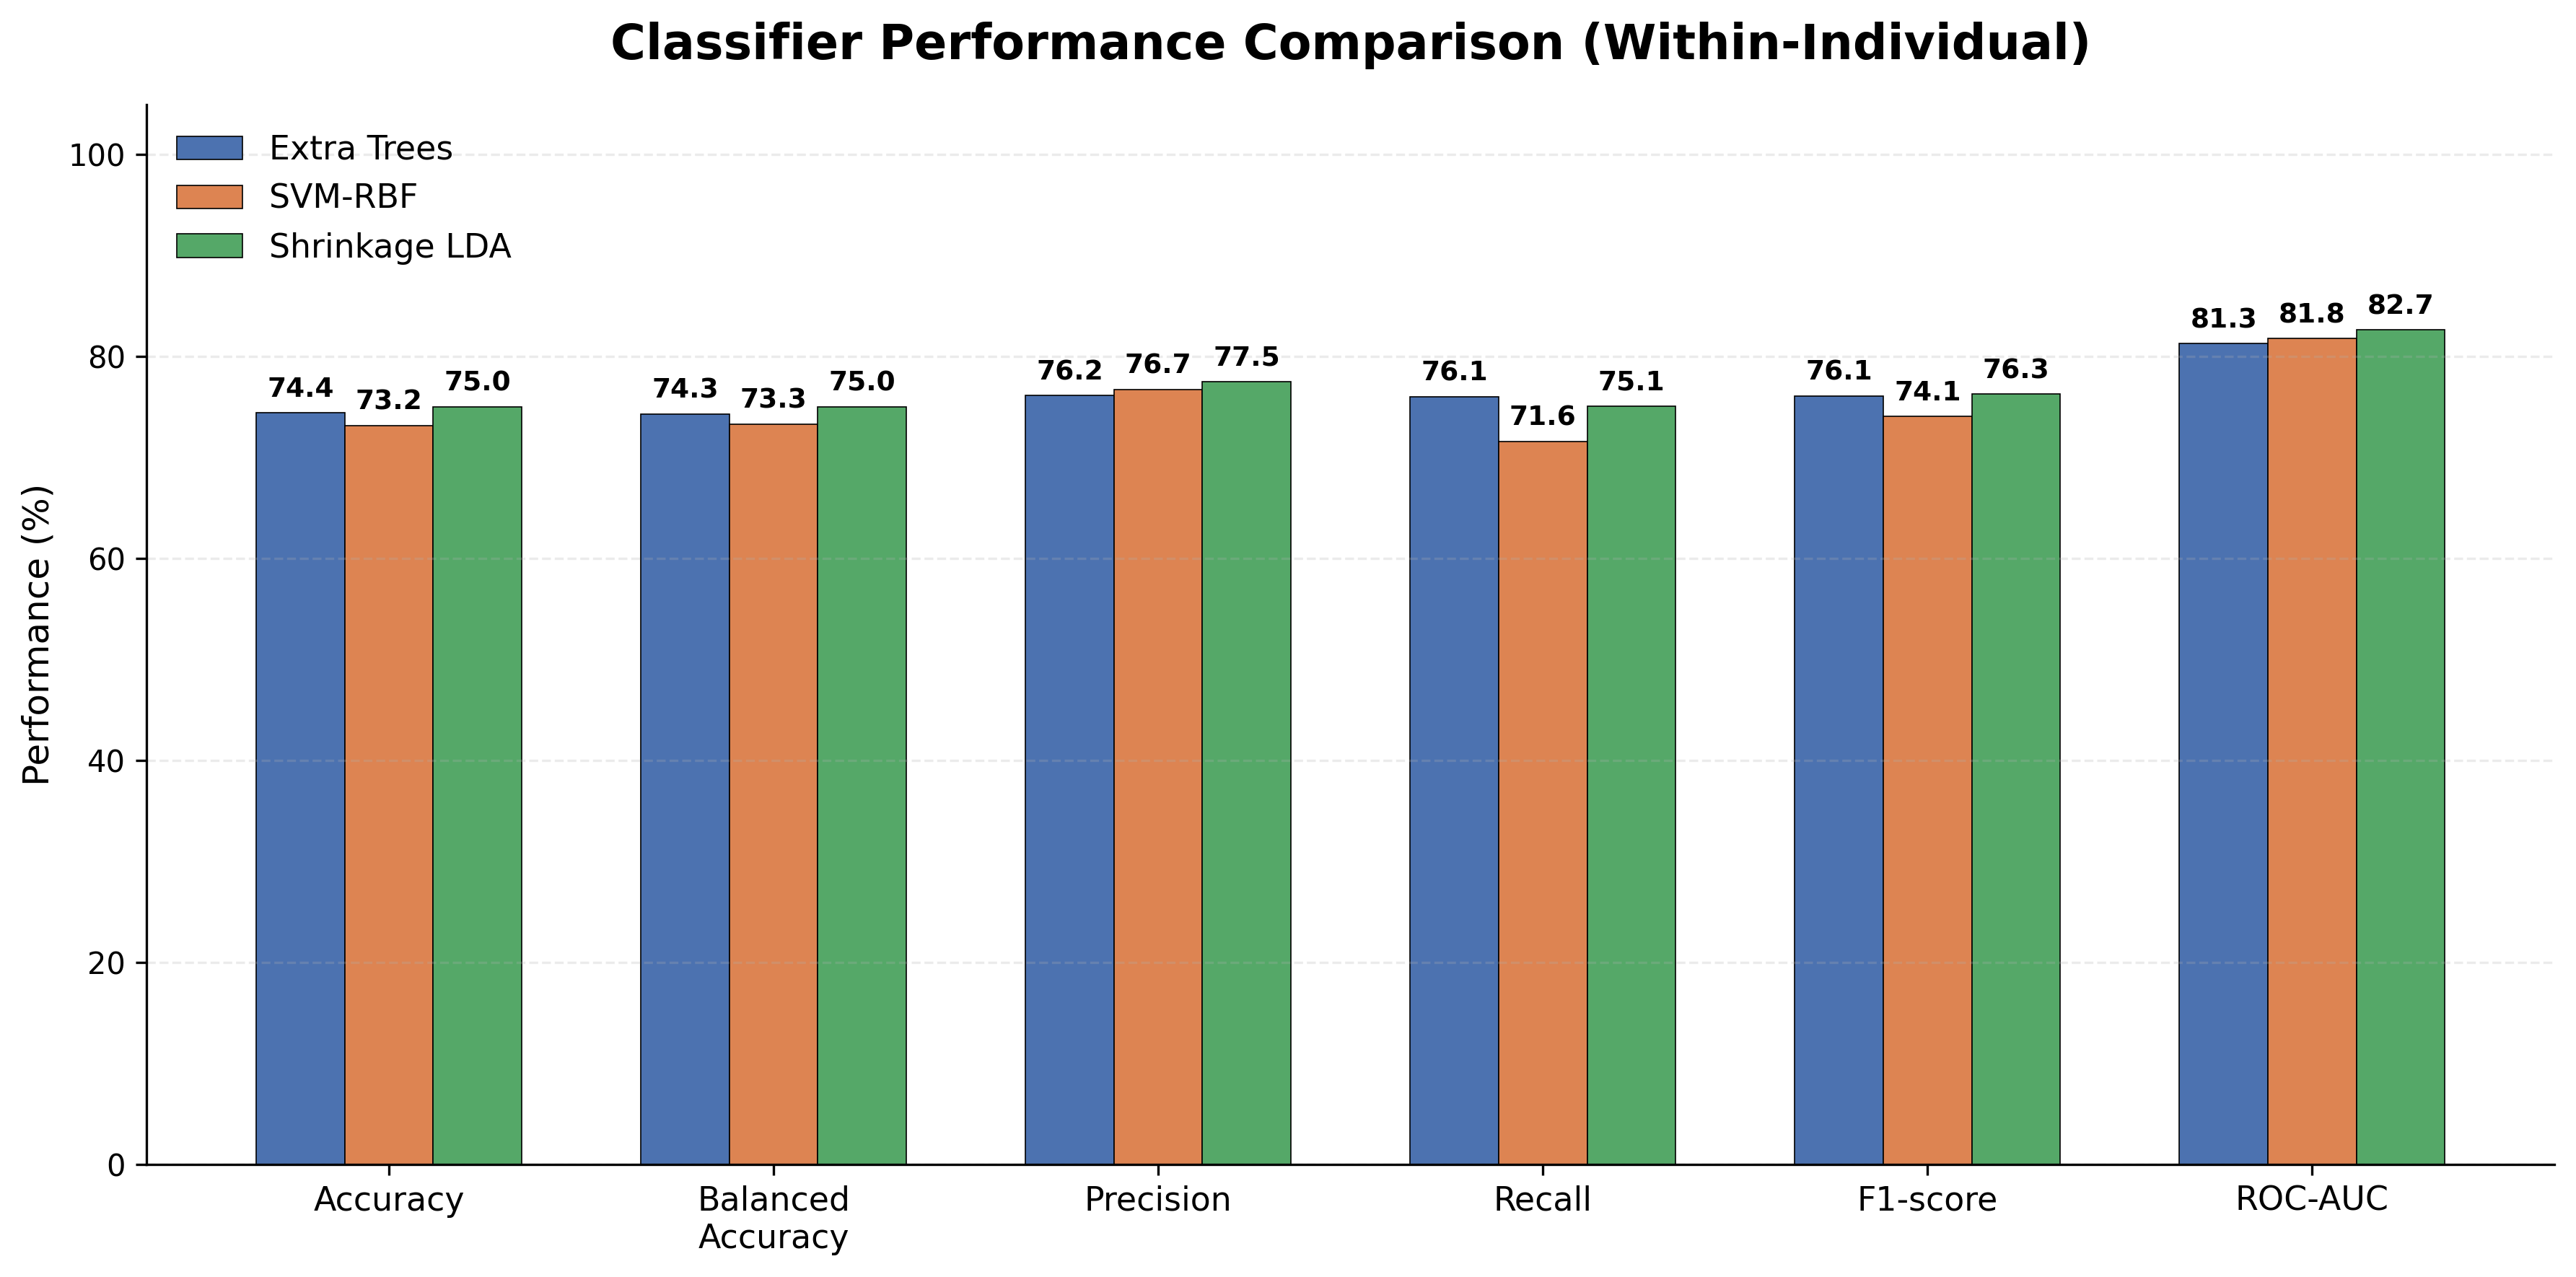

Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/model_performance_comparison.png


In [ ]:
# CELL — Publication-level model performance comparison

import matplotlib.pyplot as plt
import numpy as np


# -------------------------------------------------
# Metrics
# -------------------------------------------------

metrics = [
    "Accuracy",
    "Balanced\nAccuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]


models = (
    performance_df["Model"]
    .tolist()
)


# -------------------------------------------------
# Data
# -------------------------------------------------

data = []

for model in models:

    data.append(
        performance_df
        .loc[
            performance_df["Model"] == model,
            [
                "Accuracy",
                "Balanced Accuracy",
                "Precision",
                "Recall",
                "F1-score",
                "ROC-AUC"
            ]
        ]
        .values[0]
    )


data = np.array(data)



# -------------------------------------------------
# Figure
# -------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12,6),
    dpi=300
)


x = np.arange(
    len(metrics)
)


width = 0.23



# Premium colors

colors = {

    "Extra Trees":
        "#4C72B0",

    "SVM-RBF":
        "#DD8452",

    "Shrinkage LDA":
        "#55A868",

}



# -------------------------------------------------
# Bars
# -------------------------------------------------

for i, model in enumerate(models):

    bars = ax.bar(
        x + (i-1)*width,
        data[i],
        width,
        label=model,
        color=colors[model],
        edgecolor="black",
        linewidth=0.4
    )


    # value labels

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x()+bar.get_width()/2,
            height+1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )



# -------------------------------------------------
# Formatting
# -------------------------------------------------

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metrics,
    fontsize=11
)


ax.set_ylabel(
    "Performance (%)",
    fontsize=12
)


ax.set_ylim(
    0,
    105
)


ax.set_title(
    "Classifier Performance Comparison (Within-Individual)",
    fontsize=16,
    fontweight="bold",
    pad=15
)


# remove top/right borders

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)



ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)



ax.legend(
    frameon=False,
    fontsize=11,
    loc="upper left"
)



plt.tight_layout()



# Save

save_path = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH/"
    "model_performance_comparison.png"
)


plt.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    save_path
)

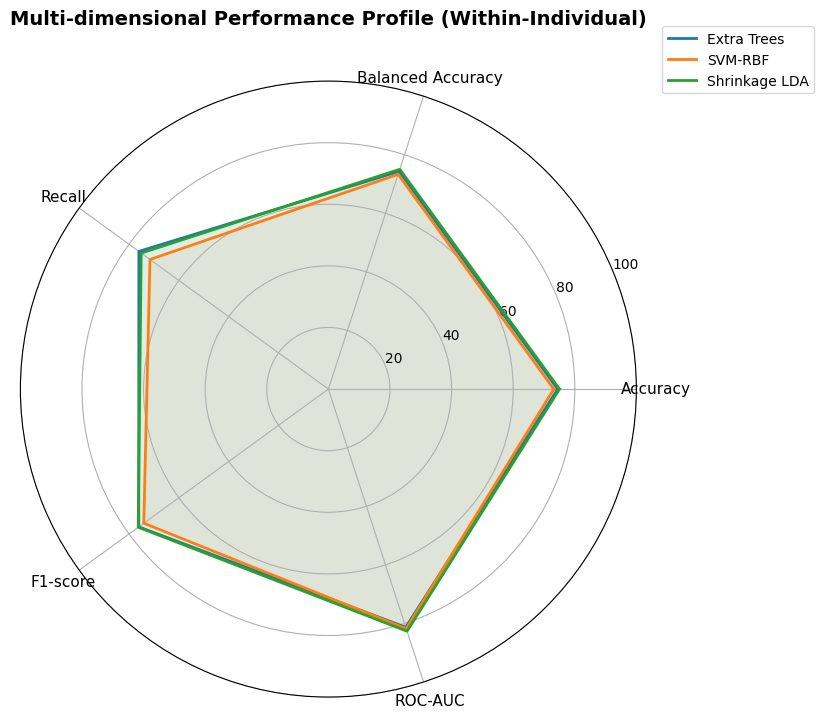

In [ ]:
# CELL — Radar chart model comparison

import matplotlib.pyplot as plt
import numpy as np


radar_metrics = [

    "Accuracy",
    "Balanced Accuracy",
    "Recall",
    "F1-score",
    "ROC-AUC"

]


angles = np.linspace(
    0,
    2*np.pi,
    len(radar_metrics),
    endpoint=False
)


angles = np.concatenate(
    [
        angles,
        [angles[0]]
    ]
)


fig = plt.figure(
    figsize=(8,8)
)


ax = plt.subplot(
    111,
    polar=True
)


for _, row in performance_df.iterrows():

    values = (
        row[radar_metrics]
        .values
        .astype(float)
    )


    values = np.concatenate(
        [
            values,
            [values[0]]
        ]
    )


    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )


    ax.fill(
        angles,
        values,
        alpha=0.08
    )


ax.set_xticks(
    angles[:-1]
)


ax.set_xticklabels(
    radar_metrics,
    fontsize=11
)


ax.set_ylim(
    0,
    100
)


ax.set_title(
    "Multi-dimensional Performance Profile (Within-Individual)\n",
    fontsize=14,
    weight="bold",
    pad=25
)


ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.3,1.1)
)


plt.show()

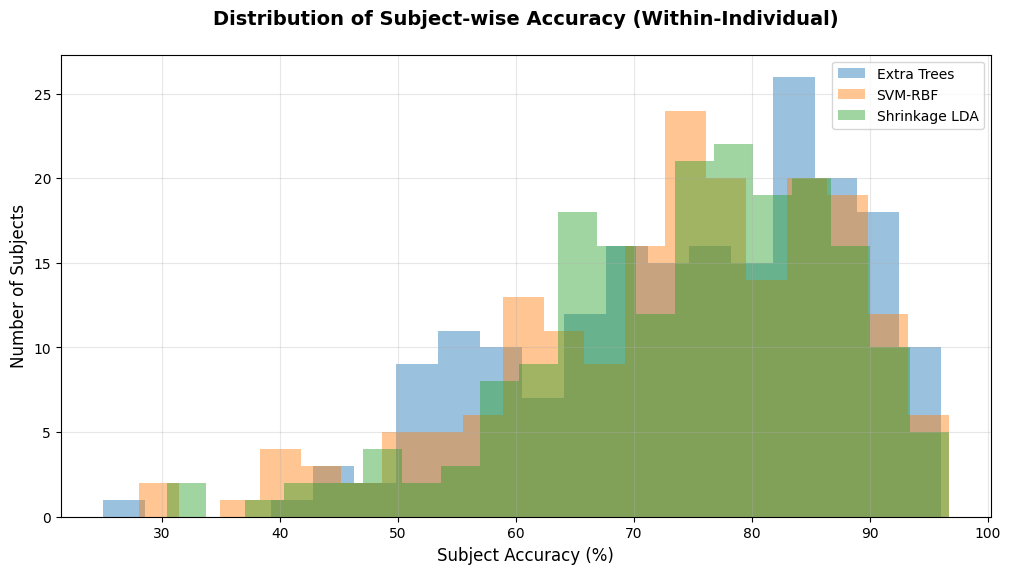

In [ ]:
# CELL — Subject accuracy distribution

import matplotlib.pyplot as plt


plt.figure(
    figsize=(12,6)
)


for model_name, result in model_results.items():

    subject_accuracy = (
        result["subject_results"]
        ["accuracy"]
        *100
    )


    plt.hist(
        subject_accuracy,
        bins=20,
        alpha=0.45,
        label=model_name
    )


plt.xlabel(
    "Subject Accuracy (%)",
    fontsize=12
)


plt.ylabel(
    "Number of Subjects",
    fontsize=12
)


plt.title(
    "Distribution of Subject-wise Accuracy (Within-Individual)\n",
    fontsize=14,
    weight="bold"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.show()

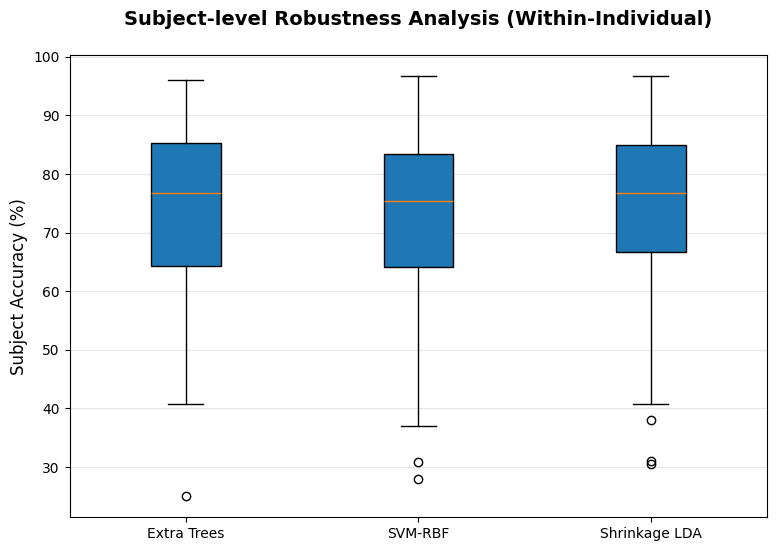

In [ ]:
# CELL — Subject accuracy boxplot

import matplotlib.pyplot as plt


box_data = []


labels = []


for model_name, result in model_results.items():

    box_data.append(
        result["subject_results"]
        ["accuracy"]
        *100
    )

    labels.append(
        model_name
    )


plt.figure(
    figsize=(9,6)
)


plt.boxplot(
    box_data,
    labels=labels,
    patch_artist=True
)


plt.ylabel(
    "Subject Accuracy (%)",
    fontsize=12
)


plt.title(
    "Subject-level Robustness Analysis (Within-Individual)\n"
    ,
    fontsize=14,
    weight="bold"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.show()

In [ ]:
# Check saved prediction columns

for model_name, result in model_results.items():

    print("\n", "="*70)
    print(model_name)

    print(
        result["predictions"].columns.tolist()
    )

    display(
        result["predictions"].head()
    )


Extra Trees
['experiment', 'model', 'feature_set', 'test_subject', 'subject_trial_position', 'original_row_index', 'y_true', 'y_pred', 'y_score', 'score_source', 'fit_seconds', 'prediction_seconds', 'train_accuracy', 'trial_num', 'painrating', 'laser_power', 'event_type', 'source_file']


,experiment,model,feature_set,test_subject,subject_trial_position,original_row_index,y_true,y_pred,y_score,score_source,fit_seconds,prediction_seconds,train_accuracy,trial_num,painrating,laser_power,event_type,source_file
0,ExtraTrees__Fusion_964_PCA10__ET100_depth8_lea...,ExtraTrees,Fusion_964_PCA10,sub-001,0,0,0,0,0.484972,predict_proba,0.285650,0.055131,NaN,1,0,3.5,S 32,sub-001_223ByBP.set
1,ExtraTrees__Fusion_964_PCA10__ET100_depth8_lea...,ExtraTrees,Fusion_964_PCA10,sub-001,1,1,1,1,0.709135,predict_proba,0.496750,0.054586,NaN,2,5,4.0,S 33,sub-001_223ByBP.set
2,ExtraTrees__Fusion_964_PCA10__ET100_depth8_lea...,ExtraTrees,Fusion_964_PCA10,sub-001,2,2,1,1,0.762916,predict_proba,0.390520,0.069024,NaN,3,5,4.0,S 33,sub-001_223ByBP.set
3,ExtraTrees__Fusion_964_PCA10__ET100_depth8_lea...,ExtraTrees,Fusion_964_PCA10,sub-001,3,3,0,0,0.490776,predict_proba,0.258509,0.056968,NaN,4,3,3.5,S 32,sub-001_223ByBP.set
4,ExtraTrees__Fusion_964_PCA10__ET100_depth8_lea...,ExtraTrees,Fusion_964_PCA10,sub-001,4,4,0,0,0.420814,predict_proba,0.322223,0.059008,NaN,5,4,3.5,S 32,sub-001_223ByBP.set



SVM-RBF
['experiment', 'model', 'feature_set', 'test_subject', 'subject_trial_position', 'original_row_index', 'y_true', 'y_pred', 'y_score', 'score_source', 'fit_seconds', 'prediction_seconds', 'train_accuracy', 'trial_num', 'painrating', 'laser_power', 'event_type', 'source_file']


,experiment,model,feature_set,test_subject,subject_trial_position,original_row_index,y_true,y_pred,y_score,score_source,fit_seconds,prediction_seconds,train_accuracy,trial_num,painrating,laser_power,event_type,source_file
0,SVM_RBF__Fusion_964_PCA10__C1_gammaScale_PCA10...,SVM_RBF,Fusion_964_PCA10,sub-001,0,0,0,0,-0.837817,decision_function,0.131876,0.002744,NaN,1,0,3.5,S 32,sub-001_223ByBP.set
1,SVM_RBF__Fusion_964_PCA10__C1_gammaScale_PCA10...,SVM_RBF,Fusion_964_PCA10,sub-001,1,1,1,1,1.477028,decision_function,0.116759,0.002889,NaN,2,5,4.0,S 33,sub-001_223ByBP.set
2,SVM_RBF__Fusion_964_PCA10__C1_gammaScale_PCA10...,SVM_RBF,Fusion_964_PCA10,sub-001,2,2,1,1,0.853311,decision_function,0.122583,0.005610,NaN,3,5,4.0,S 33,sub-001_223ByBP.set
3,SVM_RBF__Fusion_964_PCA10__C1_gammaScale_PCA10...,SVM_RBF,Fusion_964_PCA10,sub-001,3,3,0,0,-0.210869,decision_function,0.126151,0.002623,NaN,4,3,3.5,S 32,sub-001_223ByBP.set
4,SVM_RBF__Fusion_964_PCA10__C1_gammaScale_PCA10...,SVM_RBF,Fusion_964_PCA10,sub-001,4,4,0,0,-0.512722,decision_function,0.136562,0.003129,NaN,5,4,3.5,S 32,sub-001_223ByBP.set



Shrinkage LDA
['experiment', 'model', 'feature_set', 'test_subject', 'subject_trial_position', 'original_row_index', 'y_true', 'y_pred', 'y_score', 'score_source', 'fit_seconds', 'prediction_seconds', 'train_accuracy', 'trial_num', 'painrating', 'laser_power', 'event_type', 'source_file']


,experiment,model,feature_set,test_subject,subject_trial_position,original_row_index,y_true,y_pred,y_score,score_source,fit_seconds,prediction_seconds,train_accuracy,trial_num,painrating,laser_power,event_type,source_file
0,ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrin...,ShrinkageLDA,Fusion_964_PCA10,sub-001,0,0,0,0,0.162538,predict_proba,0.021321,0.003031,NaN,1,0,3.5,S 32,sub-001_223ByBP.set
1,ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrin...,ShrinkageLDA,Fusion_964_PCA10,sub-001,1,1,1,1,0.809903,predict_proba,0.012490,0.002686,NaN,2,5,4.0,S 33,sub-001_223ByBP.set
2,ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrin...,ShrinkageLDA,Fusion_964_PCA10,sub-001,2,2,1,1,0.989167,predict_proba,0.012579,0.002800,NaN,3,5,4.0,S 33,sub-001_223ByBP.set
3,ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrin...,ShrinkageLDA,Fusion_964_PCA10,sub-001,3,3,0,0,0.415925,predict_proba,0.010939,0.002200,NaN,4,3,3.5,S 32,sub-001_223ByBP.set
4,ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrin...,ShrinkageLDA,Fusion_964_PCA10,sub-001,4,4,0,0,0.268402,predict_proba,0.018353,0.002383,NaN,5,4,3.5,S 32,sub-001_223ByBP.set


In [ ]:
# CELL — Within-individual Strict-192 Confusion Matrix Verification
# Extra Trees vs SVM-RBF vs Shrinkage LDA

from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np



# =========================================================
# Models
# =========================================================

within_model_results = {

    "Extra Trees":
        within_extra_trees_results,

    "SVM-RBF":
        within_svm_rbf_results,

    "Shrinkage LDA":
        within_shrinkage_lda_results

}



# =========================================================
# Calculate confusion matrices
# =========================================================

for model_name, result in within_model_results.items():

    print("\n" + "="*70)
    print(model_name)
    print("="*70)


    pred_df = result["predictions"]


    # Raw confusion matrix

    cm = confusion_matrix(

        pred_df["y_true"],

        pred_df["y_pred"]

    )


    # Row normalized %

    cm_norm = (

        cm.astype(float)

        /

        cm.sum(
            axis=1,
            keepdims=True
        )

        *100

    )


    print("\nRaw Confusion Matrix:")

    display(
        pd.DataFrame(

            cm,

            index=[
                "True Low Pain",
                "True High Pain"
            ],

            columns=[
                "Pred Low Pain",
                "Pred High Pain"
            ]

        )
    )


    print("\nRow Normalized Confusion Matrix (%):")


    display(

        pd.DataFrame(

            cm_norm.round(2),

            index=[
                "True Low Pain",
                "True High Pain"
            ],

            columns=[
                "Pred Low Pain",
                "Pred High Pain"
            ]

        )

    )


    # Extra verification

    print(
        "\nTotal trials:",
        len(pred_df)
    )


    print(
        "Class distribution:"
    )


    print(
        pred_df["y_true"]
        .value_counts()
        .sort_index()
    )


Extra Trees

Raw Confusion Matrix:


,Pred Low Pain,Pred High Pain
True Low Pain,1825,689
True High Pain,693,2201



Row Normalized Confusion Matrix (%):


,Pred Low Pain,Pred High Pain
True Low Pain,72.59,27.41
True High Pain,23.95,76.05



Total trials: 5408
Class distribution:
y_true
0    2514
1    2894
Name: count, dtype: int64

SVM-RBF

Raw Confusion Matrix:


...


Total trials: 5408
Class distribution:
y_true
0    2514
1    2894
Name: count, dtype: int64

Shrinkage LDA

Raw Confusion Matrix:


,Pred Low Pain,Pred High Pain
True Low Pain,1884,630
True High Pain,720,2174



Row Normalized Confusion Matrix (%):


,Pred Low Pain,Pred High Pain
True Low Pain,74.94,25.06
True High Pain,24.88,75.12



Total trials: 5408
Class distribution:
y_true
0    2514
1    2894
Name: count, dtype: int64


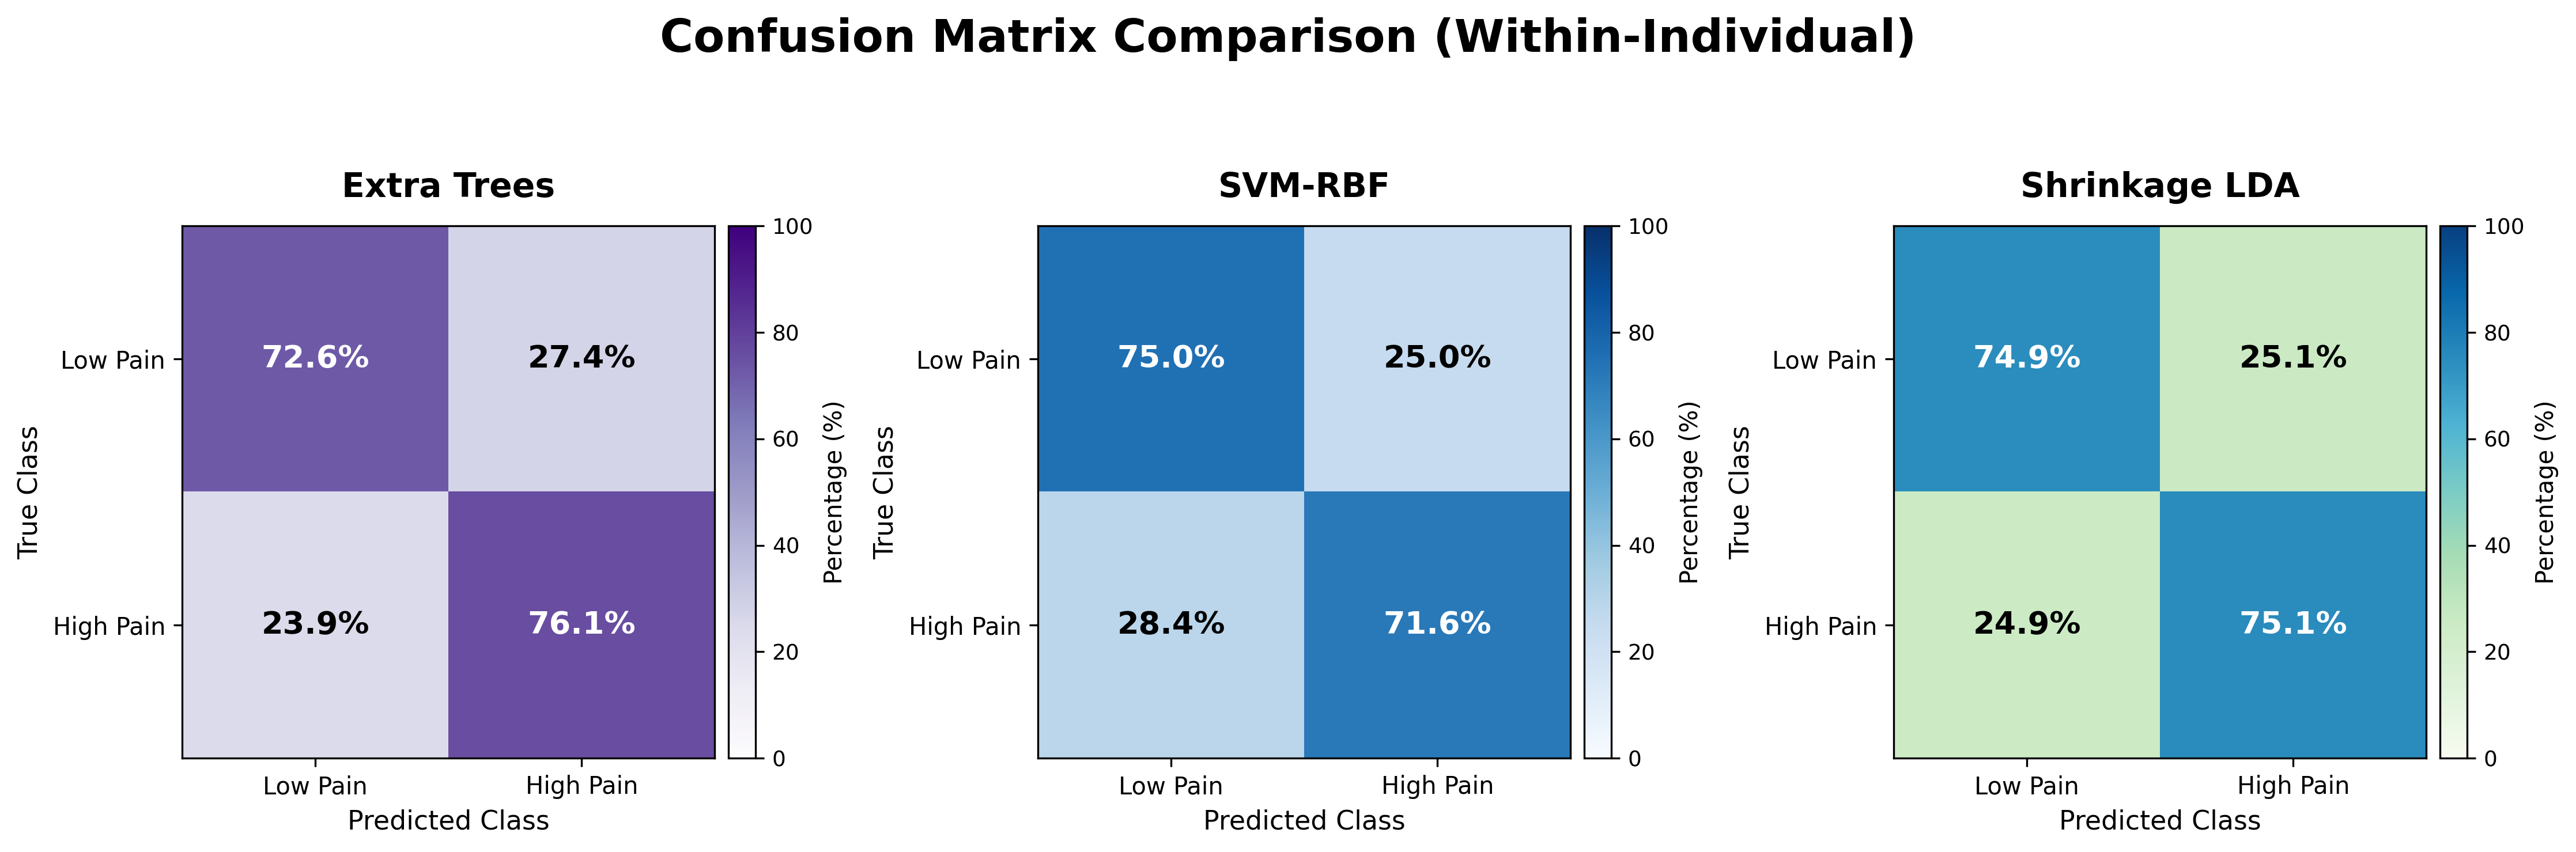

Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/within_individual_confusion_matrix_comparison.png


In [ ]:
# CELL — Premium Confusion Matrix Comparison
# Strict Within-Individual LOOCV (192 Subjects)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable



# =========================================================
# Model-specific color palettes
# =========================================================

model_cmaps = {

    "Extra Trees":
        "Purples",

    "SVM-RBF":
        "Blues",

    "Shrinkage LDA":
        "GnBu",

}



# =========================================================
# Figure setup
# =========================================================

fig, axes = plt.subplots(

    1,
    3,

    figsize=(15,5),

    dpi=300

)



# =========================================================
# Plot confusion matrices
# =========================================================

for ax, (model_name, result) in zip(

    axes,

    model_results.items()

):


    pred_df = result["predictions"]


    cm = confusion_matrix(

        pred_df["y_true"],

        pred_df["y_pred"]

    )


    # Row normalized

    cm_norm = (

        cm.astype(float)

        /

        cm.sum(
            axis=1,
            keepdims=True
        )

        *100

    )


    im = ax.imshow(

        cm_norm,

        cmap=model_cmaps[model_name],

        vmin=0,

        vmax=100

    )



    # Cell values

    for i in range(2):

        for j in range(2):

            value = cm_norm[i,j]


            ax.text(

                j,

                i,

                f"{value:.1f}%",

                ha="center",

                va="center",

                fontsize=13,

                fontweight="bold",

                color=(
                    "white"
                    if value >= 55
                    else "black"
                )

            )



    # Axis labels

    ax.set_xticks(
        [0,1]
    )

    ax.set_yticks(
        [0,1]
    )


    ax.set_xticklabels(

        [
            "Low Pain",
            "High Pain"
        ],

        fontsize=10

    )


    ax.set_yticklabels(

        [
            "Low Pain",
            "High Pain"
        ],

        fontsize=10

    )


    ax.set_xlabel(

        "Predicted Class",

        fontsize=11

    )


    ax.set_ylabel(

        "True Class",

        fontsize=11

    )


    ax.set_title(

        model_name,

        fontsize=14,

        fontweight="bold",

        pad=12

    )



    # =====================================================
    # Colorbar fixed to right side
    # =====================================================

    divider = make_axes_locatable(ax)


    cax = divider.append_axes(

        "right",

        size="5%",

        pad=0.08

    )


    cbar = fig.colorbar(

        im,

        cax=cax

    )


    cbar.set_label(

        "Percentage (%)",

        fontsize=10

    )


    cbar.ax.tick_params(

        labelsize=9

    )



# =========================================================
# Main title
# =========================================================

fig.suptitle(

    "Confusion Matrix Comparison (Within-Individual)",

    fontsize=19,

    fontweight="bold",

    y=1.02

)



plt.tight_layout()



# =========================================================
# Save
# =========================================================

save_path = (

    "/content/drive/MyDrive/"

    "EXP8_CLASSIFICATION_FROM_SCRATCH/"

    "V5_MAIN_PIPELINE_12CH/"

    "within_individual_confusion_matrix_comparison.png"

)



plt.savefig(

    save_path,

    dpi=600,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:",
    save_path
)

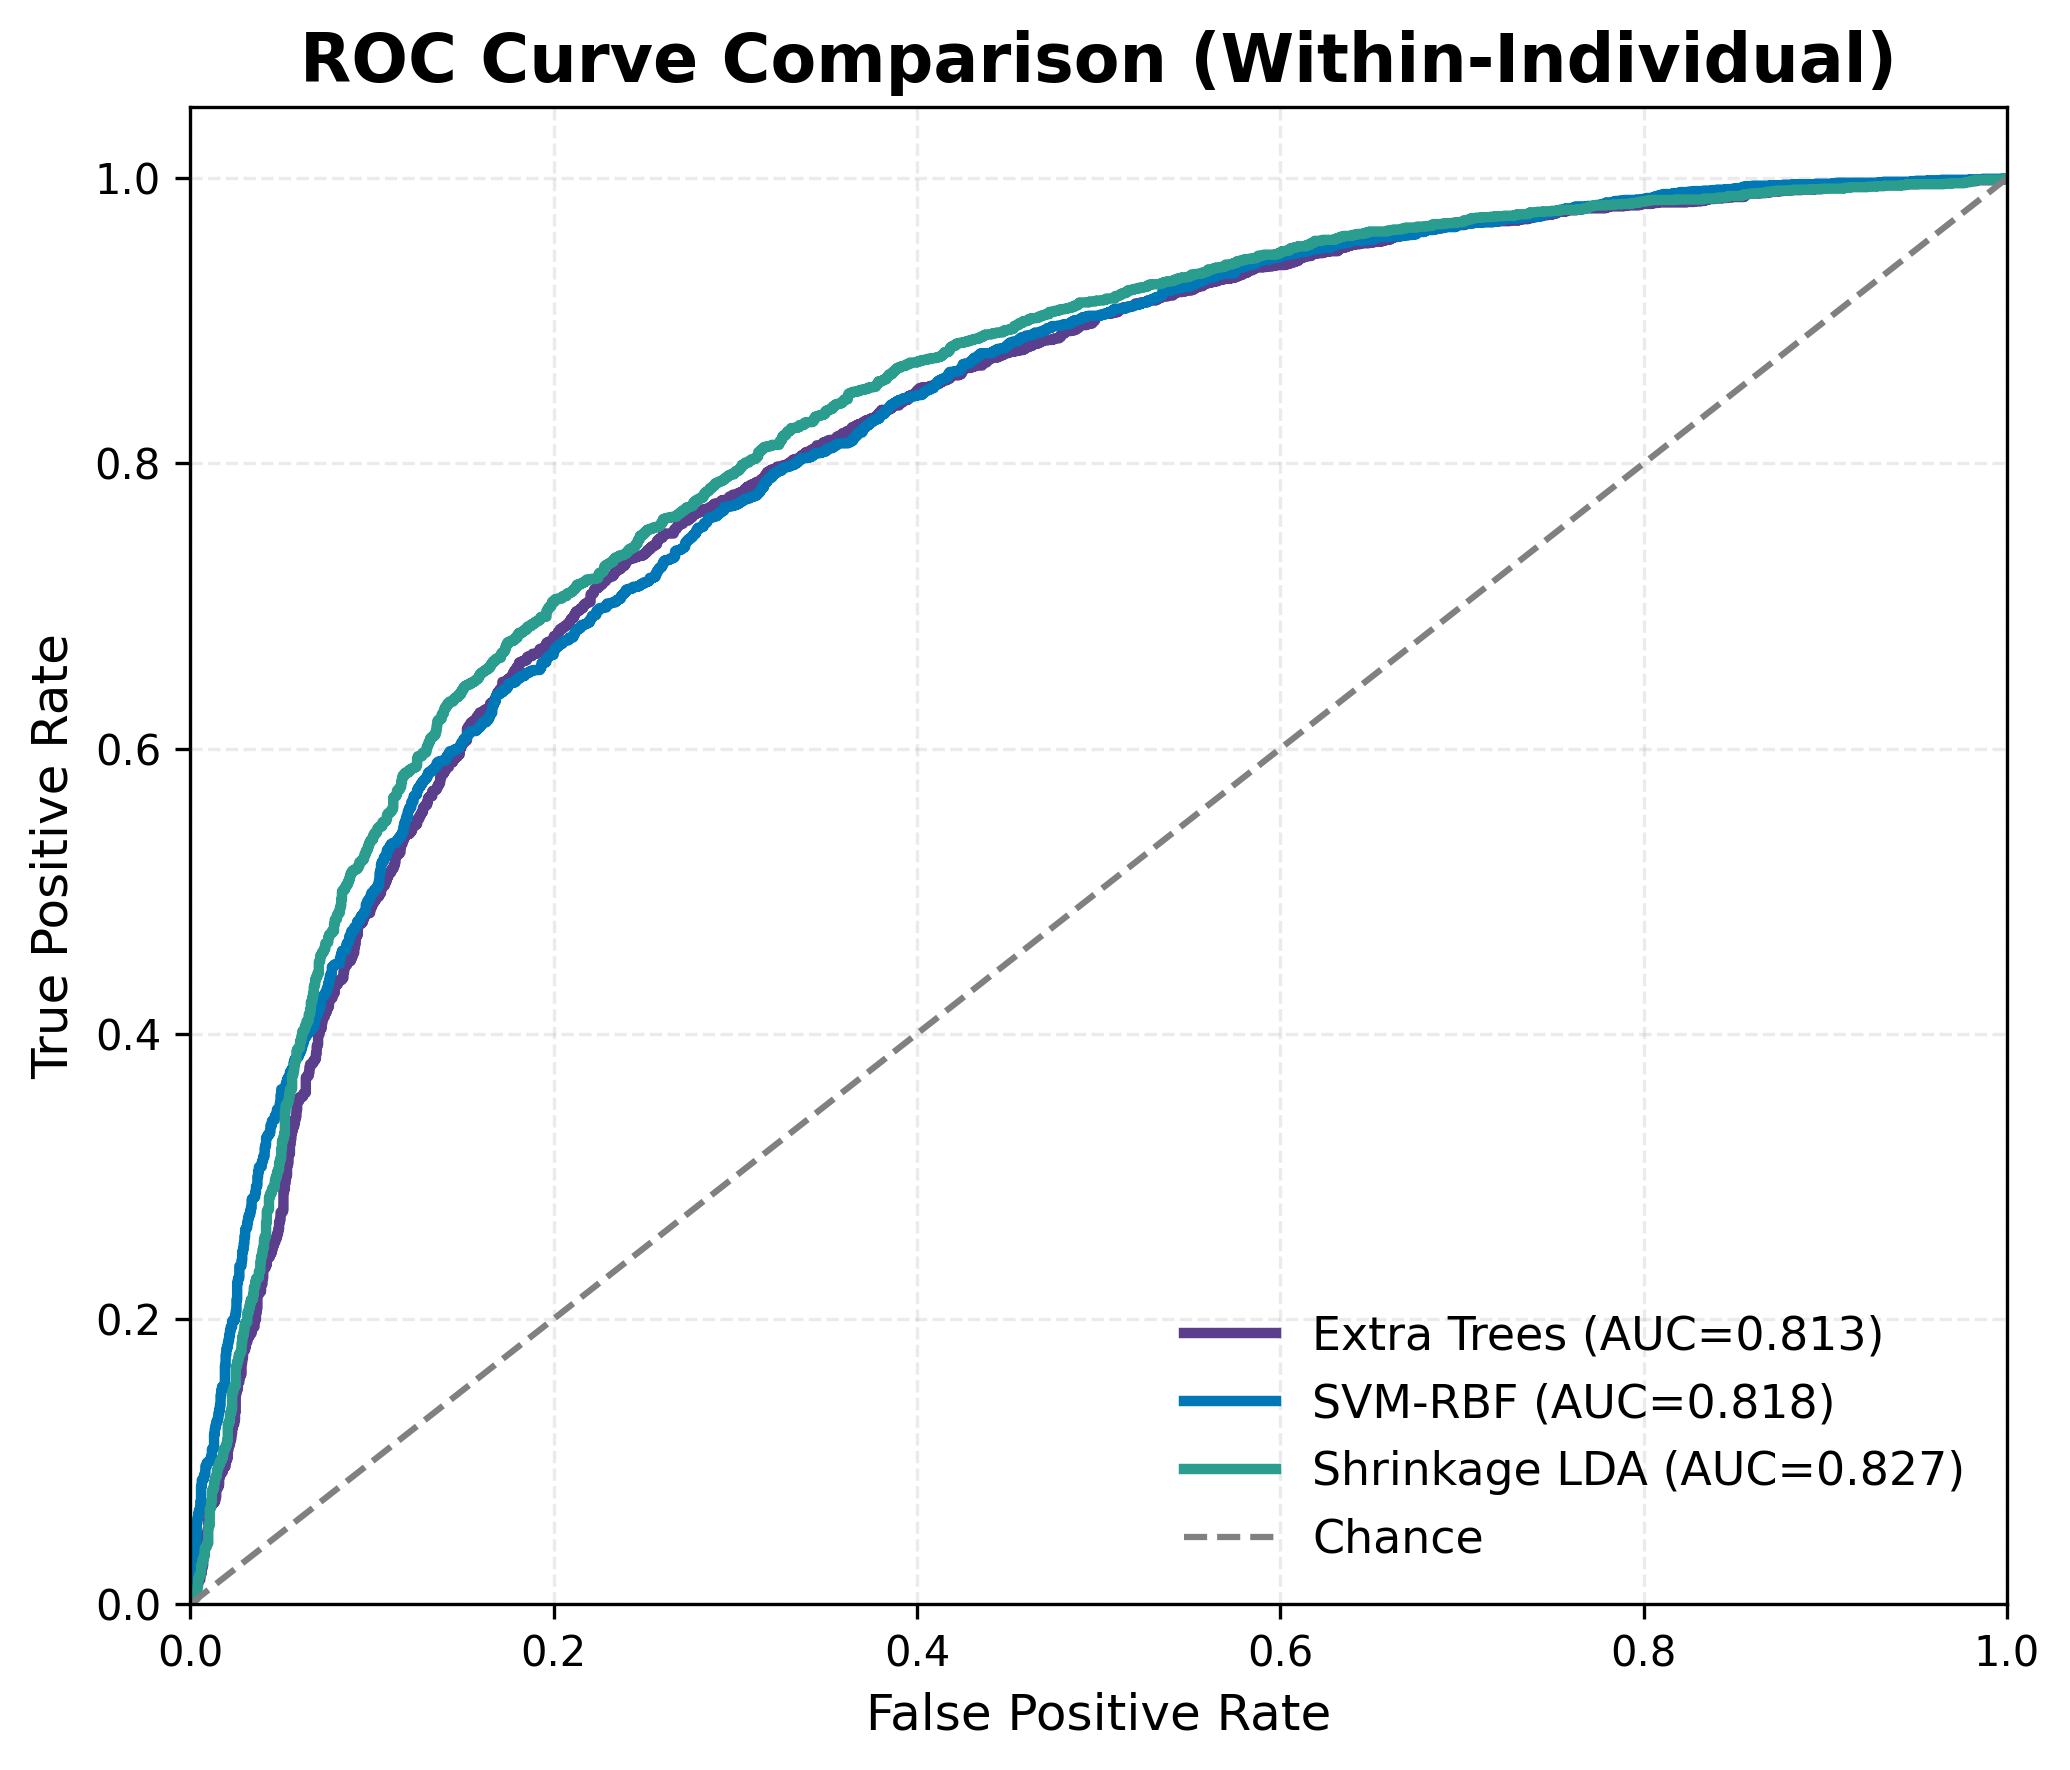

Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/within_individual_ROC_comparison.png


In [ ]:
# CELL — Within-individual ROC Curve Comparison
# Strict-192 LOOCV

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt



# =========================================================
# Within-individual model results
# =========================================================

within_model_results = {

    "Extra Trees":
        within_extra_trees_results,

    "SVM-RBF":
        within_svm_rbf_results,

    "Shrinkage LDA":
        within_shrinkage_lda_results

}



# =========================================================
# Figure setup
# =========================================================

plt.figure(

    figsize=(7,6),

    dpi=300

)



# Premium cool-tone colors
# Different from LOSO ROC curve

roc_colors = {

    "Extra Trees":
        "#5B3F8C",   # Deep purple

    "SVM-RBF":
        "#0077B6",   # Deep ocean blue

    "Shrinkage LDA":
        "#2A9D8F"    # Teal green

}



# =========================================================
# Plot ROC curves
# =========================================================

for model_name, result in within_model_results.items():


    pred_df = result["predictions"]


    y_true = pred_df["y_true"]


    y_score = pred_df["y_score"]



    fpr, tpr, _ = roc_curve(

        y_true,

        y_score

    )


    roc_auc = auc(

        fpr,

        tpr

    )



    plt.plot(

        fpr,

        tpr,

        linewidth=2.5,

        color=roc_colors[model_name],

        label=f"{model_name} (AUC={roc_auc:.3f})"

    )



# Random classifier line

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    linewidth=1.5,

    color="gray",

    label="Chance"

)



# =========================================================
# Formatting
# =========================================================

plt.xlabel(

    "False Positive Rate",

    fontsize=12

)


plt.ylabel(

    "True Positive Rate",

    fontsize=12

)



plt.title(

    "ROC Curve Comparison (Within-Individual)",

    fontsize=16,

    fontweight="bold"

)



plt.xlim(

    [0,1]

)


plt.ylim(

    [0,1.05]

)



plt.grid(

    linestyle="--",

    alpha=0.25

)



plt.legend(

    frameon=False,

    fontsize=11,

    loc="lower right"

)



plt.tight_layout()



# =========================================================
# Save
# =========================================================

save_path = (

    "/content/drive/MyDrive/"

    "EXP8_CLASSIFICATION_FROM_SCRATCH/"

    "V5_MAIN_PIPELINE_12CH/"

    "within_individual_ROC_comparison.png"

)



plt.savefig(

    save_path,

    dpi=600,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:",
    save_path
)

In [ ]:
# CELL — Cross-individual LOSO feature importance
# Supports Extra Trees, Random Forest and XGBoost
# Original feature space: 964 V5 fusion features

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut


# ============================================================
# 1. Feature-importance output directory
# ============================================================

CROSS_FEATURE_IMPORTANCE_DIR = os.path.join(
    V5_DIR,
    "V5_LOSO_RESULTS",
    "FEATURE_IMPORTANCE"
)

os.makedirs(
    CROSS_FEATURE_IMPORTANCE_DIR,
    exist_ok=True
)

print("Cross-individual feature-importance directory:")
print(CROSS_FEATURE_IMPORTANCE_DIR)


# ============================================================
# 2. Load the 964 feature names
# ============================================================

def load_v5_fusion_feature_names(
    v5_directory,
    expected_features=964
):
    candidate_paths = [
        os.path.join(
            v5_directory,
            "v5_fusion_feature_names_964.csv"
        ),
        os.path.join(
            v5_directory,
            "V5_fusion_feature_names_964.csv"
        ),
        os.path.join(
            v5_directory,
            "fusion_feature_names_964.csv"
        ),
    ]

    for path in candidate_paths:

        if not os.path.exists(path):
            continue

        names_df = pd.read_csv(path)

        preferred_columns = [
            "feature_name",
            "Feature",
            "feature",
            "name",
        ]

        selected_column = None

        for column in preferred_columns:
            if column in names_df.columns:
                selected_column = column
                break

        if selected_column is None:

            if names_df.shape[1] == 1:
                selected_column = names_df.columns[0]

            else:
                text_columns = names_df.select_dtypes(
                    include=["object"]
                ).columns

                if len(text_columns) > 0:
                    selected_column = text_columns[0]

        if selected_column is not None:

            feature_names = (
                names_df[selected_column]
                .astype(str)
                .to_numpy()
            )

            if len(feature_names) == expected_features:

                print("Loaded feature names:")
                print(path)

                return feature_names

    print(
        "Feature-name file was not found or had an "
        "unexpected format. Generic feature names will be used."
    )

    return np.asarray([
        f"Feature_{index:04d}"
        for index in range(expected_features)
    ])


v5_fusion_feature_names = (
    load_v5_fusion_feature_names(
        V5_DIR,
        expected_features=X_v5_fusion.shape[1]
    )
)

assert len(v5_fusion_feature_names) == 964

print("Number of feature names:", len(v5_fusion_feature_names))


# ============================================================
# 3. Helper functions
# ============================================================

def safe_filename(text):

    text = str(text).strip()

    text = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        text
    )

    return text.strip("_")


def atomic_save_csv(
    dataframe,
    path
):
    temporary_path = f"{path}.temporary"

    dataframe.to_csv(
        temporary_path,
        index=False
    )

    os.replace(
        temporary_path,
        path
    )


def get_final_estimator(
    fitted_model
):
    """
    Return the classifier from either:
        - a direct estimator, or
        - the final step of a fitted sklearn Pipeline.
    """

    if hasattr(
        fitted_model,
        "named_steps"
    ):
        return list(
            fitted_model.named_steps.values()
        )[-1]

    return fitted_model


def extract_native_feature_importance(
    fitted_model,
    expected_features
):
    final_estimator = get_final_estimator(
        fitted_model
    )

    if not hasattr(
        final_estimator,
        "feature_importances_"
    ):
        raise AttributeError(
            f"{final_estimator.__class__.__name__} "
            "does not provide feature_importances_."
        )

    importance = np.asarray(
        final_estimator.feature_importances_,
        dtype=float
    ).ravel()

    if len(importance) != expected_features:
        raise ValueError(
            "The model importance length does not match "
            f"the original feature count. Expected "
            f"{expected_features}, found {len(importance)}."
        )

    if not np.isfinite(importance).all():
        raise ValueError(
            "Feature importance contains NaN or infinity."
        )

    importance_sum = importance.sum()

    if importance_sum > 0:
        importance = importance / importance_sum

    return importance


# ============================================================
# 4. Main cross-individual importance evaluator
# ============================================================

def run_cross_loso_native_feature_importance(
    X,
    y,
    groups,
    estimator,
    model_name,
    feature_names,
    experiment_tag,
    expected_subjects=223,
    resume=True,
    overwrite=False,
    top_n=30,
):
    """
    Aggregate native model importance across LOSO folds.

    The held-out subject is never used during fitting.
    Feature importance is extracted from each fold's
    training-only fitted model.
    """

    y = np.asarray(
        y,
        dtype=np.int8
    ).ravel()

    groups = np.asarray(
        groups
    ).astype(str).ravel()

    feature_names = np.asarray(
        feature_names
    ).astype(str)

    n_samples, n_features = X.shape

    if n_samples != len(y):
        raise ValueError("X and y are not aligned.")

    if len(groups) != len(y):
        raise ValueError("groups and y are not aligned.")

    if len(feature_names) != n_features:
        raise ValueError(
            "Feature-name count does not match X."
        )

    unique_subjects = np.unique(groups)

    if len(unique_subjects) != expected_subjects:
        raise ValueError(
            f"Expected {expected_subjects} subjects, "
            f"found {len(unique_subjects)}."
        )

    safe_model = safe_filename(model_name)
    safe_tag = safe_filename(experiment_tag)

    experiment_name = (
        f"{safe_model}__Fusion964__"
        f"{safe_tag}__LOSO_importance"
    )

    fold_importance_path = os.path.join(
        CROSS_FEATURE_IMPORTANCE_DIR,
        f"{experiment_name}__fold_importance.csv"
    )

    aggregate_importance_path = os.path.join(
        CROSS_FEATURE_IMPORTANCE_DIR,
        f"{experiment_name}__aggregate_importance.csv"
    )

    top_importance_path = os.path.join(
        CROSS_FEATURE_IMPORTANCE_DIR,
        f"{experiment_name}__top{top_n}_importance.csv"
    )

    plot_path = os.path.join(
        CROSS_FEATURE_IMPORTANCE_DIR,
        f"{experiment_name}__top{top_n}_importance.png"
    )

    output_paths = [
        fold_importance_path,
        aggregate_importance_path,
        top_importance_path,
        plot_path,
    ]

    print("\n" + "=" * 80)
    print("CROSS-INDIVIDUAL LOSO FEATURE IMPORTANCE")
    print("=" * 80)

    print("Model:", model_name)
    print("Subjects:", len(unique_subjects))
    print("Features:", n_features)

    print("\nFold-level importance:")
    print(fold_importance_path)

    print("\nAggregated importance:")
    print(aggregate_importance_path)

    print("\nTop feature table:")
    print(top_importance_path)

    print("\nImportance plot:")
    print(plot_path)

    if overwrite:

        for path in output_paths:
            if os.path.exists(path):
                os.remove(path)

    # --------------------------------------------------------
    # Load completed fold checkpoints
    # --------------------------------------------------------

    if (
        resume
        and os.path.exists(
            fold_importance_path
        )
    ):
        existing_df = pd.read_csv(
            fold_importance_path,
            dtype={
                "held_out_subject": str
            }
        )

        subject_counts = (
            existing_df
            .groupby("held_out_subject")
            .size()
        )

        completed_subjects = set(
            subject_counts.loc[
                subject_counts == n_features
            ].index.astype(str)
        )

        # Remove incomplete subject blocks
        existing_df = existing_df.loc[
            existing_df[
                "held_out_subject"
            ].astype(str).isin(
                completed_subjects
            )
        ].copy()

        atomic_save_csv(
            existing_df,
            fold_importance_path
        )

        print(
            "\nResuming completed folds:",
            len(completed_subjects),
            "/",
            expected_subjects
        )

    else:
        existing_df = pd.DataFrame()
        completed_subjects = set()

    logo = LeaveOneGroupOut()

    split_iterator = logo.split(
        X,
        y,
        groups
    )

    # --------------------------------------------------------
    # Fit and extract importance fold by fold
    # --------------------------------------------------------

    for fold_number, (
        train_indices,
        test_indices
    ) in enumerate(
        tqdm(
            split_iterator,
            total=expected_subjects,
            desc=f"Importance | {model_name}"
        ),
        start=1
    ):
        held_out_subjects = np.unique(
            groups[test_indices]
        )

        if len(held_out_subjects) != 1:
            raise RuntimeError(
                "A LOSO fold contains more than one "
                "held-out subject."
            )

        held_out_subject = str(
            held_out_subjects[0]
        )

        if held_out_subject in completed_subjects:
            continue

        if np.intersect1d(
            groups[train_indices],
            groups[test_indices]
        ).size != 0:
            raise RuntimeError(
                "Subject leakage detected."
            )

        fold_model = clone(
            estimator
        )

        fold_model.fit(
            X[train_indices],
            y[train_indices]
        )

        fold_importance = (
            extract_native_feature_importance(
                fitted_model=fold_model,
                expected_features=n_features
            )
        )

        fold_df = pd.DataFrame({
            "model": model_name,
            "fold_number": fold_number,
            "held_out_subject": held_out_subject,
            "feature_index": np.arange(
                n_features,
                dtype=int
            ),
            "feature_name": feature_names,
            "importance": fold_importance,
            "n_training_trials": len(
                train_indices
            ),
            "n_test_trials": len(
                test_indices
            ),
        })

        fold_df.to_csv(
            fold_importance_path,
            mode="a",
            header=not os.path.exists(
                fold_importance_path
            ),
            index=False
        )

        completed_subjects.add(
            held_out_subject
        )

    # --------------------------------------------------------
    # Final verification and aggregation
    # --------------------------------------------------------

    fold_importance_df = pd.read_csv(
        fold_importance_path,
        dtype={
            "held_out_subject": str
        }
    )

    fold_importance_df = (
        fold_importance_df
        .drop_duplicates(
            subset=[
                "held_out_subject",
                "feature_index"
            ],
            keep="last"
        )
        .sort_values([
            "held_out_subject",
            "feature_index"
        ])
        .reset_index(drop=True)
    )

    atomic_save_csv(
        fold_importance_df,
        fold_importance_path
    )

    completed_count = (
        fold_importance_df[
            "held_out_subject"
        ].nunique()
    )

    if completed_count != expected_subjects:
        raise RuntimeError(
            f"Feature importance is incomplete: "
            f"{completed_count} of "
            f"{expected_subjects} subjects."
        )

    expected_rows = (
        expected_subjects
        * n_features
    )

    if len(fold_importance_df) != expected_rows:
        raise RuntimeError(
            "Unexpected number of fold-importance rows. "
            f"Expected {expected_rows}, "
            f"found {len(fold_importance_df)}."
        )

    aggregate_df = (
        fold_importance_df
        .groupby(
            [
                "feature_index",
                "feature_name"
            ],
            as_index=False
        )
        .agg(
            mean_importance=(
                "importance",
                "mean"
            ),
            standard_deviation=(
                "importance",
                "std"
            ),
            median_importance=(
                "importance",
                "median"
            ),
            minimum_importance=(
                "importance",
                "min"
            ),
            maximum_importance=(
                "importance",
                "max"
            ),
            n_folds=(
                "importance",
                "count"
            ),
        )
    )

    aggregate_df[
        "rank"
    ] = (
        aggregate_df[
            "mean_importance"
        ]
        .rank(
            method="first",
            ascending=False
        )
        .astype(int)
    )

    aggregate_df = (
        aggregate_df
        .sort_values(
            "rank"
        )
        .reset_index(drop=True)
    )

    aggregate_df[
        "mean_importance_percent"
    ] = (
        aggregate_df[
            "mean_importance"
        ]
        * 100.0
    )

    aggregate_df[
        "standard_deviation_percent"
    ] = (
        aggregate_df[
            "standard_deviation"
        ]
        * 100.0
    )

    atomic_save_csv(
        aggregate_df,
        aggregate_importance_path
    )

    top_df = aggregate_df.head(
        top_n
    ).copy()

    atomic_save_csv(
        top_df,
        top_importance_path
    )

    # --------------------------------------------------------
    # Plot top features
    # --------------------------------------------------------

    plot_df = (
        top_df
        .sort_values(
            "mean_importance",
            ascending=True
        )
    )

    plt.figure(
        figsize=(12, 10)
    )

    plt.barh(
        plot_df["feature_name"],
        plot_df["mean_importance_percent"],
        xerr=plot_df[
            "standard_deviation_percent"
        ]
    )

    plt.xlabel(
        "Mean feature importance across LOSO folds (%)"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"{model_name}: Top {top_n} "
        "Cross-Individual Features"
    )

    plt.tight_layout()

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("\nFeature importance completed.")

    print("\nTop features:")
    display(
        top_df[[
            "rank",
            "feature_name",
            "mean_importance",
            "standard_deviation",
            "mean_importance_percent",
            "n_folds",
        ]]
    )

    print("\nSaved fold importance:")
    print(fold_importance_path)

    print("\nSaved aggregate importance:")
    print(aggregate_importance_path)

    print("\nSaved top-feature table:")
    print(top_importance_path)

    print("\nSaved figure:")
    print(plot_path)

    return {
        "fold_importance": fold_importance_df,
        "aggregate_importance": aggregate_df,
        "top_importance": top_df,
        "fold_importance_path": fold_importance_path,
        "aggregate_importance_path": (
            aggregate_importance_path
        ),
        "top_importance_path": top_importance_path,
        "plot_path": plot_path,
    }

Cross-individual feature-importance directory:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE
Loaded feature names:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/v5_fusion_feature_names_964.csv
Number of feature names: 964


In [ ]:
# CELL — Recreate Extra Trees estimator for feature importance
# Same configuration as Cross-Individual LOSO model

from sklearn.ensemble import ExtraTreesClassifier


extra_trees_fusion_model = ExtraTreesClassifier(

    n_estimators=300,

    criterion="gini",

    max_depth=15,

    min_samples_split=6,

    min_samples_leaf=3,

    max_features="sqrt",

    class_weight="balanced",

    bootstrap=False,

    random_state=42,

    n_jobs=-1

)


print(
    "Extra Trees estimator recreated."
)

Extra Trees estimator recreated.



CROSS-INDIVIDUAL LOSO FEATURE IMPORTANCE
Model: ExtraTrees
Subjects: 223
Features: 964

Fold-level importance:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE/ExtraTrees__Fusion964__ET300_depth15_leaf3_split6__LOSO_importance__fold_importance.csv

Aggregated importance:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE/ExtraTrees__Fusion964__ET300_depth15_leaf3_split6__LOSO_importance__aggregate_importance.csv

Top feature table:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE/ExtraTrees__Fusion964__ET300_depth15_leaf3_split6__LOSO_importance__top30_importance.csv

Importance plot:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE/ExtraTrees__Fusion964__ET300_depth15_leaf3_split6__LOSO_importance__top30_importance.png


Importance | ExtraTrees:   0%|          | 0/223 [00:00<?, ?it/s]

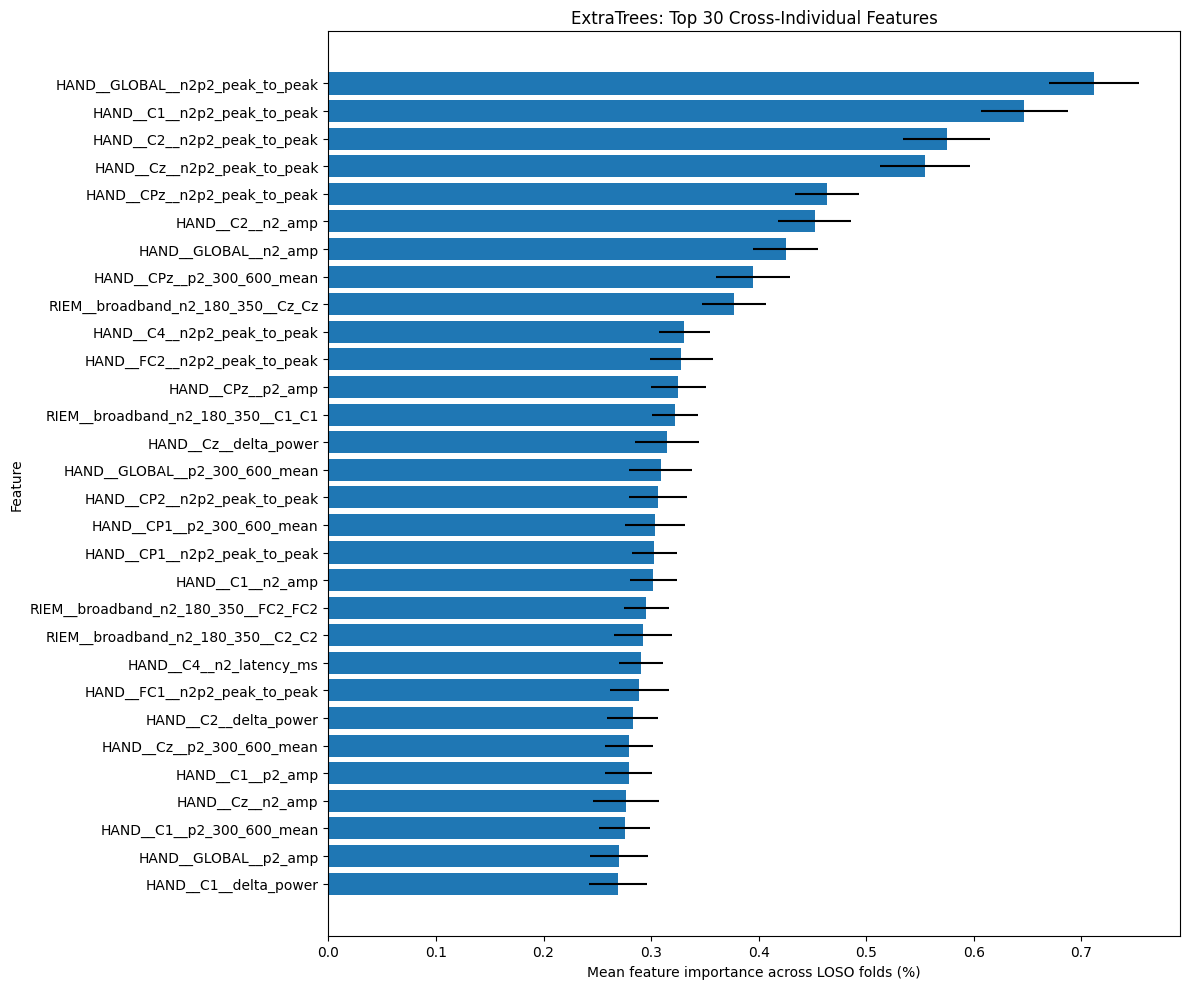


Feature importance completed.

Top features:


,rank,feature_name,mean_importance,standard_deviation,mean_importance_percent,n_folds
0,1,HAND__GLOBAL__n2p2_peak_to_peak,0.007120,0.000421,0.711963,223
1,2,HAND__C1__n2p2_peak_to_peak,0.006468,0.000404,0.646819,223
2,3,HAND__C2__n2p2_peak_to_peak,0.005747,0.000400,0.574673,223
3,4,HAND__Cz__n2p2_peak_to_peak,0.005546,0.000416,0.554610,223
4,5,HAND__CPz__n2p2_peak_to_peak,0.004637,0.000300,0.463708,223
5,6,HAND__C2__n2_amp,0.004520,0.000340,0.451959,223
6,7,HAND__GLOBAL__n2_amp,0.004251,0.000305,0.425087,223
7,8,HAND__CPz__p2_300_600_mean,0.003946,0.000341,0.394626,223
8,9,RIEM__broadband_n2_180_350__Cz_Cz,0.003773,0.000295,0.377294,223
9,10,HAND__C4__n2p2_peak_to_peak,0.003310,0.000240,0.331024,223



Saved fold importance:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE/ExtraTrees__Fusion964__ET300_depth15_leaf3_split6__LOSO_importance__fold_importance.csv

Saved aggregate importance:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE/ExtraTrees__Fusion964__ET300_depth15_leaf3_split6__LOSO_importance__aggregate_importance.csv

Saved top-feature table:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE/ExtraTrees__Fusion964__ET300_depth15_leaf3_split6__LOSO_importance__top30_importance.csv

Saved figure:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/FEATURE_IMPORTANCE/ExtraTrees__Fusion964__ET300_depth15_leaf3_split6__LOSO_importance__top30_importance.png


In [ ]:
cross_extra_trees_importance_results = (
    run_cross_loso_native_feature_importance(

        X=X_v5_fusion,

        y=y_v5,

        groups=groups_v5,


        estimator=extra_trees_fusion_model,


        model_name="ExtraTrees",


        feature_names=v5_fusion_feature_names,


        experiment_tag=(

            "ET300_depth15_leaf3_split6"

        ),


        expected_subjects=223,


        resume=True,

        overwrite=False,


        top_n=30,

    )
)

In [ ]:
cross_random_forest_importance_results = (
    run_cross_loso_native_feature_importance(
        X=X_v5_fusion,
        y=y_v5,
        groups=groups_v5,

        estimator=cross_random_forest_model,

        model_name="RandomForest",

        feature_names=v5_fusion_feature_names,

        experiment_tag=(
            "RF300_depth15_leaf3_split6"
        ),

        expected_subjects=223,

        resume=True,
        overwrite=False,

        top_n=30,
    )
)

In [ ]:
cross_xgboost_importance_results = (
    run_cross_loso_native_feature_importance(
        X=X_v5_fusion,
        y=y_v5,
        groups=groups_v5,

        estimator=cross_xgboost_model,

        model_name="XGBoost",

        feature_names=v5_fusion_feature_names,

        experiment_tag=(
            "XGB250_lr005_depth3"
        ),

        expected_subjects=223,

        resume=True,
        overwrite=False,

        top_n=30,
    )
)

In [ ]:
# CELL — Strict-192 within-individual feature importance
# Tree models supported:
#   1. Extra Trees
#   2. Random Forest
#   3. XGBoost
#
# Importance is backprojected from PCA components to the
# original 964 standardized features using squared loadings.

import os
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.base import clone


# ============================================================
# 1. Output directory
# ============================================================

WITHIN_FEATURE_IMPORTANCE_DIR = os.path.join(
    V5_DIR,
    "V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS",
    "FEATURE_IMPORTANCE_STRICT192"
)

os.makedirs(
    WITHIN_FEATURE_IMPORTANCE_DIR,
    exist_ok=True
)

print("Within-individual feature-importance directory:")
print(WITHIN_FEATURE_IMPORTANCE_DIR)


# ============================================================
# 2. Load the original 964 feature names
# ============================================================

def load_v5_fusion_feature_names(
    v5_directory,
    expected_features
):
    """
    Load the V5 fusion feature names.

    Generic names are used only when the saved feature-name
    file cannot be found or does not contain the expected
    number of features.
    """

    candidate_paths = [
        os.path.join(
            v5_directory,
            "v5_fusion_feature_names_964.csv"
        ),
        os.path.join(
            v5_directory,
            "V5_fusion_feature_names_964.csv"
        ),
        os.path.join(
            v5_directory,
            "fusion_feature_names_964.csv"
        ),
    ]

    preferred_columns = [
        "feature_name",
        "Feature",
        "feature",
        "name",
    ]

    for feature_name_path in candidate_paths:

        if not os.path.exists(feature_name_path):
            continue

        names_df = pd.read_csv(
            feature_name_path
        )

        selected_column = None

        for column_name in preferred_columns:
            if column_name in names_df.columns:
                selected_column = column_name
                break

        if (
            selected_column is None
            and names_df.shape[1] == 1
        ):
            selected_column = names_df.columns[0]

        if selected_column is None:

            object_columns = (
                names_df
                .select_dtypes(
                    include=["object"]
                )
                .columns
            )

            if len(object_columns) > 0:
                selected_column = object_columns[0]

        if selected_column is None:
            continue

        feature_names = (
            names_df[selected_column]
            .astype(str)
            .to_numpy()
        )

        if len(feature_names) == expected_features:

            print("\nLoaded feature names:")
            print(feature_name_path)

            return feature_names

    print(
        "\nFeature-name file was not found in the "
        "expected format."
    )

    print(
        "Generic names will be used."
    )

    return np.asarray([
        f"Feature_{feature_index:04d}"
        for feature_index in range(
            expected_features
        )
    ])


v5_fusion_feature_names = (
    load_v5_fusion_feature_names(
        v5_directory=V5_DIR,
        expected_features=X_v5_fusion.shape[1],
    )
)

if len(v5_fusion_feature_names) != 964:
    raise ValueError(
        "Expected 964 fusion feature names, "
        f"found {len(v5_fusion_feature_names)}."
    )

print(
    "Number of original feature names:",
    len(v5_fusion_feature_names)
)


# ============================================================
# 3. Saving helpers
# ============================================================

def make_importance_safe_filename(
    text
):
    text = str(text).strip()

    text = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        text
    )

    return text.strip("_")


def atomic_save_importance_csv(
    dataframe,
    path
):
    temporary_path = (
        f"{path}.temporary"
    )

    dataframe.to_csv(
        temporary_path,
        index=False
    )

    os.replace(
        temporary_path,
        path
    )


def atomic_save_importance_json(
    content,
    path
):
    temporary_path = (
        f"{path}.temporary"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as json_file:
        json.dump(
            content,
            json_file,
            indent=4
        )

    os.replace(
        temporary_path,
        path
    )


def read_importance_checkpoint(
    path
):
    if not os.path.exists(path):
        return pd.DataFrame()

    return pd.read_csv(
        path,
        on_bad_lines="skip",
        dtype={
            "subject_id": str
        }
    )


# ============================================================
# 4. Extract PCA-backprojected tree importance
# ============================================================

def extract_pca_backprojected_importance(
    fitted_pipeline,
    expected_original_features
):
    """
    Map native tree importance from PCA-component space back
    to the original feature space.

    Original feature importance:
        sum(
            PC importance
            × squared PCA loading
        )
    """

    if not hasattr(
        fitted_pipeline,
        "named_steps"
    ):
        raise TypeError(
            "The fitted model must be an sklearn Pipeline."
        )

    if "pca" not in fitted_pipeline.named_steps:
        raise KeyError(
            "Pipeline does not contain a 'pca' step."
        )

    if (
        "classifier"
        not in fitted_pipeline.named_steps
    ):
        raise KeyError(
            "Pipeline does not contain a "
            "'classifier' step."
        )

    adaptive_pca = (
        fitted_pipeline.named_steps["pca"]
    )

    classifier = (
        fitted_pipeline.named_steps[
            "classifier"
        ]
    )

    # AdaptivePCA stores the fitted sklearn PCA in pca_.
    if hasattr(adaptive_pca, "pca_"):
        fitted_pca = adaptive_pca.pca_
    else:
        fitted_pca = adaptive_pca

    if not hasattr(
        fitted_pca,
        "components_"
    ):
        raise AttributeError(
            "The fitted PCA has no components_."
        )

    if not hasattr(
        classifier,
        "feature_importances_"
    ):
        raise AttributeError(
            f"{classifier.__class__.__name__} does not "
            "provide native feature_importances_."
        )

    pc_importance = np.asarray(
        classifier.feature_importances_,
        dtype=float
    ).ravel()

    pca_components = np.asarray(
        fitted_pca.components_,
        dtype=float
    )

    if (
        len(pc_importance)
        != pca_components.shape[0]
    ):
        raise ValueError(
            "The classifier importance vector and "
            "PCA components are not aligned."
        )

    if (
        pca_components.shape[1]
        != expected_original_features
    ):
        raise ValueError(
            "The PCA loading matrix does not match "
            "the original feature count."
        )

    if not np.isfinite(
        pc_importance
    ).all():
        raise ValueError(
            "Classifier importance contains NaN "
            "or infinity."
        )

    if not np.isfinite(
        pca_components
    ).all():
        raise ValueError(
            "PCA components contain NaN or infinity."
        )

    # --------------------------------------------------------
    # PCA-loading-weighted backprojection
    # --------------------------------------------------------

    original_importance = np.sum(
        pc_importance[:, None]
        * np.square(pca_components),
        axis=0
    )

    original_importance = np.maximum(
        original_importance,
        0.0
    )

    importance_sum = (
        original_importance.sum()
    )

    if importance_sum <= 0:
        raise ValueError(
            "The backprojected importance sums to zero."
        )

    original_importance = (
        original_importance
        / importance_sum
    )

    return original_importance


# ============================================================
# 5. Main strict-192 importance evaluator
# ============================================================

def run_within_strict192_feature_importance(
    X,
    y,
    groups,
    estimator,
    model_name,
    feature_names,
    experiment_tag,
    expected_subjects=192,
    top_n=30,
    resume=True,
    overwrite=False,
):
    """
    Refit every strict within-individual LOOCV training fold.

    Workflow for every eligible subject:
        1. Hold out one trial.
        2. Fit scaler, PCA and classifier on the remaining
           trials of that subject only.
        3. Extract native tree importance in PCA space.
        4. Backproject it to the original 964 features.
        5. Average importance across that subject's LOOCV folds.
        6. Save the completed subject immediately.

    The held-out trial is never used for scaling, PCA fitting,
    classifier fitting or importance extraction.
    """

    y = np.asarray(
        y,
        dtype=np.int8
    ).ravel()

    groups = np.asarray(
        groups
    ).astype(str).ravel()

    feature_names = np.asarray(
        feature_names
    ).astype(str)

    if len(X.shape) != 2:
        raise ValueError(
            "X must be two-dimensional."
        )

    n_samples = int(
        X.shape[0]
    )

    n_features = int(
        X.shape[1]
    )

    if n_samples != len(y):
        raise ValueError(
            "X and y are not aligned."
        )

    if len(groups) != len(y):
        raise ValueError(
            "groups and y are not aligned."
        )

    if len(feature_names) != n_features:
        raise ValueError(
            "Feature-name count does not match X."
        )

    if not np.array_equal(
        np.unique(y),
        np.array([0, 1])
    ):
        raise ValueError(
            "Labels must be binary 0 and 1."
        )

    # --------------------------------------------------------
    # Identify the strict 192 subjects
    # --------------------------------------------------------

    subject_balance = (
        pd.DataFrame({
            "subject_id": groups,
            "pain_label": y,
        })
        .groupby([
            "subject_id",
            "pain_label"
        ])
        .size()
        .unstack(fill_value=0)
        .reindex(
            columns=[0, 1],
            fill_value=0
        )
    )

    subject_balance.columns = [
        "n_low",
        "n_high",
    ]

    eligible_subjects = (
        subject_balance.index[
            (
                subject_balance["n_low"] >= 2
            )
            & (
                subject_balance["n_high"] >= 2
            )
        ]
        .astype(str)
        .to_numpy()
    )

    eligible_subjects = np.sort(
        eligible_subjects
    )

    if len(eligible_subjects) != expected_subjects:
        raise ValueError(
            "Unexpected strict-LOOCV subject count. "
            f"Expected {expected_subjects}, "
            f"found {len(eligible_subjects)}."
        )

    # --------------------------------------------------------
    # Output paths
    # --------------------------------------------------------

    safe_model_name = (
        make_importance_safe_filename(
            model_name
        )
    )

    safe_experiment_tag = (
        make_importance_safe_filename(
            experiment_tag
        )
    )

    experiment_name = (
        f"{safe_model_name}__"
        f"Fusion964_PCA10__"
        f"{safe_experiment_tag}__"
        f"STRICT192"
    )

    subject_importance_path = os.path.join(
        WITHIN_FEATURE_IMPORTANCE_DIR,
        (
            f"{experiment_name}"
            "__subject_importance.csv"
        )
    )

    aggregate_importance_path = os.path.join(
        WITHIN_FEATURE_IMPORTANCE_DIR,
        (
            f"{experiment_name}"
            "__aggregate_importance.csv"
        )
    )

    top_importance_path = os.path.join(
        WITHIN_FEATURE_IMPORTANCE_DIR,
        (
            f"{experiment_name}"
            f"__top_{top_n}_features.csv"
        )
    )

    plot_path = os.path.join(
        WITHIN_FEATURE_IMPORTANCE_DIR,
        (
            f"{experiment_name}"
            f"__top_{top_n}_features.png"
        )
    )

    progress_path = os.path.join(
        WITHIN_FEATURE_IMPORTANCE_DIR,
        (
            f"{experiment_name}"
            "__progress.json"
        )
    )

    configuration_path = os.path.join(
        WITHIN_FEATURE_IMPORTANCE_DIR,
        (
            f"{experiment_name}"
            "__configuration.json"
        )
    )

    output_paths = [
        subject_importance_path,
        aggregate_importance_path,
        top_importance_path,
        plot_path,
        progress_path,
        configuration_path,
    ]

    print("\n" + "=" * 82)
    print(
        "STRICT-192 WITHIN-INDIVIDUAL "
        "FEATURE IMPORTANCE"
    )
    print("=" * 82)

    print("Experiment:", experiment_name)
    print("Model:", model_name)
    print(
        "Eligible subjects:",
        len(eligible_subjects)
    )
    print("Original features:", n_features)

    print("\nSubject-level importance:")
    print(subject_importance_path)

    print("\nAggregate importance:")
    print(aggregate_importance_path)

    print("\nTop-feature table:")
    print(top_importance_path)

    print("\nImportance figure:")
    print(plot_path)

    print("\nProgress checkpoint:")
    print(progress_path)

    # --------------------------------------------------------
    # Overwrite control
    # --------------------------------------------------------

    if overwrite:

        for output_path in output_paths:

            if os.path.exists(output_path):
                os.remove(output_path)

        print(
            "\nExisting importance files removed."
        )

    # --------------------------------------------------------
    # Save configuration
    # --------------------------------------------------------

    configuration = {
        "experiment_name": experiment_name,
        "model_name": str(model_name),
        "experiment_tag": str(
            experiment_tag
        ),
        "validation": (
            "Strict within-individual leave-one-trial-out "
            "cross-validation"
        ),
        "n_subjects": int(
            len(eligible_subjects)
        ),
        "n_original_features": int(
            n_features
        ),
        "importance_method": (
            "Native PCA-component tree importance "
            "backprojected using squared PCA loadings"
        ),
        "estimator": repr(
            estimator
        ),
        "leakage_control": (
            "Scaler, PCA and classifier are refitted "
            "using only the remaining training trials "
            "inside every LOOCV fold."
        ),
    }

    atomic_save_importance_json(
        configuration,
        configuration_path
    )

    # --------------------------------------------------------
    # Resume completed subjects
    # --------------------------------------------------------

    existing_df = read_importance_checkpoint(
        subject_importance_path
    )

    if (
        resume
        and not existing_df.empty
    ):

        subject_row_counts = (
            existing_df
            .groupby("subject_id")
            .size()
        )

        completed_subjects = set(
            subject_row_counts.loc[
                subject_row_counts == n_features
            ]
            .index
            .astype(str)
        )

        # Remove any incomplete subject block caused by
        # interruption during CSV writing.
        existing_df = existing_df.loc[
            existing_df[
                "subject_id"
            ].astype(str).isin(
                completed_subjects
            )
        ].copy()

        existing_df = (
            existing_df
            .drop_duplicates(
                subset=[
                    "subject_id",
                    "feature_index"
                ],
                keep="last"
            )
            .sort_values([
                "subject_id",
                "feature_index"
            ])
            .reset_index(drop=True)
        )

        atomic_save_importance_csv(
            existing_df,
            subject_importance_path
        )

        print(
            "\nResuming completed subjects:",
            len(completed_subjects),
            "/",
            expected_subjects
        )

    else:
        completed_subjects = set()

    # --------------------------------------------------------
    # Evaluate subject by subject
    # --------------------------------------------------------

    for subject_number, subject_id in enumerate(
        tqdm(
            eligible_subjects,
            desc=f"Importance | {model_name}"
        ),
        start=1
    ):
        subject_id = str(
            subject_id
        )

        if subject_id in completed_subjects:
            continue

        subject_indices = np.flatnonzero(
            groups == subject_id
        )

        subject_fold_importances = []

        for test_index in subject_indices:

            test_index = int(
                test_index
            )

            train_indices = subject_indices[
                subject_indices != test_index
            ]

            if test_index in train_indices:
                raise RuntimeError(
                    "Held-out trial was found in "
                    "the training indices."
                )

            if not np.all(
                groups[train_indices]
                == subject_id
            ):
                raise RuntimeError(
                    "The training fold contains trials "
                    "from another subject."
                )

            y_train = y[
                train_indices
            ]

            if len(
                np.unique(y_train)
            ) != 2:
                raise RuntimeError(
                    f"Subject {subject_id} produced a "
                    "one-class LOOCV training fold."
                )

            fold_model = clone(
                estimator
            )

            fold_model.fit(
                X[train_indices],
                y_train
            )

            fold_importance = (
                extract_pca_backprojected_importance(
                    fitted_pipeline=fold_model,
                    expected_original_features=(
                        n_features
                    ),
                )
            )

            subject_fold_importances.append(
                fold_importance
            )

        if len(
            subject_fold_importances
        ) != len(subject_indices):
            raise RuntimeError(
                f"Subject {subject_id} does not contain "
                "the expected number of importance folds."
            )

        # Average all LOOCV training-fold importance vectors
        # for this subject.
        subject_mean_importance = np.mean(
            np.vstack(
                subject_fold_importances
            ),
            axis=0
        )

        subject_mean_importance = np.maximum(
            subject_mean_importance,
            0.0
        )

        subject_importance_sum = (
            subject_mean_importance.sum()
        )

        if subject_importance_sum <= 0:
            raise RuntimeError(
                f"Subject {subject_id} has zero total "
                "feature importance."
            )

        subject_mean_importance = (
            subject_mean_importance
            / subject_importance_sum
        )

        subject_result_df = pd.DataFrame({
            "experiment": experiment_name,
            "model": model_name,
            "subject_id": subject_id,
            "feature_index": np.arange(
                n_features,
                dtype=int
            ),
            "feature_name": feature_names,
            "importance": (
                subject_mean_importance
            ),
            "importance_percent": (
                subject_mean_importance
                * 100.0
            ),
            "n_loocv_folds": int(
                len(subject_indices)
            ),
            "n_low": int(
                np.sum(
                    y[subject_indices] == 0
                )
            ),
            "n_high": int(
                np.sum(
                    y[subject_indices] == 1
                )
            ),
            "importance_method": (
                "PCA-loading-weighted "
                "backprojected tree importance"
            ),
        })

        # Save the completed subject immediately.
        subject_result_df.to_csv(
            subject_importance_path,
            mode="a",
            header=not os.path.exists(
                subject_importance_path
            ),
            index=False
        )

        completed_subjects.add(
            subject_id
        )

        progress = {
            "experiment_name": (
                experiment_name
            ),
            "completed": False,
            "completed_subjects": int(
                len(completed_subjects)
            ),
            "total_subjects": int(
                expected_subjects
            ),
            "last_completed_subject": (
                subject_id
            ),
            "subject_importance_path": (
                subject_importance_path
            ),
            "aggregate_importance_path": (
                aggregate_importance_path
            ),
            "top_importance_path": (
                top_importance_path
            ),
        }

        atomic_save_importance_json(
            progress,
            progress_path
        )

    # --------------------------------------------------------
    # Final checkpoint verification
    # --------------------------------------------------------

    subject_importance_df = (
        read_importance_checkpoint(
            subject_importance_path
        )
    )

    subject_importance_df = (
        subject_importance_df
        .drop_duplicates(
            subset=[
                "subject_id",
                "feature_index"
            ],
            keep="last"
        )
        .sort_values([
            "subject_id",
            "feature_index"
        ])
        .reset_index(drop=True)
    )

    atomic_save_importance_csv(
        subject_importance_df,
        subject_importance_path
    )

    completed_subject_count = (
        subject_importance_df[
            "subject_id"
        ]
        .astype(str)
        .nunique()
    )

    if (
        completed_subject_count
        != expected_subjects
    ):
        raise RuntimeError(
            "Feature importance is incomplete. "
            f"Expected {expected_subjects} subjects, "
            f"found {completed_subject_count}."
        )

    expected_rows = (
        expected_subjects
        * n_features
    )

    if (
        len(subject_importance_df)
        != expected_rows
    ):
        raise RuntimeError(
            "Unexpected number of subject-feature rows. "
            f"Expected {expected_rows}, "
            f"found {len(subject_importance_df)}."
        )

    # Ensure every subject has exactly 964 features.
    final_subject_counts = (
        subject_importance_df
        .groupby("subject_id")
        .size()
    )

    if not np.all(
        final_subject_counts.to_numpy()
        == n_features
    ):
        raise RuntimeError(
            "At least one subject does not have "
            "exactly one importance value for every "
            "original feature."
        )

    # --------------------------------------------------------
    # Aggregate across the 192 subjects
    # --------------------------------------------------------

    aggregate_importance_df = (
        subject_importance_df
        .groupby(
            [
                "feature_index",
                "feature_name"
            ],
            as_index=False
        )
        .agg(
            mean_importance=(
                "importance",
                "mean"
            ),
            standard_deviation=(
                "importance",
                "std"
            ),
            median_importance=(
                "importance",
                "median"
            ),
            minimum_importance=(
                "importance",
                "min"
            ),
            maximum_importance=(
                "importance",
                "max"
            ),
            n_subjects=(
                "importance",
                "count"
            ),
        )
    )

    aggregate_importance_df[
        "rank"
    ] = (
        aggregate_importance_df[
            "mean_importance"
        ]
        .rank(
            method="first",
            ascending=False
        )
        .astype(int)
    )

    aggregate_importance_df = (
        aggregate_importance_df
        .sort_values(
            "rank"
        )
        .reset_index(drop=True)
    )

    aggregate_importance_df[
        "mean_importance_percent"
    ] = (
        aggregate_importance_df[
            "mean_importance"
        ]
        * 100.0
    )

    aggregate_importance_df[
        "standard_deviation_percent"
    ] = (
        aggregate_importance_df[
            "standard_deviation"
        ]
        * 100.0
    )

    aggregate_importance_df[
        "mean_plus_minus_sd_percent"
    ] = (
        aggregate_importance_df.apply(
            lambda row: (
                f"{row['mean_importance_percent']:.6f}% "
                f"± "
                f"{row['standard_deviation_percent']:.6f}%"
            ),
            axis=1
        )
    )

    atomic_save_importance_csv(
        aggregate_importance_df,
        aggregate_importance_path
    )

    top_importance_df = (
        aggregate_importance_df
        .head(top_n)
        .copy()
    )

    atomic_save_importance_csv(
        top_importance_df,
        top_importance_path
    )

    # --------------------------------------------------------
    # Plot top features
    # --------------------------------------------------------

    plot_df = (
        top_importance_df
        .sort_values(
            "mean_importance_percent",
            ascending=True
        )
    )

    plt.figure(
        figsize=(12, 10)
    )

    plt.barh(
        plot_df["feature_name"],
        plot_df[
            "mean_importance_percent"
        ],
        xerr=plot_df[
            "standard_deviation_percent"
        ],
    )

    plt.xlabel(
        "Mean PCA-backprojected importance (%)"
    )

    plt.ylabel(
        "Original V5 feature"
    )

    plt.title(
        f"{model_name}: Top {top_n} "
        "Within-Individual Features"
    )

    plt.tight_layout()

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Completed progress file
    # --------------------------------------------------------

    completed_progress = {
        "experiment_name": (
            experiment_name
        ),
        "completed": True,
        "completed_subjects": int(
            expected_subjects
        ),
        "total_subjects": int(
            expected_subjects
        ),
        "n_original_features": int(
            n_features
        ),
        "subject_importance_path": (
            subject_importance_path
        ),
        "aggregate_importance_path": (
            aggregate_importance_path
        ),
        "top_importance_path": (
            top_importance_path
        ),
        "plot_path": plot_path,
        "configuration_path": (
            configuration_path
        ),
    }

    atomic_save_importance_json(
        completed_progress,
        progress_path
    )

    # --------------------------------------------------------
    # Display and return
    # --------------------------------------------------------

    print("\n" + "=" * 82)
    print(
        "WITHIN-INDIVIDUAL FEATURE "
        "IMPORTANCE COMPLETED"
    )
    print("=" * 82)

    print("\nTop features:")

    display(
        top_importance_df[[
            "rank",
            "feature_index",
            "feature_name",
            "mean_importance",
            "standard_deviation",
            "mean_importance_percent",
            "standard_deviation_percent",
            "n_subjects",
        ]]
    )

    print("\nSaved subject-level importance:")
    print(subject_importance_path)

    print("\nSaved aggregate importance:")
    print(aggregate_importance_path)

    print("\nSaved top-feature table:")
    print(top_importance_path)

    print("\nSaved importance figure:")
    print(plot_path)

    print("\nSaved progress checkpoint:")
    print(progress_path)

    print("\nSaved configuration:")
    print(configuration_path)

    return {
        "experiment_name": experiment_name,
        "subject_importance": (
            subject_importance_df
        ),
        "aggregate_importance": (
            aggregate_importance_df
        ),
        "top_importance": (
            top_importance_df
        ),
        "subject_importance_path": (
            subject_importance_path
        ),
        "aggregate_importance_path": (
            aggregate_importance_path
        ),
        "top_importance_path": (
            top_importance_path
        ),
        "plot_path": plot_path,
        "progress_path": progress_path,
        "configuration_path": (
            configuration_path
        ),
    }


print(
    "\nStrict-192 within-individual "
    "feature-importance evaluator is ready."
)

In [ ]:
# CELL — Extra Trees within-individual feature importance

within_extra_trees_importance_results = (
    run_within_strict192_feature_importance(
        X=X_v5_fusion,
        y=y_v5,
        groups=groups_v5,

        estimator=within_extra_trees_model,

        model_name="ExtraTrees",

        feature_names=(
            v5_fusion_feature_names
        ),

        experiment_tag=(
            "ET100_depth8_leaf2_"
            "PCA10_STRICT192"
        ),

        expected_subjects=192,

        top_n=30,

        resume=True,
        overwrite=False,
    )
)

In [ ]:
# CELL — Random Forest within-individual feature importance

within_random_forest_importance_results = (
    run_within_strict192_feature_importance(
        X=X_v5_fusion,
        y=y_v5,
        groups=groups_v5,

        estimator=within_random_forest_model,

        model_name="RandomForest",

        feature_names=(
            v5_fusion_feature_names
        ),

        experiment_tag=(
            "RF100_depth6_leaf2_"
            "PCA10_STRICT192"
        ),

        expected_subjects=192,

        top_n=30,

        resume=True,
        overwrite=False,
    )
)

In [ ]:
# CELL — XGBoost within-individual feature importance

within_xgboost_importance_results = (
    run_within_strict192_feature_importance(
        X=X_v5_fusion,
        y=y_v5,
        groups=groups_v5,

        estimator=within_xgboost_model,

        model_name="XGBoost",

        feature_names=(
            v5_fusion_feature_names
        ),

        experiment_tag=(
            "XGB100_lr005_depth2_"
            "PCA10_STRICT192"
        ),

        expected_subjects=192,

        top_n=30,

        resume=True,
        overwrite=False,
    )
)

In [ ]:
# CELL — Cross-individual LOSO feature ablation
# Fixed model: Extra Trees
# Only the feature representation changes
#
# Conditions:
#   1. Handcrafted only: 262 features
#   2. Riemannian only: 702 features
#   3. Full fusion: 964 features

from sklearn.ensemble import ExtraTreesClassifier


# ============================================================
# 1. Define the feature-ablation conditions
# ============================================================

cross_ablation_feature_sets = {
    "Handcrafted_262": X_v5_handcrafted,
    "Riemannian_702": X_v5_riemannian,
    "Fusion_964": X_v5_fusion,
}


# ============================================================
# 2. Fixed Extra Trees configuration
# ============================================================

cross_ablation_extra_trees_model = ExtraTreesClassifier(
    n_estimators=300,
    criterion="gini",

    max_depth=15,
    min_samples_split=6,
    min_samples_leaf=3,

    max_features="sqrt",
    class_weight="balanced",

    bootstrap=False,

    random_state=42,
    n_jobs=-1,
)


# ============================================================
# 3. Run all three cross-individual ablations
# ============================================================

cross_ablation_results = {}


for feature_set_name, feature_matrix in (
    cross_ablation_feature_sets.items()
):

    print("\n" + "=" * 90)
    print(
        "CROSS-INDIVIDUAL ABLATION:",
        feature_set_name
    )
    print("=" * 90)

    current_result = run_loso_evaluation(
        X=feature_matrix,
        y=y_v5,
        groups=groups_v5,

        estimator=(
            cross_ablation_extra_trees_model
        ),

        model_name="ExtraTrees",
        feature_set_name=feature_set_name,

        metadata_df=v5_meta_df,

        # Same hyperparameters for every condition
        experiment_tag=(
            "ET300_depth15_leaf3_split6_ABLATION"
        ),

        resume=True,
        overwrite=False,
        compute_train_accuracy=False,
    )

    cross_ablation_results[
        feature_set_name
    ] = current_result

    print(
        "\nCompleted:",
        feature_set_name
    )

    print("Pooled summary:")
    print(
        current_result[
            "pooled_summary_path"
        ]
    )

    print("Subject results:")
    print(
        current_result[
            "subject_result_path"
        ]
    )

    print("Trial predictions:")
    print(
        current_result[
            "trial_prediction_path"
        ]
    )


print(
    "\nAll cross-individual "
    "feature-ablation runs completed."
)


CROSS-INDIVIDUAL ABLATION: Handcrafted_262

LOSO EXPERIMENT
Experiment name: ExtraTrees__Handcrafted_262__ET300_depth15_leaf3_split6_ABLATION
Model: ExtraTrees
Feature set: Handcrafted_262
Feature matrix: (6275, 262)
Subjects: 223
Class counts [low, high]: [2725 3550]

Results will be saved to:
1. Trial predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Handcrafted_262__ET300_depth15_leaf3_split6_ABLATION__trial_predictions.csv

2. Subject results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Handcrafted_262__ET300_depth15_leaf3_split6_ABLATION__subject_results.csv

3. Subject metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Handcrafted_262__ET300_depth15_leaf3_split6_ABLATION__subject_metric_summary.csv

4. Pooled summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN

LOSO | ExtraTrees | Handcrafted_262:   0%|          | 0/223 [00:00<?, ?it/s]


LOSO EVALUATION COMPLETED SUCCESSFULLY
Experiment: ExtraTrees__Handcrafted_262__ET300_depth15_leaf3_split6_ABLATION
Model: ExtraTrees
Feature set: Handcrafted_262
Number of features: 262
Number of subjects: 223
Number of predictions: 6275

POOLED TRIAL-LEVEL METRICS:


,value
accuracy,0.644462
balanced_accuracy,0.645095
precision,0.704369
recall,0.640282
sensitivity,0.640282
specificity,0.649908
negative_predictive_value,0.581037
f1_score,0.670798
roc_auc,0.687779
average_precision_pr_auc,0.736255



Mean subject accuracy ± SD:
64.45% ± 20.28%

SUBJECT-LEVEL METRICS: MEAN ± STANDARD DEVIATION


...


LOSO EVALUATION COMPLETED SUCCESSFULLY
Experiment: ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6_ABLATION
Model: ExtraTrees
Feature set: Fusion_964
Number of features: 964
Number of subjects: 223
Number of predictions: 6275

POOLED TRIAL-LEVEL METRICS:


,value
accuracy,0.643506
balanced_accuracy,0.643738
precision,0.702311
recall,0.641972
sensitivity,0.641972
specificity,0.645505
negative_predictive_value,0.580528
f1_score,0.670787
roc_auc,0.690587
average_precision_pr_auc,0.741019



Mean subject accuracy ± SD:
64.38% ± 20.05%

SUBJECT-LEVEL METRICS: MEAN ± STANDARD DEVIATION


,metric,n_evaluated_subjects,n_valid_subjects,mean,standard_deviation,mean_percent,standard_deviation_percent,mean_plus_minus_sd
0,accuracy,223,223,0.643775,0.200497,64.377497,20.049690,64.38% ± 20.05%
1,balanced_accuracy,223,205,0.665046,0.133817,66.504601,13.381673,66.50% ± 13.38%
2,precision,223,223,0.703321,0.285301,70.332071,28.530109,70.33% ± 28.53%
3,recall,223,223,0.656700,0.317289,65.669978,31.728890,65.67% ± 31.73%
4,sensitivity,223,223,0.656700,0.317289,65.669978,31.728890,65.67% ± 31.73%
5,specificity,223,209,0.655278,0.315946,65.527767,31.594565,65.53% ± 31.59%
6,negative_predictive_value,223,218,0.610902,0.351494,61.090186,35.149362,61.09% ± 35.15%
7,false_positive_rate,223,209,0.344722,0.315946,34.472233,31.594565,34.47% ± 31.59%
8,false_negative_rate,223,219,0.331306,0.307347,33.130570,30.734669,33.13% ± 30.73%
9,f1_score,223,223,0.601742,0.252286,60.174172,25.228577,60.17% ± 25.23%



All final paths:

Trial-level predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6_ABLATION__trial_predictions.csv

Subject-level metrics:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6_ABLATION__subject_results.csv

Subject metric mean ± SD:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6_ABLATION__subject_metric_summary.csv

Pooled metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6_ABLATION__pooled_summary.csv

Progress information:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_LOSO_RESULTS/ExtraTrees__Fusion_964__ET300_depth15_leaf3_split6_ABLAT

In [ ]:
print(
    X_v5_handcrafted.shape,
    X_v5_riemannian.shape,
    X_v5_fusion.shape
)

print(
    len(y_v5),
    len(groups_v5)
)

(6275, 262) (6275, 702) (6275, 964)
6275 6275


In [ ]:
# CELL — Create strict-192 within-individual dataset

import numpy as np


# Find subjects having both classes

both_class_subjects = []

for subject in np.unique(groups_v5):

    labels = y_v5[
        groups_v5 == subject
    ]

    if len(np.unique(labels)) == 2:
        both_class_subjects.append(subject)



print(
    "Subjects with both classes:",
    len(both_class_subjects)
)



# Check strict LOOCV validity
# Every subject must have >1 sample in both classes

strict_subjects = []


for subject in both_class_subjects:

    labels = y_v5[
        groups_v5 == subject
    ]

    counts = np.bincount(labels)


    if len(counts) == 2 and np.all(counts > 1):

        strict_subjects.append(subject)



strict_subjects = np.array(
    strict_subjects
)


print(
    "Strict LOOCV valid subjects:",
    len(strict_subjects)
)



# Create trial mask

strict192_mask = np.isin(
    groups_v5,
    strict_subjects
)



# Filter all feature branches

X_v5_handcrafted_strict192 = (
    X_v5_handcrafted[strict192_mask]
)


X_v5_riemannian_strict192 = (
    X_v5_riemannian[strict192_mask]
)


X_v5_fusion_strict192 = (
    X_v5_fusion[strict192_mask]
)



y_v5_strict192 = (
    y_v5[strict192_mask]
)


groups_v5_strict192 = (
    groups_v5[strict192_mask]
)


v5_meta_df_strict192 = (
    v5_meta_df
    .loc[strict192_mask]
    .reset_index(drop=True)
)



print("\nFinal strict-192 shapes:")

print(
    "Handcrafted:",
    X_v5_handcrafted_strict192.shape
)

print(
    "Riemannian:",
    X_v5_riemannian_strict192.shape
)

print(
    "Fusion:",
    X_v5_fusion_strict192.shape
)


print(
    "\nTrials:",
    len(y_v5_strict192)
)


print(
    "Subjects:",
    len(np.unique(groups_v5_strict192))
)

Subjects with both classes: 205
Strict LOOCV valid subjects: 192

Final strict-192 shapes:
Handcrafted: (5408, 262)
Riemannian: (5408, 702)
Fusion: (5408, 964)

Trials: 5408
Subjects: 192


In [ ]:
# CELL — Strict-192 within-individual feature ablation
# Fixed model: Shrinkage LDA
# Fixed preprocessing: StandardScaler + AdaptivePCA
# Only feature representation changes


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



# ============================================================
# 1. Define strict-192 feature-ablation conditions
# ============================================================

within_ablation_feature_sets = {

    "Handcrafted_262_PCA10":
        X_v5_handcrafted_strict192,


    "Riemannian_702_PCA10":
        X_v5_riemannian_strict192,


    "Fusion_964_PCA10":
        X_v5_fusion_strict192,

}



# ============================================================
# 2. Identical Shrinkage LDA pipeline
# ============================================================

def make_within_ablation_shrinkage_lda():

    return Pipeline([

        (
            "scaler",

            StandardScaler()

        ),


        (
            "pca",

            AdaptivePCA(

                max_components=10,

                whiten=False,

                random_state=42,

            )

        ),


        (
            "classifier",

            LinearDiscriminantAnalysis(

                solver="lsqr",

                shrinkage="auto"

            )

        ),

    ])




# ============================================================
# 3. Run strict-192 within-individual ablations
# ============================================================

within_ablation_results = {}



for feature_set_name, feature_matrix in (
    within_ablation_feature_sets.items()
):


    print("\n" + "=" * 90)

    print(
        "STRICT-192 WITHIN-INDIVIDUAL ABLATION:",
        feature_set_name
    )

    print("=" * 90)



    print(
        "Feature matrix:",
        feature_matrix.shape
    )



    current_model = (
        make_within_ablation_shrinkage_lda()
    )



    current_result = (

        run_within_individual_loocv(

            X=feature_matrix,


            y=y_v5_strict192,


            groups=groups_v5_strict192,



            estimator=current_model,



            model_name="ShrinkageLDA",



            feature_set_name=feature_set_name,



            metadata_df=v5_meta_df_strict192,



            experiment_tag=(

                "LSQR_autoShrinkage_"

                "PCA10_STRICT192_ABLATION"

            ),



            expected_subjects=192,



            resume=True,

            overwrite=False,


            compute_train_accuracy=False,

        )

    )



    within_ablation_results[

        feature_set_name

    ] = current_result



    print(

        "\nCompleted:",

        feature_set_name

    )


    print(

        "Pooled summary:"

    )


    print(

        current_result[

            "pooled_summary_path"

        ]

    )


    print(

        "Subject results:"

    )


    print(

        current_result[

            "subject_result_path"

        ]

    )


    print(

        "Trial predictions:"

    )


    print(

        current_result[

            "trial_prediction_path"

        ]

    )



print(

    "\nAll strict-192 within-individual "

    "Shrinkage LDA feature-ablation runs completed."

)


STRICT-192 WITHIN-INDIVIDUAL ABLATION: Handcrafted_262_PCA10
Feature matrix: (5408, 262)

WITHIN-INDIVIDUAL LOOCV EXPERIMENT
Experiment: ShrinkageLDA__Handcrafted_262_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION
Model: ShrinkageLDA
Feature set: Handcrafted_262_PCA10
Feature matrix: (5408, 262)
Eligible both-class subjects: 192
Evaluated trials: 5408

Results will be saved to:

Trial predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS/ShrinkageLDA__Handcrafted_262_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION__trial_predictions.csv

Subject results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS/ShrinkageLDA__Handcrafted_262_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION__subject_results.csv

Subject metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS/Shrink

Within LOOCV | ShrinkageLDA:   0%|          | 0/192 [00:00<?, ?it/s]


WITHIN-INDIVIDUAL LOOCV COMPLETED SUCCESSFULLY
Experiment: ShrinkageLDA__Handcrafted_262_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION
Model: ShrinkageLDA
Feature set: Handcrafted_262_PCA10
Evaluated subjects: 192
Evaluated held-out trials: 5408

POOLED HELD-OUT TRIAL METRICS:


,value
accuracy,0.751479
balanced_accuracy,0.749724
precision,0.764145
recall,0.774706
sensitivity,0.774706
specificity,0.724741
f1_score,0.769389
roc_auc,0.822156
average_precision_pr_auc,0.812061
matthews_correlation_coefficient,0.500025



Mean subject accuracy ± SD:
75.07% ± 13.16%

SUBJECT METRICS: MEAN ± SD


...


WITHIN-INDIVIDUAL LOOCV COMPLETED SUCCESSFULLY
Experiment: ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION
Model: ShrinkageLDA
Feature set: Fusion_964_PCA10
Evaluated subjects: 192
Evaluated held-out trials: 5408

POOLED HELD-OUT TRIAL METRICS:


,value
accuracy,0.759430
balanced_accuracy,0.756892
precision,0.765766
recall,0.793020
sensitivity,0.793020
specificity,0.720764
f1_score,0.779155
roc_auc,0.829947
average_precision_pr_auc,0.818369
matthews_correlation_coefficient,0.515549



Mean subject accuracy ± SD:
75.88% ± 12.13%

SUBJECT METRICS: MEAN ± SD


,metric,n_evaluated_subjects,n_valid_subjects,mean,standard_deviation,mean_percent,standard_deviation_percent,mean_plus_minus_sd
0,accuracy,192,192,0.758780,0.121339,75.877966,12.133891,75.88% ± 12.13%
1,balanced_accuracy,192,192,0.576230,0.121219,57.623035,12.121915,57.62% ± 12.12%
2,precision,192,192,0.618240,0.313701,61.824005,31.370114,61.82% ± 31.37%
3,recall,192,192,0.632717,0.380068,63.271709,38.006772,63.27% ± 38.01%
4,sensitivity,192,192,0.632717,0.380068,63.271709,38.006772,63.27% ± 38.01%
5,specificity,192,192,0.519744,0.416456,51.974361,41.645625,51.97% ± 41.65%
6,negative_predictive_value,192,147,0.673205,0.249432,67.320543,24.943174,67.32% ± 24.94%
7,false_positive_rate,192,192,0.480256,0.416456,48.025639,41.645625,48.03% ± 41.65%
8,false_negative_rate,192,192,0.367283,0.380068,36.728291,38.006772,36.73% ± 38.01%
9,f1_score,192,192,0.606658,0.336402,60.665832,33.640166,60.67% ± 33.64%



Saved paths:

Trial predictions:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS/ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION__trial_predictions.csv

Subject-level results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS/ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION__subject_results.csv

Subject metric summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS/ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION__subject_metric_summary.csv

Pooled summary:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/V5_WITHIN_INDIVIDUAL_LOOCV_RESULTS/ShrinkageLDA__Fusion_964_PCA10__LSQR_autoShrinkage_PCA10_STRICT192_ABLATION__pooled_summary.csv

Progress checkpoint:
/content/drive/MyDrive/EXP8_CL

In [ ]:
# ============================================================
# Strict-192 Within-Individual Shrinkage LDA Feature Importance
# Leakage-free Subject-wise Stratified CV Permutation Importance
# Original V5 Fusion 964 Features
# ============================================================


import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.base import clone



# ============================================================
# Shrinkage LDA pipeline
# ============================================================

within_shrinkage_lda_importance_model = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "pca",
        AdaptivePCA(
            max_components=10,
            whiten=False,
            random_state=42
        )
    ),

    (
        "classifier",
        LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto",
            priors=[
                0.5,
                0.5
            ]
        )
    )

])



# ============================================================
# Output directory
# ============================================================

WITHIN_IMPORTANCE_DIR = (

    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH/"
    "V5_WITHIN_INDIVIDUAL_FEATURE_IMPORTANCE"

)


os.makedirs(
    WITHIN_IMPORTANCE_DIR,
    exist_ok=True
)



# ============================================================
# Storage
# ============================================================

all_subject_importances = []

subject_summary = []



subjects = np.unique(
    groups_v5_strict192
)


print(
    "Total subjects:",
    len(subjects)
)


print(
    "Features:",
    X_v5_fusion_strict192.shape[1]
)



# ============================================================
# Subject-wise feature importance
# ============================================================


for subject_no, subject in enumerate(subjects,1):


    print(
        f"\nSubject {subject_no}/{len(subjects)} : {subject}"
    )


    subject_mask = (
        groups_v5_strict192 == subject
    )


    X_subject = (
        X_v5_fusion_strict192[
            subject_mask
        ]
    )


    y_subject = (
        y_v5_strict192[
            subject_mask
        ]
    )



    # class balance check

    class_counts = np.bincount(
        y_subject,
        minlength=2
    )


    if np.min(class_counts) < 2:

        print(
            "Skipped - insufficient class samples"
        )

        continue



    n_splits = min(
        5,
        np.min(class_counts)
    )


    cv = StratifiedKFold(

        n_splits=n_splits,

        shuffle=True,

        random_state=42

    )



    fold_importances = []



    for fold_no, (train_idx,test_idx) in enumerate(
        cv.split(
            X_subject,
            y_subject
        ),
        1
    ):


        X_train = (
            X_subject[train_idx]
        )

        y_train = (
            y_subject[train_idx]
        )


        X_test = (
            X_subject[test_idx]
        )

        y_test = (
            y_subject[test_idx]
        )



        model = clone(
            within_shrinkage_lda_importance_model
        )



        # --------------------------------------------
        # Leakage-free fitting
        # scaler + PCA + LDA only training data
        # --------------------------------------------

        model.fit(
            X_train,
            y_train
        )



        baseline_accuracy = (
            model.score(
                X_test,
                y_test
            )
        )



        # --------------------------------------------
        # Permutation importance
        # --------------------------------------------

        result = permutation_importance(

            model,

            X_test,

            y_test,

            scoring="balanced_accuracy",

            n_repeats=10,

            random_state=42,

            n_jobs=-1

        )



        fold_importances.append(

            result.importances_mean

        )



    # average folds inside subject

    subject_importance = np.mean(

        np.asarray(
            fold_importances
        ),

        axis=0

    )



    all_subject_importances.append(

        subject_importance

    )



    subject_summary.append({

        "subject":

            subject,


        "n_trials":

            len(y_subject),


        "low_trials":

            int(class_counts[0]),


        "high_trials":

            int(class_counts[1]),


        "folds":

            n_splits

    })



# ============================================================
# Aggregate across 192 subjects
# ============================================================


all_subject_importances = np.asarray(
    all_subject_importances
)



print(
    "\nCompleted subjects:",
    all_subject_importances.shape[0]
)



mean_importance = (

    all_subject_importances.mean(
        axis=0
    )

)



std_importance = (

    all_subject_importances.std(
        axis=0,
        ddof=1
    )

)



importance_df = pd.DataFrame({

    "feature_name":

        v5_fusion_feature_names,


    "mean_importance":

        mean_importance,


    "standard_deviation":

        std_importance,


    "mean_importance_percent":

        mean_importance * 100,


    "standard_deviation_percent":

        std_importance * 100,


    "n_subjects":

        all_subject_importances.shape[0]

})



importance_df = (

    importance_df

    .sort_values(

        "mean_importance",

        ascending=False

    )

    .reset_index(drop=True)

)



importance_df.insert(

    0,

    "rank",

    np.arange(

        1,

        len(importance_df)+1

    )

)



# ============================================================
# Save
# ============================================================


importance_path = os.path.join(

    WITHIN_IMPORTANCE_DIR,

    "ShrinkageLDA__Fusion964__Strict192__WithinSubject_PermutationImportance.csv"

)


subject_path = os.path.join(

    WITHIN_IMPORTANCE_DIR,

    "ShrinkageLDA__Strict192__SubjectSummary.csv"

)



importance_df.to_csv(

    importance_path,

    index=False

)



pd.DataFrame(
    subject_summary
).to_csv(

    subject_path,

    index=False

)



print(
    "\nCompleted."
)


print(
    "Saved importance:"
)

print(
    importance_path
)


display(
    importance_df.head(30)
)

Total subjects: 192
Features: 964

Subject 1/192 : sub-001

Subject 2/192 : sub-002

Subject 3/192 : sub-003

Subject 4/192 : sub-004

Subject 5/192 : sub-005

Subject 6/192 : sub-006

Subject 7/192 : sub-007

Subject 8/192 : sub-008

Subject 9/192 : sub-009

Subject 10/192 : sub-010

Subject 11/192 : sub-011

Subject 12/192 : sub-012

Subject 13/192 : sub-013

Subject 14/192 : sub-014

Subject 15/192 : sub-015

Subject 16/192 : sub-016

Subject 17/192 : sub-020

Subject 18/192 : sub-021

Subject 19/192 : sub-022

Subject 20/192 : sub-023

Subject 21/192 : sub-024

Subject 22/192 : sub-025

Subject 23/192 : sub-026

Subject 24/192 : sub-027

Subject 25/192 : sub-028

Subject 26/192 : sub-029

Subject 27/192 : sub-030

Subject 28/192 : sub-031

Subject 29/192 : sub-032

Subject 30/192 : sub-033

Subject 31/192 : sub-034

Subject 32/192 : sub-035

Subject 33/192 : sub-036

Subject 34/192 : sub-037

Subject 35/192 : sub-038

Subject 36/192 : sub-039

Subject 37/192 : sub-040

Subject 38/1

,rank,feature_name,mean_importance,standard_deviation,mean_importance_percent,standard_deviation_percent,n_subjects
0,1,HAND__C2__hjorth_complexity,0.002132,0.019562,0.213194,1.956229,192
1,2,HAND__CPz__hjorth_mobility,0.001913,0.018758,0.191319,1.875778,192
2,3,HAND__C2__hjorth_mobility,0.001903,0.015098,0.190278,1.509750,192
3,4,HAND__CPz__p2_300_600_mean,0.001513,0.016956,0.151319,1.695606,192
4,5,HAND__CP1__hjorth_mobility,0.001323,0.017721,0.132292,1.772062,192
5,6,HAND__CP1__p2_300_600_mean,0.001299,0.018769,0.129858,1.876866,192
6,7,HAND__C2__p2_latency_ms,0.001221,0.013333,0.122086,1.333261,192
7,8,HAND__C2__hjorth_activity,0.001172,0.017062,0.117188,1.706231,192
8,9,HAND__Cz__hjorth_complexity,0.001154,0.017909,0.115352,1.790941,192
9,10,HAND__C4__hjorth_mobility,0.001088,0.009794,0.108767,0.979383,192


In [ ]:
# CELL 2 — Imports and paths

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Folder containing the saved V5 files
V5_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH"
)

# Aligned metadata used by the V5/V7 feature pipeline
METADATA_PATH = os.path.join(
    V5_DIR,
    "v5_metadata_aligned.csv"
)

# New folder for the strict-192 LOOCV distribution figures
FIG_DIR = os.path.join(
    V5_DIR,
    "STRICT192_LOOCV_FIGURES"
)

os.makedirs(FIG_DIR, exist_ok=True)

print("Metadata path:", METADATA_PATH)
print("Metadata exists:", os.path.exists(METADATA_PATH))
print("Figure folder:", FIG_DIR)

if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(
        f"Metadata file was not found:\n{METADATA_PATH}"
    )

Metadata path: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/v5_metadata_aligned.csv
Metadata exists: True
Figure folder: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/STRICT192_LOOCV_FIGURES


In [ ]:
# CELL 3 — Load the aligned V5 metadata

meta_df = pd.read_csv(METADATA_PATH)

required_columns = {
    "subject_id",
    "painrating",
    "pain_label"
}

missing_columns = required_columns.difference(meta_df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

# Clean column formats
meta_df["subject_id"] = meta_df["subject_id"].astype(str)

meta_df["painrating"] = pd.to_numeric(
    meta_df["painrating"],
    errors="raise"
).astype(int)

meta_df["pain_label"] = pd.to_numeric(
    meta_df["pain_label"],
    errors="raise"
).astype(int)

# Recreate readable class names
meta_df["pain_class"] = np.where(
    meta_df["pain_label"] == 0,
    "low_pain",
    "high_pain"
)

print("Full aligned dataset")
print("--------------------")
print("Subjects:", meta_df["subject_id"].nunique())
print("Epochs:", len(meta_df))
print("Class counts:")
print(meta_df["pain_class"].value_counts())

Full aligned dataset
--------------------
Subjects: 223
Epochs: 6275
Class counts:
pain_class
high_pain    3550
low_pain     2725
Name: count, dtype: int64


In [ ]:
# CELL 4 — Strict eligibility for within-individual LOOCV
#
# Keep subjects having:
#   at least 2 low-pain trials
#   at least 2 high-pain trials

subject_class_counts = (
    meta_df
    .groupby("subject_id")["pain_label"]
    .agg(
        total_epochs="size",
        low_epochs=lambda x: int((x == 0).sum()),
        high_epochs=lambda x: int((x == 1).sum())
    )
    .reset_index()
)

eligible_subjects_df = subject_class_counts[
    (subject_class_counts["low_epochs"] >= 2) &
    (subject_class_counts["high_epochs"] >= 2)
].copy()

eligible_subjects = eligible_subjects_df[
    "subject_id"
].to_numpy()

# Keep only the exact trials used in strict within-individual LOOCV
strict_meta_df = (
    meta_df[
        meta_df["subject_id"].isin(eligible_subjects)
    ]
    .copy()
    .reset_index(drop=True)
)

n_subjects = strict_meta_df["subject_id"].nunique()
n_epochs = len(strict_meta_df)

print("Strict within-individual LOOCV subset")
print("-------------------------------------")
print("Eligible subjects:", n_subjects)
print("Eligible epochs:", n_epochs)

print("\nBinary class counts:")
print(
    strict_meta_df["pain_class"]
    .value_counts()
)

print("\nNRS distribution:")
print(
    strict_meta_df["painrating"]
    .value_counts()
    .reindex(range(11), fill_value=0)
    .sort_index()
)

# Strict checks: stop immediately if the wrong subset was selected
assert n_subjects == 192, (
    f"Expected 192 eligible subjects, but found {n_subjects}."
)

assert n_epochs == 5408, (
    f"Expected 5408 eligible epochs, but found {n_epochs}."
)

# Verify every retained subject satisfies the rule
strict_check = (
    strict_meta_df
    .groupby("subject_id")["pain_label"]
    .agg(
        low=lambda x: int((x == 0).sum()),
        high=lambda x: int((x == 1).sum())
    )
)

assert (strict_check["low"] >= 2).all()
assert (strict_check["high"] >= 2).all()

print("\nVerification successful:")
print("192 subjects and 5,408 epochs selected.")

Strict within-individual LOOCV subset
-------------------------------------
Eligible subjects: 192
Eligible epochs: 5408

Binary class counts:
pain_class
high_pain    2894
low_pain     2514
Name: count, dtype: int64

NRS distribution:
painrating
0       39
1      162
2      390
3      784
4     1139
5      960
6      710
7      613
8      361
9      176
10      74
Name: count, dtype: int64

Verification successful:
192 subjects and 5,408 epochs selected.


In [ ]:
# CELL 5 — Publication-quality plotting settings

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.1,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


def clean_axes(ax, grid_axis="y"):
    """Create a clean publication-style plot."""

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=1
    )

    ax.grid(
        axis=grid_axis,
        linestyle="--",
        linewidth=0.7,
        alpha=0.28
    )

    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(
        MaxNLocator(integer=True)
    )


def save_figure(fig, filename):
    """Save PNG, PDF and SVG copies."""

    saved_paths = []

    for extension in ["png", "pdf", "svg"]:
        output_path = os.path.join(
            FIG_DIR,
            f"{filename}.{extension}"
        )

        fig.savefig(
            output_path,
            format=extension,
            bbox_inches="tight"
        )

        saved_paths.append(output_path)

    print("\nSaved files:")
    for path in saved_paths:
        print(" -", path)


Saved files:
 - /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/STRICT192_LOOCV_FIGURES/strict192_figure_1_nrs_pain_rating_distribution.png
 - /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/STRICT192_LOOCV_FIGURES/strict192_figure_1_nrs_pain_rating_distribution.pdf
 - /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/STRICT192_LOOCV_FIGURES/strict192_figure_1_nrs_pain_rating_distribution.svg


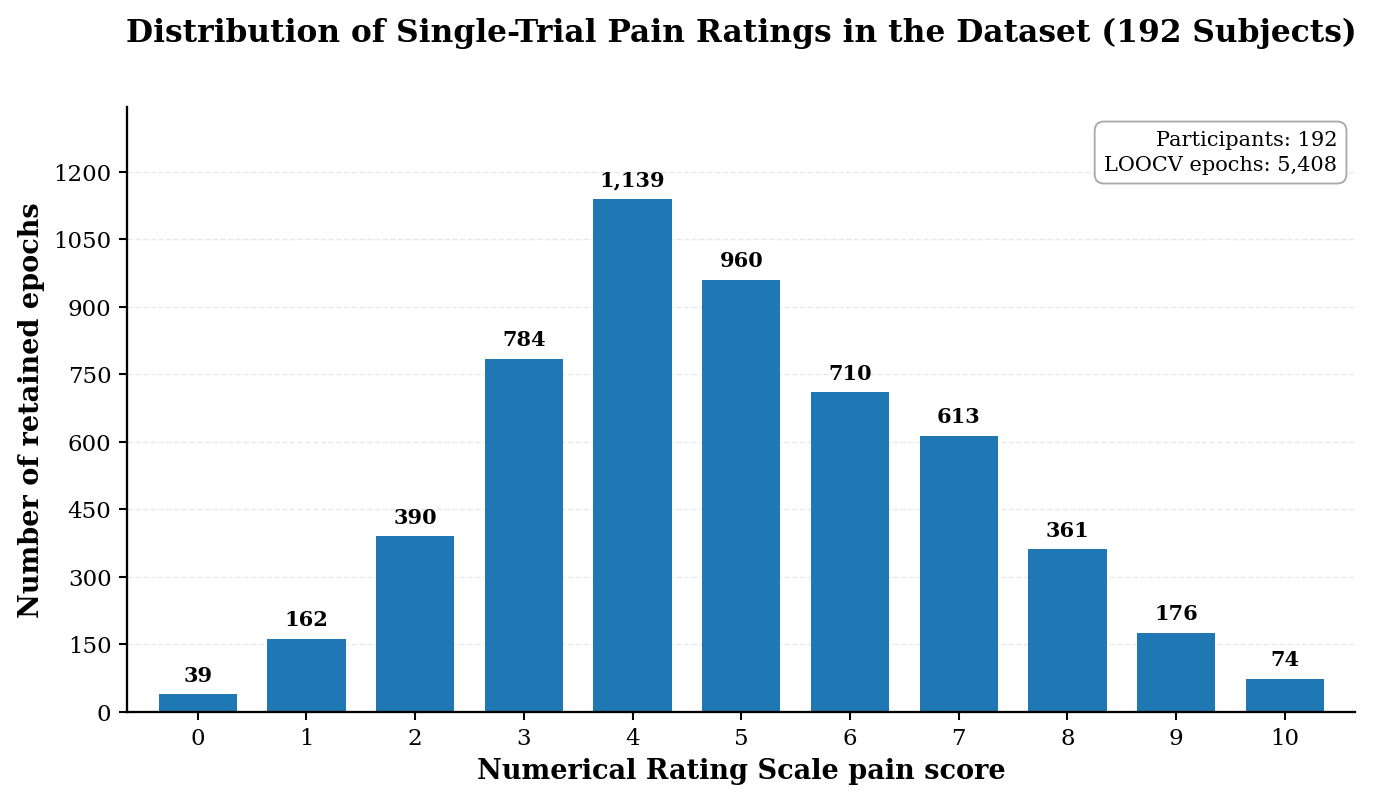

In [ ]:
# CELL 6 — Figure 1
# Distribution of NRS pain ratings in the strict-192 LOOCV subset

rating_counts = (
    strict_meta_df["painrating"]
    .value_counts()
    .reindex(range(11), fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    constrained_layout=True
)

bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    width=0.72
)

ax.set_title(
    "Distribution of Single-Trial Pain Ratings in the Dataset (192 Subjects)\n",
    pad=14
)

ax.set_xlabel(
    "Numerical Rating Scale pain score"
)

ax.set_ylabel(
    "Number of retained epochs"
)

ax.set_xticks(range(11))
ax.set_xlim(-0.65, 10.65)

upper_limit = max(
    rating_counts.max() * 1.18,
    1
)

ax.set_ylim(0, upper_limit)

clean_axes(ax)

# Add count above each bar
for bar, count in zip(
    bars,
    rating_counts.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + upper_limit * 0.015,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Dataset information box
ax.text(
    0.985,
    0.96,
    (
        f"Participants: {n_subjects}\n"
        f"LOOCV epochs: {n_epochs:,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    linespacing=1.35,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "0.65",
        "linewidth": 0.9,
        "alpha": 0.95
    }
)

save_figure(
    fig,
    "strict192_figure_1_nrs_pain_rating_distribution"
)

plt.show()

Participants: 192
Total epochs: 5408
Mean epochs: 28.17
Median epochs: 29
Participants with 30 epochs: 85 (44.3%)

Saved files:
 - /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/STRICT192_LOOCV_FIGURES/strict192_figure_3_epochs_per_participant.png
 - /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/STRICT192_LOOCV_FIGURES/strict192_figure_3_epochs_per_participant.pdf
 - /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V5_MAIN_PIPELINE_12CH/STRICT192_LOOCV_FIGURES/strict192_figure_3_epochs_per_participant.svg


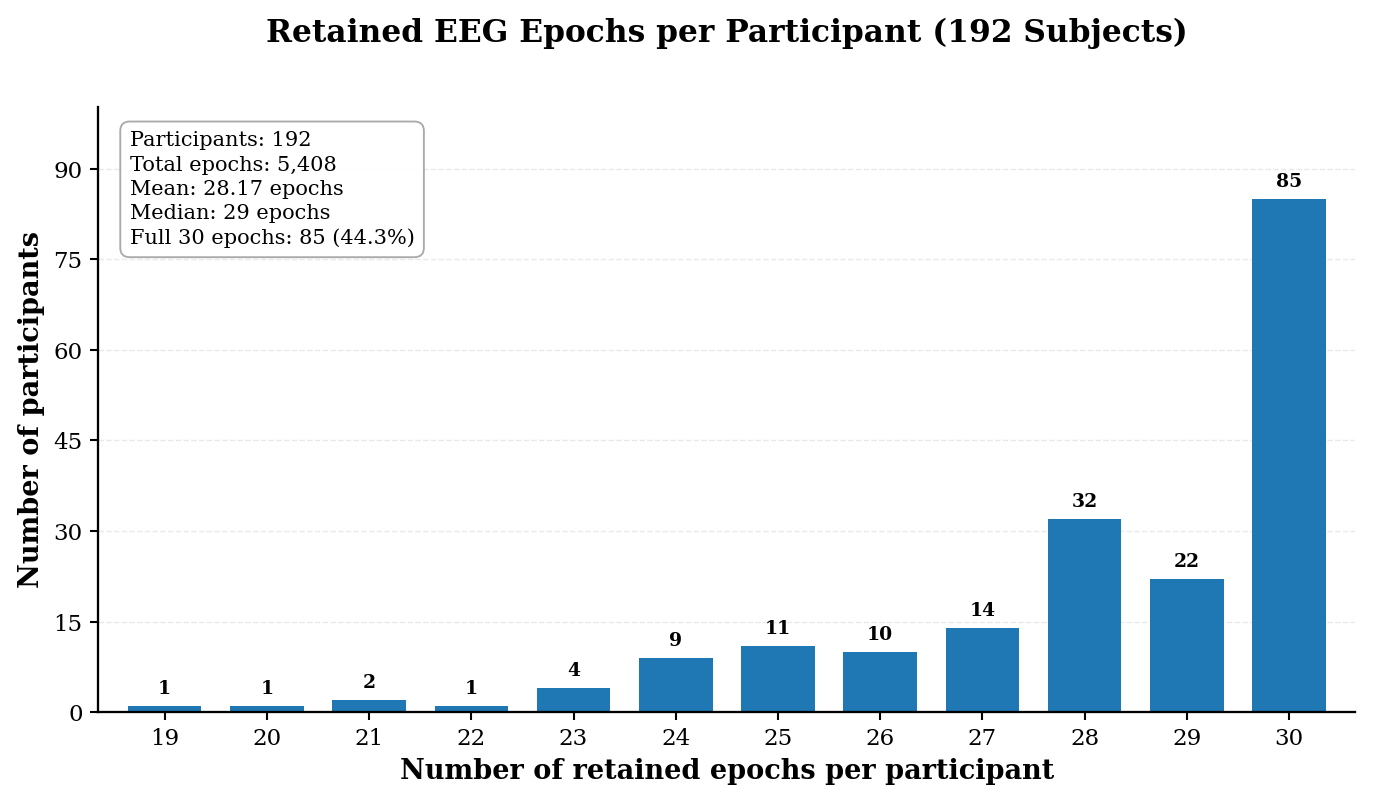

In [ ]:
# CELL — Retained epochs per participant
# Strict within-individual LOOCV subset: 192 subjects, 5,408 epochs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Verify the strict LOOCV subset
# ============================================================

required_columns = {
    "subject_id",
    "pain_label"
}

missing_columns = required_columns.difference(
    strict_meta_df.columns
)

if missing_columns:
    raise ValueError(
        f"Missing columns: {sorted(missing_columns)}"
    )

n_subjects = strict_meta_df["subject_id"].nunique()
n_epochs = len(strict_meta_df)

assert n_subjects == 192, (
    f"Expected 192 subjects, found {n_subjects}."
)

assert n_epochs == 5408, (
    f"Expected 5,408 epochs, found {n_epochs}."
)

# ============================================================
# 2. Count epochs for every participant
# ============================================================

epochs_per_subject = (
    strict_meta_df
    .groupby("subject_id")
    .size()
    .rename("n_epochs")
)

# Example:
# 28 epochs -> number of participants having exactly 28 epochs
epoch_count_distribution = (
    epochs_per_subject
    .value_counts()
    .sort_index()
)

# Include every integer between minimum and maximum,
# even when no participant has that epoch count
full_epoch_range = range(
    int(epochs_per_subject.min()),
    int(epochs_per_subject.max()) + 1
)

epoch_count_distribution = (
    epoch_count_distribution
    .reindex(
        full_epoch_range,
        fill_value=0
    )
)

# ============================================================
# 3. Summary values
# ============================================================

mean_epochs = epochs_per_subject.mean()
median_epochs = epochs_per_subject.median()

full_30_subjects = int(
    (epochs_per_subject == 30).sum()
)

full_30_percentage = (
    full_30_subjects / n_subjects * 100
)

print("Participants:", n_subjects)
print("Total epochs:", n_epochs)
print(f"Mean epochs: {mean_epochs:.2f}")
print(f"Median epochs: {median_epochs:.0f}")
print(
    f"Participants with 30 epochs: "
    f"{full_30_subjects} "
    f"({full_30_percentage:.1f}%)"
)

# ============================================================
# 4. Create the figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    constrained_layout=True
)

bars = ax.bar(
    epoch_count_distribution.index,
    epoch_count_distribution.values,
    width=0.72
)

ax.set_title(
    "Retained EEG Epochs per Participant (192 Subjects)\n",
    pad=14
)

ax.set_xlabel(
    "Number of retained epochs per participant"
)

ax.set_ylabel(
    "Number of participants"
)

ax.set_xticks(
    list(full_epoch_range)
)

ax.set_xlim(
    min(full_epoch_range) - 0.65,
    max(full_epoch_range) + 0.65
)

upper_limit = max(
    epoch_count_distribution.max() * 1.18,
    1
)

ax.set_ylim(
    0,
    upper_limit
)

clean_axes(ax)

# ============================================================
# 5. Add count above every non-empty bar
# ============================================================

for bar, count in zip(
    bars,
    epoch_count_distribution.values
):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + upper_limit * 0.014,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# ============================================================
# 6. Add information box
# ============================================================

ax.text(
    0.025,
    0.96,
    (
        f"Participants: {n_subjects}\n"
        f"Total epochs: {n_epochs:,}\n"
        f"Mean: {mean_epochs:.2f} epochs\n"
        f"Median: {median_epochs:.0f} epochs\n"
        f"Full 30 epochs: {full_30_subjects} "
        f"({full_30_percentage:.1f}%)"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    linespacing=1.35,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "0.65",
        "linewidth": 0.9,
        "alpha": 0.95
    }
)

# ============================================================
# 7. Save PNG, PDF and SVG
# ============================================================

save_figure(
    fig,
    "strict192_figure_3_epochs_per_participant"
)

plt.show()